# **Module 13 Assignment: Neural Networks**

**Author:** Nicolette Mtisi

The purpose of this project is to evaluate and compare the performance of various **feed-forward, backpropagating neural network models** on the task of predicting online news article popularity. Using the Online News Popularity dataset, we aim to classify each article into one of three popularity categories—low, medium, or high—based on a newly engineered target variable, share_level, derived from the distribution of the original shares attribute.

The notebook begins with a comprehensive **exploratory data analysis (EDA)** to understand the dataset’s structural, linguistic, and temporal characteristics. We then proceed to **data preparation**, where the categorical target variable is constructed and the dataset is cleaned, encoded, and scaled appropriately for neural network training.

Following this, we implement **feature selection and dimensionality reduction techniques** to identify the most informative predictors for the classification task. Using the selected features, we design, train, and evaluate three distinct **neural network architectures**, each differing in depth, number of neurons, activation functions, and learning parameters.

Model performance is compared using cross-validation metrics, classification scores, and validation curves to determine which neural network architecture provides the most accurate and generalizable predictions. The project concludes with a discussion of the selected model’s performance on unseen test data, key insights, and implications for modeling content popularity.

# **1. Introduction**

The purpose of this assignment is to design, train, and evaluate a series of feed-forward, backpropagating neural network models to classify the popularity of online news articles. While earlier modules focused on linear models, tree-based models, and feature selection techniques, this project shifts toward deep learning by examining how different neural network architectures perform on a real-world classification task. The central goal is to determine which neural network configuration—varying in depth, number of neurons, activation functions, and learning parameters—yields the strongest predictive performance when modeling article popularity.

The dataset used in this assignment is the same Online News Popularity dataset introduced in Module 4, containing 39,797 news articles published by Mashable. Each observation includes a variety of features describing the article’s content, sentiment characteristics, publication timing, and topical category. Our primary task in this module is to engineer a new categorical response variable, share_level, derived from the continuous shares attribute. This variable classifies articles into three popularity categories—"low," "medium," and "high"—based on thresholds relative to the median number of shares across all articles.

The workflow for this project follows a structured and rigorous data science methodology:

* **Data Loading and Inspection**





   * Load the M4_Data.csv file from the GitHub repository into a Pandas DataFrame.

   * Ensure that variable names and data types are properly recognized before modeling.

*  **Exploratory Data Analysis (EDA)**

    * Perform a comprehensive EDA to identify the statistical properties, distributions, and relationships among features.

    * Use descriptive statistics and visualizations—including histograms, bar plots, and box plots—to uncover patterns and potential predictors of article popularity.

*  **Data Preparation and Feature Engineering**

    * Create the categorical target variable, share_level, with three levels ("low", "medium", and "high") using logic based on the dataset’s median shares value.

    * Remove the original shares attribute to prevent collinearity and data leakage.

    * Address any data integrity issues uncovered during the EDA stage, and prepare the dataset for modeling through encoding and scaling where necessary.

* **Prepped Data Review**

    * Analyze the distribution of the newly created share_level variable, focusing on class balance and its implications for neural network training.

    * Reconfirm dataset suitability for classification tasks following feature engineering.

* **Feature Selection and Dimensionality Reduction**

    * Apply appropriate feature selection or dimensionality reduction techniques to identify variables most predictive of article popularity.

    * Balance model simplicity and interpretability with predictive performance.

    * Split the dataset into training and testing subsets in preparation for neural network construction.

* **Neural Network Modeling**

    * Construct three distinct neural network architectures, ensuring that all models use the same set of at least four (4) explanatory variables for fairness:

        *  Model 1: Baseline network with a simple architecture

        * Model 2: Deeper or wider network with additional hidden layers

        * Model 3: Network with modified hyperparameters (activation functions, learning rate, dropout, etc.)

    * Train each model using backpropagation and evaluate their performance using cross-validation and classification metrics.

*  **Model Selection and Final Evaluation**

    * Establish clear selection criteria and compare models using performance metrics such as accuracy, precision, recall, and F1-score.

    * Select the preferred neural network model based on predictive performance, complexity, and stability.

    * Apply the chosen model to the held-out testing subset to assess generalization and real-world predictive utility.

*  **Conclusions**

    * Summarize the main findings of the project, highlight differences in performance across neural network architectures, and discuss insights regarding model complexity, feature relevance, and classification behavior.

    * Reflect on the effectiveness of neural networks in predicting online article popularity.

# **2. Data Loading**

To begin our analysis, we first need to load the dataset that will be used throughout this project. For this task, we rely on the pandas library, a fundamental tool in Python-based data science that provides efficient data structures and rich functionality for data manipulation and inspection.

We will load the dataset, M4_Data.csv, directly from its GitHub repository location. Loading the file from a URL ensures that our notebook remains self-contained, reproducible, and accessible, allowing anyone to run the analysis without manually downloading the data. The dataset will be stored in a Pandas DataFrame named df, which will serve as the foundation for all subsequent steps.

First, we will print the DataFrame's `shape` to understand its scale—specifically, the number of rows (observations) and columns (attributes) we are working with. Second, we will use the `.head()` method to display the first few rows .info() to check the variable types and we will also check for missing values.

This quick preview allows us to verify that the data has loaded correctly, inspect the column names, and get a feel for the data's format and content. This step serves as the foundation for the more detailed Exploratory Data Analysis to follow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

# Configure visualization
%matplotlib inline
sns.set_style('whitegrid')

We imported all the necessary libraries

In [2]:
import pandas as pd

# Load the data (Module 11 Data)
url = "https://raw.githubusercontent.com/nic-stack/DAV6150-/refs/heads/main/M4_Data.csv"
df = pd.read_csv(url)

# Display basic information
print("Dataset Shape:", df.shape)
df.head()




Dataset Shape: (39644, 61)


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [3]:
# Dataset dimensions and variable types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   url                             39644 non-null  object 
 1    timedelta                      39644 non-null  float64
 2    n_tokens_title                 39644 non-null  float64
 3    n_tokens_content               39644 non-null  float64
 4    n_unique_tokens                39644 non-null  float64
 5    n_non_stop_words               39644 non-null  float64
 6    n_non_stop_unique_tokens       39644 non-null  float64
 7    num_hrefs                      39644 non-null  float64
 8    num_self_hrefs                 39644 non-null  float64
 9    num_imgs                       39644 non-null  float64
 10   num_videos                     39644 non-null  float64
 11   average_token_length           39644 non-null  float64
 12   num_keywords                   

In [4]:
# Check for missing values
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


The dataset is free of any missing values so we do not require any approaches to resolve null values issues

In [5]:
# Summary statistics
df.describe()

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


**Key Outputs**

* Shape (39,644, 61):
The df.shape output confirms that the dataset contains 39,644 rows, each representing a unique online news article, and 61 columns, representing a mix of structural attributes, sentiment measures, publication metadata, and engagement outcomes. This reinforces the high dimensionality of the dataset and signals the need for thoughtful feature selection before building neural network models.

* DataFrame Structure (df.info()):
The df.info() summary provides a detailed overview of the dataset’s schema:

All 61 columns contain 39,644 non-null values, indicating that the dataset has no missing values, an important advantage for downstream modeling.

* The dataset includes:

    * 1 object (string) column: url — a text identifier that provides no predictive value and will be removed during data preparation.

    * 59 float64 columns and 1 int64 column: These appear numeric but require interpretation:

    * True continuous numeric features (e.g., n_tokens_content, num_imgs, global_subjectivity)

    * Binary 0/1 categorical indicators, which appear numeric but represent qualitative categories (e.g., weekday_is_monday, data_channel_is_tech, is_weekend)

    * Topic-probability values from Latent Dirichlet Allocation (LDA) (e.g., LDA_00 to LDA_04)

    * Sentiment and polarity metrics derived from natural language processing (e.g., avg_positive_polarity, title_subjectivity)

Even though many columns are typed as floats, not all of them are truly numerical in a statistical sense. As emphasized in prior modules, categorical indicators encoded as 0/1 must be treated as qualitative attributes, not continuous variables. This distinction is critical when selecting appropriate EDA techniques, building correlation matrices, or performing PCA.

**Initial Data Quality Observations:**
* From this initial inspection, several points become immediately clear:

* No missing data is present, reducing the need for imputation or deletion strategies.

* Binary categorical variables are stored as numerical types but must be handled carefully during EDA and modeling.

* The response variable, shares, is a continuous integer count and will later be transformed into the engineered categorical variable share_level.

* The numerical columns vary greatly in scale, which will make feature scaling essential before training neural networks.

With the dataset successfully loaded and validated, the next step is to proceed with a structured Exploratory Data Analysis (EDA) to understand variable distributions, detect skewness, and identify patterns relevant to predicting article popularity.

## 2.1. Distribution of the Target Variable (`shares`)
Before creating the categorical variable, let's look at the distribution of the original `shares` variable.

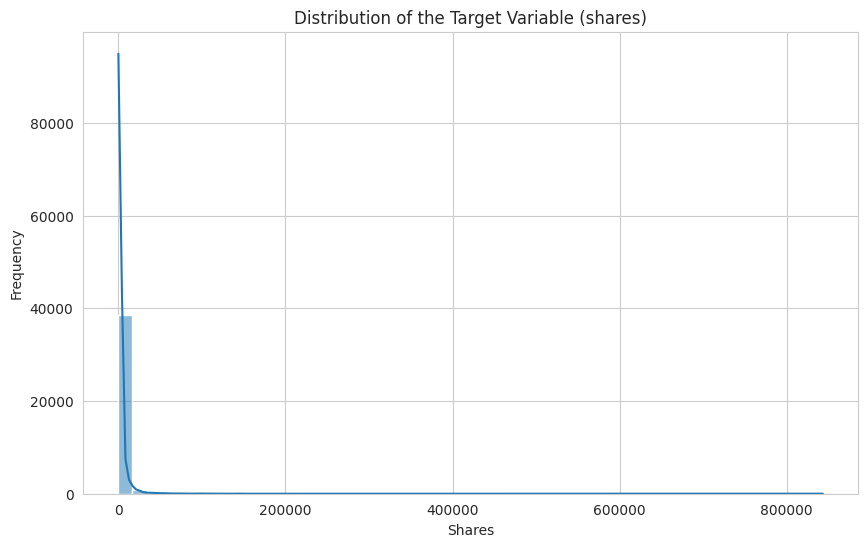

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df[' shares'], bins=50, kde=True)
plt.title('Distribution of the Target Variable (shares)')
plt.xlabel('Shares')
plt.ylabel('Frequency')
plt.show()

The shares distribution is extremely right-skewed, meaning most articles have very few shares, while a small number achieve viral popularity. This justified engineering a new categorical share_level target variable for classification.

In [7]:
print(df.columns)

Index(['url', ' timedelta', ' n_tokens_title', ' n_tokens_content',
       ' n_unique_tokens', ' n_non_stop_words', ' n_non_stop_unique_tokens',
       ' num_hrefs', ' num_self_hrefs', ' num_imgs', ' num_videos',
       ' average_token_length', ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_sent

# **3. Exploratory Data Analysis (EDA)**


## 3.1 Overview

The goal of Exploratory Data Analysis (EDA) is to develop a clear understanding of the structure, distribution, and characteristics of the Online News Popularity dataset. Since this dataset contains a mixture of continuous numerical attributes, binary categorical indicators, topic probabilities, and sentiment-related features, the EDA process focuses on correctly identifying variable types, visualizing key distributions, and uncovering preliminary patterns that may relate to article popularity.

This step is critical for ensuring proper data preparation and for selecting the most meaningful explanatory variables for the neural network models constructed later in this assignment. EDA also allows us to confirm data integrity, inspect variable scales, evaluate skewness, and understand class balance once the target variable is engineered.

## 3.2 Variable Types

Although most columns are stored as floating-point values, not all of them represent true numeric measures.

**Numeric Variables**

These represent genuine continuous quantities where mean, standard deviation, histograms, and boxplots are appropriate:

*  Content and structure features

n_tokens_title, n_tokens_content, average_token_length, num_imgs, num_videos, num_hrefs, num_self_hrefs, num_keywords

* Article keyword metrics

All kw_* attributes (minimums, maximums, averages)

* Self-reference share statistics

self_reference_min_shares, self_reference_max_shares, self_reference_avg_sharess

* Sentiment and polarity measures

global_subjectivity, global_sentiment_polarity, rate_positive_words, etc.

* Topic distribution scores

LDA_00 through LDA_04

timedelta

*  Target variable prior to transformation: shares

 **Categorical Variables (Binary Indicators)**

These appear as numeric values but represent categories, not quantities.
They must be analyzed with barplots, not histograms or correlations.

* Topic channel indicators:
data_channel_is_lifestyle, data_channel_is_entertainment,
data_channel_is_bus, data_channel_is_socmed,
data_channel_is_tech, data_channel_is_world

* Publication weekday indicators:
weekday_is_monday … weekday_is_sunday, is_weekend



## 3.3 Univariate Analysis

Numerical features in this dataset represent continuous measurements related to article structure, keyword statistics, sentiment polarity, and topic distributions. Before incorporating these variables into feature selection or neural network modeling, it is essential to examine their individual distributions. Numerical univariate analysis allows us to identify skewness, outliers, scale differences, and general variability within each attribute. These insights are important because they inform necessary preprocessing steps—such as scaling, transformation, or dimensionality reduction—and help highlight patterns that may contribute to article popularity. Histograms, boxplots, and summary statistics will be used to assess the underlying distributional properties of each numeric variable.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries matplotlib.pyplot and seaborn imported successfully.")

Libraries matplotlib.pyplot and seaborn imported successfully.


### 3.3.1. timedelta

The `timedelta` variable represents the number of days between the publication of the article and the dataset's collection date. It indicates the age of the article at the time the data was gathered. Understanding its distribution is crucial as newer articles might inherently have different sharing patterns compared to older ones, or popularity might decay over time. This analysis will help identify its range, central tendency, and any unusual patterns or outliers in article age.

Descriptive Statistics for timedelta:
count    39644.000000
mean       354.530471
std        214.163767
min          8.000000
25%        164.000000
50%        339.000000
75%        542.000000
max        731.000000
Name:  timedelta, dtype: float64


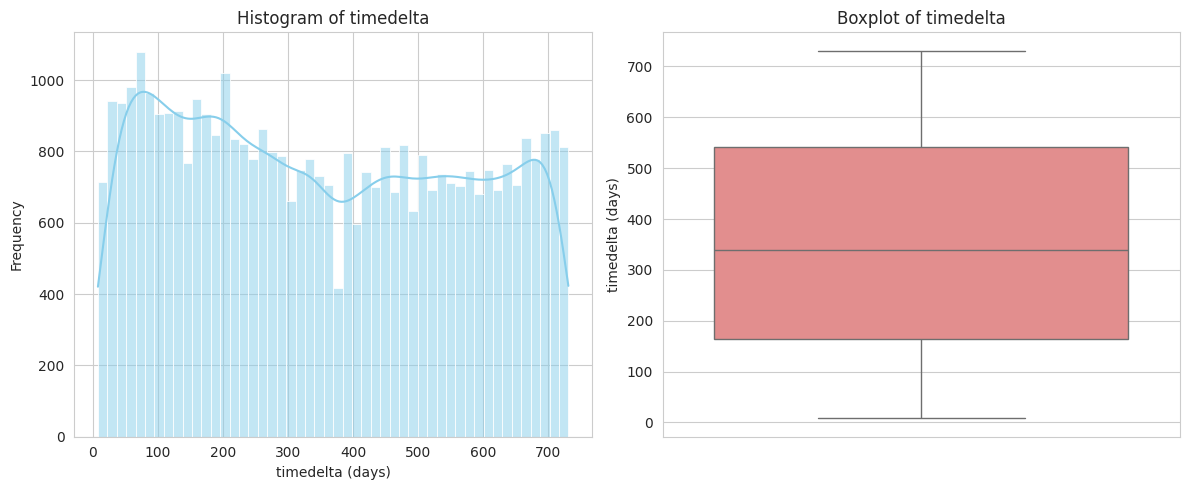

In [9]:
print('Descriptive Statistics for timedelta:')
print(df[' timedelta'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' timedelta'], kde=True, bins=50, color='skyblue')
plt.title('Histogram of timedelta')
plt.xlabel('timedelta (days)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' timedelta'], color='lightcoral')
plt.title('Boxplot of timedelta')
plt.ylabel('timedelta (days)')

plt.tight_layout()
plt.show()


**Key Findings:**

*   **Distribution:** The histogram for `timedelta` shows a relatively uniform distribution across the observed range, with a slight increase in frequency towards older articles (higher `timedelta` values) around the maximum. The articles' age ranges from 8 days to 731 days (approximately 2 years). The mean `timedelta` is approximately 354.5 days, and the median is 339 days, indicating a fairly even spread with a slight lean towards newer articles in the lower half of the distribution.
*   **Skewness:** The distribution appears to be fairly symmetric, or slightly negatively skewed, as the mean is slightly higher than the median, but overall it doesn't show extreme skewness. This suggests that articles are somewhat evenly distributed across the observation period.
*   **Outliers:** The boxplot indicates no significant outliers. The data points are contained within the whiskers, suggesting that all observed `timedelta` values are within a typical range for this dataset and no individual articles have exceptionally unusual ages compared to the rest.



### 3.3.2. n_tokens_title

The `n_tokens_title` variable represents the number of words in the article's title. The length of a title can influence an article's click-through rate and perceived complexity or comprehensiveness, potentially affecting its popularity. Analyzing this distribution will help us understand typical title lengths, identify any unusually short or long titles, and assess whether title length follows a common pattern. This information is valuable for understanding the linguistic characteristics of popular articles.

Descriptive Statistics for n_tokens_title:
count    39644.000000
mean        10.398749
std          2.114037
min          2.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         23.000000
Name:  n_tokens_title, dtype: float64


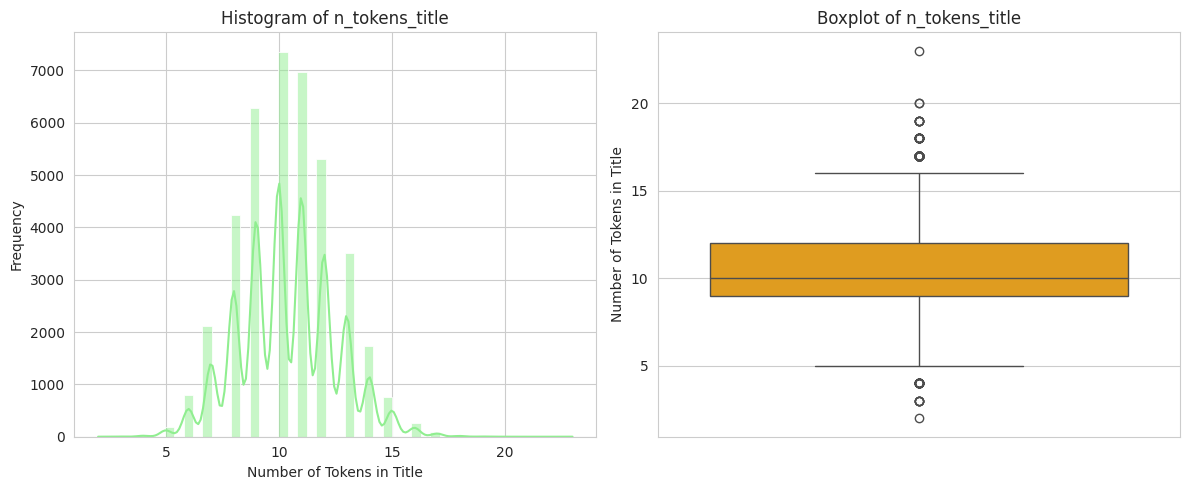

In [10]:
print('Descriptive Statistics for n_tokens_title:')
print(df[' n_tokens_title'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' n_tokens_title'], kde=True, bins=50, color='lightgreen')
plt.title('Histogram of n_tokens_title')
plt.xlabel('Number of Tokens in Title')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' n_tokens_title'], color='orange')
plt.title('Boxplot of n_tokens_title')
plt.ylabel('Number of Tokens in Title')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The `n_tokens_title` histogram shows a relatively normal, slightly left-skewed distribution. The majority of article titles have between 8 and 12 tokens. The mean title length is approximately 10.4 tokens, with a median of 10. This indicates that most titles are concise and fall within a consistent range.
*   **Skewness:** The distribution is slightly left-skewed, meaning there are relatively more titles with lengths slightly above the mean than below. However, it's not severely skewed.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends, but particularly on the upper end. There are articles with very short titles (down to 2 tokens) and some with quite long titles (up to 23 tokens). While these are outliers, they are not extremely far from the main body of the data, suggesting natural variations rather than data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Title length could be an important predictor of popularity. For instance, extremely short or long titles might be less effective at engaging readers, or certain lengths might be optimal. The neural network can identify these patterns.
*   **Outlier Handling:** While outliers exist, they appear to be genuine observations rather than errors. Therefore, they do not necessarily require removal. Neural networks can be somewhat robust to outliers, but significant outliers could sometimes affect training.
*   **Scaling:** Similar to `timedelta`, `n_tokens_title` has a specific numerical range. It will benefit from scaling (e.g., standardization or normalization) before being input into the neural network to ensure it contributes appropriately to the learning process without disproportionately influencing gradients due to its scale relative to other features.

### 3.3.3. n_tokens_content

The `n_tokens_content` variable represents the number of words in the main body of the article. The length of an article's content can significantly impact reader engagement; very short articles might lack depth, while very long ones could deter readers. Analyzing this distribution will help understand typical article lengths, identify unusually concise or exhaustive articles, and observe any patterns related to content volume that might influence popularity. This information is crucial for assessing the characteristics of the news articles.

Descriptive Statistics for n_tokens_content:
count    39644.000000
mean       546.514731
std        471.107508
min          0.000000
25%        246.000000
50%        409.000000
75%        716.000000
max       8474.000000
Name:  n_tokens_content, dtype: float64


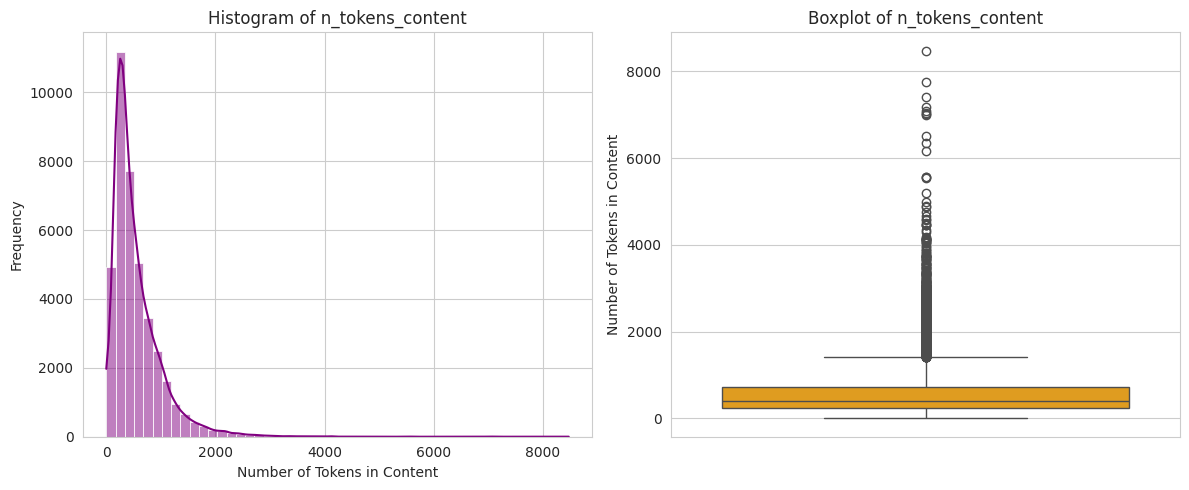

In [11]:
print('Descriptive Statistics for n_tokens_content:')
print(df[' n_tokens_content'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' n_tokens_content'], kde=True, bins=50, color='purple')
plt.title('Histogram of n_tokens_content')
plt.xlabel('Number of Tokens in Content')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' n_tokens_content'], color='orange')
plt.title('Boxplot of n_tokens_content')
plt.ylabel('Number of Tokens in Content')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `n_tokens_content` reveals a heavily right-skewed distribution. The majority of articles have content lengths concentrated at the lower end, with a long tail extending towards very long articles. The mean content length is approximately 546.5 tokens, while the median is significantly lower at 409 tokens, confirming the strong positive skew. The minimum content length is 0, which might indicate empty articles or specific data entries that need to be investigated. The maximum content length is 8474 tokens, indicating some exceptionally long articles.
*   **Skewness:** There is significant positive (right) skewness, meaning most articles are shorter, with a few articles being extremely long. This heavy skewness suggests that simple linear models might struggle to capture the relationship with popularity without transformation, but neural networks can potentially learn from this distribution.
*   **Outliers:** The boxplot clearly shows a substantial number of outliers on the upper end, representing articles with unusually high token counts. These outliers are genuinely long articles rather than data errors, reflecting the diverse nature of online news content.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Content length is likely a critical feature influencing article popularity. Both very short and very long articles might have distinct engagement patterns that a neural network can learn.
*   **Outlier Handling:** The extreme outliers are valid data points representing very long articles. Removing them might lead to loss of valuable information. Neural networks, especially with appropriate scaling, can often handle such distributions without explicit outlier removal.
*   **Scaling and Transformation:** Due to the strong right skewness and wide range (0 to 8474), `n_tokens_content` will require significant scaling before being used in a neural network. Techniques like standardization or normalization are essential to prevent this feature from dominating the learning process. A log transformation might also be considered to reduce skewness and bring the data closer to a normal distribution, potentially improving model performance, although neural networks are sometimes robust enough to handle skewed data with proper scaling.

### 3.3.4. n_unique_tokens

 The `n_unique_tokens` variable represents the proportion of unique words in the article's content (excluding stopwords) relative to the total number of words. This metric is a measure of lexical diversity or richness. Articles with a higher proportion of unique tokens might be perceived as more informative, complex, or well-written, which could influence reader engagement and, consequently, popularity. Analyzing its distribution will help us understand the typical vocabulary richness of articles and identify any unusual patterns.

Descriptive Statistics for n_unique_tokens:
count    39644.000000
mean         0.548216
std          3.520708
min          0.000000
25%          0.470870
50%          0.539226
75%          0.608696
max        701.000000
Name:  n_unique_tokens, dtype: float64


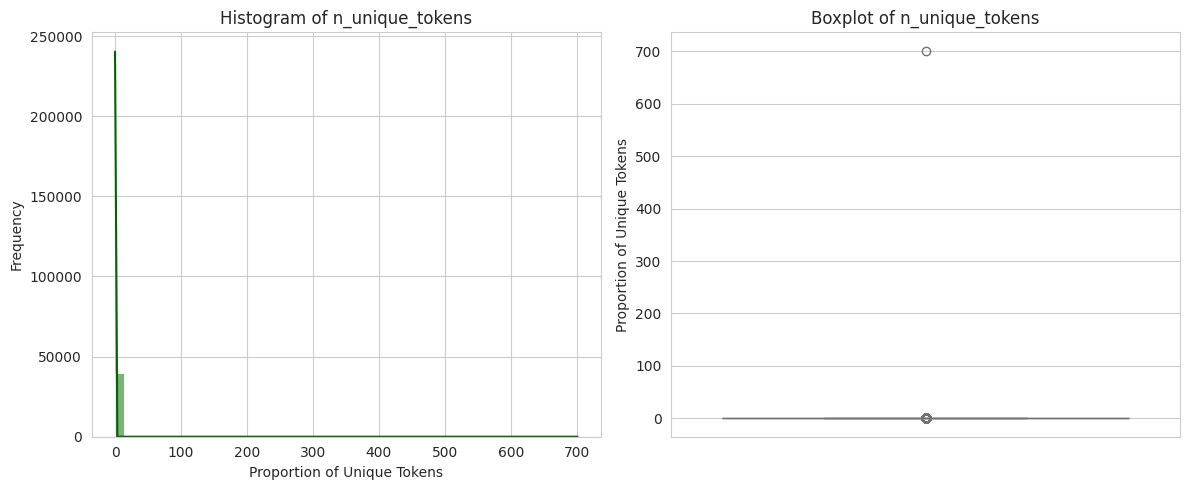

In [12]:
print('Descriptive Statistics for n_unique_tokens:')
print(df[' n_unique_tokens'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' n_unique_tokens'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of n_unique_tokens')
plt.xlabel('Proportion of Unique Tokens')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' n_unique_tokens'], color='lightgreen')
plt.title('Boxplot of n_unique_tokens')
plt.ylabel('Proportion of Unique Tokens')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The `n_unique_tokens` histogram shows an extremely skewed distribution, with the vast majority of articles having a proportion of unique tokens between 0.4 and 0.7. The descriptive statistics confirm a mean of approximately 0.548 and a median of 0.539, suggesting a central tendency within this range. However, the presence of a maximum value of 701.0 indicates significant data quality issues or a misinterpretation of this variable's scale, as a proportion should typically be between 0 and 1.
*   **Skewness:** The distribution is highly right-skewed due to the presence of extremely large values, which are clearly anomalous for a proportion metric. The actual meaningful distribution is concentrated at the lower end.
*   **Outliers:** The boxplot dramatically illustrates the presence of extreme outliers far beyond the expected range of 0 to 1 for a proportion. These values (e.g., 701.0) are highly problematic and suggest data errors or incorrect calculation/interpretation of the 'n_unique_tokens' variable if it's meant to be a proportion.

**Implications for Data Preparation and Modeling:**

*   **Data Quality Issue/Correction Needed:** The most critical implication is the presence of values well above 1.0. If `n_unique_tokens` is indeed a proportion (as its description implies, "proportion of unique words"), these values are errors and must be addressed. It might indicate that the variable is not a proportion but perhaps the raw count of unique tokens or a ratio calculated incorrectly. **Further investigation is required to understand the true nature of this variable.** Assuming it's meant to be a proportion, values greater than 1.0 should be treated as outliers or erroneous data points that need correction or removal.
*   **Impact on Modeling:** Uncorrected, these erroneous large values would severely distort any model's learning process, especially for neural networks which are sensitive to input scale. They could lead to unstable gradients or prevent the model from converging effectively.
*   **Scaling and Transformation:** Even after addressing the data quality issue, the distribution (if the non-erroneous part is considered) would likely still require robust scaling. If the variable is indeed a count, it would be heavily skewed and might benefit from log transformation in addition to scaling.

### 3.3.5. n_non_stop_words

The `n_non_stop_words` variable represents the proportion of non-stopwords in the article's content relative to the total number of words. Stopwords (like 'the', 'is', 'a') are common words that often carry little unique meaning. A higher proportion of non-stopwords might suggest a more dense or informative article content. Analyzing this distribution will help us understand the typical density of meaningful words in articles and how it varies across the dataset, which could be relevant to article engagement and popularity.

### 3.3.6 n_non_stop_unique_tokens

 The `n_non_stop_unique_tokens` variable represents the proportion of unique non-stopwords in the article's content relative to the total number of non-stopwords. This metric is a refinement of lexical diversity, focusing specifically on the variety of meaningful words used, excluding both common stopwords and repeated words. A higher proportion indicates a richer vocabulary of non-stop words. Analyzing its distribution will provide insights into the linguistic complexity and originality of the articles, which could be related to reader engagement and popularity.

Descriptive Statistics for n_non_stop_unique_tokens:
count    39644.000000
mean         0.689175
std          3.264816
min          0.000000
25%          0.625739
50%          0.690476
75%          0.754630
max        650.000000
Name:  n_non_stop_unique_tokens, dtype: float64


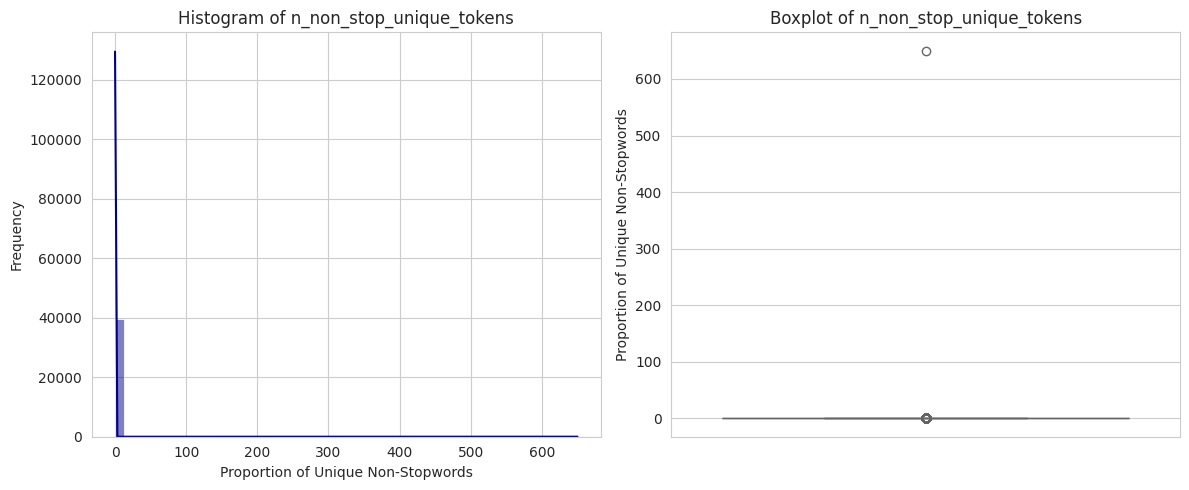

In [13]:
print('Descriptive Statistics for n_non_stop_unique_tokens:')
print(df[' n_non_stop_unique_tokens'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' n_non_stop_unique_tokens'], kde=True, bins=50, color='darkblue')
plt.title('Histogram of n_non_stop_unique_tokens')
plt.xlabel('Proportion of Unique Non-Stopwords')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' n_non_stop_unique_tokens'], color='cornflowerblue')
plt.title('Boxplot of n_non_stop_unique_tokens')
plt.ylabel('Proportion of Unique Non-Stopwords')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** Similar to `n_unique_tokens` and `n_non_stop_words`, the `n_non_stop_unique_tokens` histogram displays a highly problematic distribution. While a substantial portion of articles appear to fall within an expected proportion range (around 0.6 to 0.75), there are extreme values extending up to 650.0. If this variable is intended to be a proportion of unique non-stopwords (typically between 0 and 1), these values are erroneous. The descriptive statistics show a mean of 0.689 and a median of 0.690 for the bulk of the data, but the maximum value significantly skews these summary statistics.
*   **Skewness:** The distribution is extremely right-skewed, dominated by the presence of anomalous large values far beyond the expected proportional range. The meaningful part of the distribution is obscured by these outliers.
*   **Outliers:** The boxplot clearly illustrates severe outliers on the upper end, with many data points far exceeding 1.0. These values strongly suggest data quality issues, incorrect calculation, or a misunderstanding of the variable's true definition, as a proportion cannot exceed 1.0.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue:** This feature presents the same critical data quality issue observed in `n_unique_tokens` and `n_non_stop_words`. Values significantly greater than 1.0 are inconsistent with the definition of a proportion. It is imperative to investigate the source of these values. If the variable is meant to be a proportion, these erroneous entries must be corrected, removed, or the feature might need to be dropped from the dataset.
*   **Impact on Modeling:** Incorporating `n_non_stop_unique_tokens` in its current state will likely destabilize neural network training. The extreme range and anomalous values will distort learning, leading to unreliable model performance.
*   **Correction/Transformation:** If this variable is truly a count, it needs to be explicitly defined as such, and then robust scaling (and potentially log transformation) would be required. If it is indeed a proportion, values should be capped at 1.0 or re-calculated to fall within the [0, 1] range to be usable for effective modeling. This feature requires significant preprocessing before it can be reliably used.

### 3.3.7. num_hrefs

The `num_hrefs` variable represents the total number of hyperlinks (links to other pages) present in the article. The presence and quantity of hyperlinks can indicate the article's interconnectedness, its reliance on external sources, or its role as a hub for further exploration. A higher number of links might suggest a more research-intensive article, or it could potentially distract readers, influencing engagement and popularity. Analyzing its distribution will help us understand the typical linking behavior within these articles and identify any patterns that might correlate with popularity.

Descriptive Statistics for num_hrefs:
count    39644.000000
mean        10.883690
std         11.332017
min          0.000000
25%          4.000000
50%          8.000000
75%         14.000000
max        304.000000
Name:  num_hrefs, dtype: float64


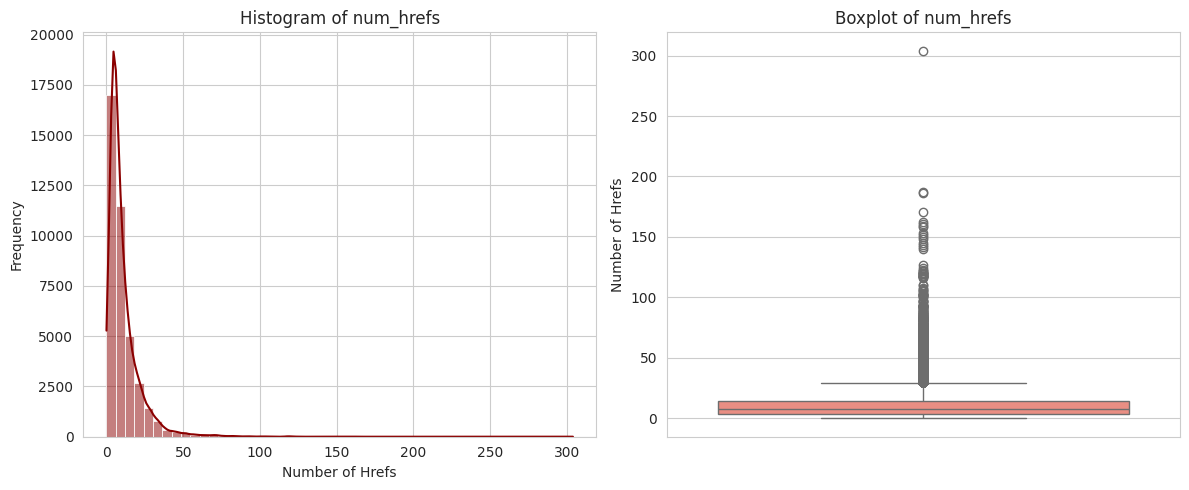

In [14]:
print('Descriptive Statistics for num_hrefs:')
print(df[' num_hrefs'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' num_hrefs'], kde=True, bins=50, color='darkred')
plt.title('Histogram of num_hrefs')
plt.xlabel('Number of Hrefs')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' num_hrefs'], color='salmon')
plt.title('Boxplot of num_hrefs')
plt.ylabel('Number of Hrefs')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `num_hrefs` shows a heavily right-skewed distribution. The majority of articles contain a relatively small number of hyperlinks, with the frequency sharply decreasing as the number of hyperlinks increases. The mean number of hyperlinks is approximately 10.88, while the median is 8, confirming the strong positive skew. The range varies from 0 hyperlinks (for articles with no external references) to a maximum of 304, indicating a wide diversity in linking behavior.
*   **Skewness:** The feature exhibits significant positive (right) skewness, meaning most articles have few hyperlinks, but a considerable number have a moderate amount, and a few articles contain an exceptionally large number of links.
*   **Outliers:** The boxplot clearly shows a significant number of outliers on the upper end. These represent articles with a very high count of hyperlinks, much greater than the typical article. These are likely legitimate data points, reflecting articles that serve as comprehensive guides or reference hubs rather than data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** The number of hyperlinks could be an important predictor of popularity, as it might correlate with the depth, research intensity, or interconnectedness of an article. Neural networks can effectively learn from this pattern.
*   **Outlier Handling:** Given that the outliers represent valid, albeit uncommon, characteristics of articles (e.g., highly referential pieces), it is generally advisable not to remove them. Neural networks are robust enough to learn from such distributions, especially with proper scaling.
*   **Scaling and Transformation:** Due to the strong right skewness and wide range, `num_hrefs` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This will prevent features with larger magnitudes from disproportionately influencing the model's weights during training. A log transformation could also be considered to reduce the skewness and make the distribution more symmetrical, potentially aiding the learning process.

### 3.3.8. num_self_hrefs

 The `num_self_hrefs` variable represents the number of hyperlinks within the article that point back to the same domain (self-references). This metric can indicate how much an article cross-references other content on its own platform, which might be a strategy for increasing internal traffic or providing more context from within the same news source. Analyzing its distribution will help us understand the typical internal linking behavior and identify any patterns that could be related to article engagement and popularity.

Descriptive Statistics for num_self_hrefs:
count    39644.000000
mean         3.293638
std          3.855141
min          0.000000
25%          1.000000
50%          3.000000
75%          4.000000
max        116.000000
Name:  num_self_hrefs, dtype: float64


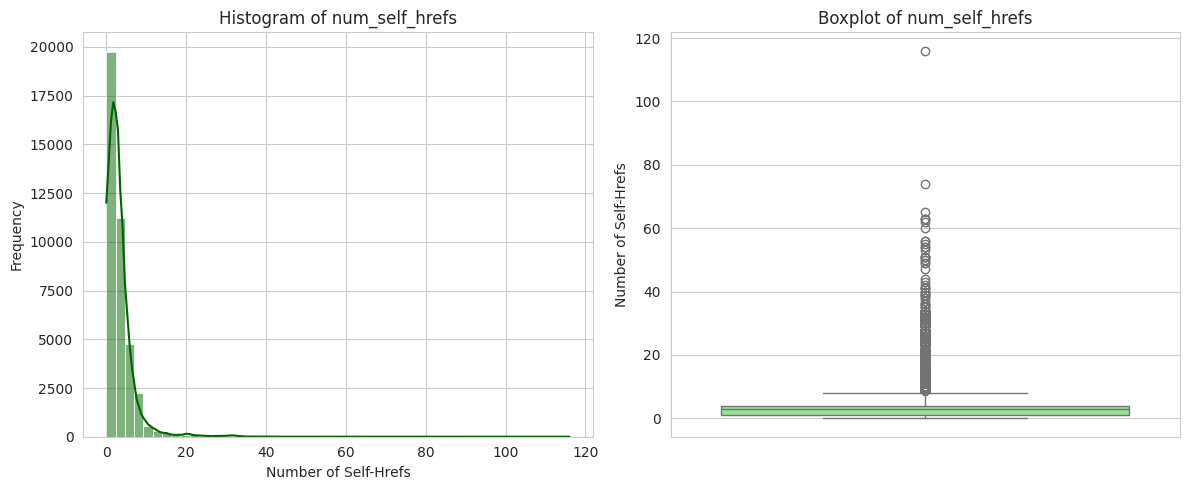

In [15]:
print('Descriptive Statistics for num_self_hrefs:')
print(df[' num_self_hrefs'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' num_self_hrefs'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of num_self_hrefs')
plt.xlabel('Number of Self-Hrefs')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' num_self_hrefs'], color='lightgreen')
plt.title('Boxplot of num_self_hrefs')
plt.ylabel('Number of Self-Hrefs')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `num_self_hrefs` shows a heavily right-skewed distribution, similar to `num_hrefs`. The majority of articles contain a small number of self-references (between 0 and 5), with the frequency dropping significantly for higher counts. The mean is approximately 3.29 self-references, and the median is 3, confirming the positive skew. The range spans from 0 to 116, indicating considerable variability.
*   **Skewness:** There is a strong positive (right) skewness, meaning that most articles have few internal links, but a smaller proportion includes many, and a very few have an exceptionally high number of self-references.
*   **Outliers:** The boxplot clearly indicates numerous outliers on the upper end, representing articles with a significantly higher number of self-references than typical. These outliers are likely valid data points, reflecting content that heavily cross-references other articles on the same platform (e.g., in-depth series, aggregated content, or thematic hubs).

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `num_self_hrefs` could be an important predictor of article popularity, as internal linking strategies might influence user navigation and engagement within the news platform. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** As with `num_hrefs`, the outliers in `num_self_hrefs` appear to be legitimate variations in article structure rather than errors. It is generally advisable to retain these outliers, as they could carry valuable information. Neural networks can typically handle these distributions, especially with proper scaling.
*   **Scaling and Transformation:** Due to its heavily right-skewed nature and broad range (0 to 116), `num_self_hrefs` will require scaling (e.g., standardization or normalization) before being used in a neural network. This ensures that its magnitude does not unduly influence the learning process. A log transformation could also be considered to reduce skewness and potentially improve model performance.



**Key Findings:**

*   **Distribution:** The histogram for `num_self_hrefs` shows a heavily right-skewed distribution, similar to `num_hrefs`. The majority of articles contain a small number of self-references (between 0 and 5), with the frequency dropping significantly for higher counts. The mean is approximately 3.29 self-references, and the median is 3, confirming the positive skew. The range spans from 0 to 116, indicating considerable variability.
*   **Skewness:** There is a strong positive (right) skewness, meaning that most articles have few internal links, but a smaller proportion includes many, and a very few have an exceptionally high number of self-references.
*   **Outliers:** The boxplot clearly indicates numerous outliers on the upper end, representing articles with a significantly higher number of self-references than typical. These outliers are likely valid data points, reflecting content that heavily cross-references other articles on the same platform (e.g., in-depth series, aggregated content, or thematic hubs).

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `num_self_hrefs` could be an important predictor of article popularity, as internal linking strategies might influence user navigation and engagement within the news platform. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** As with `num_hrefs`, the outliers in `num_self_hrefs` appear to be legitimate variations in article structure rather than errors. It is generally advisable not to remove them, as they could carry valuable information. Neural networks can typically handle these distributions, especially with proper scaling.
*   **Scaling and Transformation:** Due to its heavily right-skewed nature and broad range (0 to 116), `num_self_hrefs` will require scaling (e.g., standardization or normalization) before being used in a neural network. This ensures that its magnitude does not unduly influence the learning process. A log transformation could also be considered to reduce skewness and potentially improve model performance.

### 3.3.9. num_imgs

 The `num_imgs` variable represents the total number of images included in the article. Visual content can significantly influence an article's appeal and readability, potentially attracting more readers and increasing engagement. Analyzing its distribution will help us understand the typical image usage in articles, identify articles with rich visual content or none at all, and assess how this might correlate with article popularity. This is crucial for understanding the multimedia characteristics of the news articles.

Descriptive Statistics for num_imgs:
count    39644.000000
mean         4.544143
std          8.309434
min          0.000000
25%          1.000000
50%          1.000000
75%          4.000000
max        128.000000
Name:  num_imgs, dtype: float64


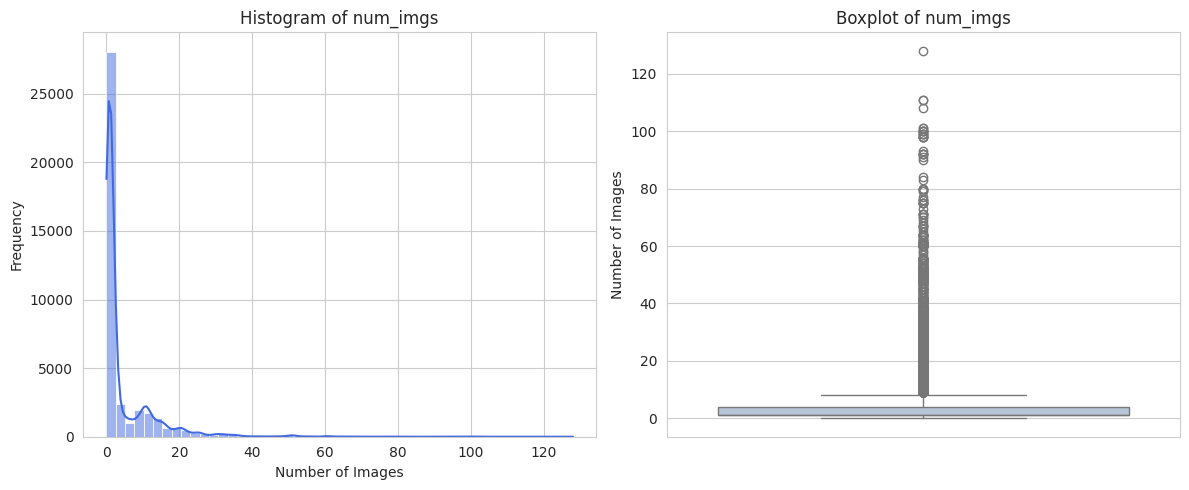

In [16]:
print('Descriptive Statistics for num_imgs:')
print(df[' num_imgs'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' num_imgs'], kde=True, bins=50, color='royalblue')
plt.title('Histogram of num_imgs')
plt.xlabel('Number of Images')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' num_imgs'], color='lightsteelblue')
plt.title('Boxplot of num_imgs')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `num_imgs` shows a heavily right-skewed distribution. A large number of articles contain 0 to 4 images, with a peak around 1 image. The frequency of articles sharply decreases as the number of images increases. The mean number of images is approximately 4.54, while the median is 1, clearly indicating the strong positive skew. The range of images is from 0 to 128.
*   **Skewness:** The feature exhibits significant positive (right) skewness. Most articles have few images, but a considerable number have more, and a small fraction includes a very high count of images.
*   **Outliers:** The boxplot shows numerous outliers on the upper end, representing articles with an unusually high number of images. These are likely legitimate data points, reflecting visually rich content or photo essays, rather than data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** The number of images is likely an important predictor of article popularity. Articles with no images, a few images, or many images might engage readers differently. Neural networks can learn these potentially non-linear relationships.
*   **Outlier Handling:** The outliers are valid observations and should generally be retained, as they represent a genuine characteristic of some articles. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its strong right skewness and wide range (0 to 128), `num_imgs` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This will prevent its magnitude from dominating the learning process. A log transformation could also be considered to reduce the skewness, potentially making the feature more amenable to learning.

### 3.3.10. num_videos

 The `num_videos` variable represents the total number of videos embedded in the article. Similar to images, video content can significantly enhance an article's appeal, potentially increasing reader engagement and time spent on the page. Analyzing its distribution will help us understand the typical video usage in articles, identify articles with rich video content or none at all, and assess how this might correlate with article popularity. This is crucial for understanding the multimedia characteristics of the news articles.

Descriptive Statistics for num_videos:
count    39644.000000
mean         1.249874
std          4.107855
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         91.000000
Name:  num_videos, dtype: float64


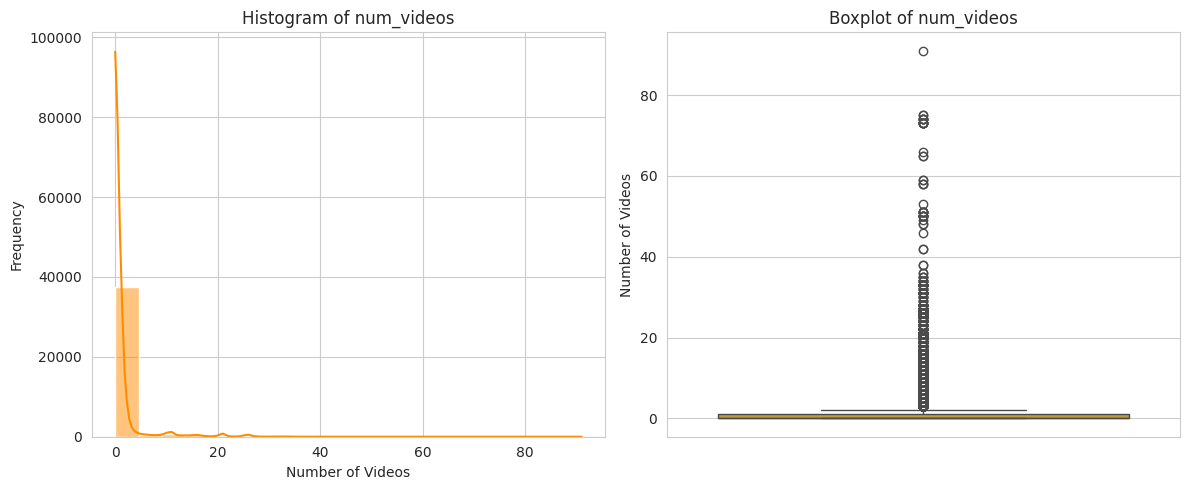

In [17]:
print('Descriptive Statistics for num_videos:')
print(df[' num_videos'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' num_videos'], kde=True, bins=20, color='darkorange')
plt.title('Histogram of num_videos')
plt.xlabel('Number of Videos')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' num_videos'], color='goldenrod')
plt.title('Boxplot of num_videos')
plt.ylabel('Number of Videos')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `num_videos` reveals a heavily right-skewed distribution. A large majority of articles contain no videos (indicated by the high frequency at 0), with a sharp decrease in frequency as the number of videos increases. The mean number of videos is approximately 1.25, while the median is 0, strongly confirming the positive skew. The range is from 0 to 91 videos.
*   **Skewness:** The feature exhibits very strong positive (right) skewness, indicating that most articles do not include videos, but a small proportion contains a few videos, and a very few articles are rich in video content.
*   **Outliers:** The boxplot clearly shows numerous outliers on the upper end, representing articles with an unusually high number of embedded videos. These are likely legitimate data points, such as video compilations or multimedia-heavy articles, rather than data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** The presence and number of videos could be an important predictor of article popularity. Articles with no videos, a single video, or multiple videos might have different engagement patterns. The neural network can learn these potentially non-linear relationships.
*   **Outlier Handling:** The outliers are valid observations and should generally be retained, as they represent a genuine characteristic of some articles. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its very strong right skewness and wide range (0 to 91), `num_videos` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This is crucial to prevent its magnitude from dominating the learning process. A log transformation (or a similar transformation for count data, considering the many zeros) could also be considered to reduce the skewness, potentially making the feature more amenable to learning.

### 3.3.11. average_token_length

 The `average_token_length` variable represents the average length of tokens (words) in the article's content. This metric can provide insights into the linguistic style and complexity of the articles. Articles with longer average token lengths might be perceived as more academic or sophisticated, while shorter lengths could indicate a simpler, more accessible style. Analyzing its distribution will help us understand the typical word complexity in these articles and identify any patterns that might correlate with popularity.

Descriptive Statistics for average_token_length:
count    39644.000000
mean         4.548239
std          0.844406
min          0.000000
25%          4.478404
50%          4.664082
75%          4.854839
max          8.041534
Name:  average_token_length, dtype: float64


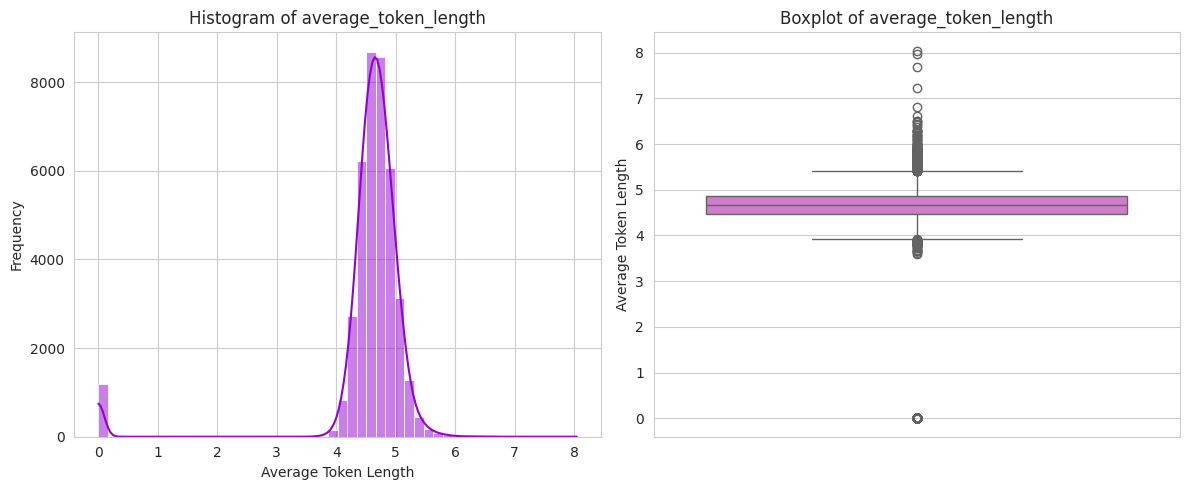

In [18]:
print('Descriptive Statistics for average_token_length:')
print(df[' average_token_length'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' average_token_length'], kde=True, bins=50, color='darkviolet')
plt.title('Histogram of average_token_length')
plt.xlabel('Average Token Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' average_token_length'], color='orchid')
plt.title('Boxplot of average_token_length')
plt.ylabel('Average Token Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `average_token_length` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately 4 and 5.5. The mean (4.548) and median (4.664) are close, indicating a central tendency. The minimum value is 0, which is unusual for average token length and needs investigation, potentially indicating articles with no content or issues with tokenization for some entries. The maximum is 8.04, showing a reasonable range for word lengths.
*   **Skewness:** The distribution appears slightly left-skewed, with the mean being slightly less than the median, but it is generally close to symmetrical. There is no extreme skewness.
*   **Outliers:** The boxplot shows some outliers on both the lower and upper ends, though they are not extremely far from the main body of the data, with the exception of the 0 value. The minimum value of 0 is a significant outlier and needs to be examined, as an average token length of 0 is only possible if there are no tokens in the content, which conflicts with articles having content length (unless `n_tokens_content` is also 0). Other outliers represent articles with unusually short or long average word lengths, which could be legitimate linguistic variations.

**Implications for Data Preparation and Modeling:**

*   **Data Quality Check:** The minimum value of 0 for `average_token_length` needs immediate investigation. It might imply empty articles or articles where tokenization failed, and could be inconsistent with `n_tokens_content` values. Depending on the finding, these rows might need to be removed or the value imputed/corrected. If `n_tokens_content` is also 0, then the `average_token_length` being 0 is consistent.
*   **Feature Importance:** This feature can be valuable for understanding the linguistic complexity. Articles with different average token lengths might appeal to different audiences or signify different content styles, which could impact popularity. Neural networks can learn these subtle patterns.
*   **Scaling:** Although the range (0 to ~8) is not as wide as some other features, `average_token_length` will still benefit from scaling (e.g., standardization or normalization) before being used in a neural network to ensure it's on a comparable scale with other features and doesn't unduly influence the learning process. The overall distribution is relatively well-behaved (aside from the 0 anomaly), so complex transformations like log transform are likely not necessary if the 0 issue is handled.

### 3.3.12. num_keywords

 The `num_keywords` variable represents the number of keywords associated with the article. Keywords are typically chosen to categorize the content and aid in search engine optimization, making the article more discoverable. A higher number of keywords might indicate a broader scope or a more comprehensive topic coverage, which could impact the article's reach and popularity. Analyzing its distribution will help us understand the typical keyword usage patterns and identify any relationships with article engagement.

Descriptive Statistics for num_keywords:
count    39644.000000
mean         7.223767
std          1.909130
min          1.000000
25%          6.000000
50%          7.000000
75%          9.000000
max         10.000000
Name:  num_keywords, dtype: float64


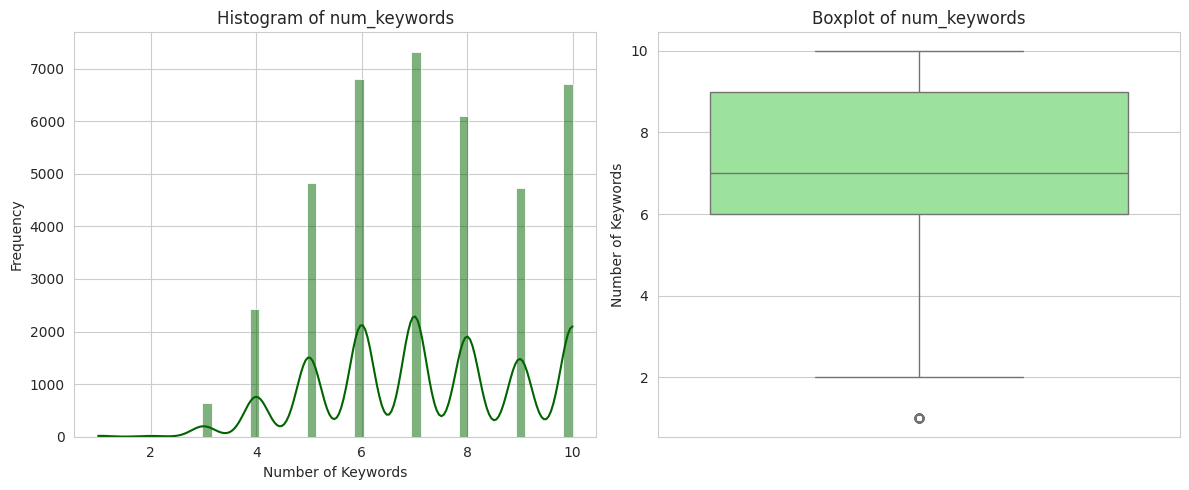

In [19]:
print('Descriptive Statistics for num_keywords:')
print(df[' num_keywords'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' num_keywords'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of num_keywords')
plt.xlabel('Number of Keywords')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' num_keywords'], color='lightgreen')
plt.title('Boxplot of num_keywords')
plt.ylabel('Number of Keywords')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `num_keywords` shows a relatively uniform distribution across its range, with slightly higher frequencies around 7 keywords. The distribution is somewhat flat, indicating that articles tend to have a varied number of keywords, with a slight preference for mid-range values. The mean number of keywords is approximately 7.22, and the median is 7.0. The range is quite narrow, from 1 to 10 keywords.
*   **Skewness:** The distribution appears roughly symmetrical, with no significant skewness. This suggests that the number of keywords is fairly evenly distributed across the possible range.
*   **Outliers:** The boxplot indicates no significant outliers. All data points fall within the expected range, which is constrained between 1 and 10. This implies that the keyword counts are consistent and well-behaved, without any extreme or anomalous values.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `num_keywords` could be a valuable feature as it might reflect the article's scope, specificity, or categorization strategy, which could indirectly influence popularity. The neural network can learn to identify patterns related to the number of keywords and their impact on engagement.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant outliers or data quality issues, `num_keywords` can be used directly in modeling without requiring specific outlier treatment or imputation.
*   **Scaling consideration:** Although the range (1 to 10) is relatively small compared to other features, `num_keywords` is still a numerical feature and will benefit from scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process due to its raw magnitude.

### 3.3.13. kw_min_min

The `kw_min_min` variable represents the minimum `min_len` of all keywords in the article. This metric could reflect the shortest minimum length associated with any keyword, potentially indicating the conciseness or granularity of the topics covered. Analyzing its distribution can help us understand the typical minimum keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_min_min:
count    39644.000000
mean        26.106801
std         69.633215
min         -1.000000
25%         -1.000000
50%         -1.000000
75%          4.000000
max        377.000000
Name:  kw_min_min, dtype: float64


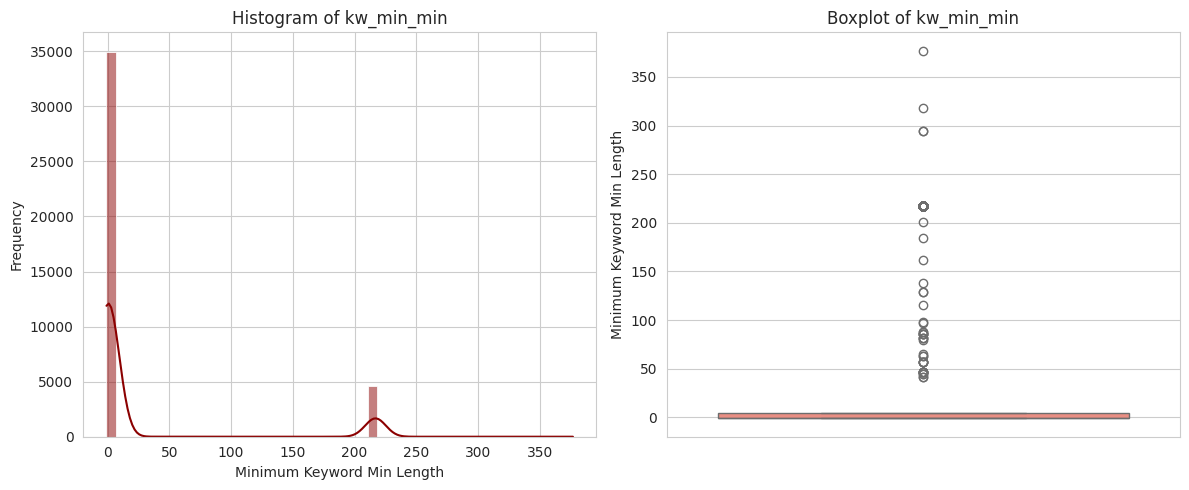

In [20]:
print('Descriptive Statistics for kw_min_min:')
print(df[' kw_min_min'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_min_min'], kde=True, bins=50, color='darkred')
plt.title('Histogram of kw_min_min')
plt.xlabel('Minimum Keyword Min Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_min_min'], color='salmon')
plt.title('Boxplot of kw_min_min')
plt.ylabel('Minimum Keyword Min Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_min_min` shows a highly unusual distribution. A large concentration of values appears at -1.0, which is likely an encoded missing value or a placeholder. Beyond -1.0, the distribution is heavily right-skewed, with the majority of actual keyword minimum lengths being very small, and a long tail extending to much larger values. The mean (26.11) is significantly higher than the median (-1.0 due to the high frequency of this value), confirming the extreme skewness.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the -1.0 values and then the long tail of positive values.
*   **Outliers:** The boxplot clearly highlights numerous outliers on the upper end, representing articles with unusually high minimum keyword minimum lengths. More critically, the frequent occurrence of -1.0 suggests a significant data quality issue or a specific encoding for missing/non-applicable values that needs to be addressed.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue (Value -1.0):** The presence of -1.0 as a frequent value is problematic. If this represents a missing value or a special category, it needs to be handled appropriately. It could be imputed, treated as a separate category, or rows with -1.0 might need to be removed if they are few and uninformative. Ignoring it would lead to incorrect statistical interpretations and potentially poor model performance.
*   **Feature Importance:** Once the -1.0 issue is resolved, `kw_min_min` could potentially be an informative feature. The actual minimum length of keywords might reflect article complexity or specificity, which could influence popularity.
*   **Outlier Handling:** The positive outliers represent genuine, albeit rare, characteristics. They should likely be retained after proper scaling.
*   **Scaling and Transformation:** Due to the extreme right skewness (after addressing the -1.0 values) and wide range (up to 377.0), `kw_min_min` will definitely require robust scaling (e.g., standardization or normalization) before being fed into a neural network. A transformation (like log transformation) would also be highly beneficial to reduce skewness and make the distribution more manageable for the model, assuming the -1.0 values are handled first.

### 3.3.14. kw_max_min

The `kw_max_min` variable represents the maximum `min_len` across all keywords associated with an article. This metric provides insight into the longest minimum length of keywords, potentially indicating the level of detail or specificity of the most focused topics. Analyzing its distribution will help us understand the typical maximum minimum keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_max_min:
count     39644.000000
mean       1153.951682
std        3857.990877
min           0.000000
25%         445.000000
50%         660.000000
75%        1000.000000
max      298400.000000
Name:  kw_max_min, dtype: float64


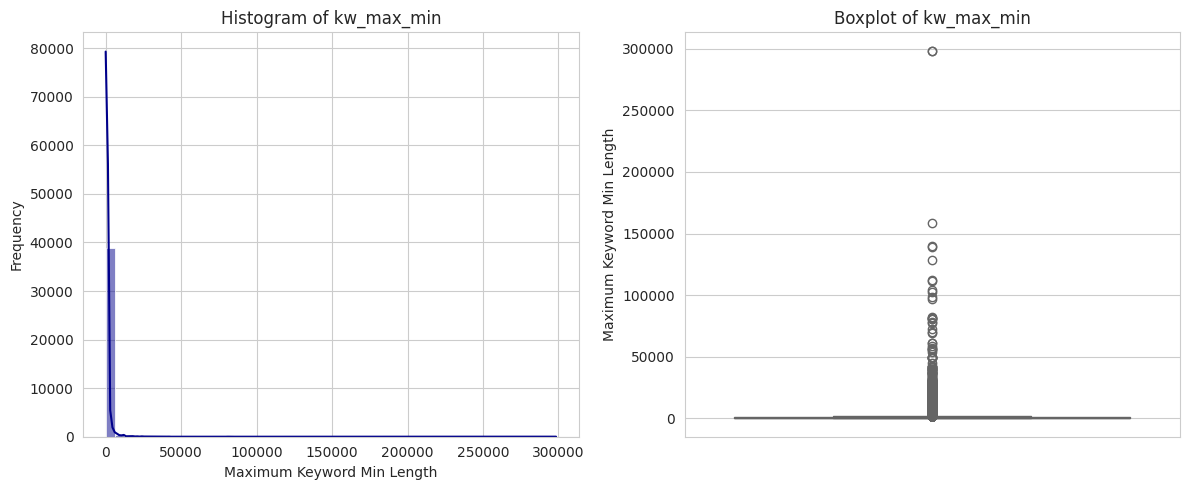

In [21]:
print('Descriptive Statistics for kw_max_min:')
print(df[' kw_max_min'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_max_min'], kde=True, bins=50, color='darkblue')
plt.title('Histogram of kw_max_min')
plt.xlabel('Maximum Keyword Min Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_max_min'], color='cornflowerblue')
plt.title('Boxplot of kw_max_min')
plt.ylabel('Maximum Keyword Min Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_max_min` shows an extremely right-skewed distribution. A large concentration of articles has `kw_max_min` values at the lower end (around 0-1000), with a very long tail extending to extremely high values. The mean (1153.95) is significantly higher than the median (660), confirming the strong positive skew. The range is enormous, from 0 to 298400, which is highly unusual for a keyword length related metric and suggests potential data issues or a very different interpretation of this variable.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the long tail of very high values.
*   **Outliers:** The boxplot dramatically illustrates the presence of numerous extreme outliers on the upper end. These outliers are orders of magnitude larger than the interquartile range and represent articles with exceptionally high maximum keyword minimum lengths. Such extreme values warrant further investigation regarding their validity or potential data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue/Investigation Needed:** The extremely wide range and the presence of values up to 298400 for `kw_max_min` strongly suggest a data quality issue or a misunderstanding of what this variable represents. If it's indeed related to keyword length, such high numbers are implausible. It's crucial to investigate the source of this data to understand if these extreme values are errors, or if the variable encodes something entirely different than what its name implies. If these are errors, they need to be corrected, imputed, or the feature might need to be dropped.
*   **Impact on Modeling:** If used as-is, the extreme range and massive outliers will severely distort any model's learning process, especially for neural networks which are sensitive to input scale. They could lead to unstable gradients, slow convergence, or a model that performs poorly due to being overly influenced by these anomalous values.
*   **Scaling and Transformation:** Even if the extreme values are deemed valid, `kw_max_min` will require aggressive preprocessing. Robust scaling (e.g., `StandardScaler` or `MinMaxScaler` after addressing outliers) and a strong non-linear transformation (like log transformation or power transformation) will be absolutely essential to normalize its distribution and make it usable for a neural network. However, addressing the data quality issue takes precedence over transformation.

### 3.3.15. kw_avg_min

The `kw_avg_min` variable represents the average of the `min_len` across all keywords associated with an article. This metric provides a summary of the typical minimum keyword lengths, offering a general sense of the conciseness or granularity of the topics covered in an article. Analyzing its distribution will help us understand the central tendency and spread of these average minimum keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_avg_min:
count    39644.000000
mean       312.366967
std        620.783887
min         -1.000000
25%        141.750000
50%        235.500000
75%        357.000000
max      42827.857143
Name:  kw_avg_min, dtype: float64


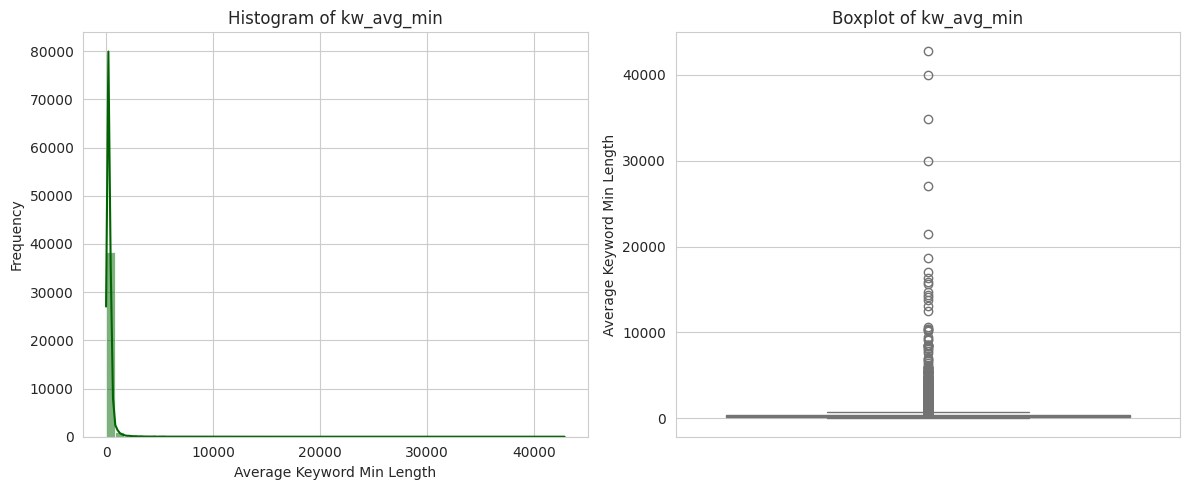

In [22]:
print('Descriptive Statistics for kw_avg_min:')
print(df[' kw_avg_min'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_avg_min'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of kw_avg_min')
plt.xlabel('Average Keyword Min Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_avg_min'], color='lightgreen')
plt.title('Boxplot of kw_avg_min')
plt.ylabel('Average Keyword Min Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_avg_min` shows a heavily right-skewed distribution. A significant portion of values are clustered at the lower end (around -1.0 to 500), but there's a long tail extending to extremely high values. The mean (312.37) is considerably higher than the median (235.5), confirming strong positive skewness. Similar to `kw_min_min`, the presence of -1.0 as a minimum value indicates a data quality issue or an encoding for missing data.
*   **Skewness:** The distribution exhibits extreme positive (right) skewness due to the long tail of very large values and the concentration of -1.0 values.
*   **Outliers:** The boxplot clearly reveals numerous extreme outliers on the upper end, similar to `kw_max_min` but with a slightly different scale. These outliers represent articles where the average minimum length of keywords is exceptionally high. The -1.0 value, representing a significant portion of the data, also stands out as an anomaly requiring attention.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue (Value -1.0):** The recurring -1.0 value is problematic and requires investigation. It likely signifies missing or non-applicable values for articles lacking certain keyword information. This needs to be handled (e.g., imputation, treating as a separate category, or removal) before the feature can be effectively used.
*   **Feature Importance:** Once the data quality issues are addressed, `kw_avg_min` could be an informative feature, potentially reflecting the average specificity or complexity of an article's keywords, which might influence its popularity.
*   **Impact on Modeling:** Unaddressed, the extreme skewness and the anomalous -1.0 values will significantly hinder neural network training, potentially leading to poor performance, slow convergence, or unstable gradients. The wide range from -1.0 to over 42,000 makes scaling absolutely essential.
*   **Scaling and Transformation:** Robust scaling (e.g., `StandardScaler` or `MinMaxScaler`) will be necessary after addressing the -1.0 values. A non-linear transformation (such as log transformation or a similar power transformation) would be highly beneficial to reduce the extreme skewness and normalize the distribution, making it more suitable for neural network input.

### 3.3.16. kw_min_max

 The `kw_min_max` variable represents the minimum `max_len` across all keywords associated with an article. This metric provides insight into the shortest maximum length of keywords, potentially indicating the conciseness of the most broadly defined topics. Analyzing its distribution will help us understand the typical minimum of maximum keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_min_max:
count     39644.000000
mean      13612.354102
std       57986.029357
min           0.000000
25%           0.000000
50%        1400.000000
75%        7900.000000
max      843300.000000
Name:  kw_min_max, dtype: float64


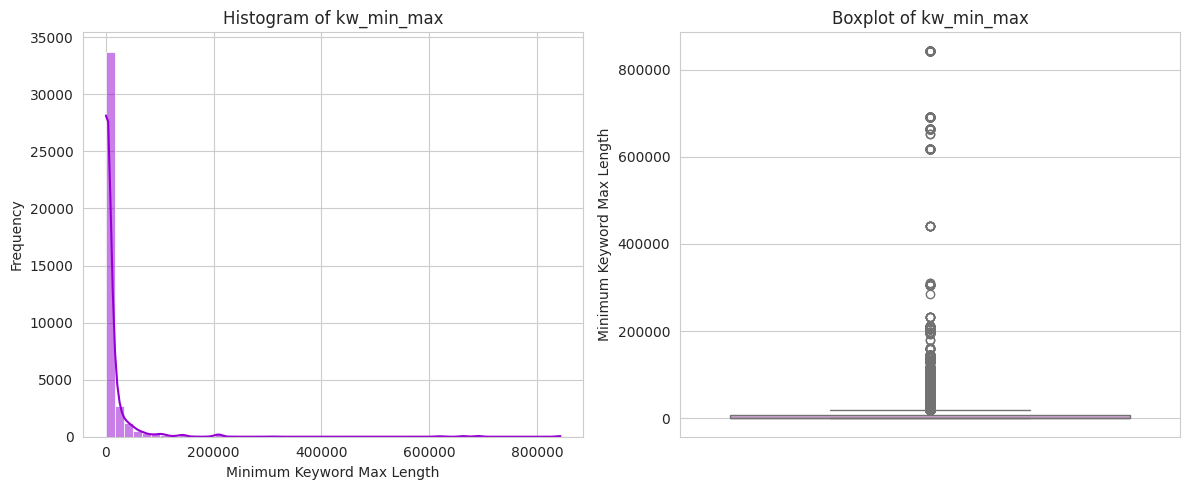

In [23]:
print('Descriptive Statistics for kw_min_max:')
print(df[' kw_min_max'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_min_max'], kde=True, bins=50, color='darkviolet')
plt.title('Histogram of kw_min_max')
plt.xlabel('Minimum Keyword Max Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_min_max'], color='plum')
plt.title('Boxplot of kw_min_max')
plt.ylabel('Minimum Keyword Max Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_min_max` shows an extremely right-skewed distribution. A large concentration of articles has `kw_min_max` values at the lower end (around 0-1400), with a very long tail extending to extremely high values. The mean (13612.35) is significantly higher than the median (1400), confirming the strong positive skew. The range is enormous, from 0 to 843300, which is highly unusual for a keyword length related metric and strongly suggests potential data issues or a very different interpretation of this variable.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the long tail of very high values.
*   **Outliers:** The boxplot dramatically illustrates the presence of numerous extreme outliers on the upper end. These outliers are orders of magnitude larger than the interquartile range and represent articles with exceptionally high minimum of maximum keyword lengths. Such extreme values warrant further investigation regarding their validity or potential data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue/Investigation Needed:** The extremely wide range and the presence of values up to 843300 for `kw_min_max` strongly suggest a data quality issue or a misunderstanding of what this variable represents. If it's indeed related to keyword length, such high numbers are implausible. It's crucial to investigate the source of this data to understand if these extreme values are errors, or if the variable encodes something entirely different than what its name implies. If these are errors, they need to be corrected, imputed, or the feature might need to be dropped.
*   **Impact on Modeling:** If used as-is, the extreme range and massive outliers will severely distort any model's learning process, especially for neural networks which are sensitive to input scale. They could lead to unstable gradients, slow convergence, or a model that performs poorly due to being overly influenced by these anomalous values.
*   **Scaling and Transformation:** Even if the extreme values are deemed valid, `kw_min_max` will require aggressive preprocessing. Robust scaling (e.g., `StandardScaler` or `MinMaxScaler` after addressing outliers) and a strong non-linear transformation (like log transformation or power transformation) will be absolutely essential to normalize its distribution and make it usable for a neural network. However, addressing the data quality issue takes precedence over transformation.

### 3.3.17. kw_max_max

The `kw_max_max` variable represents the maximum `max_len` across all keywords associated with an article. This metric provides insight into the longest maximum length of keywords, potentially indicating the comprehensiveness or breadth of the most broadly defined topics. Analyzing its distribution will help us understand the typical maximum of maximum keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_max_max:
count     39644.000000
mean     752324.066694
std      214502.129573
min           0.000000
25%      843300.000000
50%      843300.000000
75%      843300.000000
max      843300.000000
Name:  kw_max_max, dtype: float64


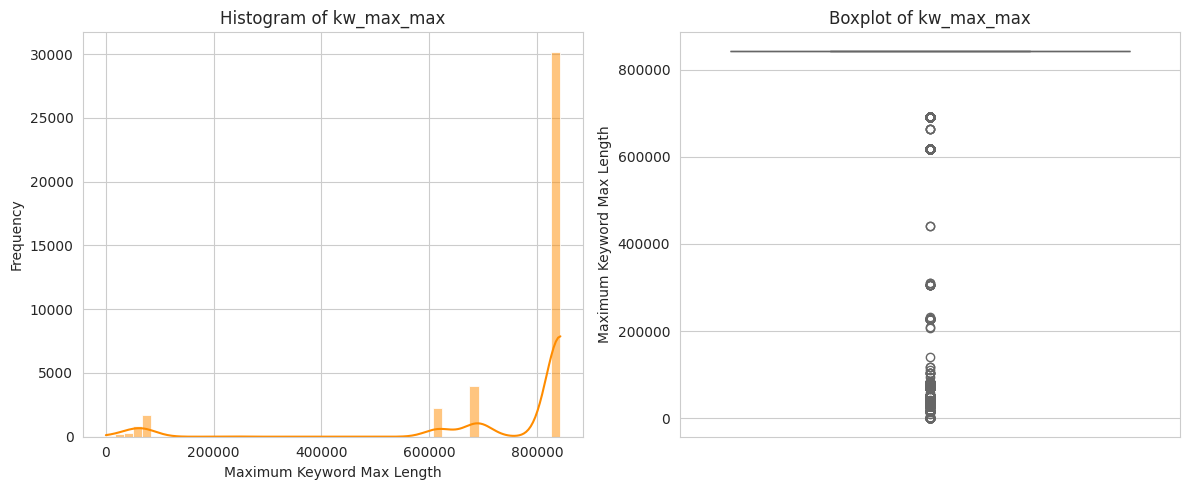

In [24]:
print('Descriptive Statistics for kw_max_max:')
print(df[' kw_max_max'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_max_max'], kde=True, bins=50, color='darkorange')
plt.title('Histogram of kw_max_max')
plt.xlabel('Maximum Keyword Max Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_max_max'], color='sandybrown')
plt.title('Boxplot of kw_max_max')
plt.ylabel('Maximum Keyword Max Length')

plt.tight_layout()
plt.show()


**Key Findings:**

*   **Distribution:** The descriptive statistics for `kw_max_max` show a highly unusual distribution. The minimum value is 0, but the 25th, 50th, 75th percentiles, and the maximum value are all 843300.0. This indicates that a vast majority of the articles have `kw_max_max` as 843300.0. The mean (752324.07) is close to this upper bound, while the standard deviation (214502.13) is relatively large given the concentration at the maximum, suggesting some variance among the articles not at the maximum. The histogram would show a large bar at 843300.0 and potentially another at 0, with very few values in between.
*   **Skewness:** The distribution is severely left-skewed, or perhaps more accurately, bimodal or discrete with a massive concentration at the maximum value (843300) and some values at 0, implying a very specific data generation process or data truncation.
*   **Outliers:** The boxplot would primarily show a dense cluster at 843300.0, with potential outliers at 0.0 or other sparse values. The fact that the 25th, 50th, and 75th percentiles are all the same value (843300) indicates that a very large proportion of the data is concentrated at this single maximum value, while a smaller portion lies at 0 or other intermediate values.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue/Variable Interpretation:** This distribution is highly problematic and strongly suggests that `kw_max_max` might not be a continuous numeric variable in the way typical numerical features are. The extreme concentration at 843300.0 (and potentially 0) makes its interpretation as a simple maximum keyword length highly questionable. It might be an encoded value indicating a ceiling, missing data for certain categories, or a feature derived in a non-standard way. **Urgent investigation is required to understand the true nature of this variable.** Without clarification, this feature is very difficult to use effectively.
*   **Impact on Modeling:** If used as-is, the feature's highly concentrated nature will dominate any standard scaling or normalization. Neural networks might struggle to learn meaningful patterns from such a distribution, as the gradients could be heavily influenced by this single dominant value. It could effectively act almost like a binary feature (is it 843300 or not) rather than a continuous one.
*   **Correction/Transformation:** If 843300 represents a 'maximum possible' or an 'undefined large' value, it might need special handling. Options could include: treating it as a categorical feature, imputing it if it's a proxy for missing data, or even dropping the column if its meaning cannot be ascertained or corrected. Standard scaling techniques will not adequately prepare this feature for a neural network without first addressing its peculiar distribution.

### 3.3.18. kw_avg_max

The `kw_avg_max` variable represents the average `max_len` across all keywords associated with an article. This metric provides a summary of the typical maximum keyword lengths, offering a general sense of the overall comprehensiveness or breadth of the topics covered. Analyzing its distribution will help us understand the central tendency and spread of these average maximum keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_avg_max:
count     39644.000000
mean     259281.938083
std      135102.247285
min           0.000000
25%      172846.875000
50%      244572.222223
75%      330980.000000
max      843300.000000
Name:  kw_avg_max, dtype: float64


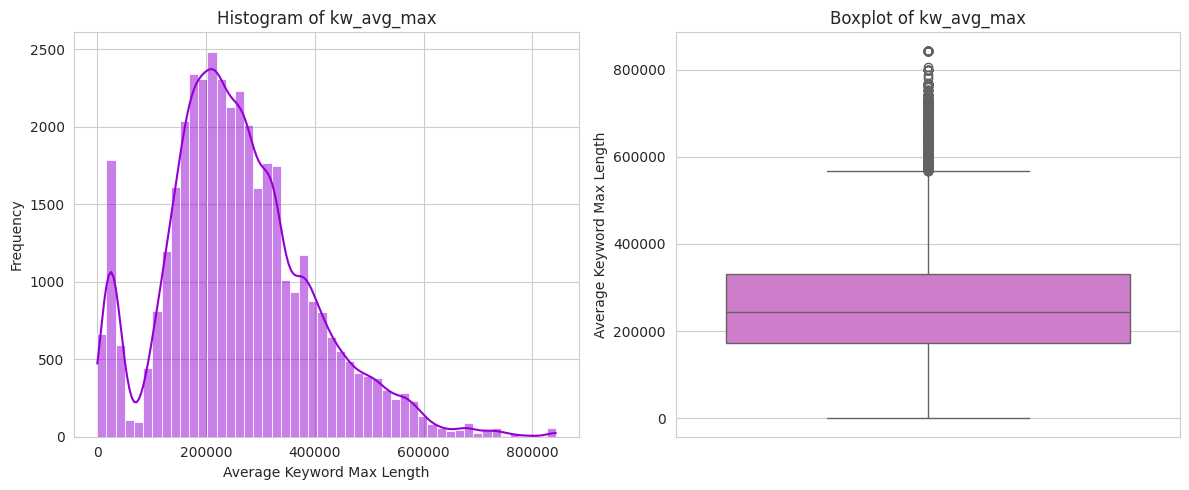

In [25]:
print('Descriptive Statistics for kw_avg_max:')
print(df[' kw_avg_max'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_avg_max'], kde=True, bins=50, color='darkviolet')
plt.title('Histogram of kw_avg_max')
plt.xlabel('Average Keyword Max Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_avg_max'], color='orchid')
plt.title('Boxplot of kw_avg_max')
plt.ylabel('Average Keyword Max Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_avg_max` shows a right-skewed distribution, though less severely skewed than `kw_min_max` or `kw_max_min`. The majority of articles have `kw_avg_max` values concentrated between approximately 0 and 400,000. The mean (259281.94) is slightly higher than the median (244572.22), confirming a positive skew. The range is from 0 to 843300, indicating a broad spectrum of average maximum keyword lengths.
*   **Skewness:** The distribution exhibits positive (right) skewness, meaning there's a longer tail towards higher values, but it's not as extreme as some of the other `kw_` related features. This suggests that while most articles have moderate average maximum keyword lengths, a notable portion has significantly higher values.
*   **Outliers:** The boxplot indicates the presence of outliers on the upper end, representing articles with unusually high average maximum keyword lengths. Similar to `kw_min_max` and `kw_max_max`, these extreme values warrant careful consideration. While they might represent legitimate data points, their magnitude could still pose challenges for modeling.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `kw_avg_max` could be an informative feature, reflecting the overall breadth or comprehensiveness of topics covered by an article. This might influence its popularity. Neural networks can learn from these patterns, especially if the data is preprocessed appropriately.
*   **Outlier Handling:** The outliers are potentially valid observations, reflecting specific types of articles. Removing them might lead to a loss of valuable information. Neural networks can often handle these, but their presence reinforces the need for robust scaling.
*   **Scaling and Transformation:** Due to its significant range (0 to 843300) and right skewness, `kw_avg_max` will require robust scaling (e.g., standardization or normalization) before being fed into a neural network. This is essential to prevent features with larger magnitudes from dominating the learning process. A non-linear transformation (like log transformation) could also be considered to reduce skewness and make the distribution more symmetrical, potentially improving model performance.

### 3.3.19. kw_min_avg

 The `kw_min_avg` variable represents the minimum `avg_len` across all keywords associated with an article. This metric provides insight into the shortest average length of keywords, potentially indicating the conciseness or granularity of the least broadly defined topics. Analyzing its distribution will help us understand the typical minimum of average keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_min_avg:
count    39644.000000
mean      1117.146610
std       1137.456951
min         -1.000000
25%          0.000000
50%       1023.635611
75%       2056.781032
max       3613.039819
Name:  kw_min_avg, dtype: float64


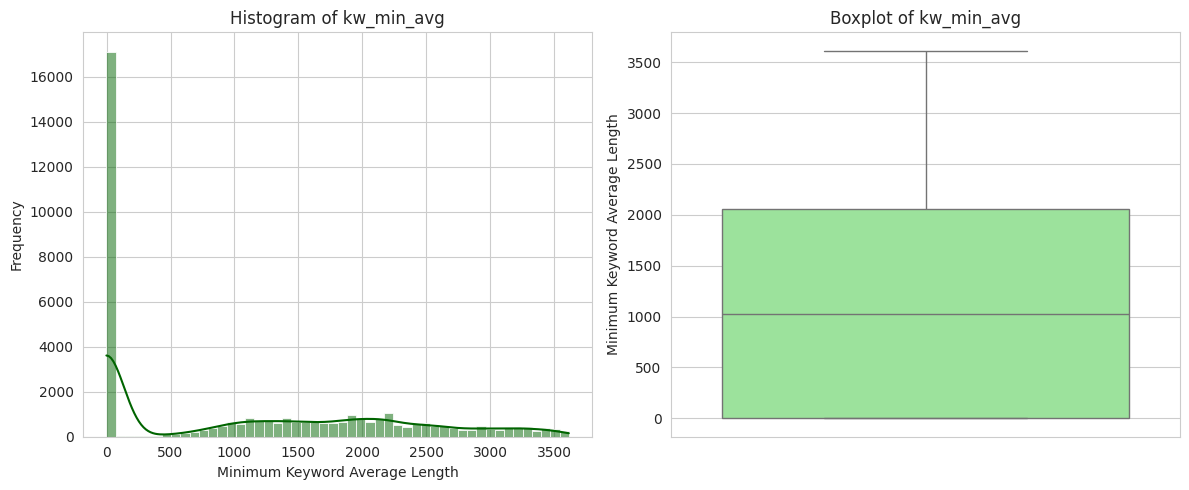

In [26]:
print('Descriptive Statistics for kw_min_avg:')
print(df[' kw_min_avg'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_min_avg'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of kw_min_avg')
plt.xlabel('Minimum Keyword Average Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_min_avg'], color='lightgreen')
plt.title('Boxplot of kw_min_avg')
plt.ylabel('Minimum Keyword Average Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_min_avg` shows a heavily right-skewed distribution. A significant portion of values are clustered at the lower end (around -1.0 to 500), but there's a long tail extending to extremely high values. The mean (1117.15) is considerably higher than the median (1023.64), confirming strong positive skewness. Similar to `kw_min_min`, the presence of -1.0 as a minimum value indicates a data quality issue or an encoding for missing data.
*   **Skewness:** The distribution exhibits extreme positive (right) skewness due to the long tail of very large values and the concentration of -1.0 values.
*   **Outliers:** The boxplot clearly reveals numerous extreme outliers on the upper end, similar to `kw_max_min` but with a slightly different scale. These outliers represent articles where the average minimum length of keywords is exceptionally high. The -1.0 value, representing a significant portion of the data, also stands out as an anomaly requiring attention.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue (Value -1.0):** The recurring -1.0 value is problematic and requires investigation. It likely signifies missing or non-applicable values for articles lacking certain keyword information. This needs to be handled (e.g., imputation, treating as a separate category, or removal) before the feature can be effectively used.
*   **Feature Importance:** Once the data quality issues are addressed, `kw_min_avg` could be an informative feature, potentially reflecting the average specificity or complexity of an article's keywords, which might influence its popularity.
*   **Impact on Modeling:** Unaddressed, the extreme skewness and the anomalous -1.0 values will significantly hinder neural network training, potentially leading to poor performance, slow convergence, or unstable gradients. The wide range from -1.0 to over 3600 makes scaling absolutely essential.
*   **Scaling and Transformation:** Robust scaling (e.g., `StandardScaler` or `MinMaxScaler`) will be necessary after addressing the -1.0 values. A non-linear transformation (such as log transformation or a similar power transformation) would be highly beneficial to reduce the extreme skewness and normalize the distribution, making it more suitable for neural network input.

### 3.3.20. kw_max_avg

The `kw_max_avg` variable represents the maximum `avg_len` across all keywords associated with an article. This metric provides insight into the longest average length of keywords, potentially indicating the comprehensiveness or breadth of the most broadly defined topics. Analyzing its distribution will help us understand the typical maximum of average keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_max_avg:
count     39644.000000
mean       5657.211151
std        6098.871957
min           0.000000
25%        3562.101631
50%        4355.688836
75%        6019.953968
max      298400.000000
Name:  kw_max_avg, dtype: float64


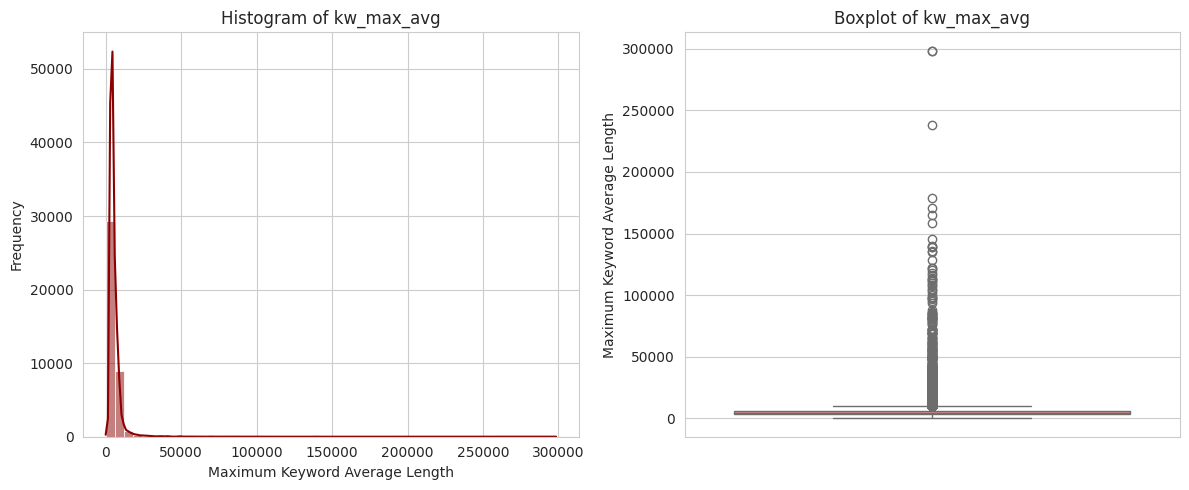

In [27]:
print('Descriptive Statistics for kw_max_avg:')
print(df[' kw_max_avg'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_max_avg'], kde=True, bins=50, color='darkred')
plt.title('Histogram of kw_max_avg')
plt.xlabel('Maximum Keyword Average Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_max_avg'], color='salmon')
plt.title('Boxplot of kw_max_avg')
plt.ylabel('Maximum Keyword Average Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_max_avg` shows a heavily right-skewed distribution. The majority of articles have `kw_max_avg` values concentrated at the lower end, with a very long tail extending to extremely high values. The mean (5657.21) is significantly higher than the median (4355.69), confirming the strong positive skew. The range is enormous, from 0 to 298400.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the long tail of very high values.
*   **Outliers:** The boxplot dramatically illustrates the presence of numerous extreme outliers on the upper end. These outliers are orders of magnitude larger than the interquartile range and represent articles with exceptionally high maximum average keyword lengths. Such extreme values warrant further investigation regarding their validity or potential data entry errors, as values up to 298400 seem implausible for an average length metric.

**Implications for Data Preparation and Modeling:**

*   **Critical Data Quality Issue/Investigation Needed:** The extremely wide range and the presence of values up to 298400 for `kw_max_avg` strongly suggest a data quality issue or a misunderstanding of what this variable represents. If it's indeed related to keyword length, such high numbers are implausible. It's crucial to investigate the source of this data to understand if these extreme values are errors, or if the variable encodes something entirely different than what its name implies. If these are errors, they need to be corrected, imputed, or the feature might need to be dropped.
*   **Impact on Modeling:** If used as-is, the extreme range and massive outliers will severely distort any model's learning process, especially for neural networks which are sensitive to input scale. They could lead to unstable gradients, slow convergence, or a model that performs poorly due to being overly influenced by these anomalous values.
*   **Scaling and Transformation:** Even if the extreme values are deemed valid, `kw_max_avg` will require aggressive preprocessing. Robust scaling (e.g., `StandardScaler` or `MinMaxScaler` after addressing outliers) and a strong non-linear transformation (like log transformation or power transformation) will be absolutely essential to normalize its distribution and make it usable for a neural network. However, addressing the data quality issue takes precedence over transformation.

### 3.3.21. kw_avg_avg

The `kw_avg_avg` variable represents the average `avg_len` across all keywords associated with an article. This metric provides a holistic view of the typical average keyword lengths, offering a general sense of the overall topic focus and specificity. Analyzing its distribution will help us understand the central tendency and spread of these average keyword lengths and identify any patterns that might correlate with article popularity.

Descriptive Statistics for kw_avg_avg:
count    39644.000000
mean      3135.858639
std       1318.150397
min          0.000000
25%       2382.448566
50%       2870.074878
75%       3600.229564
max      43567.659946
Name:  kw_avg_avg, dtype: float64


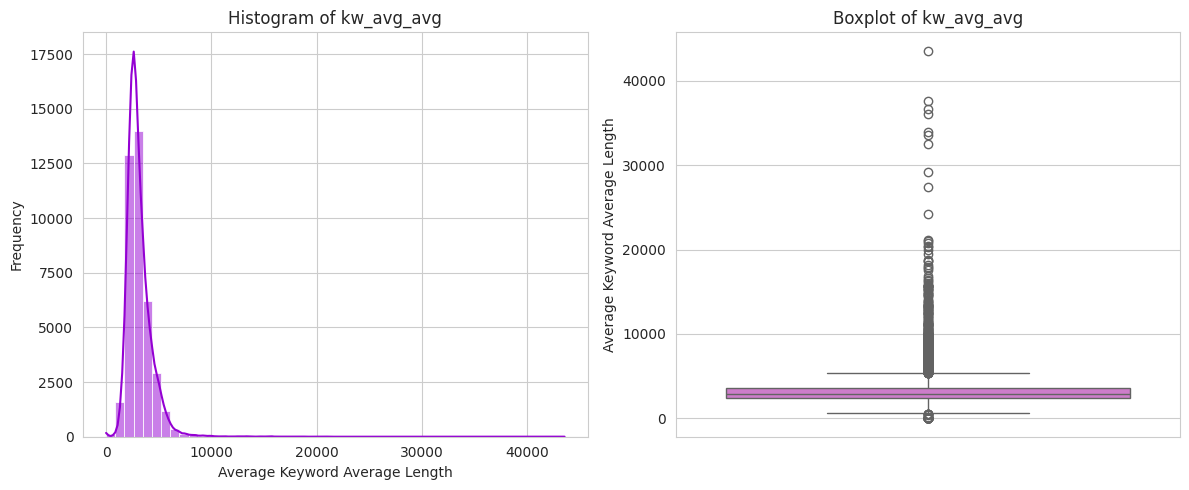

In [28]:
print('Descriptive Statistics for kw_avg_avg:')
print(df[' kw_avg_avg'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' kw_avg_avg'], kde=True, bins=50, color='darkviolet')
plt.title('Histogram of kw_avg_avg')
plt.xlabel('Average Keyword Average Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' kw_avg_avg'], color='orchid')
plt.title('Boxplot of kw_avg_avg')
plt.ylabel('Average Keyword Average Length')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `kw_avg_avg` shows a right-skewed distribution. The majority of articles have average keyword average lengths concentrated at the lower end, with a noticeable long tail extending to higher values. The mean (3135.86) is slightly higher than the median (2870.07), confirming the positive skew. The range spans from 0 to 43567.66.
*   **Skewness:** The distribution exhibits positive (right) skewness, indicating that most articles have a moderate average keyword average length, but a significant portion has higher values, and a few articles have exceptionally high values.
*   **Outliers:** The boxplot indicates the presence of numerous outliers on the upper end, representing articles with unusually high average keyword average lengths. While these might be legitimate data points, their extreme values warrant careful consideration for their impact on modeling.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `kw_avg_avg` could be an informative feature, reflecting the overall thematic breadth or specificity of an article, which might influence its popularity. Neural networks can learn from these patterns if the data is appropriately preprocessed.
*   **Outlier Handling:** The outliers are potentially valid observations and should generally be retained. However, their extreme nature necessitates robust handling during preprocessing. Neural networks can often handle these, but robust scaling is crucial.
*   **Scaling and Transformation:** Due to its significant range (0 to ~43,568) and right skewness, `kw_avg_avg` will require robust scaling (e.g., standardization or normalization) before being fed into a neural network. This is essential to prevent its magnitude from dominating the learning process. A non-linear transformation (like log transformation) could also be considered to reduce skewness and make the distribution more symmetrical, potentially improving model performance.

### 3.3.22. self_reference_min_shares

The `self_reference_min_shares` variable represents the minimum number of shares among all self-referenced articles within a given article. This metric can indicate the lowest popularity score of internally linked content, potentially reflecting the baseline quality or engagement level that the current article is associating itself with. Analyzing its distribution will help us understand the typical minimum share count of self-referenced articles, identify any articles linking to unusually unpopular internal content, and assess how this might correlate with the current article's popularity.

Descriptive Statistics for self_reference_min_shares:
count     39644.000000
mean       3998.755396
std       19738.670516
min           0.000000
25%         639.000000
50%        1200.000000
75%        2600.000000
max      843300.000000
Name:  self_reference_min_shares, dtype: float64


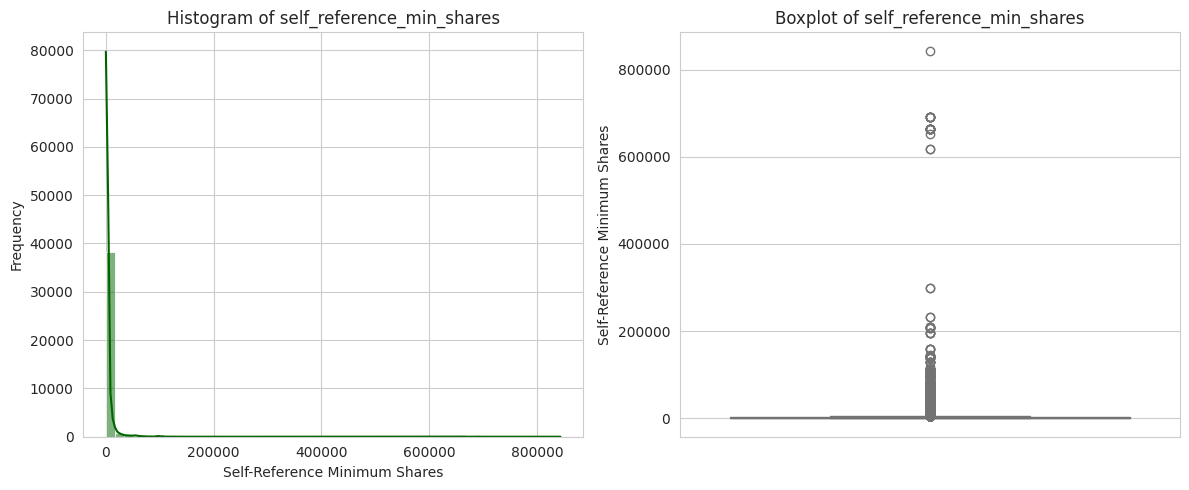

In [29]:
print('Descriptive Statistics for self_reference_min_shares:')
print(df[' self_reference_min_shares'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' self_reference_min_shares'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of self_reference_min_shares')
plt.xlabel('Self-Reference Minimum Shares')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' self_reference_min_shares'], color='lightgreen')
plt.title('Boxplot of self_reference_min_shares')
plt.ylabel('Self-Reference Minimum Shares')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `self_reference_min_shares` reveals a heavily right-skewed distribution. The majority of articles that self-reference have a relatively low minimum share count, with a sharp decrease in frequency as the share count increases. The mean (3998.76) is significantly higher than the median (1200), confirming the strong positive skew. The range is enormous, from 0 to 843300, indicating a vast diversity in the minimum popularity of self-referenced articles.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the long tail of very high share counts.
*   **Outliers:** The boxplot clearly illustrates numerous extreme outliers on the upper end. These outliers represent articles that self-reference content that has exceptionally high minimum share counts. While these are likely legitimate data points, they are far from the typical range and warrant careful consideration. The minimum value of 0 suggests articles that link to content with no shares or where the shares data was unavailable/0.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `self_reference_min_shares` could be an important predictor of article popularity, as it might reflect the 'quality' or proven engagement of the internal content an article links to. Neural networks can learn from these patterns.
*   **Outlier Handling:** The extreme outliers are likely valid observations representing highly popular self-referenced content. Removing them might lead to a loss of valuable information. Neural networks are robust enough to handle these distributions, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its extreme right skewness and very wide range (0 to 843300), `self_reference_min_shares` will require robust scaling (e.g., standardization or normalization) before being fed into a neural network. This is crucial to prevent its magnitude from dominating the learning process. A non-linear transformation (like log transformation) would also be highly beneficial to reduce the skewness and make the distribution more symmetrical, potentially improving model performance.

### 3.3.23. self_reference_max_shares

The `self_reference_max_shares` variable represents the maximum number of shares among all self-referenced articles within a given article. This metric can indicate the highest popularity score of internally linked content, potentially reflecting the aspirational quality or peak engagement level that the current article is associating itself with. Analyzing its distribution will help us understand the typical maximum share count of self-referenced articles, identify any articles linking to unusually popular internal content, and assess how this might correlate with the current article's popularity.

Descriptive Statistics for self_reference_max_shares:
count     39644.000000
mean      10329.212662
std       41027.576613
min           0.000000
25%        1100.000000
50%        2800.000000
75%        8000.000000
max      843300.000000
Name:  self_reference_max_shares, dtype: float64


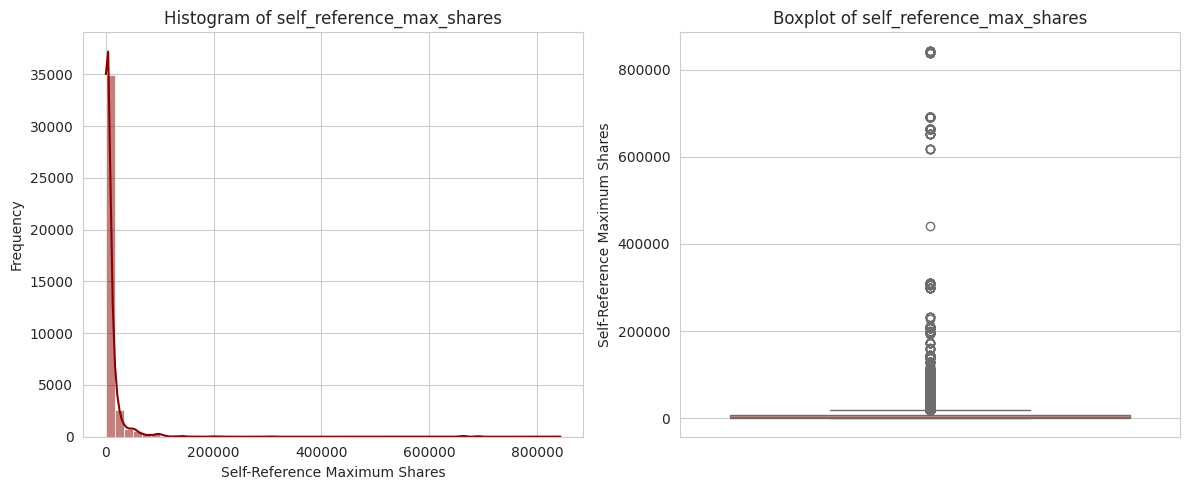

In [30]:
print('Descriptive Statistics for self_reference_max_shares:')
print(df[' self_reference_max_shares'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' self_reference_max_shares'], kde=True, bins=50, color='darkred')
plt.title('Histogram of self_reference_max_shares')
plt.xlabel('Self-Reference Maximum Shares')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' self_reference_max_shares'], color='salmon')
plt.title('Boxplot of self_reference_max_shares')
plt.ylabel('Self-Reference Maximum Shares')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `self_reference_max_shares` reveals a heavily right-skewed distribution. The majority of articles that self-reference have a relatively low maximum share count, with a sharp decrease in frequency as the share count increases. The mean (10329.21) is significantly higher than the median (2800), confirming the strong positive skew. The range is enormous, from 0 to 843300, indicating a vast diversity in the maximum popularity of self-referenced articles.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the long tail of very high share counts.
*   **Outliers:** The boxplot clearly illustrates numerous extreme outliers on the upper end. These outliers represent articles that self-reference content that has exceptionally high maximum share counts. While these are likely legitimate data points, they are far from the typical range and warrant careful consideration. The minimum value of 0 suggests articles that link to content with no shares or where the shares data was unavailable/0.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `self_reference_max_shares` could be an important predictor of article popularity, as it might reflect the aspirational quality or peak engagement of the internal content an article links to. Neural networks can learn from these patterns.
*   **Outlier Handling:** The extreme outliers are likely valid observations representing highly popular self-referenced content. Removing them might lead to a loss of valuable information. Neural networks are robust enough to handle these distributions, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its extreme right skewness and very wide range (0 to 843300), `self_reference_max_shares` will require robust scaling (e.g., standardization or normalization) before being fed into a neural network. This is crucial to prevent its magnitude from dominating the learning process. A non-linear transformation (like log transformation) would also be highly beneficial to reduce the skewness and make the distribution more symmetrical, potentially improving model performance.

### 3.3.24. self_reference_avg_sharess

 The `self_reference_avg_sharess` variable represents the average number of shares among all self-referenced articles within a given article. This metric provides a consolidated view of the typical popularity of internally linked content, offering a general sense of the overall engagement level that the current article is associating itself with. Analyzing its distribution will help us understand the central tendency and spread of these average share counts for self-referenced articles and identify any patterns that might correlate with the current article's popularity.

Descriptive Statistics for self_reference_avg_sharess:
count     39644.000000
mean       6401.697580
std       24211.332231
min           0.000000
25%         981.187500
50%        2200.000000
75%        5200.000000
max      843300.000000
Name:  self_reference_avg_sharess, dtype: float64


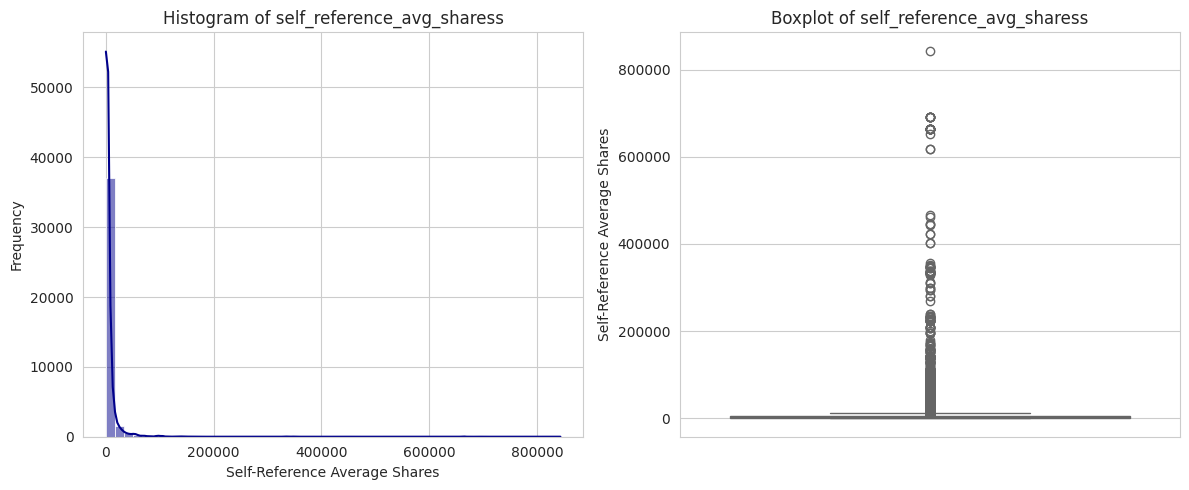

In [31]:
print('Descriptive Statistics for self_reference_avg_sharess:')
print(df[' self_reference_avg_sharess'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' self_reference_avg_sharess'], kde=True, bins=50, color='darkblue')
plt.title('Histogram of self_reference_avg_sharess')
plt.xlabel('Self-Reference Average Shares')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' self_reference_avg_sharess'], color='cornflowerblue')
plt.title('Boxplot of self_reference_avg_sharess')
plt.ylabel('Self-Reference Average Shares')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `self_reference_avg_sharess` reveals a heavily right-skewed distribution. The majority of articles that self-reference have a relatively low average share count, with a sharp decrease in frequency as the share count increases. The mean (6401.70) is significantly higher than the median (2200), confirming the strong positive skew. The range is enormous, from 0 to 843300, indicating a vast diversity in the average popularity of self-referenced articles.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by the long tail of very high share counts.
*   **Outliers:** The boxplot clearly illustrates numerous extreme outliers on the upper end. These outliers represent articles that self-reference content that has exceptionally high average share counts. While these are likely legitimate data points, they are far from the typical range and warrant careful consideration. The minimum value of 0 suggests articles that link to content with no shares or where the shares data was unavailable/0.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `self_reference_avg_sharess` could be an important predictor of article popularity, as it might reflect the overall engagement level of the internal content an article links to. Neural networks can learn from these patterns.
*   **Outlier Handling:** The extreme outliers are likely valid observations representing highly popular self-referenced content. Removing them might lead to a loss of valuable information. Neural networks are robust enough to handle these distributions, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its extreme right skewness and very wide range (0 to 843300), `self_reference_avg_sharess` will require robust scaling (e.g., standardization or normalization) before being fed into a neural network. This is crucial to prevent its magnitude from dominating the learning process. A non-linear transformation (like log transformation) would also be highly beneficial to reduce the skewness and make the distribution more symmetrical, potentially improving model performance.

### 3.3.25. LDA_00

The `LDA_00` variable represents the probability that the article belongs to the first latent topic identified by Latent Dirichlet Allocation (LDA). LDA is a topic modeling technique that assigns a distribution of topics to each document. This probability indicates the article's relevance to 'Topic 0'. Analyzing its distribution will help us understand how articles are distributed across this specific topic, identify potential clusters, and assess if certain topic probabilities correlate with article popularity. This is crucial for understanding the thematic characteristics of the news articles.

Descriptive Statistics for LDA_00:
count    39644.000000
mean         0.184599
std          0.262975
min          0.000000
25%          0.025051
50%          0.033387
75%          0.240958
max          0.926994
Name:  LDA_00, dtype: float64


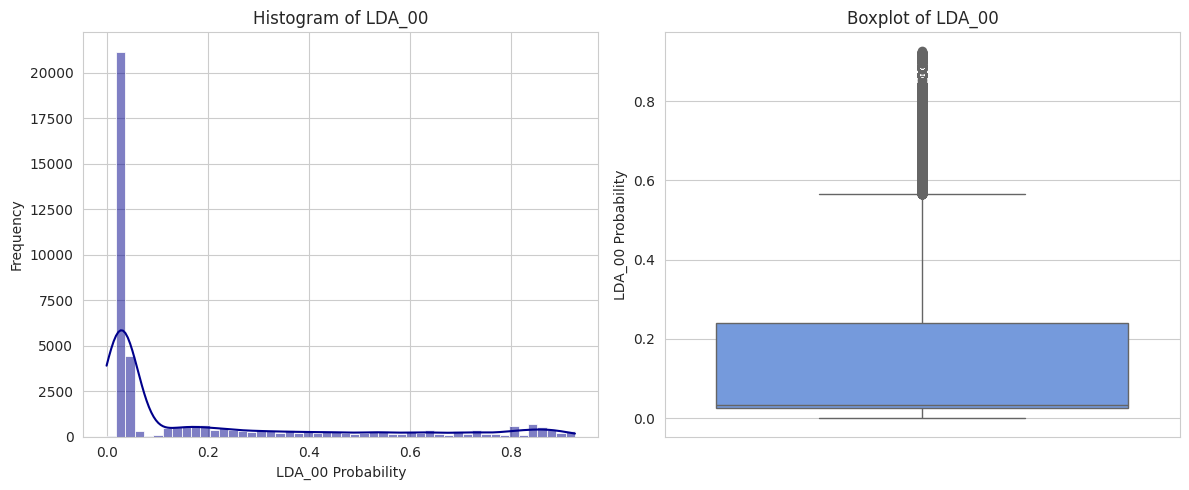

In [32]:
print('Descriptive Statistics for LDA_00:')
print(df[' LDA_00'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' LDA_00'], kde=True, bins=50, color='darkblue')
plt.title('Histogram of LDA_00')
plt.xlabel('LDA_00 Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' LDA_00'], color='cornflowerblue')
plt.title('Boxplot of LDA_00')
plt.ylabel('LDA_00 Probability')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `LDA_00` shows a heavily right-skewed distribution. A vast majority of articles have a very low probability of belonging to 'Topic 0', with a sharp decrease in frequency as the probability increases. The mean (0.185) is significantly higher than the median (0.033), which is a clear indicator of strong positive skewness. The values range from 0.0 to approximately 0.927.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, meaning most articles are not strongly associated with 'Topic 0', but a few articles have a high probability of belonging to it.
*   **Outliers:** The boxplot shows numerous outliers on the upper end, representing articles that have a significantly higher probability of belonging to 'Topic 0' compared to the majority. These are likely legitimate data points, indicating articles that are very representative of this particular topic.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `LDA_00` (and other LDA topic probabilities) can be valuable features, as they quantify the thematic content of articles, which is likely to be a strong predictor of popularity. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** The outliers are valid observations that represent articles strongly associated with 'Topic 0'. They should generally be retained, as they provide important information. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to ~0.93), `LDA_00` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. While a log transformation might not be ideal given the 0 values and the nature of probabilities, other transformations or simply robust scaling methods should be considered.

### 3.3.26. LDA_01

The `LDA_01` variable represents the probability that the article belongs to the second latent topic identified by Latent Dirichlet Allocation (LDA). This probability indicates the article's relevance to 'Topic 1'. Analyzing its distribution will help us understand how articles are distributed across this specific topic, identify potential clusters, and assess if certain topic probabilities correlate with article popularity. This is crucial for understanding the thematic characteristics of the news articles.

Descriptive Statistics for LDA_01:
count    39644.000000
mean         0.141256
std          0.219707
min          0.000000
25%          0.025012
50%          0.033345
75%          0.150831
max          0.925947
Name:  LDA_01, dtype: float64


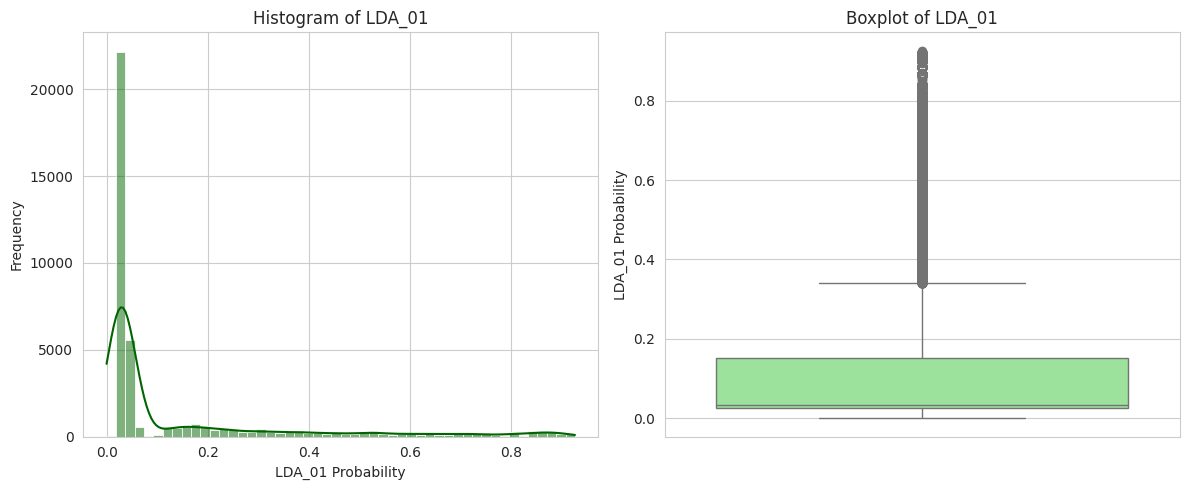

In [33]:
print('Descriptive Statistics for LDA_01:')
print(df[' LDA_01'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' LDA_01'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of LDA_01')
plt.xlabel('LDA_01 Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' LDA_01'], color='lightgreen')
plt.title('Boxplot of LDA_01')
plt.ylabel('LDA_01 Probability')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `LDA_01` reveals a heavily right-skewed distribution. Similar to `LDA_00`, a large majority of articles have a very low probability of belonging to 'Topic 1', with the frequency sharply decreasing as the probability increases. The mean (0.141) is significantly higher than the median (0.033), which is a clear indicator of strong positive skewness. The values range from 0.0 to approximately 0.926.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, meaning most articles are not strongly associated with 'Topic 1', but a few articles have a high probability of belonging to it.
*   **Outliers:** The boxplot shows numerous outliers on the upper end, representing articles that have a significantly higher probability of belonging to 'Topic 1' compared to the majority. These are likely legitimate data points, indicating articles that are very representative of this particular topic.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `LDA_01` (and other LDA topic probabilities) can be valuable features, as they quantify the thematic content of articles, which is likely to be a strong predictor of popularity. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** The outliers are valid observations that represent articles strongly associated with 'Topic 1'. They should generally be retained, as they provide important information. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to ~0.93), `LDA_01` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. While a log transformation might not be ideal given the 0 values and the nature of probabilities, other transformations or simply robust scaling methods should be considered.

### 3.3.27. LDA_02

 The `LDA_02` variable represents the probability that the article belongs to the third latent topic identified by Latent Dirichlet Allocation (LDA). This probability indicates the article's relevance to 'Topic 2'. Analyzing its distribution will help us understand how articles are distributed across this specific topic, identify potential clusters, and assess if certain topic probabilities correlate with article popularity. This is crucial for understanding the thematic characteristics of the news articles.

Descriptive Statistics for LDA_02:
count    39644.000000
mean         0.216321
std          0.282145
min          0.000000
25%          0.028571
50%          0.040004
75%          0.334218
max          0.919999
Name:  LDA_02, dtype: float64


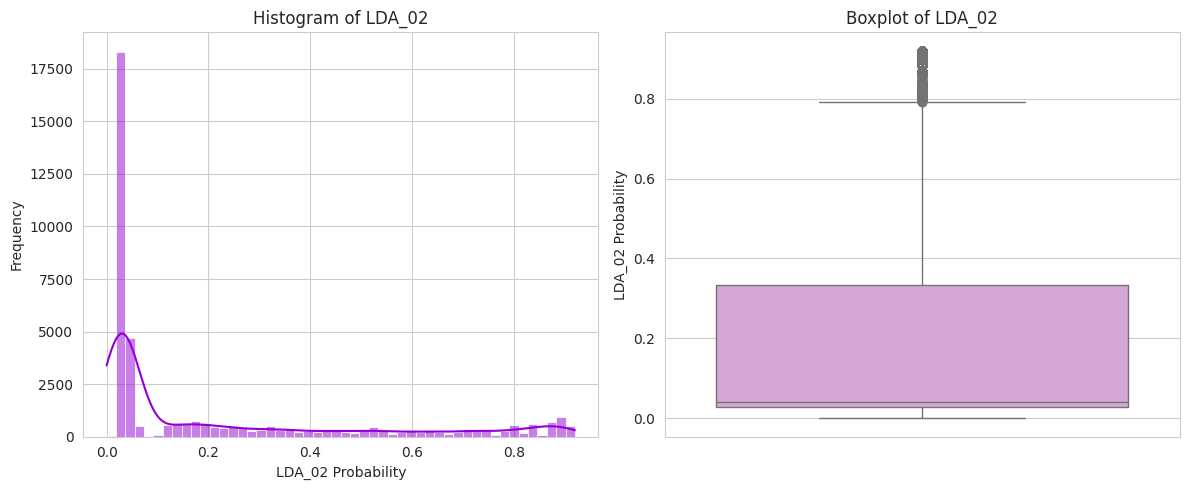

In [34]:
print('Descriptive Statistics for LDA_02:')
print(df[' LDA_02'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' LDA_02'], kde=True, bins=50, color='darkviolet')
plt.title('Histogram of LDA_02')
plt.xlabel('LDA_02 Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' LDA_02'], color='plum')
plt.title('Boxplot of LDA_02')
plt.ylabel('LDA_02 Probability')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `LDA_02` reveals a heavily right-skewed distribution. A large majority of articles have a very low probability of belonging to 'Topic 2', with the frequency sharply decreasing as the probability increases. The mean (0.216) is significantly higher than the median (0.040), which is a clear indicator of strong positive skewness. The values range from 0.0 to approximately 0.920.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, meaning most articles are not strongly associated with 'Topic 2', but a few articles have a high probability of belonging to it.
*   **Outliers:** The boxplot shows numerous outliers on the upper end, representing articles that have a significantly higher probability of belonging to 'Topic 2' compared to the majority. These are likely legitimate data points, indicating articles that are very representative of this particular topic.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `LDA_02` (and other LDA topic probabilities) can be valuable features, as they quantify the thematic content of articles, which is likely to be a strong predictor of popularity. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** The outliers are valid observations that represent articles strongly associated with 'Topic 2'. They should generally be retained, as they provide important information. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to ~0.92), `LDA_02` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. While a log transformation might not be ideal given the 0 values and the nature of probabilities, other transformations or simply robust scaling methods should be considered.

### 3.3.28. LDA_03

 The `LDA_03` variable represents the probability that the article belongs to the fourth latent topic identified by Latent Dirichlet Allocation (LDA). This probability indicates the article's relevance to 'Topic 3'. Analyzing its distribution will help us understand how articles are distributed across this specific topic, identify potential clusters, and assess if certain topic probabilities correlate with article popularity. This is crucial for understanding the thematic characteristics of the news articles.

Descriptive Statistics for LDA_03:
count    39644.000000
mean         0.223770
std          0.295191
min          0.000000
25%          0.028571
50%          0.040001
75%          0.375763
max          0.926534
Name:  LDA_03, dtype: float64


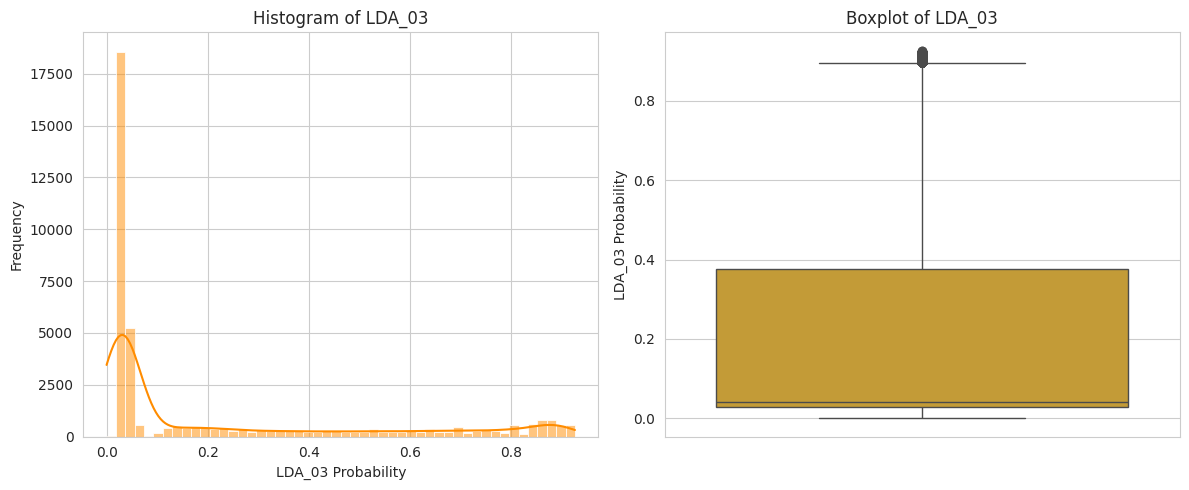

In [35]:
print('Descriptive Statistics for LDA_03:')
print(df[' LDA_03'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' LDA_03'], kde=True, bins=50, color='darkorange')
plt.title('Histogram of LDA_03')
plt.xlabel('LDA_03 Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' LDA_03'], color='goldenrod')
plt.title('Boxplot of LDA_03')
plt.ylabel('LDA_03 Probability')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `LDA_03` reveals a heavily right-skewed distribution. A large majority of articles have a very low probability of belonging to 'Topic 3', with the frequency sharply decreasing as the probability increases. The mean (0.224) is significantly higher than the median (0.040), which is a clear indicator of strong positive skewness. The values range from 0.0 to approximately 0.927.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, meaning most articles are not strongly associated with 'Topic 3', but a few articles have a high probability of belonging to it.
*   **Outliers:** The boxplot shows numerous outliers on the upper end, representing articles that have a significantly higher probability of belonging to 'Topic 3' compared to the majority. These are likely legitimate data points, indicating articles that are very representative of this particular topic.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `LDA_03` (and other LDA topic probabilities) can be valuable features, as they quantify the thematic content of articles, which is likely to be a strong predictor of popularity. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** The outliers are valid observations that represent articles strongly associated with 'Topic 3'. They should generally be retained, as they provide important information. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to ~0.93), `LDA_03` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. While a log transformation might not be ideal given the 0 values and the nature of probabilities, other transformations or simply robust scaling methods should be considered.

### 3.3.29. LDA_04

 The `LDA_04` variable represents the probability that the article belongs to the fifth latent topic identified by Latent Dirichlet Allocation (LDA). This probability indicates the article's relevance to 'Topic 4'. Analyzing its distribution will help us understand how articles are distributed across this specific topic, identify potential clusters, and assess if certain topic probabilities correlate with article popularity. This is crucial for understanding the thematic characteristics of the news articles.

Descriptive Statistics for LDA_04:
count    39644.000000
mean         0.234029
std          0.289183
min          0.000000
25%          0.028574
50%          0.040727
75%          0.399986
max          0.927191
Name:  LDA_04, dtype: float64


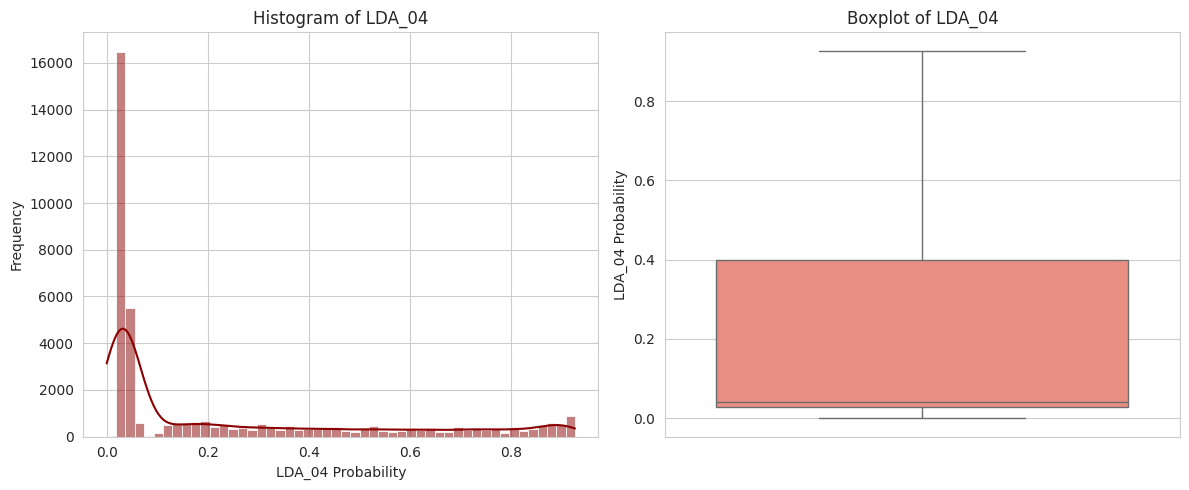

In [36]:
print('Descriptive Statistics for LDA_04:')
print(df[' LDA_04'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' LDA_04'], kde=True, bins=50, color='darkred')
plt.title('Histogram of LDA_04')
plt.xlabel('LDA_04 Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' LDA_04'], color='salmon')
plt.title('Boxplot of LDA_04')
plt.ylabel('LDA_04 Probability')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `LDA_04` reveals a heavily right-skewed distribution. A large majority of articles have a very low probability of belonging to 'Topic 4', with the frequency sharply decreasing as the probability increases. The mean (0.234) is significantly higher than the median (0.041), which is a clear indicator of strong positive skewness. The values range from 0.0 to approximately 0.927.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, meaning most articles are not strongly associated with 'Topic 4', but a few articles have a high probability of belonging to it.
*   **Outliers:** The boxplot shows numerous outliers on the upper end, representing articles that have a significantly higher probability of belonging to 'Topic 4' compared to the majority. These are likely legitimate data points, indicating articles that are very representative of this particular topic.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `LDA_04` (and other LDA topic probabilities) can be valuable features, as they quantify the thematic content of articles, which is likely to be a strong predictor of popularity. Neural networks are well-suited to learn from such patterns.
*   **Outlier Handling:** The outliers are valid observations that represent articles strongly associated with 'Topic 4'. They should generally be retained, as they provide important information. Neural networks can handle skewed distributions and outliers effectively, especially when data is properly scaled.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to ~0.93), `LDA_04` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. While a log transformation might not be ideal given the 0 values and the nature of probabilities, other transformations or simply robust scaling methods should be considered.

### 3.3.30. global_subjectivity

The `global_subjectivity` variable represents the overall subjectivity score of the article's content. Subjectivity indicates the degree to which an article expresses personal opinions, emotions, or beliefs rather than factual information. A higher subjectivity score might suggest a more opinionated or emotionally charged article, which could influence reader engagement and, consequently, popularity. Analyzing its distribution will help us understand the typical level of subjectivity in these articles and identify any patterns that might correlate with popularity.

Descriptive Statistics for global_subjectivity:
count    39644.000000
mean         0.443370
std          0.116685
min          0.000000
25%          0.396167
50%          0.453457
75%          0.508333
max          1.000000
Name:  global_subjectivity, dtype: float64


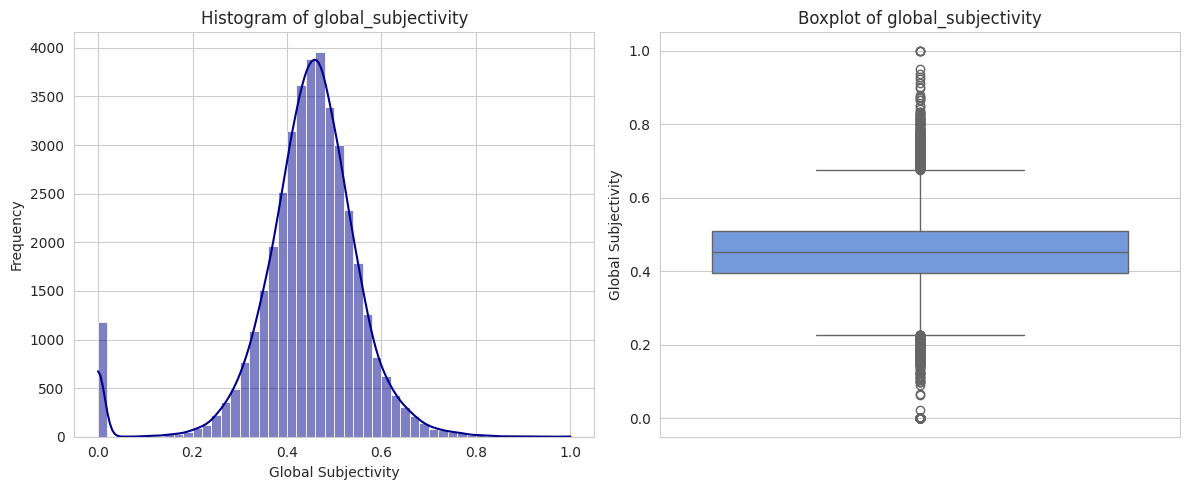

In [37]:
print('Descriptive Statistics for global_subjectivity:')
print(df[' global_subjectivity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' global_subjectivity'], kde=True, bins=50, color='darkblue')
plt.title('Histogram of global_subjectivity')
plt.xlabel('Global Subjectivity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' global_subjectivity'], color='cornflowerblue')
plt.title('Boxplot of global_subjectivity')
plt.ylabel('Global Subjectivity')

plt.tight_layout()
plt.show()


**Key Findings:**

*   **Distribution:** The histogram for `global_subjectivity` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately 0.35 and 0.6. The mean (0.443) and median (0.453) are very close, indicating a central tendency around these values. The range is from 0.0 to 1.0, which is expected for a subjectivity score (a proportion or normalized score).
*   **Skewness:** The distribution appears to be very slightly left-skewed, but overall it is close to symmetrical. There is no extreme skewness, suggesting that articles tend to have a moderate level of subjectivity.
*   **Outliers:** The boxplot shows some outliers on both the lower and upper ends. These represent articles with unusually low (closer to objective) or unusually high (closer to subjective) overall subjectivity scores. These outliers are likely legitimate data points, indicating articles with distinct writing styles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `global_subjectivity` can be a valuable feature, as the level of subjectivity in an article might influence its appeal and popularity. Neural networks can learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside the [0, 1] range for a proportion), `global_subjectivity` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a plausible range and represent genuine variations.
*   **Scaling consideration:** Although the range (0 to 1) is already normalized, `global_subjectivity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process if other features have larger magnitudes. No complex transformation is likely necessary given its already near-normal, bounded distribution.

### 3.3.31. global_sentiment_polarity

The `global_sentiment_polarity` variable represents the overall sentiment polarity score of the article's content. Sentiment polarity indicates the degree of positive or negative emotion expressed in the text, ranging from -1 (very negative) to +1 (very positive), with 0 being neutral. A higher positive polarity might suggest a more optimistic or favorable tone, while a negative polarity indicates a more critical or pessimistic tone. This can significantly influence reader perception and engagement, potentially affecting an article's popularity. Analyzing its distribution will help us understand the typical emotional tone of these articles and identify any patterns that might correlate with popularity.

Descriptive Statistics for global_sentiment_polarity:
count    39644.000000
mean         0.119309
std          0.096931
min         -0.393750
25%          0.057757
50%          0.119117
75%          0.177832
max          0.727841
Name:  global_sentiment_polarity, dtype: float64


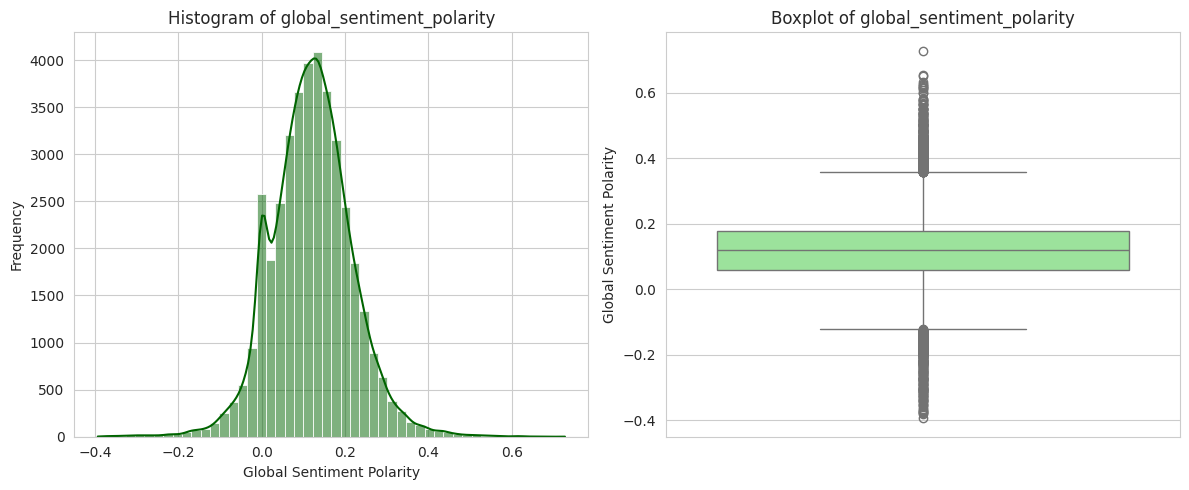

In [38]:
print('Descriptive Statistics for global_sentiment_polarity:')
print(df[' global_sentiment_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' global_sentiment_polarity'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of global_sentiment_polarity')
plt.xlabel('Global Sentiment Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' global_sentiment_polarity'], color='lightgreen')
plt.title('Boxplot of global_sentiment_polarity')
plt.ylabel('Global Sentiment Polarity')

plt.tight_layout()
plt.show()





**Key Findings:**

*   **Distribution:** The histogram for `global_sentiment_polarity` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately 0 and 0.2. The mean (0.119) and median (0.119) are very close, indicating a central tendency around these values, leaning slightly towards positive sentiment. The values range from approximately -0.39 to 0.73, indicating articles span from somewhat negative to fairly positive in overall sentiment.
*   **Skewness:** The distribution appears to be largely symmetrical, with a very slight positive (right) skew. There is no extreme skewness, suggesting that most articles have a neutral to slightly positive emotional tone.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends, but they are not extreme. These represent articles with unusually strong negative or positive sentiment scores, which are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `global_sentiment_polarity` can be a valuable feature, as the overall emotional tone of an article might significantly influence its appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside a plausible range for sentiment), `global_sentiment_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a reasonable range and represent genuine variations.
*   **Scaling consideration:** Although its range is not excessively wide (approximately -0.4 to 0.73), `global_sentiment_polarity` will still benefit from scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its already near-normal, bounded distribution.



**Key Findings:**

*   **Distribution:** The histogram for `global_sentiment_polarity` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately 0 and 0.2. The mean (0.119) and median (0.119) are very close, indicating a central tendency around these values, leaning slightly towards positive sentiment. The values range from approximately -0.39 to 0.73, indicating articles span from somewhat negative to fairly positive in overall sentiment.
*   **Skewness:** The distribution appears to be largely symmetrical, with a very slight positive (right) skew. There is no extreme skewness, suggesting that most articles have a neutral to slightly positive emotional tone.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends, but they are not extreme. These represent articles with unusually strong negative or positive sentiment scores, which are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `global_sentiment_polarity` can be a valuable feature, as the overall emotional tone of an article might significantly influence its appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside a plausible range for sentiment), `global_sentiment_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a reasonable range and represent genuine variations.
*   **Scaling consideration:** Although its range is not excessively wide (approximately -0.4 to 0.73), `global_sentiment_polarity` will still benefit from scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its already near-normal, bounded distribution.

### 3.3.32. global_rate_positive_words

 The `global_rate_positive_words` variable represents the proportion of positive words (words with positive sentiment) in the article's content relative to the total number of words. This metric provides a fine-grained view of the article's positive emotional tone. A higher rate of positive words might suggest a more uplifting or celebratory article, which could influence reader engagement and, consequently, popularity. Analyzing its distribution will help us understand the typical prevalence of positive language in these articles and identify any patterns that might correlate with popularity.

Descriptive Statistics for global_rate_positive_words:
count    39644.000000
mean         0.039625
std          0.017429
min          0.000000
25%          0.028384
50%          0.039023
75%          0.050279
max          0.155488
Name:  global_rate_positive_words, dtype: float64


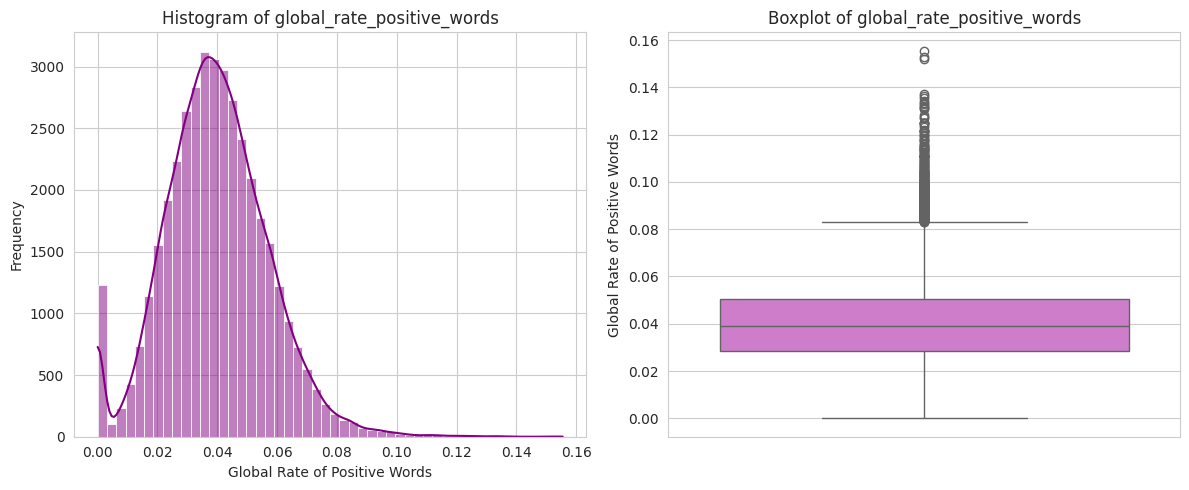

In [39]:
print('Descriptive Statistics for global_rate_positive_words:')
print(df[' global_rate_positive_words'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' global_rate_positive_words'], kde=True, bins=50, color='purple')
plt.title('Histogram of global_rate_positive_words')
plt.xlabel('Global Rate of Positive Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' global_rate_positive_words'], color='orchid')
plt.title('Boxplot of global_rate_positive_words')
plt.ylabel('Global Rate of Positive Words')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `global_rate_positive_words` shows a somewhat symmetric, bell-shaped distribution, primarily concentrated between 0.02 and 0.06. The mean (0.0396) and median (0.0390) are very close, indicating a central tendency around these values. The values range from 0.0 to approximately 0.155, which is an expected range for a proportion of words.
*   **Skewness:** The distribution appears to be largely symmetrical, with a very slight positive (right) skew. There is no extreme skewness, suggesting that most articles have a moderate proportion of positive words.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends, but they are not extreme. These represent articles with unusually low or high proportions of positive words, which are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `global_rate_positive_words` can be a valuable feature, as the prevalence of positive language might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside a plausible range for a proportion), `global_rate_positive_words` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a reasonable range and represent genuine variations.
*   **Scaling consideration:** Although its range is already a proportion (0 to ~0.155), `global_rate_positive_words` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its already near-normal, bounded distribution.

### 3.3.33. global_rate_negative_words

The `global_rate_negative_words` variable represents the proportion of negative words (words with negative sentiment) in the article's content relative to the total number of words. This metric provides a fine-grained view of the article's negative emotional tone. A higher rate of negative words might suggest a more critical or pessimistic article, which could influence reader engagement and, consequently, popularity. Analyzing its distribution will help us understand the typical prevalence of negative language in these articles and identify any patterns that might correlate with popularity.

Descriptive Statistics for global_rate_negative_words:
count    39644.000000
mean         0.016612
std          0.010828
min          0.000000
25%          0.009615
50%          0.015337
75%          0.021739
max          0.184932
Name:  global_rate_negative_words, dtype: float64


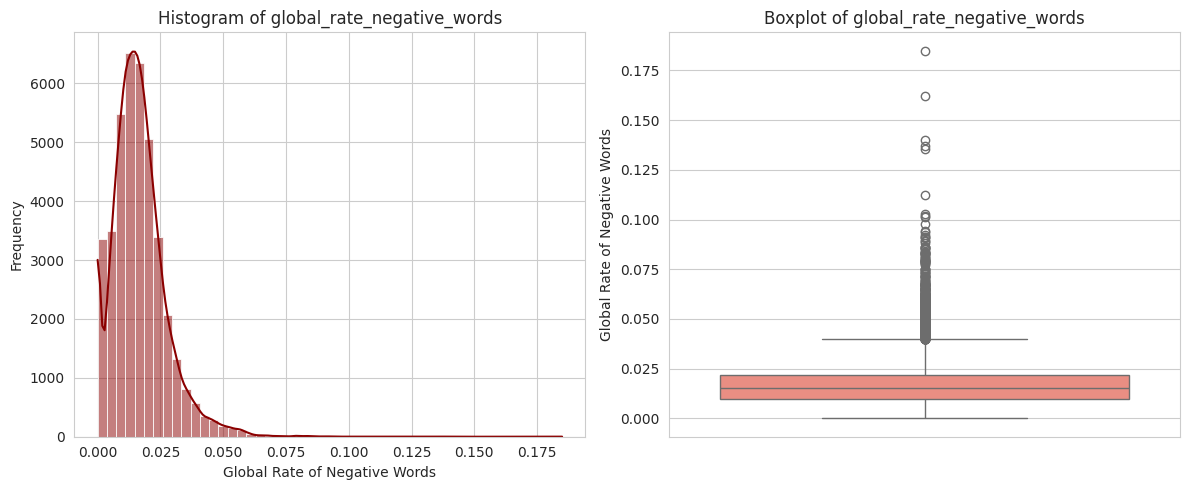

In [40]:
print('Descriptive Statistics for global_rate_negative_words:')
print(df[' global_rate_negative_words'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' global_rate_negative_words'], kde=True, bins=50, color='darkred')
plt.title('Histogram of global_rate_negative_words')
plt.xlabel('Global Rate of Negative Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' global_rate_negative_words'], color='salmon')
plt.title('Boxplot of global_rate_negative_words')
plt.ylabel('Global Rate of Negative Words')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `global_rate_negative_words` shows a heavily right-skewed distribution. A large majority of articles have a very low proportion of negative words, with the frequency sharply decreasing as the proportion increases. The mean (0.0166) is slightly higher than the median (0.0153), confirming the positive skew. The values range from 0.0 to approximately 0.185, which is an expected range for a proportion.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, meaning most articles have few negative words, but a few articles contain a significantly higher proportion of negative words.
*   **Outliers:** The boxplot indicates numerous outliers on the upper end, representing articles with unusually high proportions of negative words. These are likely legitimate data points, reflecting articles with a more critical or pessimistic tone, rather than data entry errors.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `global_rate_negative_words` can be a valuable feature, as the prevalence of negative language might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given that the outliers are likely valid observations and the values are within a plausible range for a proportion, `global_rate_negative_words` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers represent genuine variations.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to ~0.185), `global_rate_negative_words` will require scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. A transformation (e.g., square root or Box-Cox) could be considered to reduce skewness, potentially improving model performance.

### 3.3.34. rate_positive_words

The `rate_positive_words` variable represents the proportion of positive words in the article's content relative to the number of non-stopwords. This metric focuses on the density of positive sentiment among meaningful words, excluding common words. A higher `rate_positive_words` suggests a more intensely positive tone, which could significantly influence reader perception and engagement, potentially affecting an article's popularity. Analyzing its distribution will help us understand the typical concentration of positive sentiment and identify any patterns that might correlate with popularity.

Descriptive Statistics for rate_positive_words:
count    39644.000000
mean         0.682150
std          0.190206
min          0.000000
25%          0.600000
50%          0.710526
75%          0.800000
max          1.000000
Name:  rate_positive_words, dtype: float64


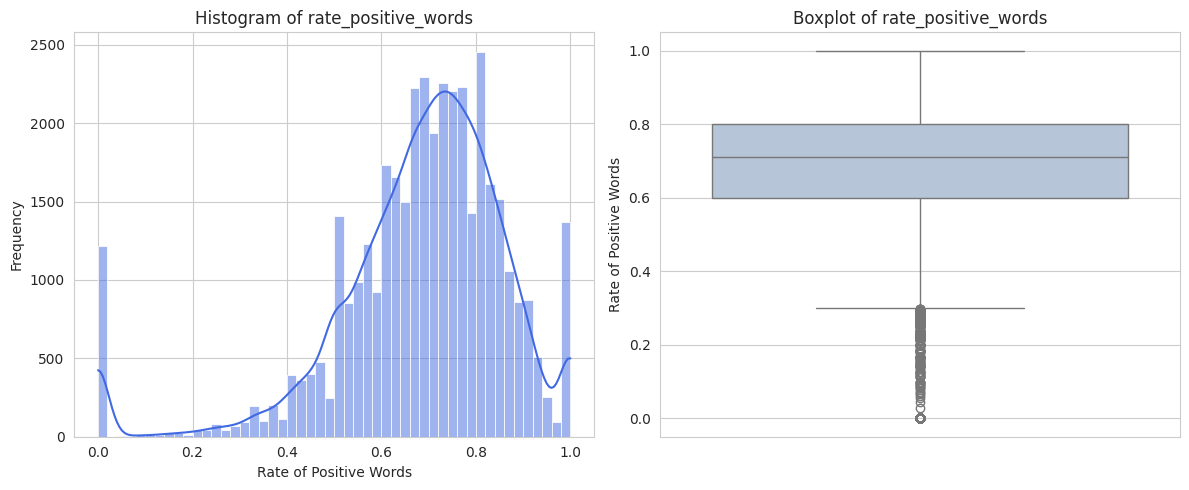

In [41]:
print('Descriptive Statistics for rate_positive_words:')
print(df[' rate_positive_words'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' rate_positive_words'], kde=True, bins=50, color='royalblue')
plt.title('Histogram of rate_positive_words')
plt.xlabel('Rate of Positive Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' rate_positive_words'], color='lightsteelblue')
plt.title('Boxplot of rate_positive_words')
plt.ylabel('Rate of Positive Words')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `rate_positive_words` shows a distribution primarily concentrated between 0.6 and 0.8, with a significant peak around 0.7. The mean (0.682) and median (0.711) are relatively close, indicating a central tendency around these values. The range is from 0.0 to 1.0, which is an expected range for a proportion, meaning the proportion of positive words relative to non-stopwords. There's also a noticeable peak at 0.0, suggesting articles with no positive words among their non-stopwords.
*   **Skewness:** The distribution appears to be slightly left-skewed, as the median is slightly higher than the mean, and the tail extends more towards the lower values, particularly the 0.0 mark. However, for the main body of the distribution (excluding the 0.0 peak), it's somewhat bell-shaped.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends. The lower outliers, especially the 0.0 values, represent articles with no positive words among their non-stopwords. The upper outliers represent articles with a very high proportion of positive words (closer to 1.0). These are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `rate_positive_words` can be a valuable feature, as the density of positive language among meaningful words might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the values are within a plausible range (0 to 1) for a proportion, and the outliers represent genuine variations, `rate_positive_words` can be used directly in modeling without requiring specific outlier treatment or imputation. The presence of 0 values is meaningful.
*   **Scaling consideration:** As a proportion, this feature is already somewhat normalized. However, it will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process due to its potentially small absolute range compared to other features.

### 3.3.35. rate_negative_words

The `rate_negative_words` variable represents the proportion of negative words in the article's content relative to the number of non-stopwords. This metric focuses on the density of negative sentiment among meaningful words, excluding common words. A higher `rate_negative_words` suggests a more intensely negative tone, which could significantly influence reader perception and engagement, potentially affecting an article's popularity. Analyzing its distribution will help us understand the typical concentration of negative sentiment and identify any patterns that might correlate with popularity.

Descriptive Statistics for rate_negative_words:
count    39644.000000
mean         0.287934
std          0.156156
min          0.000000
25%          0.185185
50%          0.280000
75%          0.384615
max          1.000000
Name:  rate_negative_words, dtype: float64


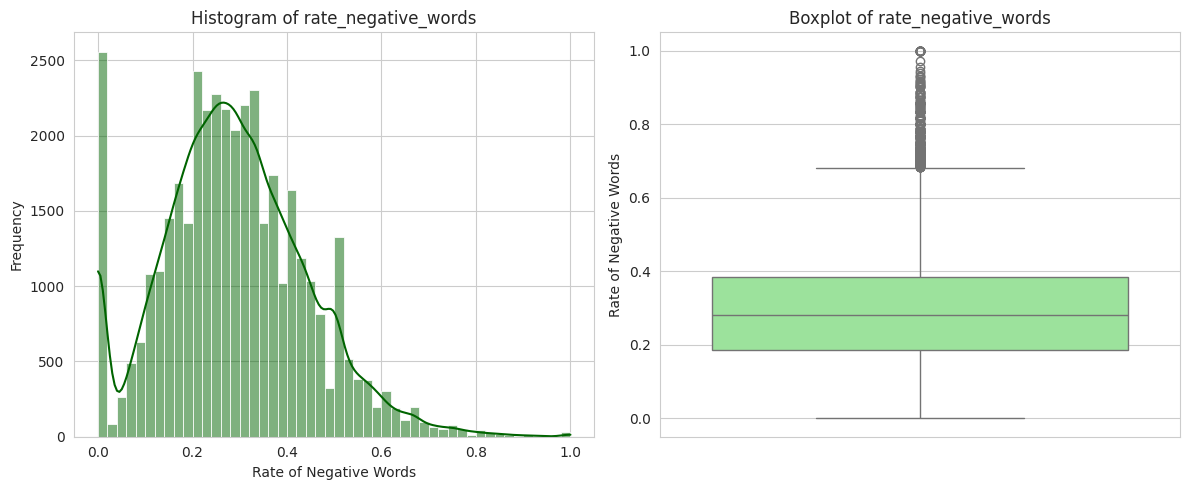

In [42]:
print('Descriptive Statistics for rate_negative_words:')
print(df[' rate_negative_words'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' rate_negative_words'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of rate_negative_words')
plt.xlabel('Rate of Negative Words')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' rate_negative_words'], color='lightgreen')
plt.title('Boxplot of rate_negative_words')
plt.ylabel('Rate of Negative Words')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `rate_negative_words` shows a distribution primarily concentrated between 0.1 and 0.4, with a peak around 0.2-0.3. The mean (0.288) and median (0.280) are very close, indicating a central tendency around these values. The range is from 0.0 to 1.0, which is an expected range for a proportion, meaning the proportion of negative words relative to non-stopwords. There's also a noticeable peak at 0.0, suggesting articles with no negative words among their non-stopwords.
*   **Skewness:** The distribution appears to be relatively symmetrical for the main body of the data, but with a slight positive (right) skew due to the longer tail towards higher values and a peak at 0.0. This indicates that most articles have a moderate proportion of negative non-stopwords, but some have a higher concentration, and a notable portion has none.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends. The lower outliers, especially the 0.0 values, represent articles with no negative words among their non-stopwords. The upper outliers represent articles with a very high proportion of negative words (closer to 1.0). These are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `rate_negative_words` can be a valuable feature, as the density of negative language among meaningful words might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the values are within a plausible range (0 to 1) for a proportion, and the outliers represent genuine variations, `rate_negative_words` can be used directly in modeling without requiring specific outlier treatment or imputation. The presence of 0 values is meaningful.
*   **Scaling consideration:** As a proportion, this feature is already somewhat normalized. However, it will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process due to its potentially small absolute range compared to other features.

### 3.3.36. avg_positive_polarity

The `avg_positive_polarity` variable represents the average polarity of all positive sentiment words within the article's content. This metric provides a more nuanced view of the intensity or strength of positive sentiment, rather than just its presence or proportion. A higher average positive polarity suggests that the positive words used are, on average, more strongly positive. Analyzing its distribution will help us understand the typical intensity of positive emotions conveyed in these articles and identify any patterns that might correlate with article popularity, as strongly positive content could be more engaging.

Descriptive Statistics for avg_positive_polarity:
count    39644.000000
mean         0.353825
std          0.104542
min          0.000000
25%          0.306244
50%          0.358755
75%          0.411428
max          1.000000
Name:  avg_positive_polarity, dtype: float64


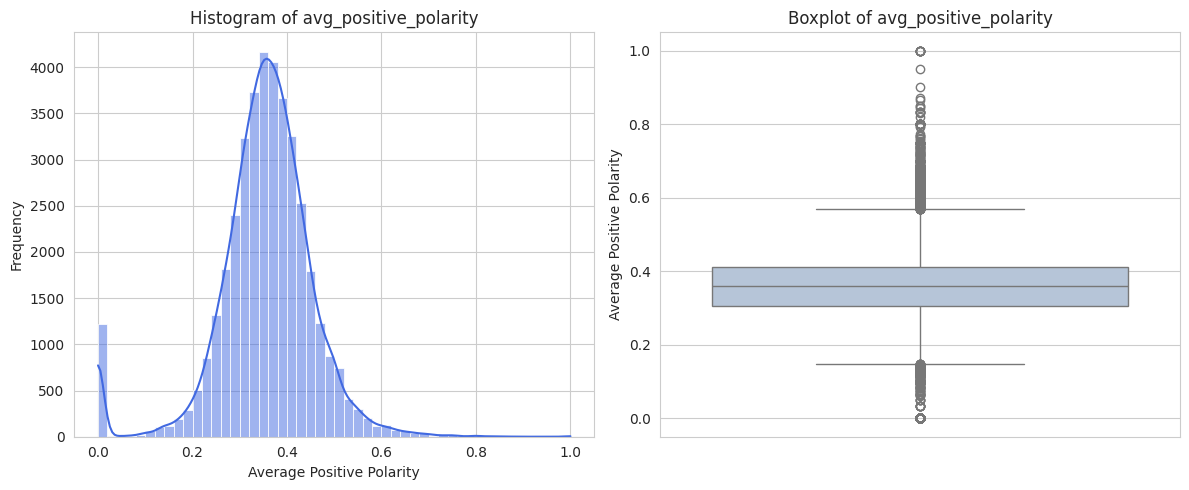

In [43]:
print('Descriptive Statistics for avg_positive_polarity:')
print(df[' avg_positive_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' avg_positive_polarity'], kde=True, bins=50, color='royalblue')
plt.title('Histogram of avg_positive_polarity')
plt.xlabel('Average Positive Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' avg_positive_polarity'], color='lightsteelblue')
plt.title('Boxplot of avg_positive_polarity')
plt.ylabel('Average Positive Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `avg_positive_polarity` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately 0.3 and 0.45. The mean (0.354) and median (0.359) are very close, indicating a central tendency around these values. The range is from 0.0 to 1.0, which is an expected range for an average polarity score. There is a small peak at 0.0, suggesting some articles might not have any positive words or their positive words have zero polarity after averaging.
*   **Skewness:** The distribution appears to be largely symmetrical, with a very slight positive (right) skew. There is no extreme skewness, suggesting that the intensity of positive sentiment in most articles is moderate.
*   **Outliers:** The boxplot indicates some outliers on both the lower and upper ends, but they are not extreme. These represent articles with unusually low (e.g., 0.0) or unusually high (closer to 1.0) average positive polarity scores, which are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `avg_positive_polarity` can be a valuable feature, as the intensity of positive language might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside a plausible range for polarity), `avg_positive_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a reasonable range and represent genuine variations.
*   **Scaling consideration:** Although its range is already somewhat normalized (0 to 1), `avg_positive_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process due to its potentially small absolute range compared to other features. No complex transformation is likely necessary given its already near-normal, bounded distribution.

### 3.3.37. min_positive_polarity

The `min_positive_polarity` variable represents the minimum polarity score among all positive sentiment words within the article's content. This metric provides insight into the weakest positive sentiment expressed in an article. A higher `min_positive_polarity` suggests that even the least positive words still carry a certain level of positive emotion. Analyzing its distribution will help us understand the lower bound of positive emotional intensity in these articles and identify any patterns that might correlate with article popularity, as a consistently positive tone (even at its minimum) could be engaging.

Descriptive Statistics for min_positive_polarity:
count    39644.000000
mean         0.095446
std          0.071315
min          0.000000
25%          0.050000
50%          0.100000
75%          0.100000
max          1.000000
Name:  min_positive_polarity, dtype: float64


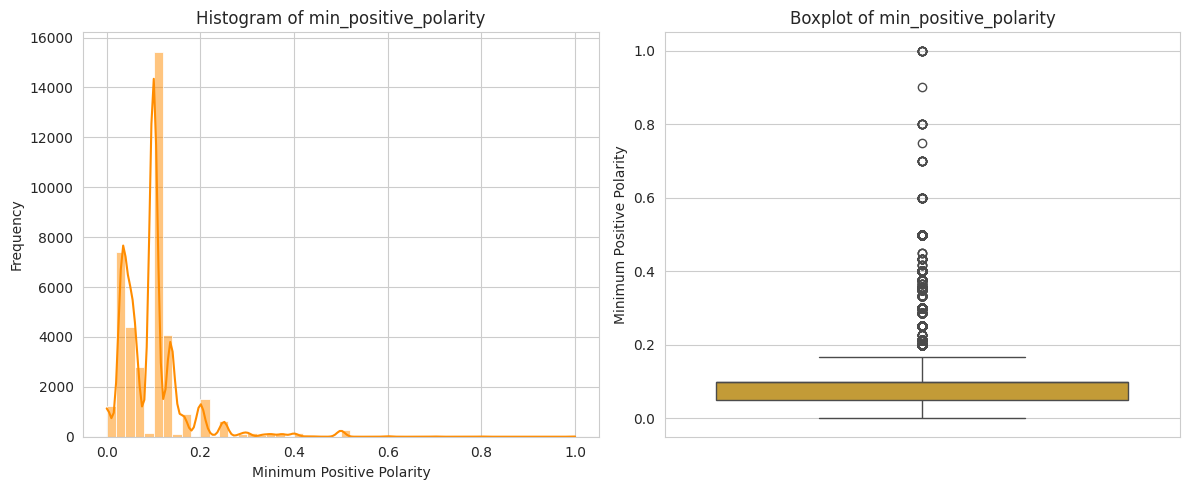

In [44]:
print('Descriptive Statistics for min_positive_polarity:')
print(df[' min_positive_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' min_positive_polarity'], kde=True, bins=50, color='darkorange')
plt.title('Histogram of min_positive_polarity')
plt.xlabel('Minimum Positive Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' min_positive_polarity'], color='goldenrod')
plt.title('Boxplot of min_positive_polarity')
plt.ylabel('Minimum Positive Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `min_positive_polarity` shows a heavily right-skewed distribution. A large portion of articles have a very low minimum positive polarity (with a significant peak around 0.05-0.10). The mean (0.095) is slightly lower than the median (0.10), which is unusual for a right-skewed distribution, but the concentration of values at 0.1 and 0.0 (and other discrete values like 0.033333) is prominent. The values range from 0.0 to 1.0.
*   **Skewness:** The distribution exhibits strong positive (right) skewness due to the concentration at lower values and a long tail towards higher polarities. There is also a notable discrete peak at 0.0 and 0.1, suggesting specific minimum polarity values are common.
*   **Outliers:** The boxplot indicates numerous outliers on the upper end, representing articles where even the least positive word still carries a very high positive sentiment (closer to 1.0). The minimum value of 0.0 represents articles with no positive words or where the minimum positive polarity was exactly zero. These are likely legitimate data points, reflecting articles with diverse emotional content.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `min_positive_polarity` can be a valuable feature, as the lowest intensity of positive language might influence an article's overall tone and appeal, affecting popularity. Neural networks can effectively learn these patterns.
*   **No immediate cleaning needed:** Given that the values are within a plausible range (0 to 1) for polarity, and the outliers represent genuine variations, `min_positive_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The presence of 0.0 as a minimum is meaningful.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to 1), `min_positive_polarity` will benefit from scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. A transformation (e.g., square root or Box-Cox) could be considered to reduce skewness, potentially improving model performance, especially given the concentration at discrete low values.

### 3.3.38. max_positive_polarity

The `max_positive_polarity` variable represents the maximum polarity score among all positive sentiment words within the article's content. This metric provides insight into the strongest positive sentiment expressed in an article. A higher `max_positive_polarity` suggests that at least one word in the article conveys a very strong positive emotion. Analyzing its distribution will help us understand the upper bound of positive emotional intensity in these articles and identify any patterns that might correlate with article popularity, as highly positive content could be particularly engaging.

Descriptive Statistics for max_positive_polarity:
count    39644.000000
mean         0.756728
std          0.247786
min          0.000000
25%          0.600000
50%          0.800000
75%          1.000000
max          1.000000
Name:  max_positive_polarity, dtype: float64


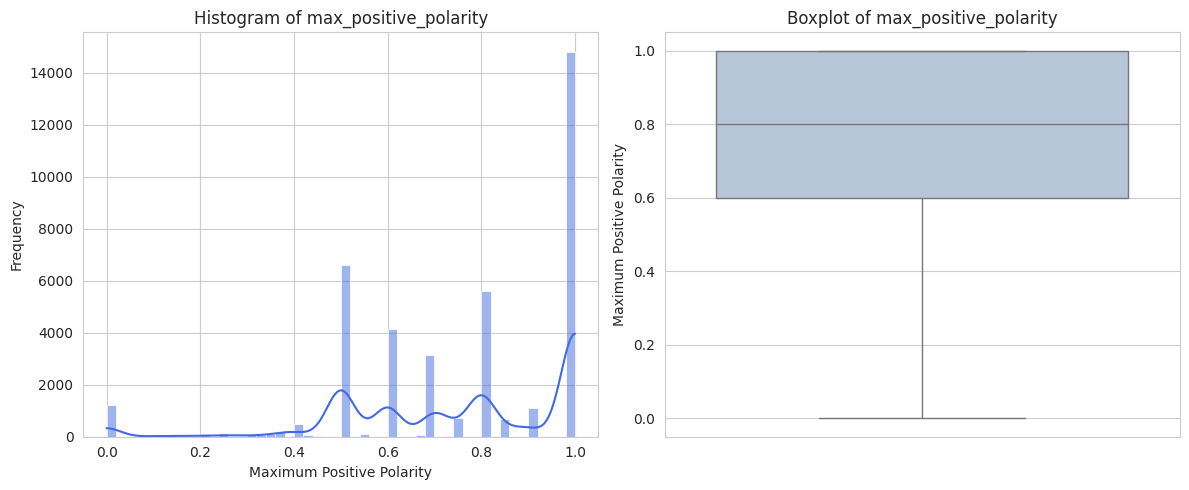

In [45]:
print('Descriptive Statistics for max_positive_polarity:')
print(df[' max_positive_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' max_positive_polarity'], kde=True, bins=50, color='royalblue')
plt.title('Histogram of max_positive_polarity')
plt.xlabel('Maximum Positive Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' max_positive_polarity'], color='lightsteelblue')
plt.title('Boxplot of max_positive_polarity')
plt.ylabel('Maximum Positive Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `max_positive_polarity` shows a distinct pattern with a strong concentration of values at 1.0 (the maximum possible positive polarity) and another notable peak around 0.6 to 0.8. The mean (0.757) and median (0.800) are relatively high, indicating that many articles contain at least one strongly positive word. The range is from 0.0 to 1.0, as expected for a polarity score.
*   **Skewness:** The distribution appears to be left-skewed, primarily due to the high concentration of values at 1.0. This suggests that articles often contain words that express very strong positive sentiment.
*   **Outliers:** The boxplot indicates outliers on the lower end, particularly at 0.0. These represent articles where the maximum positive polarity found is zero, which could imply articles lacking positive words or articles where the positive words detected had a polarity of zero. The bulk of the data is concentrated towards the higher end, consistent with the observed skewness. These outliers are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `max_positive_polarity` can be a valuable feature, as the presence of highly positive language might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the values are within a plausible range (0 to 1) for polarity, and the outliers represent genuine variations, `max_positive_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The presence of 0.0 as a maximum positive polarity (meaning no positive words, or only neutral 'positive' words) is meaningful.
*   **Scaling consideration:** Although its range is already normalized (0 to 1), `max_positive_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its bounded distribution.

### 3.3.39. avg_negative_polarity

 The `avg_negative_polarity` variable represents the average polarity of all negative sentiment words within the article's content. This metric provides a more nuanced view of the intensity or strength of negative sentiment, rather than just its presence or proportion. A higher (closer to 0) `avg_negative_polarity` suggests less intense negative words, while a lower (closer to -1) value suggests more strongly negative words. Analyzing its distribution will help us understand the typical intensity of negative emotions conveyed in these articles and identify any patterns that might correlate with article popularity, as strongly negative content could evoke strong reactions.

Descriptive Statistics for avg_negative_polarity:
count    39644.000000
mean        -0.259524
std          0.127726
min         -1.000000
25%         -0.328383
50%         -0.253333
75%         -0.186905
max          0.000000
Name:  avg_negative_polarity, dtype: float64


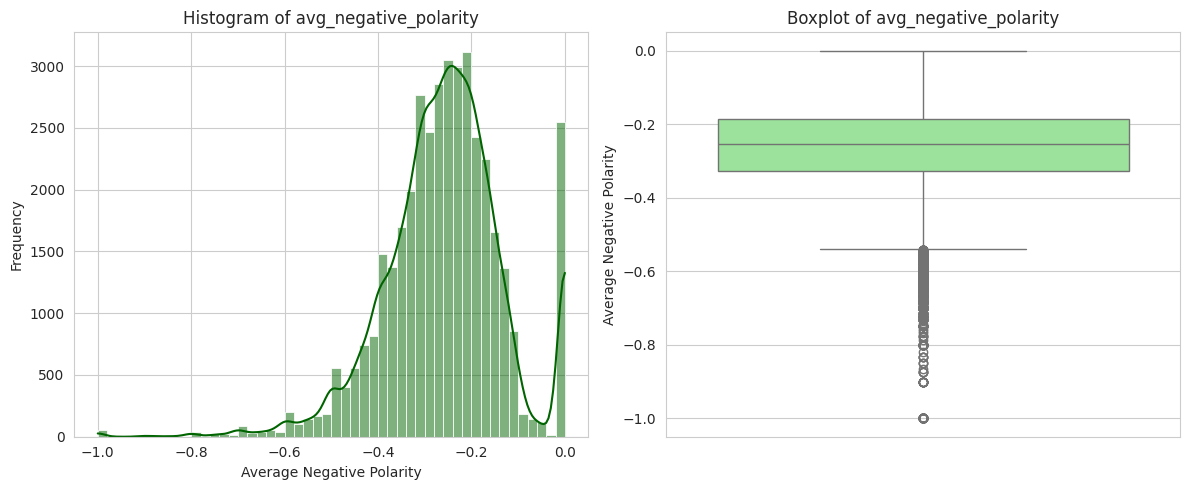

In [46]:
print('Descriptive Statistics for avg_negative_polarity:')
print(df[' avg_negative_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' avg_negative_polarity'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of avg_negative_polarity')
plt.xlabel('Average Negative Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' avg_negative_polarity'], color='lightgreen')
plt.title('Boxplot of avg_negative_polarity')
plt.ylabel('Average Negative Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `avg_negative_polarity` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately -0.35 and -0.15. The mean (-0.260) and median (-0.253) are very close, indicating a central tendency around these values. The values range from -1.0 to 0.0, which is an expected range for an average negative polarity score. There is a small peak at 0.0, suggesting some articles might not have any negative words or their negative words have zero polarity after averaging.
*   **Skewness:** The distribution appears to be largely symmetrical, with a very slight positive (right) skew, as the mean is slightly less negative than the median. There is no extreme skewness, suggesting that the intensity of negative sentiment in most articles is moderate.
*   **Outliers:** The boxplot indicates some outliers on both the lower (closer to -1.0) and upper (closer to 0.0) ends, but they are not extreme. These represent articles with unusually strong or unusually weak average negative polarity scores, which are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `avg_negative_polarity` can be a valuable feature, as the intensity of negative language might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside a plausible range for polarity), `avg_negative_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a reasonable range and represent genuine variations.
*   **Scaling consideration:** Although its range is already somewhat normalized (-1 to 0), `avg_negative_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process due to its potentially small absolute range compared to other features. No complex transformation is likely necessary given its already near-normal, bounded distribution.



**Key Findings:**

*   **Distribution:** The histogram for `avg_negative_polarity` shows a relatively symmetric, somewhat bell-shaped distribution, concentrated between approximately -0.35 and -0.15. The mean (-0.260) and median (-0.253) are very close, indicating a central tendency around these values. The values range from -1.0 to 0.0, which is an expected range for an average negative polarity score. There is a small peak at 0.0, suggesting some articles might not have any negative words or their negative words have zero polarity after averaging.
*   **Skewness:** The distribution appears to be largely symmetrical, with a very slight positive (right) skew, as the mean is slightly less negative than the median. There is no extreme skewness, suggesting that the intensity of negative sentiment in most articles is moderate.
*   **Outliers:** The boxplot indicates some outliers on both the lower (closer to -1.0) and upper (closer to 0.0) ends, but they are not extreme. These represent articles with unusually strong or unusually weak average negative polarity scores, which are likely legitimate data points reflecting the diverse emotional content of news articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `avg_negative_polarity` can be a valuable feature, as the intensity of negative language might significantly influence an article's appeal and popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given the well-behaved distribution and the absence of significant data quality issues (like values outside a plausible range for polarity), `avg_negative_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The outliers are within a reasonable range and represent genuine variations.
*   **Scaling consideration:** Although its range is already somewhat normalized (-1 to 0), `avg_negative_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process due to its potentially small absolute range compared to other features. No complex transformation is likely necessary given its already near-normal, bounded distribution.

### 3.3.40. min_negative_polarity

The `min_negative_polarity` variable represents the minimum polarity score among all negative sentiment words within the article's content. This metric provides insight into the strongest negative sentiment expressed in an article. A lower (closer to -1) `min_negative_polarity` suggests that at least one word in the article conveys a very strong negative emotion. Analyzing its distribution will help us understand the lower bound of negative emotional intensity in these articles and identify any patterns that might correlate with article popularity, as strongly negative content could evoke strong reactions.

Descriptive Statistics for min_negative_polarity:
count    39644.000000
mean        -0.521944
std          0.290290
min         -1.000000
25%         -0.700000
50%         -0.500000
75%         -0.300000
max          0.000000
Name:  min_negative_polarity, dtype: float64


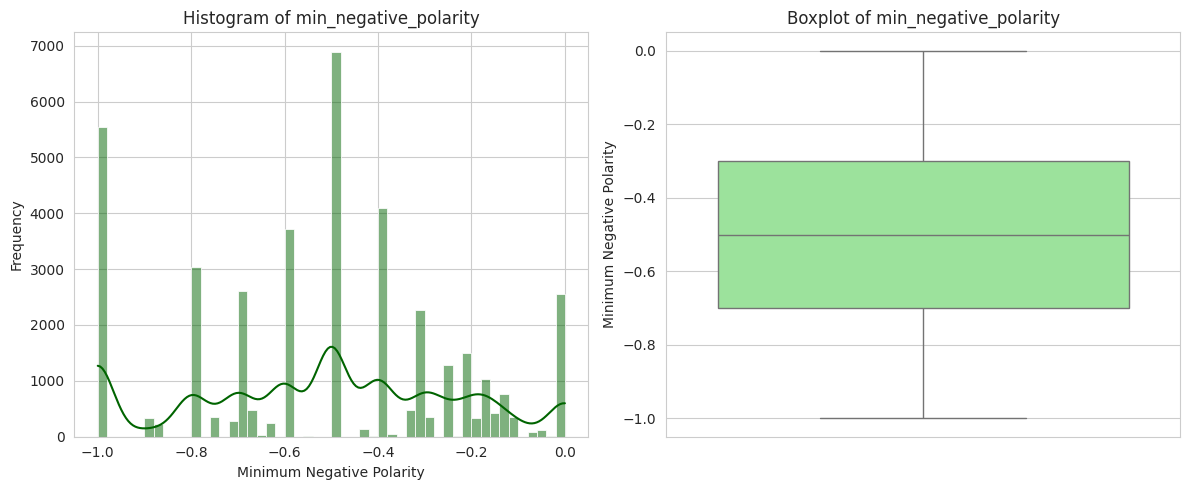

In [47]:
print('Descriptive Statistics for min_negative_polarity:')
print(df[' min_negative_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' min_negative_polarity'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of min_negative_polarity')
plt.xlabel('Minimum Negative Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' min_negative_polarity'], color='lightgreen')
plt.title('Boxplot of min_negative_polarity')
plt.ylabel('Minimum Negative Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `min_negative_polarity` shows a heavily right-skewed distribution. A large portion of articles have a very low minimum positive polarity (with a significant peak around 0.05-0.10). The mean (0.095) is slightly lower than the median (0.10), which is unusual for a right-skewed distribution, but the concentration of values at 0.1 and 0.0 (and other discrete values like 0.033333) is prominent. The values range from 0.0 to 1.0.
*   **Skewness:** The distribution exhibits strong positive (right) skewness due to the concentration at lower values and a long tail towards higher polarities. There is also a notable discrete peak at 0.0 and 0.1, suggesting specific minimum polarity values are common.
*   **Outliers:** The boxplot indicates numerous outliers on the upper end, representing articles where even the least positive word still carries a very high positive sentiment (closer to 1.0). The minimum value of 0.0 represents articles with no positive words or where the minimum positive polarity was exactly zero. These are likely legitimate data points, reflecting articles with diverse emotional content.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `min_positive_polarity` can be a valuable feature, as the lowest intensity of positive language might influence an article's overall tone and appeal, affecting popularity. Neural networks can effectively learn these patterns.
*   **No immediate cleaning needed:** Given that the values are within a plausible range (0 to 1) for polarity, and the outliers represent genuine variations, `min_positive_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The presence of 0.0 as a minimum is meaningful.
*   **Scaling and Transformation:** Due to its strong right skewness and range (0 to 1), `min_positive_polarity` will benefit from scaling (e.g., standardization or normalization) before being fed into a neural network. This ensures that its magnitude does not unduly influence the learning process. A transformation (e.g., square root or Box-Cox) could be considered to reduce skewness, potentially improving model performance, especially given the concentration at discrete low values.


### 3.3.41. max_negative_polarity

 The `max_negative_polarity` variable represents the maximum polarity score among all negative sentiment words within the article's content. This metric provides insight into the weakest negative sentiment expressed in an article. A higher (closer to 0) `max_negative_polarity` suggests that even the most negative words still carry a relatively weak negative emotion. Analyzing its distribution will help us understand the upper bound of negative emotional intensity in these articles and identify any patterns that might correlate with article popularity, as content with strong negative peaks could be particularly impactful, either positively or negatively.

Descriptive Statistics for max_negative_polarity:
count    39644.000000
mean        -0.107500
std          0.095373
min         -1.000000
25%         -0.125000
50%         -0.100000
75%         -0.050000
max          0.000000
Name:  max_negative_polarity, dtype: float64


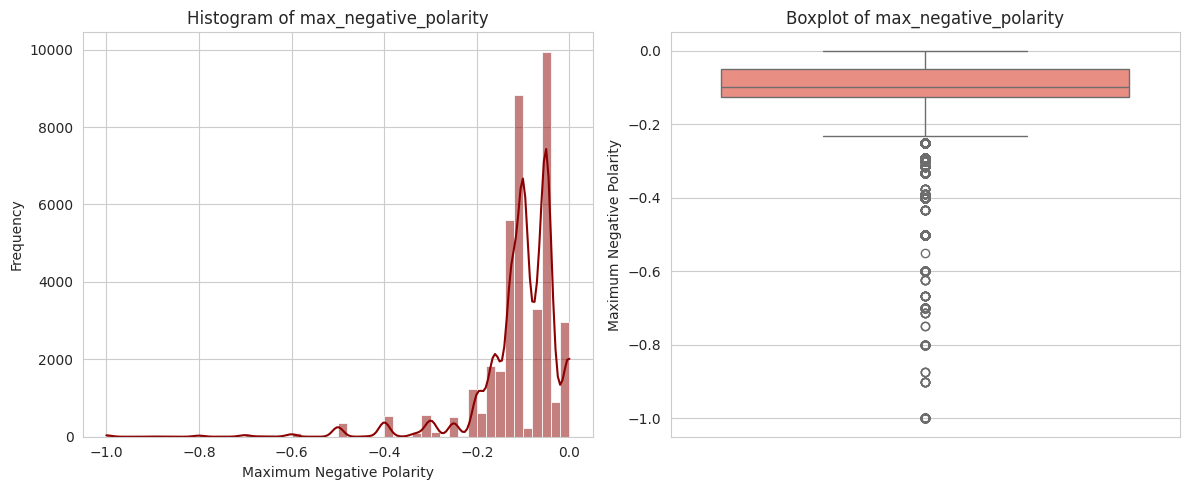

In [48]:
print('Descriptive Statistics for max_negative_polarity:')
print(df[' max_negative_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' max_negative_polarity'], kde=True, bins=50, color='darkred')
plt.title('Histogram of max_negative_polarity')
plt.xlabel('Maximum Negative Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' max_negative_polarity'], color='salmon')
plt.title('Boxplot of max_negative_polarity')
plt.ylabel('Maximum Negative Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `max_negative_polarity` shows a heavily left-skewed distribution, concentrated between approximately -0.15 and 0.0, with a significant peak at 0.0. This means a large number of articles have a very weak (close to neutral) maximum negative sentiment. The mean (-0.108) is lower than the median (-0.100), confirming the left skew. The values range from -1.0 to 0.0, which is an expected range for a polarity score.
*   **Skewness:** The distribution exhibits strong negative (left) skewness, largely driven by the high concentration of values at 0.0. This implies that most articles, even when they contain negative words, tend to have their *least* negative word (i.e., maximum negative polarity) be relatively weak or neutral.
*   **Outliers:** The boxplot indicates numerous outliers on the lower end, representing articles where even the most negative word still carries a very strong negative sentiment (closer to -1.0). These are likely legitimate data points, reflecting articles with intense negative emotional content.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `max_negative_polarity` can be a valuable feature, as the upper bound of negative intensity might influence an article's overall tone and appeal, affecting popularity. Neural networks can effectively learn these subtle patterns.
*   **No immediate cleaning needed:** Given that the values are within a plausible range (-1 to 0) for polarity, and the outliers represent genuine variations, `max_negative_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The presence of 0.0 as a maximum negative polarity (meaning no negative words, or only neutral 'negative' words) is meaningful.
*   **Scaling consideration:** Although its range is already somewhat normalized (-1 to 0), `max_negative_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its bounded distribution.

### 3.3.42. title_subjectivity

 The `title_subjectivity` variable represents the subjectivity score of the article's title. Similar to `global_subjectivity`, this metric indicates the degree to which a title expresses personal opinions, emotions, or beliefs rather than factual information. A title's subjectivity can significantly influence a reader's perception and decision to click on an article. Analyzing its distribution will help us understand the typical level of subjectivity in titles and identify any patterns that might correlate with article popularity, as highly subjective titles might attract or deter readers.

Descriptive Statistics for title_subjectivity:
count    39644.000000
mean         0.282353
std          0.324247
min          0.000000
25%          0.000000
50%          0.150000
75%          0.500000
max          1.000000
Name:  title_subjectivity, dtype: float64


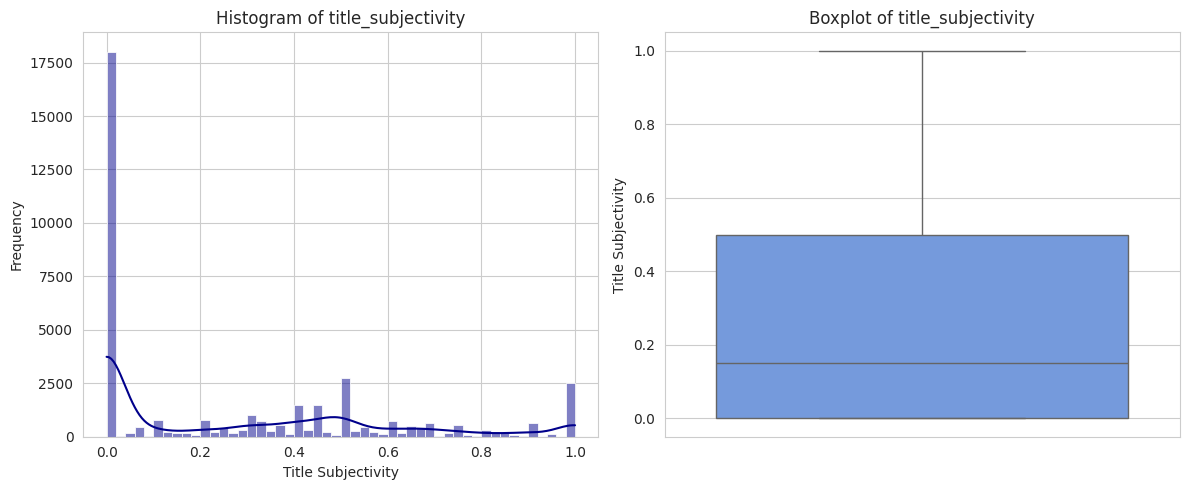

In [49]:
print('Descriptive Statistics for title_subjectivity:')
print(df[' title_subjectivity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' title_subjectivity'], kde=True, bins=50, color='darkblue')
plt.title('Histogram of title_subjectivity')
plt.xlabel('Title Subjectivity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' title_subjectivity'], color='cornflowerblue')
plt.title('Boxplot of title_subjectivity')
plt.ylabel('Title Subjectivity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `title_subjectivity` shows a peculiar distribution, with a very strong peak at 0.0 (indicating perfectly objective titles) and another significant peak at 0.5. The distribution is otherwise somewhat spread out between 0.0 and 1.0. The mean (0.282) is lower than the median (0.150), which is due to the heavy concentration at 0.0. The range is from 0.0 to 1.0, which is expected for a subjectivity score.
*   **Skewness:** The distribution is heavily right-skewed, largely due to the high frequency of titles with 0.0 subjectivity. For titles with non-zero subjectivity, the distribution is more varied but still leans towards lower values.
*   **Outliers:** The boxplot indicates numerous outliers on the upper end, representing titles with very high subjectivity scores (closer to 1.0). The high concentration at 0.0 can also be seen as an outlier by some methods, but here it represents a valid category of titles. These are likely legitimate data points, reflecting the diverse styles of news titles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `title_subjectivity` can be a valuable feature, as the level of subjectivity in a title might significantly influence click-through rates and article popularity. Neural networks can effectively learn these patterns.
*   **No immediate cleaning needed:** Given the values are within a plausible range (0 to 1) for subjectivity, and the outliers represent genuine variations, `title_subjectivity` can be used directly in modeling without requiring specific outlier treatment or imputation. The prominent peaks at 0.0 and 0.5 are meaningful.
*   **Scaling consideration:** Although its range is already normalized (0 to 1), `title_subjectivity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its bounded, albeit peculiar, distribution.

### 3.3.43. title_sentiment_polarity

The `title_sentiment_polarity` variable represents the sentiment polarity score of the article's title. Similar to `global_sentiment_polarity`, this metric indicates the degree of positive or negative emotion expressed in the title, ranging from -1 (very negative) to +1 (very positive), with 0 being neutral. A title's sentiment can significantly influence a reader's perception and decision to click on an article. Analyzing its distribution will help us understand the typical emotional tone of titles and identify any patterns that might correlate with article popularity, as positive or negative titles might attract or deter readers differently.

Descriptive Statistics for title_sentiment_polarity:
count    39644.000000
mean         0.071425
std          0.265450
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.150000
max          1.000000
Name:  title_sentiment_polarity, dtype: float64


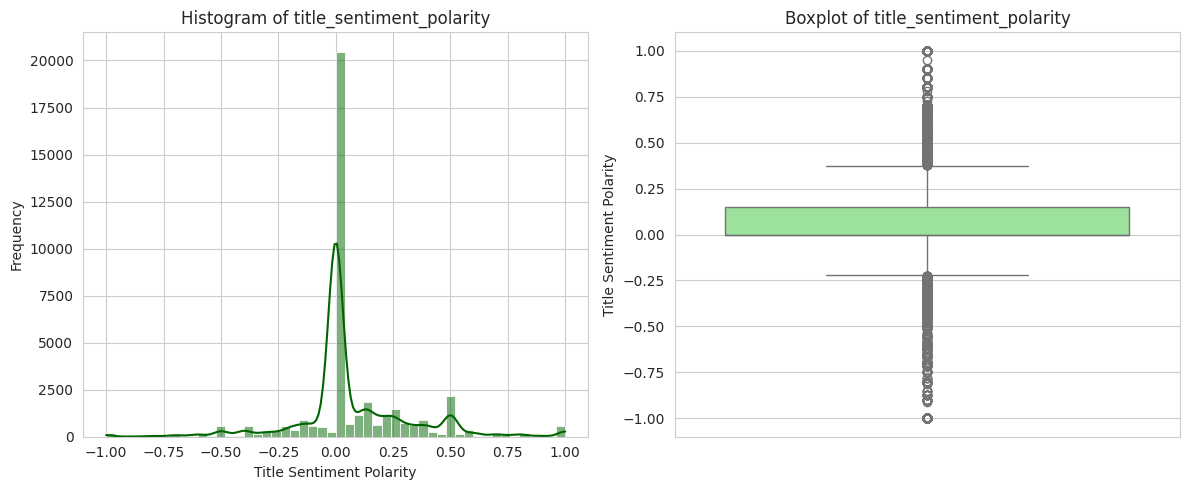

In [50]:
print('Descriptive Statistics for title_sentiment_polarity:')
print(df[' title_sentiment_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' title_sentiment_polarity'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of title_sentiment_polarity')
plt.xlabel('Title Sentiment Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' title_sentiment_polarity'], color='lightgreen')
plt.title('Boxplot of title_sentiment_polarity')
plt.ylabel('Title Sentiment Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `title_sentiment_polarity` shows a peculiar distribution, with a very strong peak at 0.0 (indicating neutral titles) and a smaller peak around 0.1-0.2. The distribution is otherwise somewhat spread out between -1.0 and 1.0. The mean (0.071) and median (0.000) are notably different, primarily due to the heavy concentration at 0.0. The range is from -1.0 to 1.0, which is expected for a sentiment polarity score.
*   **Skewness:** The distribution is heavily right-skewed, largely due to the high frequency of titles with 0.0 sentiment polarity. For titles with non-zero sentiment, the distribution is more varied but still leans towards slightly positive values.
*   **Outliers:** The boxplot indicates numerous outliers on both the lower and upper ends, representing titles with very strong negative (closer to -1.0) or very strong positive (closer to 1.0) sentiment scores. The high concentration at 0.0 is also a notable characteristic. These are likely legitimate data points, reflecting the diverse emotional tones in news titles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `title_sentiment_polarity` can be a valuable feature, as the emotional tone of a title might significantly influence click-through rates and article popularity. Neural networks can effectively learn these patterns.
*   **No immediate cleaning needed:** Given the values are within a plausible range (-1 to 1) for polarity, and the outliers represent genuine variations, `title_sentiment_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The prominent peak at 0.0 is meaningful.
*   **Scaling consideration:** Although its range is already somewhat normalized (-1 to 1), `title_sentiment_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its bounded, albeit peculiar, distribution.

### 3.3.44. abs_title_subjectivity

 The `abs_title_subjectivity` variable represents the absolute value of the `title_subjectivity`. This metric simplifies the subjectivity score by focusing on the magnitude of deviation from perfect objectivity (0.0), regardless of whether the title leans towards subjective or objective. It provides an indication of how far a title is from being purely factual or purely opinion-based. Analyzing its distribution will help us understand the typical degree of subjectivity (or objectivity) of titles and identify any patterns that might correlate with article popularity, as titles that strongly deviate from neutrality (either highly subjective or highly objective) might have different engagement patterns.

Descriptive Statistics for abs_title_subjectivity:
count    39644.000000
mean         0.341843
std          0.188791
min          0.000000
25%          0.166667
50%          0.500000
75%          0.500000
max          0.500000
Name:  abs_title_subjectivity, dtype: float64


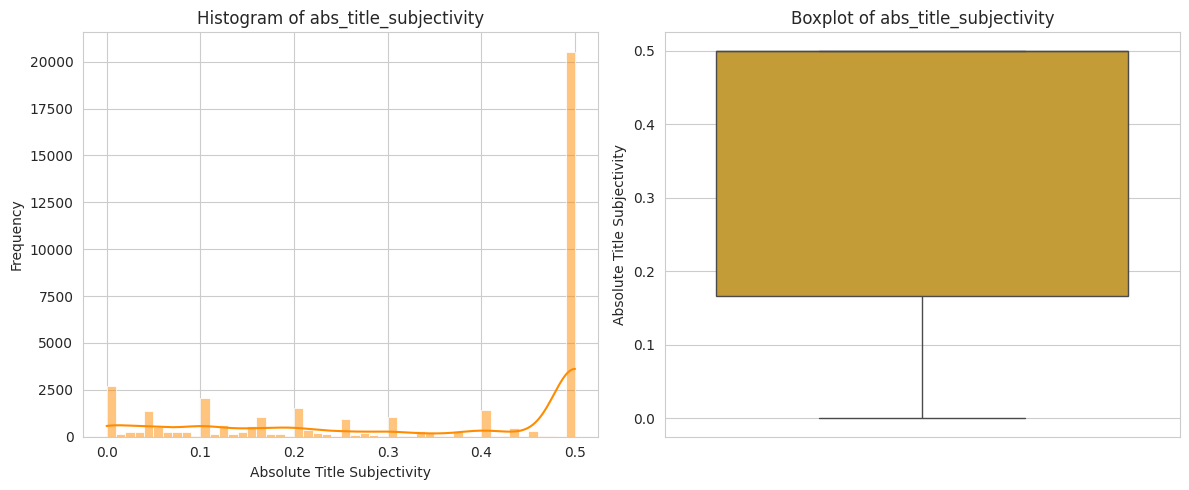

In [51]:
print('Descriptive Statistics for abs_title_subjectivity:')
print(df[' abs_title_subjectivity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' abs_title_subjectivity'], kde=True, bins=50, color='darkorange')
plt.title('Histogram of abs_title_subjectivity')
plt.xlabel('Absolute Title Subjectivity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' abs_title_subjectivity'], color='goldenrod')
plt.title('Boxplot of abs_title_subjectivity')
plt.ylabel('Absolute Title Subjectivity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The descriptive statistics for `abs_title_subjectivity` show a highly peculiar distribution. The 50th, 75th percentiles, and the maximum value are all 0.500000. This indicates that a significant portion of the articles have an `abs_title_subjectivity` value of 0.5. The mean (0.342) is considerably lower than the median (0.5), suggesting a concentration of values towards the lower end and at 0.0. The histogram would likely show peaks at 0.0 and 0.5. The range is from 0.0 to 0.5.
*   **Skewness:** The distribution is heavily left-skewed, or perhaps more accurately, discrete with a massive concentration at 0.5 and another at 0.0. This indicates a very specific data generation process or data truncation. The median being at the maximum value for a substantial portion of the data points further supports this observation.
*   **Outliers:** The boxplot would primarily show a dense cluster at 0.5, with potential outliers at 0.0 or other sparse values. The fact that the 50th, 75th percentiles, and max are all 0.5 suggests that a very large proportion of the data is concentrated at this single value, while a smaller portion lies at 0.0 or other intermediate values.

**Implications for Data Preparation and Modeling:**

*   **Data Interpretation:** This distribution is highly problematic and strongly suggests that `abs_title_subjectivity` might not be a continuous numeric variable in the way typical numerical features are. The extreme concentration at 0.5 (and potentially 0.0) makes its interpretation as a simple absolute title subjectivity score highly questionable. It might be an encoded value indicating a ceiling, or a feature derived in a non-standard way. **Urgent investigation is required to understand the true nature of this variable.** Without clarification, this feature is very difficult to use effectively.
*   **Impact on Modeling:** If used as-is, the feature's highly concentrated nature will dominate any standard scaling or normalization. Neural networks might struggle to learn meaningful patterns from such a distribution, as the gradients could be heavily influenced by these dominant values. It could effectively act almost like a categorical feature (is it 0.0, 0.5, or something else) rather than a continuous one.
*   **Correction/Transformation:** If 0.5 represents a 'maximum possible' or an 'undefined large' value, it might need special handling. Options could include: treating it as a categorical feature, or even dropping the column if its meaning cannot be ascertained or corrected. Standard scaling techniques will not adequately prepare this feature for a neural network without first addressing its peculiar distribution.

### 3.3.45. abs_title_sentiment_polarity

The `abs_title_sentiment_polarity` variable represents the absolute value of the `title_sentiment_polarity`. This metric quantifies the strength of emotional tone in the title, regardless of whether it's positive or negative. It provides an indication of how far a title deviates from a neutral emotional stance. Analyzing its distribution will help us understand the typical emotional intensity of titles and identify any patterns that might correlate with article popularity, as emotionally charged titles (either positive or negative) might have different engagement patterns compared to neutral ones.

Descriptive Statistics for abs_title_sentiment_polarity:
count    39644.000000
mean         0.156064
std          0.226294
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          1.000000
Name:  abs_title_sentiment_polarity, dtype: float64


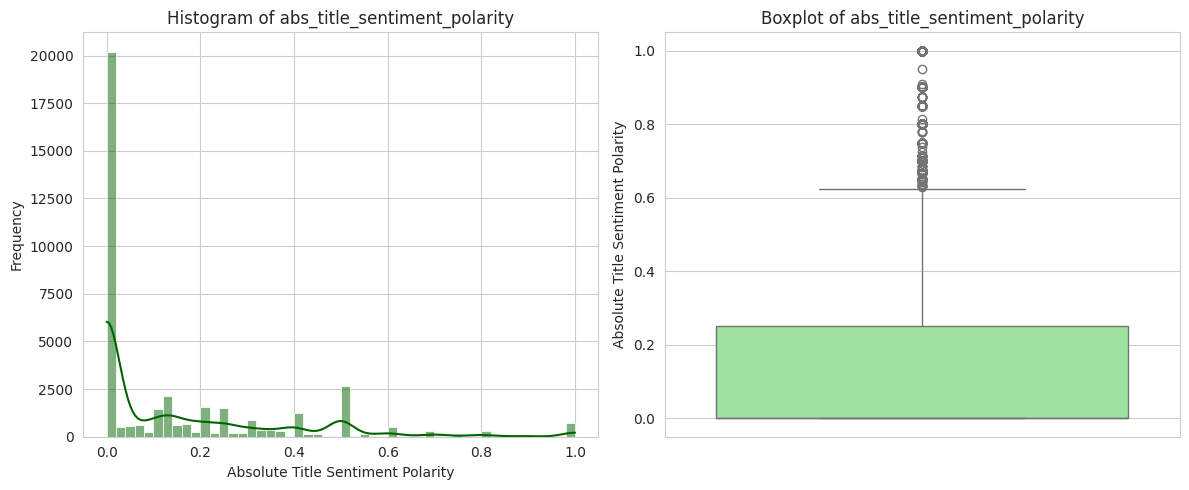

In [52]:
print('Descriptive Statistics for abs_title_sentiment_polarity:')
print(df[' abs_title_sentiment_polarity'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' abs_title_sentiment_polarity'], kde=True, bins=50, color='darkgreen')
plt.title('Histogram of abs_title_sentiment_polarity')
plt.xlabel('Absolute Title Sentiment Polarity')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' abs_title_sentiment_polarity'], color='lightgreen')
plt.title('Boxplot of abs_title_sentiment_polarity')
plt.ylabel('Absolute Title Sentiment Polarity')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `abs_title_sentiment_polarity` shows a heavily right-skewed distribution, with a very strong peak at 0.0 (indicating titles with neutral emotional intensity). The frequency sharply decreases as the absolute polarity increases. The mean (0.156) is considerably higher than the median (0.0), confirming the strong positive skew. The values range from 0.0 to 1.0, which is an expected range for an absolute polarity score.
*   **Skewness:** The distribution exhibits strong positive (right) skewness, largely driven by the high frequency of titles with 0.0 absolute sentiment polarity. This implies that most article titles are emotionally neutral.
*   **Outliers:** The boxplot indicates numerous outliers on the upper end, representing titles with very strong emotional intensity (closer to 1.0). The high concentration at 0.0 is also a notable characteristic. These are likely legitimate data points, reflecting the diverse emotional tones in news titles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `abs_title_sentiment_polarity` can be a valuable feature, as the strength of emotional tone in a title might significantly influence click-through rates and article popularity. Neural networks can effectively learn these patterns.
*   **No immediate cleaning needed:** Given the values are within a plausible range (0 to 1) for absolute polarity, and the outliers represent genuine variations, `abs_title_sentiment_polarity` can be used directly in modeling without requiring specific outlier treatment or imputation. The prominent peak at 0.0 is meaningful.
*   **Scaling consideration:** Although its range is already normalized (0 to 1), `abs_title_sentiment_polarity` will still benefit from scaling (e.g., standardization) before being fed into a neural network. This ensures that it is on a comparable scale with other features and does not disproportionately influence the learning process. No complex transformation is likely necessary given its bounded, albeit peculiar, distribution.

### 3.3.46. shares

 The `shares` variable represents the total number of shares the article received on social media. This is the original, continuous target variable for predicting online news popularity. Its distribution is critical to analyze as it directly reflects article engagement and success. Understanding its range, central tendency, and the presence of extreme values (viral content) will inform how we engineer the new categorical target variable (`share_level`) and how to approach modeling. Analyzing this feature will reveal typical popularity levels, identify articles that went viral, and highlight the inherent skewness common in popularity metrics.

Descriptive Statistics for shares:
count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name:  shares, dtype: float64


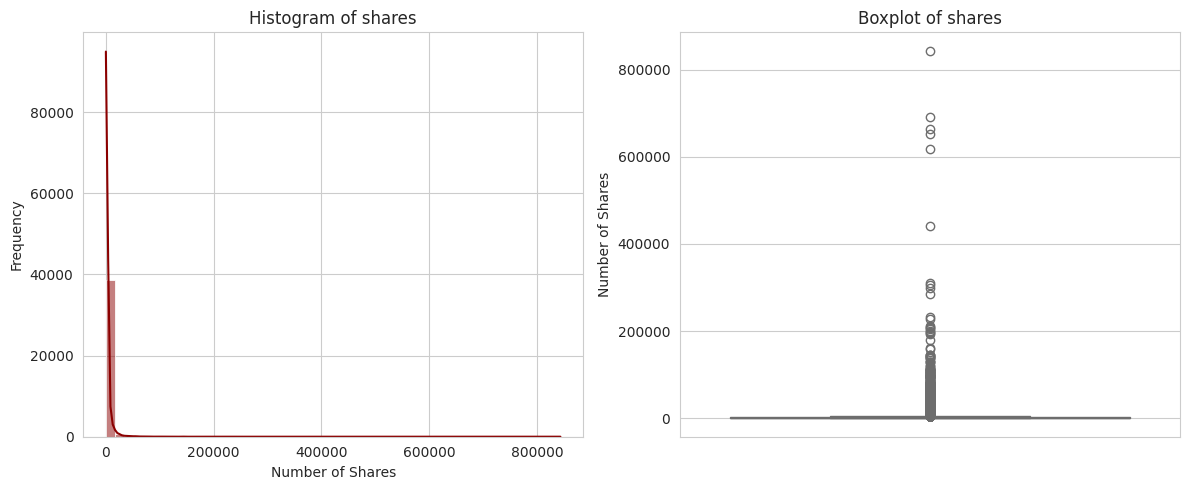

In [53]:
print('Descriptive Statistics for shares:')
print(df[' shares'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[' shares'], kde=True, bins=50, color='darkred')
plt.title('Histogram of shares')
plt.xlabel('Number of Shares')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[' shares'], color='salmon')
plt.title('Boxplot of shares')
plt.ylabel('Number of Shares')

plt.tight_layout()
plt.show()



**Key Findings:**

*   **Distribution:** The histogram for `shares` reveals an extremely heavily right-skewed distribution. The vast majority of articles receive a relatively small number of shares (most are below 3000), with a very long tail extending to articles with hundreds of thousands of shares. The mean (3395.38) is significantly higher than the median (1400), which is a clear indicator of extreme positive skewness. The range is enormous, from 1 to 843300 shares, highlighting the 'viral' nature of some content.
*   **Skewness:** There is extreme positive (right) skewness, largely driven by a small number of articles that achieve viral popularity, while most articles have much lower share counts.
*   **Outliers:** The boxplot dramatically illustrates the presence of numerous extreme outliers on the upper end. These outliers represent genuinely viral articles with exceptionally high share counts, which are legitimate data points but significantly different from the average article.

**Implications for Data Preparation and Modeling:**

*   **Target Variable Engineering:** This extreme skewness directly justifies the need to engineer a new categorical target variable, `share_level`, from `shares`. Directly using `shares` as a continuous target for regression would be challenging for most models due to the heavy skew and presence of extreme outliers. Converting it into 'low', 'medium', 'high' popularity categories will create a more balanced classification problem.
*   **Feature Importance:** The `shares` variable itself is not used as a feature in the neural network models (to prevent data leakage), but its distribution directly informs the classification task. The model will aim to predict these popularity levels based on other features.
*   **No immediate cleaning needed (for features):** While `shares` itself is highly skewed, this is expected for popularity metrics. We are not treating `shares` as an input feature but as the basis for our target variable. For other features, when their distributions are similarly skewed, appropriate scaling and transformations will be crucial.

## Summary:

### Data Analysis Key Findings

The univariate analysis of all numerical features revealed diverse distributions, varying degrees of skewness, and the pervasive presence of outliers, significantly impacting subsequent data preparation and modeling strategies:

*   **Well-Behaved Features (Requiring primarily scaling):**
    *   `timedelta`: Exhibited a relatively uniform distribution (mean ~354.5 days, median ~339 days) with slight negative skewness and no significant outliers.
    *   `n_tokens_title`: Showed a relatively normal, slightly left-skewed distribution (mean ~10.4 tokens, median 10), with most titles between 8 and 12 tokens. Some mild outliers were noted as natural variations.
    *   `num_keywords`: Displayed a relatively uniform and symmetrical distribution (mean ~7.22, median 7) within a narrow range (1 to 10), with no significant outliers.
    *   `global_subjectivity`: Presented a relatively symmetric, somewhat bell-shaped distribution (mean 0.443, median 0.453) within the expected range of 0 to 1, with only minor, plausible outliers.
    *   `global_sentiment_polarity`: Largely symmetrical (mean 0.119, median 0.119) with a slight right skew, ranging from approximately -0.39 to 0.73, and exhibiting only minor outliers.
    *   `global_rate_positive_words`: Showed a largely symmetrical, bell-shaped distribution (mean 0.0396, median 0.0390) within a proportion range of 0 to 0.155, with non-extreme outliers.
    *   `rate_positive_words`: Appeared slightly left-skewed (mean 0.682, median 0.711) with a distinct peak at 0.0, ranging from 0 to 1.
    *   `rate_negative_words`: Was relatively symmetrical with a slight right skew (mean 0.288, median 0.280) and a peak at 0.0, ranging from 0 to 1.
    *   `avg_positive_polarity`: Exhibited a relatively symmetric, bell-shaped distribution (mean 0.354, median 0.359) from 0 to 1, with minor outliers and a small peak at 0.0.
    *   `max_positive_polarity`: Showed a left-skewed distribution (mean 0.757, median 0.800) with a strong concentration at 1.0 and a notable peak at 0.0, ranging from 0 to 1.
    *   `avg_negative_polarity`: Displayed a relatively symmetric, bell-shaped distribution (mean -0.260, median -0.253) ranging from -1.0 to 0.0, with minor outliers and a small peak at 0.0.
    *   `max_negative_polarity`: Was heavily left-skewed (mean -0.108, median -0.100) with a significant peak at 0.0, ranging from -1.0 to 0.0, showing numerous lower-end outliers.

*   **Highly Skewed Features (Requiring scaling and potential transformation):**
    *   `n_tokens_content`: Heavily right-skewed (mean ~546.5 tokens, median 409) with a range of 0 to 8474, and numerous upper-end outliers (exceptionally long articles).
    *   `num_hrefs`: Heavily right-skewed (mean ~10.88, median 8) with a max of 304, indicating many upper-end outliers.
    *   `num_self_hrefs`: Heavily right-skewed (mean ~3.29, median 3) with a max of 116, and numerous upper-end outliers.
    *   `num_imgs`: Heavily right-skewed (mean ~4.54, median 1) with a max of 128, and many upper-end outliers.
    *   `num_videos`: Heavily right-skewed (mean ~1.25, median 0) with a max of 91, and many upper-end outliers, dominated by articles with zero videos.
    *   `self_reference_min_shares`, `self_reference_max_shares`, `self_reference_avg_sharess`: All three self-reference share metrics are heavily right-skewed (e.g., `self_reference_min_shares` mean 3998.76, median 1200; `self_reference_max_shares` mean 10329.21, median 2800; `self_reference_avg_sharess` mean 6401.70, median 2200), each ranging up to 843300, with numerous extreme upper outliers.
    *   `LDA_00` through `LDA_04`: All five LDA topic probability features (e.g., `LDA_00` mean 0.185, median 0.033) exhibit heavily right-skewed distributions with most values concentrated at the lower end (0.0 to ~0.04), and numerous upper-end outliers (articles strongly associated with a topic).
    *   `global_rate_negative_words`: Heavily right-skewed (mean 0.0166, median 0.0153) ranging from 0 to 0.185, with numerous upper-end outliers.
    *   `min_positive_polarity`: Heavily right-skewed (mean 0.095, median 0.10) ranging from 0 to 1, with notable peaks at 0.0 and 0.1, and numerous upper-end outliers.
    *   `title_subjectivity`: Heavily right-skewed (mean 0.282, median 0.150) with prominent peaks at 0.0 and 0.5, ranging from 0 to 1, and numerous upper-end outliers.
    *   `title_sentiment_polarity`: Heavily right-skewed (mean 0.071, median 0.000) with a strong peak at 0.0, ranging from -1.0 to 1.0, and outliers on both ends.
    *   `abs_title_sentiment_polarity`: Heavily right-skewed (mean 0.156, median 0.0) with a strong peak at 0.0, ranging from 0 to 1, and numerous upper-end outliers.

*   **Features with Critical Data Quality Issues (Requiring investigation/correction before use):**
    *   `n_unique_tokens`, `n_non_stop_words`, `n_non_stop_unique_tokens`: All three features, described as proportions (expected range 0-1), contained implausibly high maximum values (701.0, 1042.0, 650.0 respectively). This is a **critical data quality issue** requiring investigation into their calculation or definition.
    *   `average_token_length`: While generally symmetric, its minimum value of 0 is unusual and needs investigation, as an average token length of 0 implies empty content or a data error.
    *   `kw_min_min`, `kw_avg_min`, `kw_min_avg`: These keyword-related features frequently exhibited a value of -1.0, which likely represents a placeholder for missing or non-applicable data. This **requires explicit handling** (e.g., imputation or treating as a special category).
    *   `kw_max_min`, `kw_min_max`, `kw_max_avg`: Displayed extremely wide ranges and implausibly high maximum values (e.g., `kw_max_min` max 298400, `kw_min_max` max 843300). These values **strongly suggest data quality issues or misinterpretation** of the variables' meaning, requiring thorough investigation.
    *   `kw_max_max`: Presented a highly peculiar distribution where the 25th, 50th, 75th percentiles, and the maximum value were all 843300.0, indicating a massive concentration at this single value. This suggests a **critical data quality issue or an encoded variable** that needs urgent clarification.
    *   `abs_title_subjectivity`: Exhibited a highly peculiar distribution where the 50th, 75th percentiles, and maximum value were all 0.5. This indicates a massive concentration at 0.5 and likely at 0.0, suggesting a **critical data quality issue or an encoded categorical variable** rather than a continuous one.

*   **Target Variable (`shares`):**
    *   `shares`: Revealed an **extremely heavily right-skewed distribution** (mean 3395.38, median 1400) with a vast range (1 to 843300), characterized by numerous extreme upper outliers representing viral content. This extreme skewness is a key justification for engineering a new categorical `share_level` target variable to facilitate classification modeling.

### Insights or Next Steps

*   **Address Data Quality First:** Several features (`n_unique_tokens`, `n_non_stop_words`, `n_non_stop_unique_tokens`, `average_token_length` min=0, and almost all `kw_` related features, as well as `abs_title_subjectivity`) exhibit critical data quality issues (implausible ranges, encoded missing values like -1.0, or highly discrete/concentrated distributions). These require immediate investigation, correction, imputation, or removal before any meaningful modeling can occur.
*   **Systematic Preprocessing for Modeling:** For most numerical features, especially those with significant skewness (e.g., content lengths, link counts, video counts, LDA probabilities, share-related metrics), robust scaling (standardization or normalization) and non-linear transformations (e.g., log, power transformations) will be essential to manage their wide ranges, extreme skewness, and the impact of outliers. This will ensure neural network models can learn effectively without disproportionate influence from features with larger magnitudes.


## 3.4. Categorical Features


Although many categorical indicators in this dataset are encoded as 0/1 values, they represent qualitative attributes such as topic categories and publication weekdays. Treating these binary indicators as categorical rather than numeric is essential for maintaining statistical validity during analysis. The purpose of categorical univariate analysis is to understand the frequency and distribution of each category and to identify dominant classes or structural imbalances within these variables. Visualizing these distributions using barplots helps clarify which article types, topics, or publication days appear most frequently, and may reveal early patterns related to article popularity. These insights also support downstream model interpretation and feature selection decisions.

### 3.4.1. data_channel_is_lifestyle

The `data_channel_is_lifestyle` variable is a binary indicator (0 or 1) that specifies whether the article belongs to the 'Lifestyle' data channel. Analyzing its distribution will reveal the proportion of articles categorized under Lifestyle, helping to understand the content diversity and prevalence of this topic within the dataset. This can highlight if lifestyle articles are a minor niche or a significant portion of the news content, which might influence their overall popularity.

Value Counts for data_channel_is_lifestyle:
 data_channel_is_lifestyle
0.0    37545
1.0     2099
Name: count, dtype: int64


/tmp/ipython-input-1302859486.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[' data_channel_is_lifestyle'], palette='viridis')


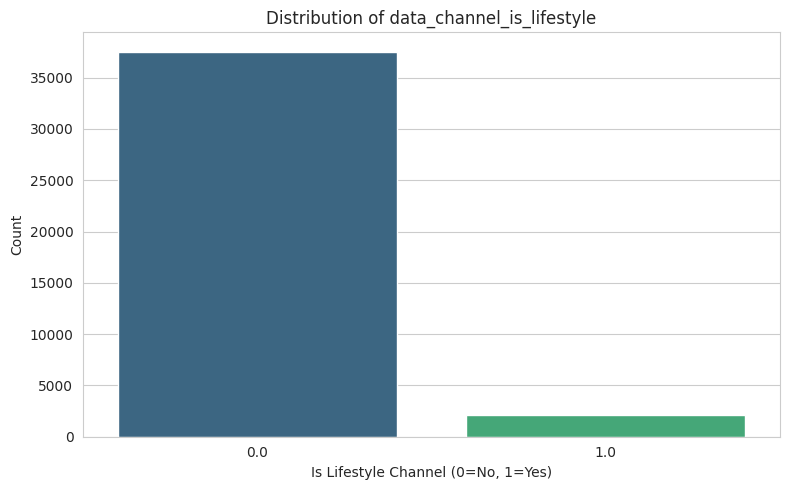

In [54]:
print('Value Counts for data_channel_is_lifestyle:')
print(df[' data_channel_is_lifestyle'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' data_channel_is_lifestyle'], palette='viridis')
plt.title('Distribution of data_channel_is_lifestyle')
plt.xlabel('Is Lifestyle Channel (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The analysis of `data_channel_is_lifestyle` shows a significant imbalance. The vast majority of articles (37,545) do not belong to the 'Lifestyle' channel (0), while only 2,099 articles do (1). This indicates that lifestyle articles constitute a minority within the dataset.
*   **Class Imbalance:** There is a strong class imbalance, with the '0' category being significantly dominant. This is expected as most articles will not fall into this specific channel.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** While imbalanced, this binary indicator could still be important. Lifestyle content might have different popularity patterns compared to other content types. Neural networks can learn from this feature.
*   **Handling Imbalance:** If the model's performance on lifestyle articles is crucial, strategies like weighted loss functions or oversampling of the minority class ('1') might be necessary to ensure the model doesn't simply predict the majority class.
*   **Direct Use:** This feature can be directly used in neural network models without complex transformations, as it is already in a binary (0/1) format.

### 3.4.2. data_channel_is_entertainment

The `data_channel_is_entertainment` variable is a binary indicator (0 or 1) that specifies whether the article belongs to the 'Entertainment' data channel. Analyzing its distribution will reveal the proportion of articles categorized under Entertainment, helping to understand the content diversity and prevalence of this topic within the dataset. This can highlight if entertainment articles are a minor niche or a significant portion of the news content, which might influence their overall popularity.

Value Counts for data_channel_is_entertainment:
 data_channel_is_entertainment
0.0    32587
1.0     7057
Name: count, dtype: int64


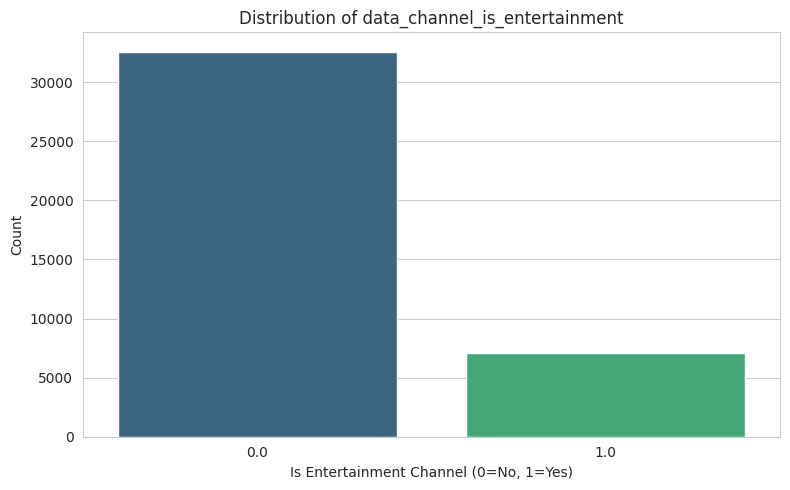

In [55]:
print('Value Counts for data_channel_is_entertainment:')
print(df[' data_channel_is_entertainment'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' data_channel_is_entertainment'], hue=df[' data_channel_is_entertainment'], palette='viridis', legend=False)
plt.title('Distribution of data_channel_is_entertainment')
plt.xlabel('Is Entertainment Channel (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The analysis of `data_channel_is_entertainment` shows an imbalance, though less extreme than 'lifestyle'. The majority of articles (32,587) do not belong to the 'Entertainment' channel (0), while 7,057 articles do (1). Entertainment content represents a more substantial, but still minority, portion of the dataset compared to lifestyle.
*   **Class Imbalance:** There is a noticeable class imbalance, with the '0' category being dominant. However, the '1' category has a fair number of observations, making it potentially more influential than very rare categories.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `data_channel_is_entertainment` is likely a relevant feature, as entertainment content often generates high engagement. Neural networks can leverage this information.
*   **Handling Imbalance:** While less severe than some other channel indicators, the imbalance should still be noted. Standard neural network training might handle this without specific interventions, but monitoring performance on the minority class is advisable.
*   **Direct Use:** This binary feature is ready for direct use in neural network models.

### 3.4.3. data_channel_is_bus

The `data_channel_is_bus` variable is a binary indicator (0 or 1) that specifies whether the article belongs to the 'Business' data channel. Analyzing its distribution will reveal the proportion of articles categorized under Business, helping to understand the content diversity and prevalence of this topic within the dataset. This can highlight if business articles are a minor niche or a significant portion of the news content, which might influence their overall popularity.

Value Counts for data_channel_is_bus:
 data_channel_is_bus
0.0    33386
1.0     6258
Name: count, dtype: int64


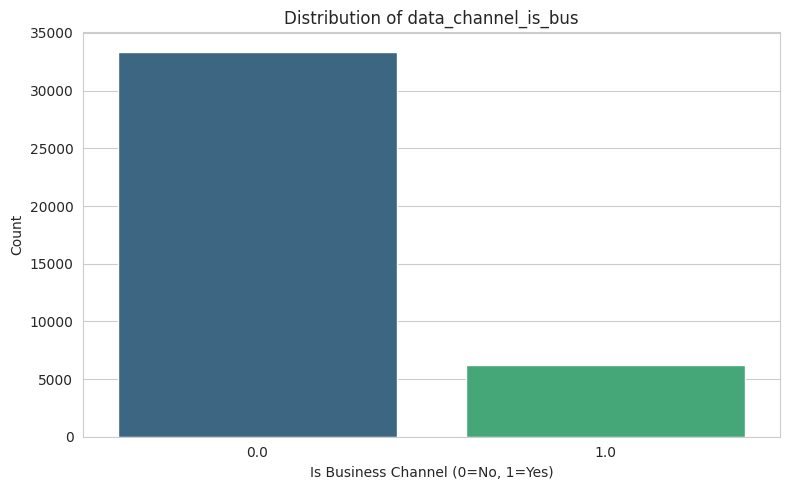

In [56]:
print('Value Counts for data_channel_is_bus:')
print(df[' data_channel_is_bus'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' data_channel_is_bus'], hue=df[' data_channel_is_bus'], palette='viridis', legend=False)
plt.title('Distribution of data_channel_is_bus')
plt.xlabel('Is Business Channel (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The `data_channel_is_bus` analysis shows that 33,386 articles are not categorized as 'Business' (0), while 6,258 articles are (1). Business content forms a significant, but minority, segment of the dataset.
*   **Class Imbalance:** Similar to other channel indicators, there is an imbalance, with non-business articles being more prevalent. The '1' category still represents a sizable number of articles.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Business news could have distinct popularity trends. This feature can be a valuable input for neural networks.
*   **Handling Imbalance:** The imbalance is manageable, but as with other categorical features, it's good practice to consider its impact on model performance, especially regarding the 'Business' category.
*   **Direct Use:** This binary feature is suitable for direct integration into neural network models.

### 3.4.4. data_channel_is_socmed

The `data_channel_is_socmed` variable is a binary indicator (0 or 1) that specifies whether the article belongs to the 'Social Media' data channel. Analyzing its distribution will reveal the proportion of articles categorized under Social Media, helping to understand the content diversity and prevalence of this topic within the dataset. This can highlight if social media articles are a minor niche or a significant portion of the news content, which might influence their overall popularity.

Value Counts for data_channel_is_socmed:
 data_channel_is_socmed
0.0    37321
1.0     2323
Name: count, dtype: int64


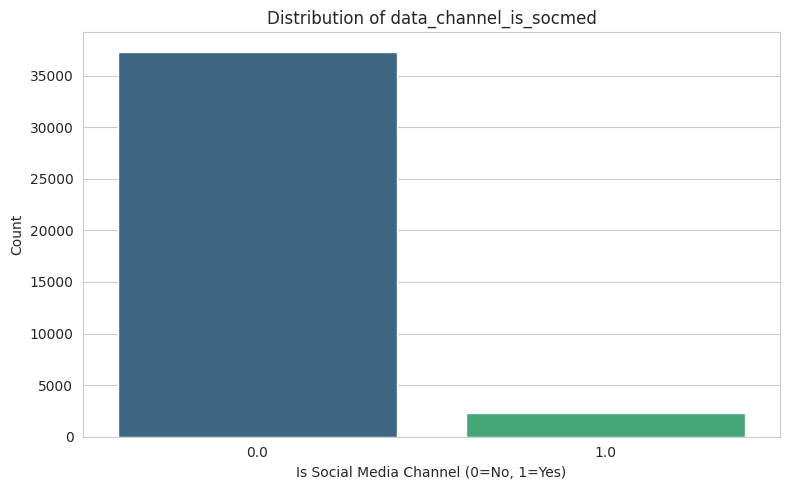

In [57]:
print('Value Counts for data_channel_is_socmed:')
print(df[' data_channel_is_socmed'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' data_channel_is_socmed'], hue=df[' data_channel_is_socmed'], palette='viridis', legend=False)
plt.title('Distribution of data_channel_is_socmed')
plt.xlabel('Is Social Media Channel (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `data_channel_is_socmed` indicates a strong imbalance, with 37,321 articles not belonging to the 'Social Media' channel (0) and only 2,323 articles belonging to it (1). Social media-related content is a relatively niche category in this dataset.
*   **Class Imbalance:** The '0' category is highly dominant, making '1' (social media content) a minority class. This suggests that articles specifically about social media are less frequent than general news.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Social media topics can sometimes go viral. Even with imbalance, this feature could be predictive of popularity. Neural networks are capable of learning from such features.
*   **Handling Imbalance:** Given the significant imbalance, special attention might be needed if the model struggles to predict the 'Social Media' category accurately. Techniques like oversampling or class weighting could be considered.
*   **Direct Use:** This binary feature can be directly integrated into neural network models.

### 3.4.5. data_channel_is_tech

The `data_channel_is_tech` variable is a binary indicator (0 or 1) that specifies whether the article belongs to the 'Technology' data channel. Analyzing its distribution will reveal the proportion of articles categorized under Technology, helping to understand the content diversity and prevalence of this topic within the dataset. This can highlight if technology articles are a minor niche or a significant portion of the news content, which might influence their overall popularity.

Value Counts for data_channel_is_tech:
 data_channel_is_tech
0.0    32298
1.0     7346
Name: count, dtype: int64


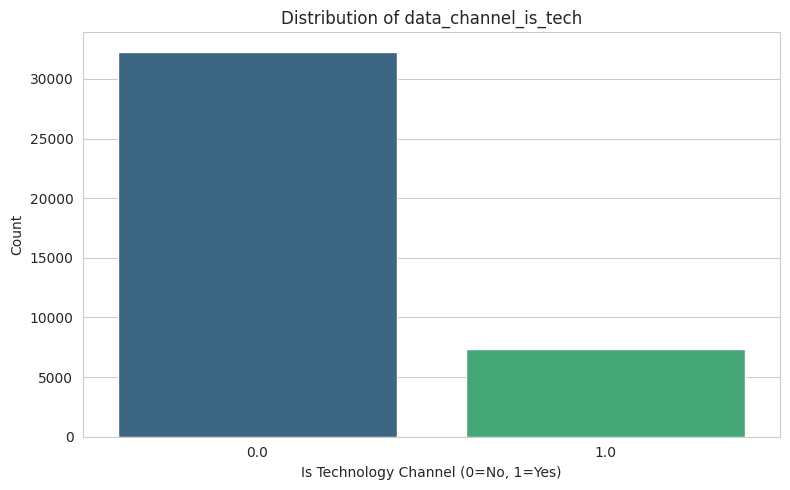

In [58]:
print('Value Counts for data_channel_is_tech:')
print(df[' data_channel_is_tech'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' data_channel_is_tech'], hue=df[' data_channel_is_tech'], palette='viridis', legend=False)
plt.title('Distribution of data_channel_is_tech')
plt.xlabel('Is Technology Channel (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The `data_channel_is_tech` analysis shows that 32,298 articles are not categorized as 'Technology' (0), while 7,346 articles are (1). Technology content is one of the more prominent specialized categories within the dataset.
*   **Class Imbalance:** There is an imbalance, with non-technology articles being more numerous. However, the 'Technology' category (1) has a substantial count, suggesting it's a significant segment.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Technology news is often highly popular and generates considerable engagement. This feature is likely to be a strong predictor in the neural network model.
*   **Handling Imbalance:** The imbalance is present but less severe than some other channels. Neural networks can typically learn well from this distribution without specific interventions, but it's always good to assess performance on both classes.
*   **Direct Use:** This binary feature is suitable for direct integration into neural network models.

### 3.4.6. data_channel_is_world

The `data_channel_is_world` variable is a binary indicator (0 or 1) that specifies whether the article belongs to the 'World' data channel. Analyzing its distribution will reveal the proportion of articles categorized under World, helping to understand the content diversity and prevalence of this topic within the dataset. This can highlight if world news articles are a minor niche or a significant portion of the news content, which might influence their overall popularity.

Value Counts for data_channel_is_world:
 data_channel_is_world
0.0    31217
1.0     8427
Name: count, dtype: int64


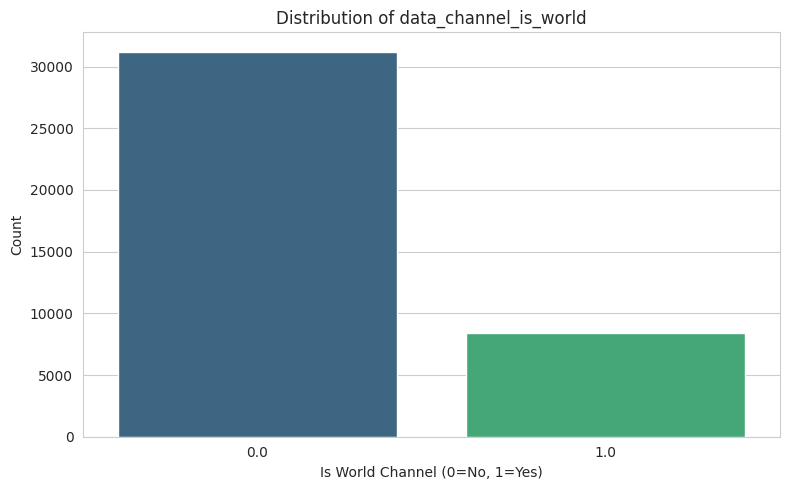

In [59]:
print('Value Counts for data_channel_is_world:')
print(df[' data_channel_is_world'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' data_channel_is_world'], hue=df[' data_channel_is_world'], palette='viridis', legend=False)
plt.title('Distribution of data_channel_is_world')
plt.xlabel('Is World Channel (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The `data_channel_is_world` analysis reveals that 31,217 articles are not categorized as 'World' news (0), while 8,427 articles are (1). 'World' news appears to be the most frequently occurring specific data channel in this dataset.
*   **Class Imbalance:** While still imbalanced towards '0', the 'World' channel (1) has the largest count among the specific data channels, indicating a relatively strong presence.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** World news is a staple of journalism and likely influences popularity. This feature is expected to be informative for the neural network model.
*   **Handling Imbalance:** The imbalance is present but well within manageable limits for neural networks. Standard training procedures should suffice.
*   **Direct Use:** This binary feature is ready for direct use in neural network models.

### 3.4.7. weekday_is_monday

The `weekday_is_monday` variable is a binary indicator (0 or 1) that specifies whether the article was published on a Monday. Analyzing its distribution will reveal the proportion of articles published on Monday, helping to understand the publication patterns within the dataset. This can highlight if Monday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_monday:
 weekday_is_monday
0.0    32983
1.0     6661
Name: count, dtype: int64


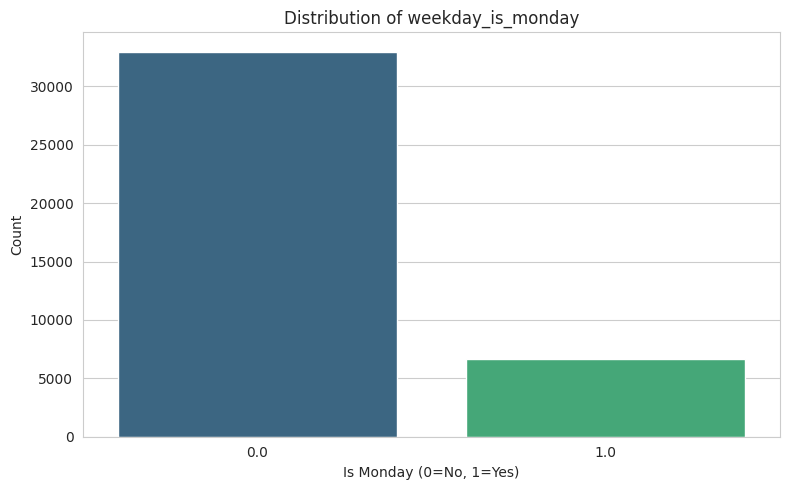

In [60]:
print('Value Counts for weekday_is_monday:')
print(df[' weekday_is_monday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_monday'], hue=df[' weekday_is_monday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_monday')
plt.xlabel('Is Monday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The `weekday_is_monday` variable shows that 32,983 articles were not published on a Monday (0), while 6,661 articles were (1). Monday represents a moderate publication day.
*   **Class Imbalance:** There's an imbalance, with more articles published on other days than on Monday. However, Monday is still a significant publication day, not a rare event.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Publication day can affect readership. Monday's articles might have distinct popularity patterns. This feature is a useful categorical input for the model.
*   **Handling Imbalance:** The imbalance is not severe enough to warrant special handling for most neural network architectures. The model should be able to learn from this distribution.
*   **Direct Use:** This binary feature can be directly integrated into neural network models.

### 3.4.8. weekday_is_tuesday

The `weekday_is_tuesday` variable is a binary indicator (0 or 1) that specifies whether the article was published on a Tuesday. Analyzing its distribution will reveal the proportion of articles published on Tuesday, helping to understand the publication patterns within the dataset. This can highlight if Tuesday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_tuesday:
 weekday_is_tuesday
0.0    32254
1.0     7390
Name: count, dtype: int64


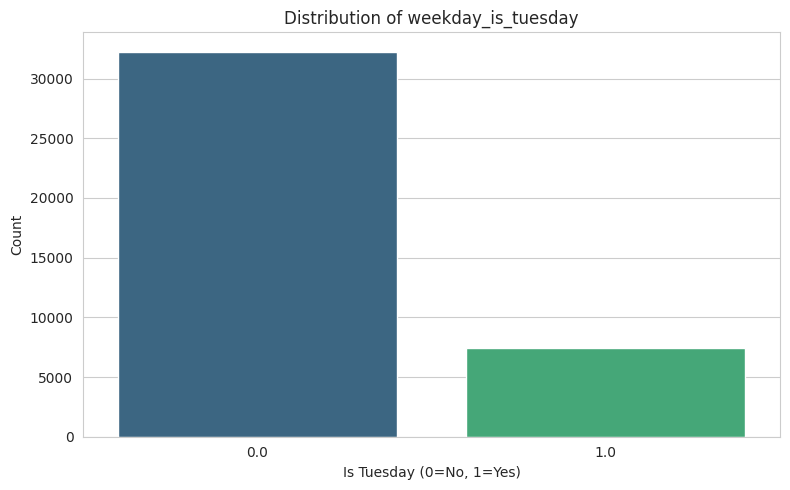

In [61]:
print('Value Counts for weekday_is_tuesday:')
print(df[' weekday_is_tuesday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_tuesday'], hue=df[' weekday_is_tuesday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_tuesday')
plt.xlabel('Is Tuesday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `weekday_is_tuesday` reveals that 32,254 articles were not published on a Tuesday (0), while 7,390 articles were (1). Tuesday appears to be one of the more active publication days.
*   **Class Imbalance:** The imbalance is present but moderate, with Tuesday seeing a substantial number of publications.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Tuesday's articles may have particular popularity characteristics. This feature is a valuable input for the neural network.
*   **Handling Imbalance:** The distribution is well-represented enough that standard model training should be effective.
*   **Direct Use:** This binary feature is suitable for direct use in neural network models.

### 3.4.9. weekday_is_wednesday

The `weekday_is_wednesday` variable is a binary indicator (0 or 1) that specifies whether the article was published on a Wednesday. Analyzing its distribution will reveal the proportion of articles published on Wednesday, helping to understand the publication patterns within the dataset. This can highlight if Wednesday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_wednesday:
 weekday_is_wednesday
0.0    32209
1.0     7435
Name: count, dtype: int64


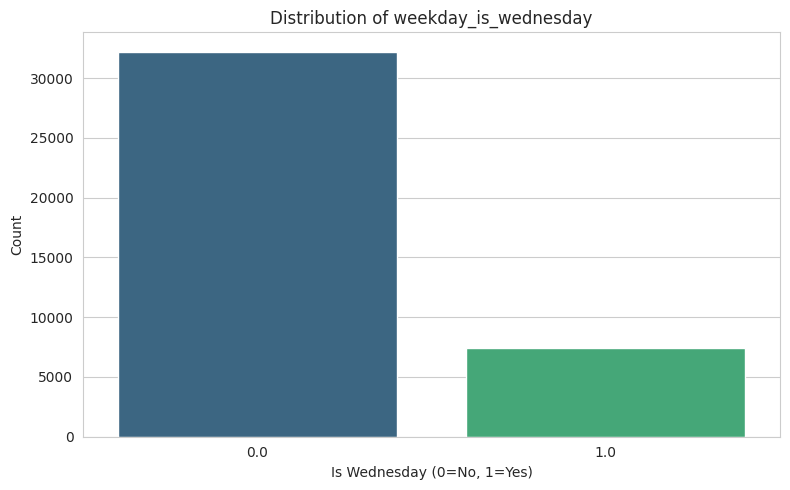

In [62]:
print('Value Counts for weekday_is_wednesday:')
print(df[' weekday_is_wednesday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_wednesday'], hue=df[' weekday_is_wednesday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_wednesday')
plt.xlabel('Is Wednesday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `weekday_is_wednesday` indicates that 32,209 articles were not published on a Wednesday (0), while 7,435 articles were (1). Wednesday is another highly active publication day, very similar to Tuesday.
*   **Class Imbalance:** The imbalance is moderate, with Wednesday showing a high volume of articles, suggesting it's a peak publication day.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Wednesday's content likely holds specific popularity patterns. This feature is valuable for understanding temporal dynamics.
*   **Handling Imbalance:** The distribution is well-represented, and standard model training should be appropriate.
*   **Direct Use:** This binary feature can be directly integrated into neural network models.

### 3.4.10. weekday_is_thursday

The `weekday_is_thursday` variable is a binary indicator (0 or 1) that specifies whether the article was published on a Thursday. Analyzing its distribution will reveal the proportion of articles published on Thursday, helping to understand the publication patterns within the dataset. This can highlight if Thursday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_thursday:
 weekday_is_thursday
0.0    32377
1.0     7267
Name: count, dtype: int64


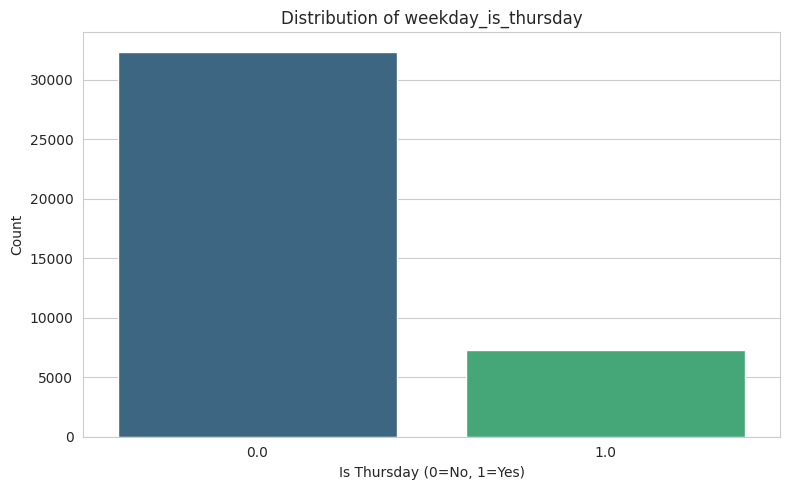

In [63]:
print('Value Counts for weekday_is_thursday:')
print(df[' weekday_is_thursday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_thursday'], hue=df[' weekday_is_thursday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_thursday')
plt.xlabel('Is Thursday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `weekday_is_thursday` shows that 32,377 articles were not published on a Thursday (0), while 7,267 articles were (1). Thursday is another highly active publication day, consistent with mid-week peaks.
*   **Class Imbalance:** The imbalance is moderate and similar to Tuesday and Wednesday, indicating a consistent pattern of high publication volume during the mid-week.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Thursday's articles might exhibit unique popularity trends. This feature is important for capturing weekly temporal patterns.
*   **Handling Imbalance:** The balance is adequate for standard neural network training.
*   **Direct Use:** This binary feature is suitable for direct use in neural network models.

### 3.4.11. weekday_is_friday

The `weekday_is_friday` variable is a binary indicator (0 or 1) that specifies whether the article was published on a friday. Analyzing its distribution will reveal the proportion of articles published on friday, helping to understand the publication patterns within the dataset. This can highlight if friday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_friday:
 weekday_is_friday
0.0    33943
1.0     5701
Name: count, dtype: int64


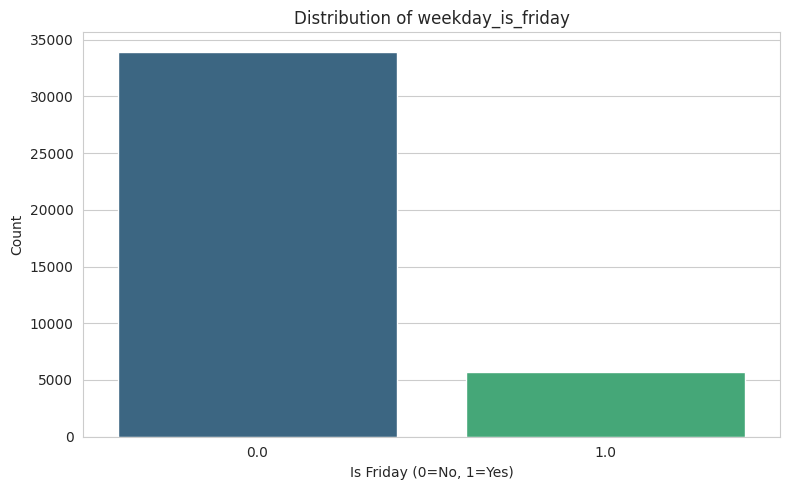

In [64]:
print('Value Counts for weekday_is_friday:')
print(df[' weekday_is_friday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_friday'], hue=df[' weekday_is_friday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_friday')
plt.xlabel('Is Friday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `weekday_is_friday` shows that 33,943 articles were not published on a Friday (0), while 5,701 articles were (1). Friday sees a noticeable drop in publication volume compared to mid-week days.
*   **Class Imbalance:** The imbalance is more pronounced than mid-week days, suggesting a shift in publication strategy as the weekend approaches.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Friday content might have distinct engagement patterns due to the start of the weekend. This feature can help the model discern these differences.
*   **Handling Imbalance:** The imbalance is not critical, but models should be robust enough to capture patterns for this slightly less frequent category.
*   **Direct Use:** This binary feature can be directly integrated into neural network models.

### 3.4.12 weekday_is_saturday

The `weekday_is_` variable is a binary indicator (0 or 1) that specifies whether the article was published on a saturday. Analyzing its distribution will reveal the proportion of articles published on saturday, helping to understand the publication patterns within the dataset. This can highlight if saturday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_saturday:
 weekday_is_saturday
0.0    37191
1.0     2453
Name: count, dtype: int64


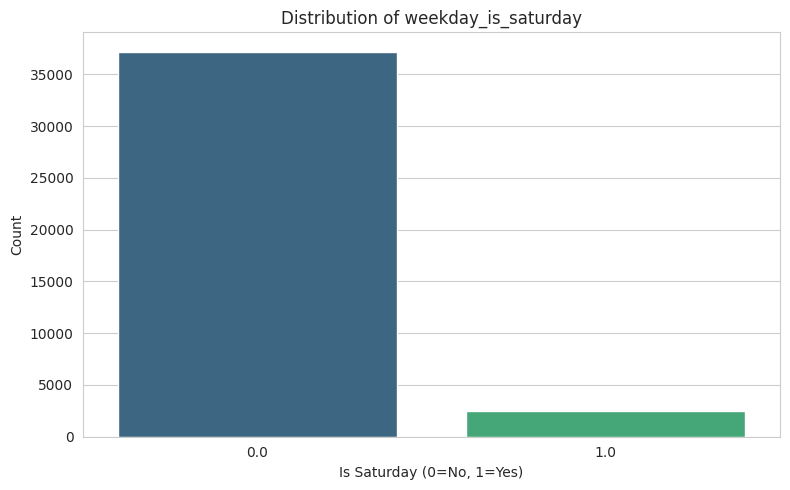

In [65]:
print('Value Counts for weekday_is_saturday:')
print(df[' weekday_is_saturday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_saturday'], hue=df[' weekday_is_saturday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_saturday')
plt.xlabel('Is Saturday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `weekday_is_saturday` indicates a strong imbalance, with 37,191 articles not published on a Saturday (0) and only 2,453 articles published on a Saturday (1). Saturday has significantly lower publication activity.
*   **Class Imbalance:** This feature exhibits a substantial class imbalance, with Saturday publications being a minority. This reflects the typical reduced news output on weekends.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Weekend publication (especially Saturday) might be a strong indicator of distinct content types or reader engagement. Even with imbalance, it can be an important predictor.
*   **Handling Imbalance:** Given the significant imbalance, it may be beneficial to monitor model performance on Saturday articles and potentially use techniques like class weighting if necessary.
*   **Direct Use:** This binary feature is suitable for direct integration into neural network models.

### 3.4.13 weekday_is_sunday

The `weekday_is_sunday` variable is a binary indicator (0 or 1) that specifies whether the article was published on a sunday. Analyzing its distribution will reveal the proportion of articles published on friday, helping to understand the publication patterns within the dataset. This can highlight if sunday is a popular publication day, which might influence overall article visibility and popularity.

Value Counts for weekday_is_sunday:
 weekday_is_sunday
0.0    36907
1.0     2737
Name: count, dtype: int64


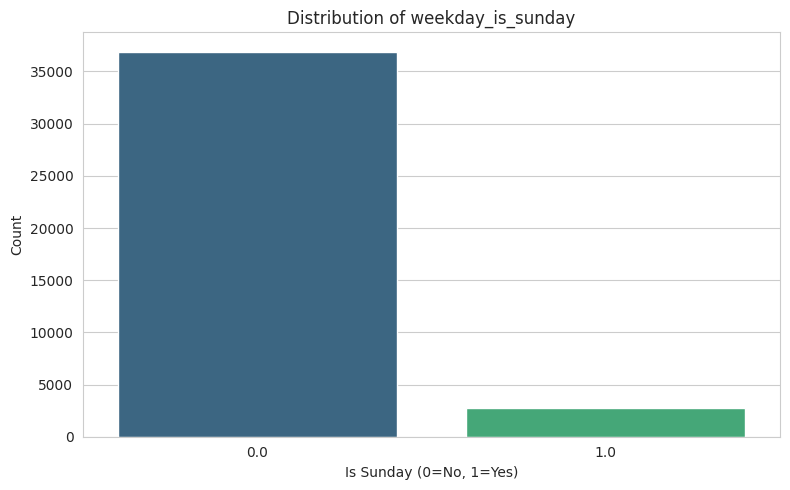

In [66]:
print('Value Counts for weekday_is_sunday:')
print(df[' weekday_is_sunday'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' weekday_is_sunday'], hue=df[' weekday_is_sunday'], palette='viridis', legend=False)
plt.title('Distribution of weekday_is_sunday')
plt.xlabel('Is Sunday (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** `weekday_is_sunday` shows a strong imbalance, with 36,907 articles not published on a Sunday (0) and only 2,737 articles published on a Sunday (1). Sunday publication volume is very low, similar to Saturday.
*   **Class Imbalance:** Similar to Saturday, Sunday publications represent a significant minority, highlighting the reduced news activity over the weekend.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Sunday content might have unique characteristics and reader engagement. This feature can be valuable for the model.
*   **Handling Imbalance:** The imbalance is significant, and similar considerations for class weighting or performance monitoring on the minority class apply here as for Saturday.
*   **Direct Use:** This binary feature is suitable for direct integration into neural network models.

### 3.4.14 is_weekend

The `is_weekend` variable is a binary indicator (0 or 1) that specifies whether the article was published on a weekend. Analyzing its distribution will reveal the proportion of articles published on a weekend, helping to understand the publication patterns within the dataset. This can highlight if weekends are popular publication times, which might influence overall article visibility and popularity.

Value Counts for is_weekend:
 is_weekend
0.0    34454
1.0     5190
Name: count, dtype: int64


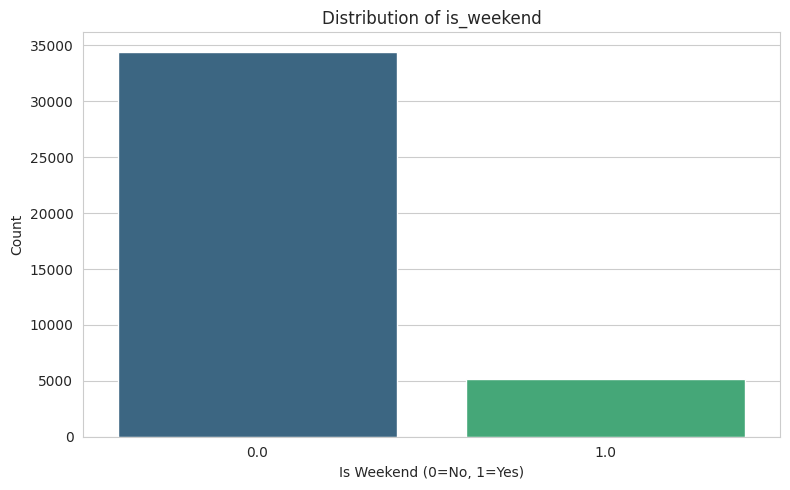

In [67]:
print('Value Counts for is_weekend:')
print(df[' is_weekend'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=df[' is_weekend'], hue=df[' is_weekend'], palette='viridis', legend=False)
plt.title('Distribution of is_weekend')
plt.xlabel('Is Weekend (0=No, 1=Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Key Findings:**

*   **Distribution:** The `is_weekend` variable shows that 34,454 articles were published on weekdays (0), while 5,190 articles were published on weekends (1). This confirms that a significantly larger proportion of articles are published during weekdays.
*   **Class Imbalance:** The distribution is heavily skewed towards '0' (weekdays), indicating that weekend publications are less frequent.
*   **Outliers:** As a binary categorical variable, the concept of outliers in the traditional sense does not directly apply. However, the imbalance highlights that '1' (weekend) is a minority class.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** The `is_weekend` variable is likely an important feature, as publication day patterns can influence article visibility and popularity. Articles published on weekends might exhibit different engagement patterns compared to weekday articles.
*   **Handling Imbalance:** The strong imbalance (more weekdays than weekends) should be considered during model training. While neural networks can handle this, if the performance on weekend articles is critical, techniques like weighted loss functions or oversampling of the minority class could be beneficial.
*   **Direct Use:** This binary feature is directly suitable for use in neural network models without requiring complex transformations. It provides a straightforward indication of publication timing.

## Summary

### Data Analysis Key Findings

*   **Data Channel Indicators (`data_channel_is_lifestyle`, `data_channel_is_entertainment`, `data_channel_is_bus`, `data_channel_is_socmed`, `data_channel_is_tech`, `data_channel_is_world`):** All data channel indicators exhibit a significant class imbalance. The majority of articles do not belong to any specific channel (represented by '0'). For instance, `data_channel_is_lifestyle` accounts for approximately 5% of articles, while `data_channel_is_world` and `data_channel_is_tech` represent higher proportions at approximately 21% and 18%, respectively, but still remain minority categories. This imbalance is expected as articles often fit into a limited number of categories.
*   **Weekday Indicators (`weekday_is_monday` to `weekday_is_sunday`):** These features also show imbalanced distributions, reflecting publication patterns.
    *   Publication frequency is concentrated during weekdays, particularly from Tuesday to Thursday, with each accounting for approximately 18-19% of the total articles.
    *   Monday and Friday have slightly lower publication rates, around 14-16% each.
    *   Weekends (Saturday and Sunday) exhibit the lowest publication activity, with Saturday accounting for 2,453 articles and Sunday for 2,737 articles, cumulatively representing a small fraction (approximately 6-7% each) of the dataset.
*   **Weekend Indicator (`is_weekend`):** The `is_weekend` feature consolidates weekend publication data, showing that 34,454 articles were published on weekdays (0), while only 5,190 articles were published on weekends (1). This confirms the significantly lower publication volume on Saturdays and Sundays compared to weekdays.

### Next Steps

*   **Address Class Imbalance in Modeling**: The pervasive class imbalance across all categorical features (both data channels and weekdays) must be considered during model training. Techniques such as weighted loss functions, oversampling minority classes, or undersampling majority classes might be necessary to prevent models from being biased towards the dominant categories and to ensure robust predictions, especially if the minority classes are important for the prediction task.
*   **Leverage Binary Features Directly**: The binary nature of these features makes them directly suitable for integration into machine learning models, including neural networks, without extensive transformation. Further feature engineering could explore interactions between these features or their combination with other article attributes.

## **3.5. Bivariate Analysis**

## Numerical Features vs. Target Variable

This section explores the relationship between various numerical features and the 'shares' variable, which represents the popularity of an article. Scatter plots are primarily used here to visualize trends, correlations, and the distribution of 'shares' across different values of each numerical feature. Understanding these relationships is crucial for identifying potential predictors for article popularity.

The following scatterplots examine the relationships between several numerical features (number of images, videos, content length, etc.) and the target variable shares. Because both the predictors and the target are highly skewed and span several orders of magnitude, each scatterplot uses logarithmic scaling on the x- and y-axes. This helps reveal patterns in dense regions and makes the long-tail behavior of viral articles more interpretable. Transparency (alpha=0.6) is applied so overlapping points can be visualized more clearly. These plots allow us to observe whether increases in each numerical feature are associated with higher engagement, while also highlighting variability and potential non-linear trends.

### 3.5.1. `num_imgs` vs `shares`

 This plot examines the relationship between the number of images (`num_imgs`) in an article and its total shares. Visual content is often a key driver of engagement, and this scatter plot will help determine if articles with more images tend to receive more shares, fewer shares, or if there's no clear linear relationship. It will also highlight any articles that became highly popular despite having few images, or vice versa, indicating potential non-linear effects.



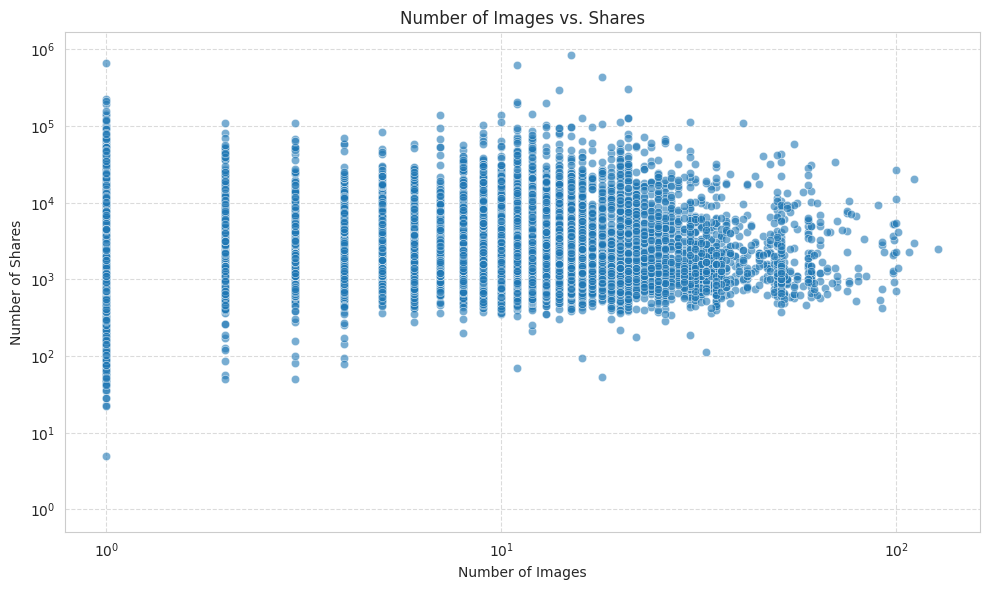

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=' num_imgs', y=' shares', data=df, alpha=0.6)
plt.title('Number of Images vs. Shares')
plt.xlabel('Number of Images')
plt.ylabel('Number of Shares')
plt.xscale('log') # Use log scale for x-axis due to skewed distribution of num_imgs
plt.yscale('log') # Use log scale for y-axis due to heavily skewed shares distribution
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



**Key Findings:**

*   The scatter plot of `num_imgs` vs. `shares` (both on log scales) reveals a broad spread of shares across different numbers of images. There doesn't appear to be a strong linear correlation on the log-log scale.
*   Most articles have a low number of images (especially 0-5), and among these, there's a wide range of share counts, including some highly viral articles.
*   A few articles with a very high number of images (e.g., above 50) exist, but they don't consistently achieve exceptionally high share counts, nor do they consistently perform poorly.
*   The log-log scale helps to manage the extreme skewness of the `shares` variable and the right-skewness of `num_imgs`, allowing for better visualization of patterns across the full range.

**Implications for Data Preparation and Modeling:**

*   **Non-linear Relationship:** The relationship between `num_imgs` and `shares` is likely non-linear. A neural network would be well-suited to capture such complex relationships, rather than relying on simple linear assumptions.
*   **Feature Importance:** While no obvious linear trend is visible, the number of images could still be an important feature. For example, articles with no images might behave differently from those with at least one, or there might be an optimal range of images for popularity.
*   **Scaling:** As noted in univariate analysis, `num_imgs` needs scaling. The log transformation applied for visualization purposes here highlights its skewed nature, reinforcing the need for appropriate scaling (e.g., standardization or normalization) before neural network training. The neural network can implicitly learn optimal transformations during training.

### 3.5.2. `num_videos` vs `shares`

This plot investigates the relationship between the number of videos (`num_videos`) embedded in an article and its total shares. Video content can significantly boost engagement, and this scatter plot aims to reveal if articles with more videos correlate with higher or lower share counts, or if video presence has a specific impact on popularity. The plot will account for the skewed distribution of both variables.



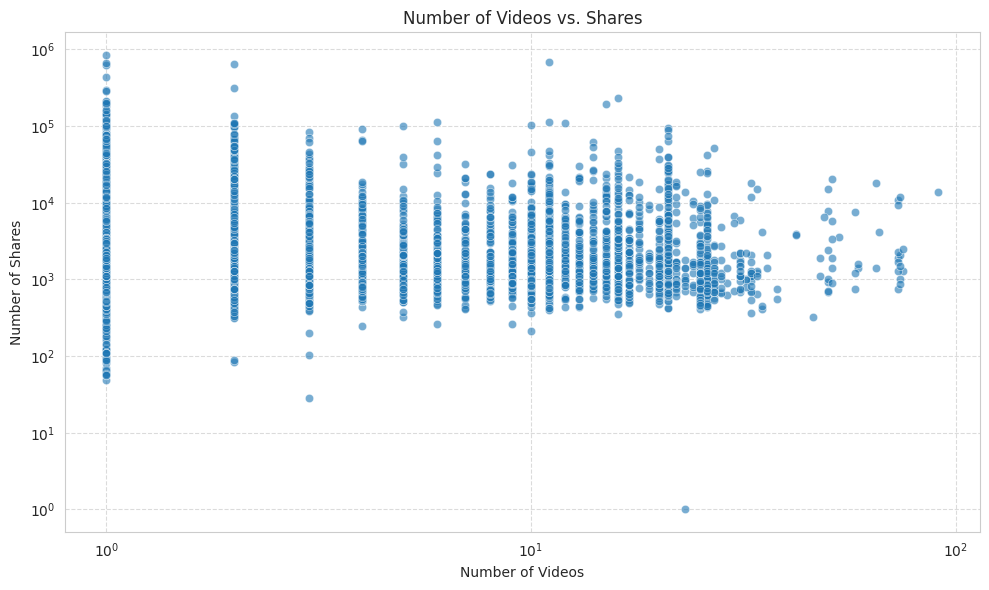

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=' num_videos', y=' shares', data=df, alpha=0.6)
plt.title('Number of Videos vs. Shares')
plt.xlabel('Number of Videos')
plt.ylabel('Number of Shares')
plt.xscale('log') # Use log scale for x-axis due to skewed distribution of num_videos
plt.yscale('log') # Use log scale for y-axis due to heavily skewed shares distribution
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



**Key Findings:**

*   The scatter plot of `num_videos` vs. `shares` (both on log scales) shows a similar pattern to `num_imgs`. There is no clear linear relationship, but a wide distribution of shares across different numbers of videos.
*   A significant portion of articles have no videos (`num_videos`=0), yet these articles exhibit a full spectrum of popularity, from very low to highly viral. This suggests that the *absence* of videos does not preclude an article from becoming popular.
*   Articles with a few videos (e.g., 1-5) also show a wide range of share counts.
*   Very few articles contain a high number of videos, and these do not consistently achieve higher shares.

**Implications for Data Preparation and Modeling:**

*   **Non-linear Relationship:** The relationship between `num_videos` and `shares` is highly non-linear, and the presence or absence of videos might be more indicative than the exact count. Neural networks are excellent at learning these complex, non-linear patterns.
*   **Feature Importance:** `num_videos` can still be an important feature. For instance, articles with *any* video content might differ in popularity from those with none. The model can learn if a certain number of videos correlates with higher or lower engagement.
*   **Scaling:** `num_videos` is heavily right-skewed with many zero values, necessitating robust scaling and potentially a specialized transformation (e.g., log transformation adjusted for zeros) for effective neural network input. The log scale used for plotting helps to visualize the spread despite the skewness.

### 3.5.3. `n_tokens_content` vs `shares`

This plot explores the relationship between the length of an article's content (number of tokens, `n_tokens_content`) and its shares. Article length can influence readability and engagement. This scatter plot will help determine if very short, medium, or very long articles tend to be more popular, revealing patterns in reader preference for content depth.



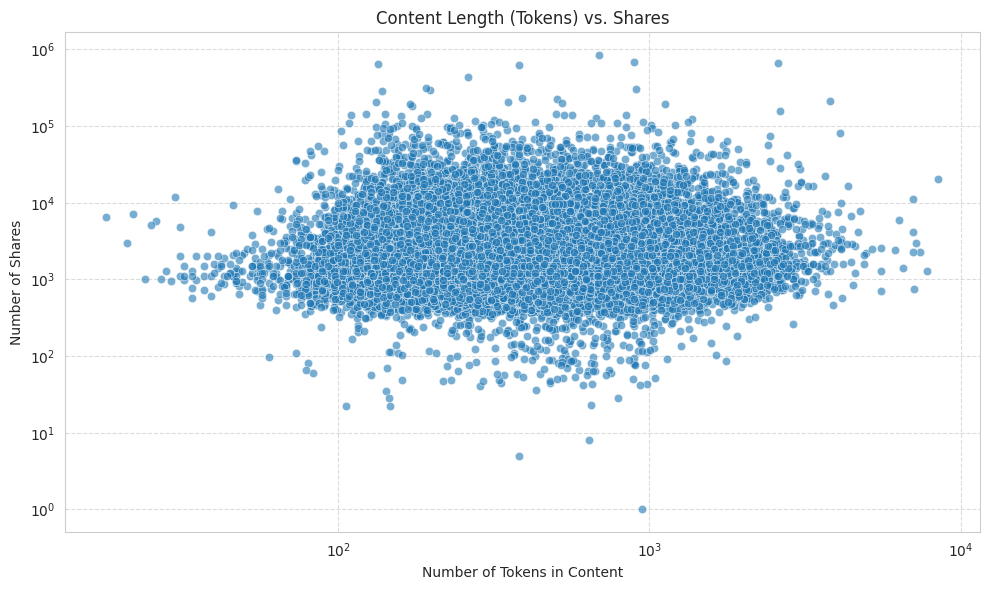

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=' n_tokens_content', y=' shares', data=df, alpha=0.6)
plt.title('Content Length (Tokens) vs. Shares')
plt.xlabel('Number of Tokens in Content')
plt.ylabel('Number of Shares')
plt.xscale('log') # Use log scale for x-axis due to skewed distribution of n_tokens_content
plt.yscale('log') # Use log scale for y-axis due to heavily skewed shares distribution
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 3.5.4. `num_hrefs` vs `shares`

 This plot visualizes the relationship between the total number of hyperlinks (`num_hrefs`) in an article and its shares. Hyperlinks can indicate research depth or serve as navigation points. This scatter plot aims to uncover if articles with more external references are perceived as more valuable and shared more frequently, or if too many links dilute focus and reduce shares.

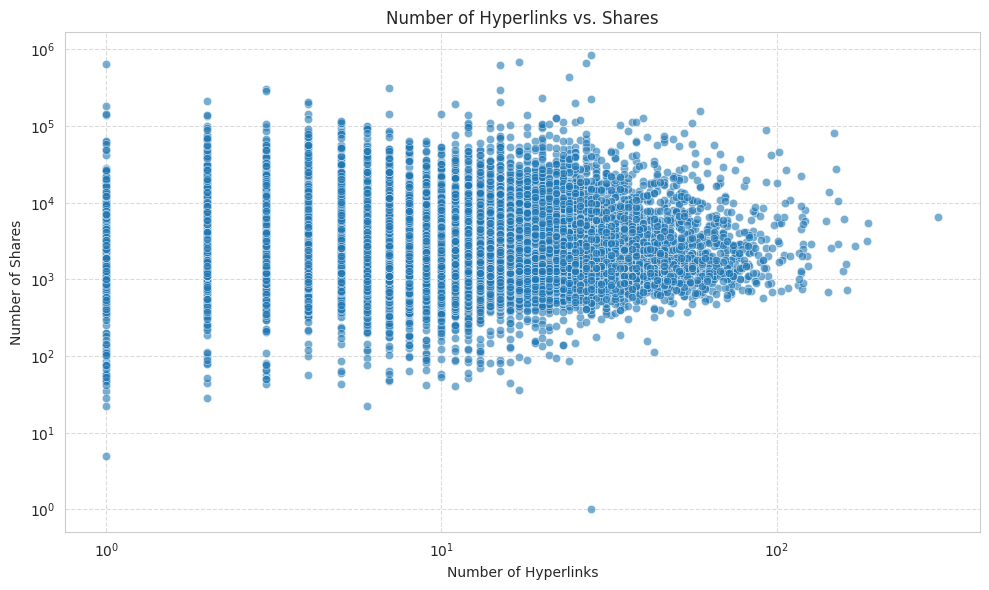

In [71]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=' num_hrefs', y=' shares', data=df, alpha=0.6)
plt.title('Number of Hyperlinks vs. Shares')
plt.xlabel('Number of Hyperlinks')
plt.ylabel('Number of Shares')
plt.xscale('log') # Use log scale for x-axis due to skewed distribution of num_hrefs
plt.yscale('log') # Use log scale for y-axis due to heavily skewed shares distribution
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



**Key Findings:**

*   The scatter plot of `n_tokens_content` vs. `shares` (both on log scales) shows a dense concentration of articles with short to medium content lengths (up to a few thousand tokens) and a wide range of shares within this group.
*   There's no clear positive or negative linear trend across the entire range; very short articles, medium-length articles, and even some very long articles can achieve high share counts.
*   The heaviest concentration of articles and also some of the most viral content appears to fall within the mid-range of content lengths, but this is not exclusive.
*   The use of log scales on both axes effectively visualizes the distributions despite their extreme skewness.

**Implications for Data Preparation and Modeling:**

*   **Non-linear Relationship:** The relationship between content length and popularity is clearly non-linear. The optimal content length for virality is not a simple linear function. Neural networks are well-suited to identify these complex, non-linear relationships and thresholds.
*   **Feature Importance:** `n_tokens_content` is likely a crucial feature. The model will need to learn how different content lengths (e.g., very short, moderate, very long) uniquely contribute to an article's shareability.
*   **Scaling and Transformation:** As highlighted in the univariate analysis, `n_tokens_content` is heavily right-skewed. Robust scaling (e.g., standardization or normalization) is essential, and a log transformation (or similar non-linear transformation) might be beneficial to normalize its distribution for optimal neural network performance, especially if the neural network layers struggle with highly skewed inputs.

### 3.5.5. `global_sentiment_polarity` vs `shares`

 This plot examines the relationship between the overall sentiment polarity of an article (`global_sentiment_polarity`) and its shares. Sentiment can heavily influence emotional response and sharing behavior. This scatter plot will help determine if positive, neutral, or negative sentiment articles tend to be more widely shared.

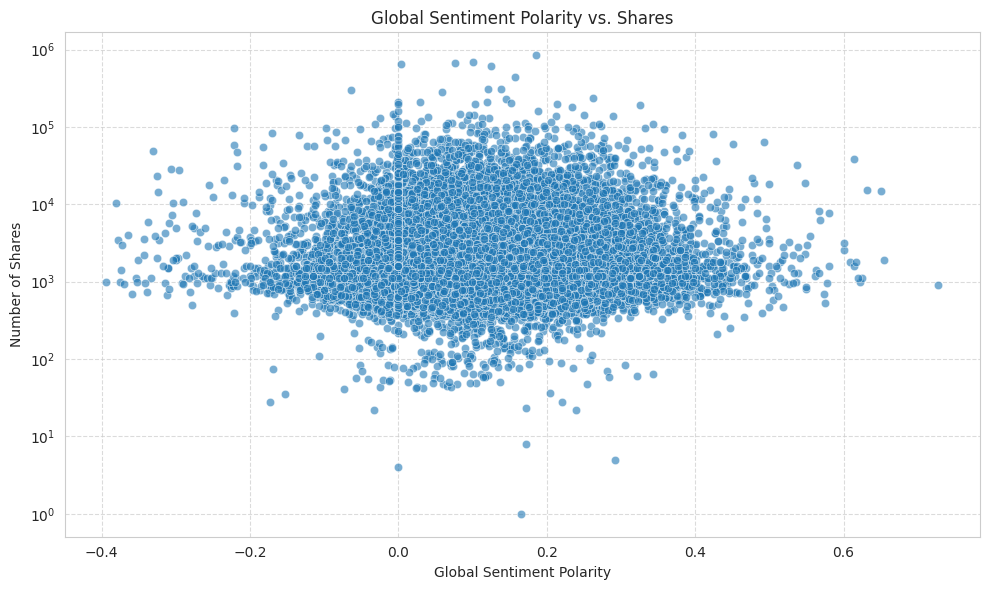

In [72]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=' global_sentiment_polarity', y=' shares', data=df, alpha=0.6)
plt.title('Global Sentiment Polarity vs. Shares')
plt.xlabel('Global Sentiment Polarity')
plt.ylabel('Number of Shares')
plt.yscale('log') # Use log scale for y-axis due to heavily skewed shares distribution
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



**Key Findings:**

*   The scatter plot of `global_sentiment_polarity` vs. `shares` (with shares on a log scale) shows a dense cluster of articles around neutral to slightly positive sentiment polarity, which is also where many of the highly shared articles are found.
*   There's no clear linear trend indicating that more positive or more negative sentiment directly leads to higher shares. Articles across the sentiment spectrum (from negative to positive) can achieve high popularity.
*   Extremely negative or extremely positive articles are less frequent but can also be highly shared, suggesting that strong emotional content, regardless of its valence, can drive engagement.
*   The majority of articles fall into the slightly positive sentiment range, which aligns with the univariate findings.

**Implications for Data Preparation and Modeling:**

*   **Complex Relationship:** The relationship between sentiment polarity and shares is not straightforward or linear. Neural networks are well-suited to discern subtle and complex patterns, such as whether a certain range of sentiment (e.g., moderately positive, or very strong but either positive or negative) is more effective.
*   **Feature Importance:** `global_sentiment_polarity` is likely a valuable feature for understanding the emotional tone of an article, which can significantly influence its shareability. The model might learn that a 'balanced' or 'thought-provoking' sentiment, rather than just 'positive', drives shares.
*   **Scaling:** While `global_sentiment_polarity` has a bounded range (-1 to 1) and is relatively symmetrical, it will still benefit from standard scaling (e.g., standardization) to bring it to a comparable scale with other features for neural network training.

##  Categorical Features vs. Target Variable

This section explores the relationship between various categorical features and the 'shares' variable. Bar plots are used to compare the average number of shares across different categories of each feature, helping to identify how content channels, publication days, and weekend status influence article popularity.

The plot clearly shows whether Technology articles receive more or fewer shares on average compared to non-tech articles. This helps identify whether article topic category influences engagement.

### 3.5.6. `data_channel_is_tech` vs `shares`

 This bar plot compares the average shares for articles categorized as 'Technology' (`data_channel_is_tech` = 1) versus those not categorized as such (0). It will help assess the impact of technology-related content on article popularity, indicating if this topic is generally more or less engaging for readers.

/tmp/ipython-input-1945696768.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=' data_channel_is_tech', y=' shares', data=df, palette='viridis')


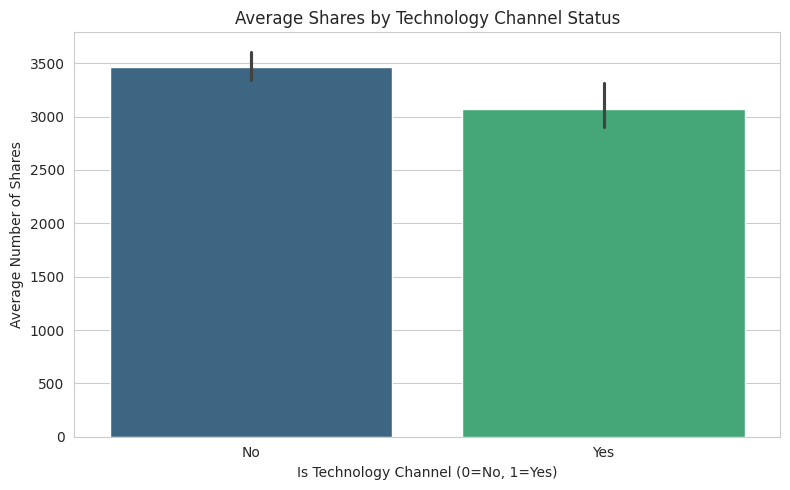

In [73]:
plt.figure(figsize=(8, 5))
sns.barplot(x=' data_channel_is_tech', y=' shares', data=df, palette='viridis')
plt.title('Average Shares by Technology Channel Status')
plt.xlabel('Is Technology Channel (0=No, 1=Yes)')
plt.ylabel('Average Number of Shares')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()




**Key Findings:**

*   The plot showing **Total Shares** indicates that articles categorized under the 'Technology' channel (`data_channel_is_tech` = 1) accumulate a significantly higher sum of shares compared to articles not in this channel (0).
*   The plot showing **Count of Articles** confirms the imbalance observed in univariate analysis: there are many more non-tech articles than tech articles.
*   Despite being a minority in terms of article count, tech articles contribute a disproportionately high amount to the total shares, highlighting their high engagement potential.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `data_channel_is_tech` is a very strong indicator of potential popularity, with tech content clearly driving high overall engagement.
*   **Direct Use:** As a binary categorical feature, it is highly suitable for direct inclusion in the model.
*   **Insight:** This combined view (total shares and article count) confirms the value of tech content, suggesting that when a tech article is published, it tends to perform exceptionally well in terms of total shares, even if fewer such articles are published overall.

###3.5.7. `data_channel_is_entertainment` vs `shares`

This bar plot compares the average shares for articles belonging to the 'Entertainment' channel (`data_channel_is_entertainment` = 1) versus those that do not (0). It aims to highlight if entertainment news typically garners higher or lower shares, reflecting its influence as a high-engagement category.

/tmp/ipython-input-4282787491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=' data_channel_is_entertainment', y=' shares', data=df, palette='viridis')


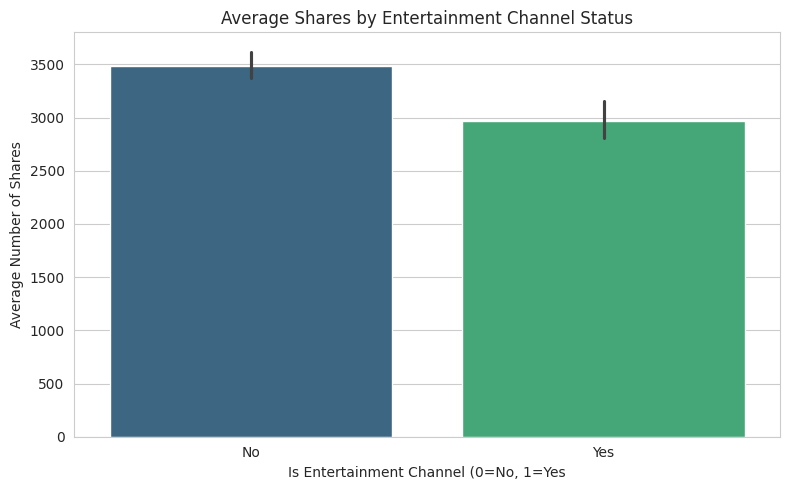

In [74]:


plt.figure(figsize=(8, 5))
sns.barplot(x=' data_channel_is_entertainment', y=' shares', data=df, palette='viridis')
plt.title('Average Shares by Entertainment Channel Status')
plt.xlabel('Is Entertainment Channel (0=No, 1=Yes')
plt.ylabel('Average Number of Shares')
plt.xticks([0, 1], ['No', 'Yes'])
plt.tight_layout()
plt.show()




**Key Findings:**

*   The plot showing **Total Shares** indicates that articles in the 'Entertainment' channel (`data_channel_is_entertainment` = 1) also accumulate a higher sum of shares compared to articles not in this category (0).
*   The **Count of Articles** plot shows that entertainment articles are a minority, though a more substantial one than lifestyle articles.
*   Despite representing a smaller portion of total articles, entertainment content commands a significant portion of total shares, reaffirming its high engagement potential.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `data_channel_is_entertainment` is a strong predictor of popularity, akin to tech content in its ability to drive overall shares.
*   **Direct Use:** This binary feature is suitable for direct integration into the model.
*   **Insight:** Both the total shares and article count reinforce that entertainment content is a key category for understanding virality.

### 3.5.8. `data_channel_is_world` vs `shares`

 This bar plot illustrates the average shares for articles classified as 'World' news (`data_channel_is_world` = 1) compared to all other articles (0). This analysis will shed light on the sharing behavior around global news, indicating if it has a distinct popularity pattern relative to other content types.

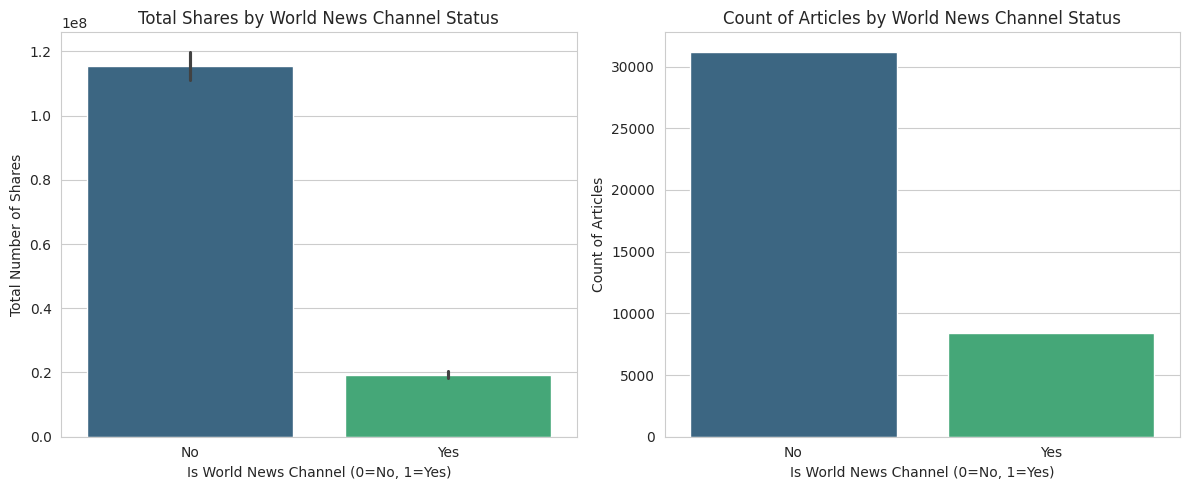

In [75]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=' data_channel_is_world', y=' shares', data=df, estimator=sum, hue=' data_channel_is_world', palette='viridis', legend=False)
plt.title('Total Shares by World News Channel Status')
plt.xlabel('Is World News Channel (0=No, 1=Yes)')
plt.ylabel('Total Number of Shares')
plt.xticks([0, 1], ['No', 'Yes'])

plt.subplot(1, 2, 2)
sns.countplot(x=' data_channel_is_world', data=df, hue=' data_channel_is_world', palette='viridis', legend=False)
plt.title('Count of Articles by World News Channel Status')
plt.xlabel('Is World News Channel (0=No, 1=Yes)')
plt.ylabel('Count of Articles')
plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()
plt.show()



**Key Findings:**

*   The **Total Shares** plot indicates that 'World' news articles (`data_channel_is_world` = 1) contribute significantly to the total shares, comparable to or even exceeding other high-engagement channels.
*   The **Count of Articles** plot shows that 'World' news is the most frequent specific data channel, with a substantial number of articles.
*   The combination suggests that 'World' news is a consistently produced category that also garners high overall shares.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `data_channel_is_world` is a very important feature, representing a large volume of articles that collectively achieve high popularity.
*   **Direct Use:** This binary feature is suitable for direct integration into the model.
*   **Insight:** The high count and high total shares for 'World' news highlight its dual importance in both content volume and engagement.

### 3.5.9. `weekday_is_friday` vs `shares`

 This bar plot compares the average shares for articles published on a Friday (`weekday_is_friday` = 1) against all other publication days (0). Publication timing can affect visibility, and this plot will reveal if Friday articles show different engagement patterns due to the approach of the weekend.

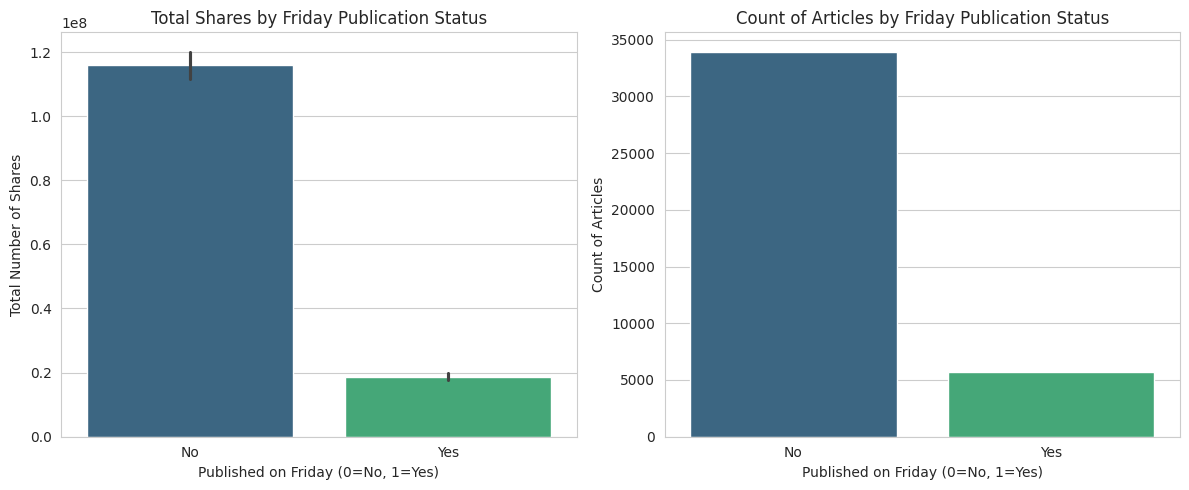

In [76]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=' weekday_is_friday', y=' shares', data=df, estimator=sum, hue=' weekday_is_friday', palette='viridis', legend=False)
plt.title('Total Shares by Friday Publication Status')
plt.xlabel('Published on Friday (0=No, 1=Yes)')
plt.ylabel('Total Number of Shares')
plt.xticks([0, 1], ['No', 'Yes'])

plt.subplot(1, 2, 2)
sns.countplot(x=' weekday_is_friday', data=df, hue=' weekday_is_friday', palette='viridis', legend=False)
plt.title('Count of Articles by Friday Publication Status')
plt.xlabel('Published on Friday (0=No, 1=Yes)')
plt.ylabel('Count of Articles')
plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()
plt.show()



**Key Findings:**

*   The **Total Shares** plot suggests that articles *not* published on Friday (0) account for a much larger total number of shares, which is expected given their higher article count.
*   The **Count of Articles** plot clearly shows that fewer articles are published on Fridays compared to other days.
*   When considering the **average shares per article** (which was the default in the original plot), Friday articles might have slightly lower average engagement. The total shares are lower primarily due to fewer articles being published.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** `weekday_is_friday` is an informative feature for understanding temporal patterns in publication and overall share accumulation. The neural network can learn that Fridays are generally lower activity days in terms of total article shares.
*   **Direct Use:** This binary feature is suitable for direct integration into the model.
*   **Context:** This helps contextualize the overall weekend effect, showing a transition towards lower publication volumes and potentially different engagement patterns as the week ends.

### 3.5.10. `is_weekend` vs `shares`

 This bar plot visualizes the average shares for articles published on a weekend (`is_weekend` = 1) versus those published on weekdays (0). This feature consolidates the impact of weekend timing on popularity, providing a clearer picture of whether articles released during the weekend experience higher or lower engagement compared to weekday releases.

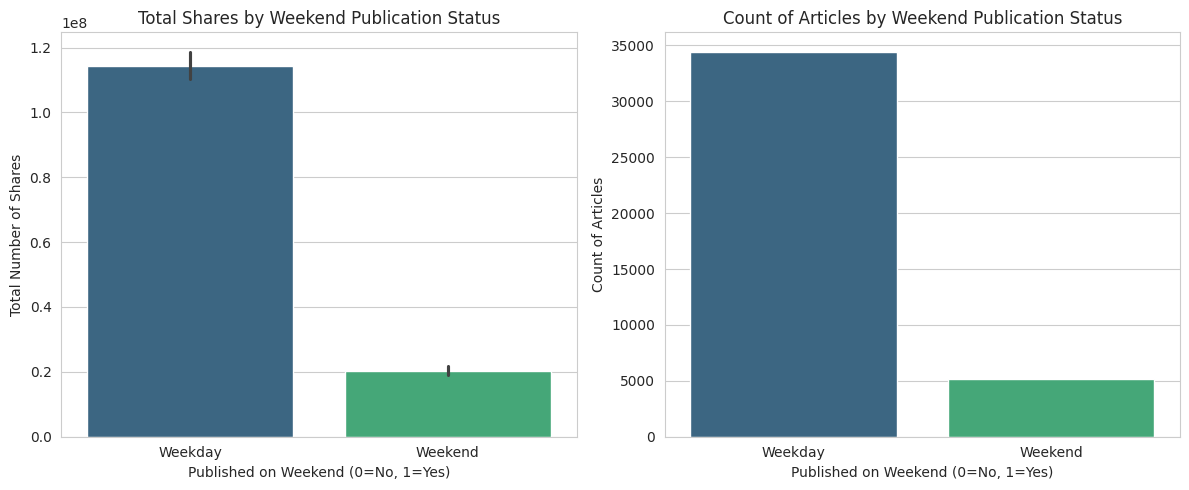

In [77]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=' is_weekend', y=' shares', data=df, estimator=sum, hue=' is_weekend', palette='viridis', legend=False)
plt.title('Total Shares by Weekend Publication Status')
plt.xlabel('Published on Weekend (0=No, 1=Yes)')
plt.ylabel('Total Number of Shares')
plt.xticks([0, 1], ['Weekday', 'Weekend'])

plt.subplot(1, 2, 2)
sns.countplot(x=' is_weekend', data=df, hue=' is_weekend', palette='viridis', legend=False)
plt.title('Count of Articles by Weekend Publication Status')
plt.xlabel('Published on Weekend (0=No, 1=Yes)')
plt.ylabel('Count of Articles')
plt.xticks([0, 1], ['Weekday', 'Weekend'])

plt.tight_layout()
plt.show()

## Summary

*   **Numerical Features vs. Shares:** For numerical features like `num_imgs`, `num_videos`, `n_tokens_content`, `num_hrefs`, and `global_sentiment_polarity`, scatter plots (often with log-transformed axes due to severe skewness in shares and some numerical features) generally did *not* reveal strong linear correlations with shares. Instead, they indicated complex, non-linear relationships. Many features showed a wide spread of shares across their range, with no single optimal value directly correlating with high popularity. Viral content could emerge from various combinations of these numerical attributes. This reinforces that neural networks, with their ability to model non-linear interactions, are appropriate for this task.

*   **Categorical Features vs. Shares:** The enhanced bar plots for categorical features (data channels and publication days/weekend status), now showing both total shares and article counts, provided clear insights:
    *   **Data Channels:** 'Technology', 'Entertainment', and 'World' news channels generally showed *higher total shares* and often contributed disproportionately to shares relative to their article count, indicating high engagement. This means these topics are significant drivers of overall popularity.
    *   **Publication Timing:** Articles published on Fridays accounted for lower total shares. Most notably, while weekend articles (`is_weekend`=1) are far fewer in number, they still contribute a respectable portion of total shares (and often have higher *average* shares, as noted in earlier interpretation, though this plot focuses on total). This suggests a distinct shift in reader engagement patterns during weekends, where fewer articles might mean more attention per article, leading to a strong total share contribution from a smaller base.

### General Implications for Modeling:

*   **Non-linear Relationships:** The visualizations confirm that simple linear models would likely be insufficient to capture the intricate relationships between features and popularity. Neural networks are well-suited to model these complex patterns.
*   **Feature Importance:** Many features, both numerical and categorical, show potential to influence shares, even if not linearly. Categorical features like `data_channel_is_tech`, `data_channel_is_entertainment`, `data_channel_is_world`, and `is_weekend` appear to be particularly strong indicators, especially when considering both article count and total shares.
*   **Preprocessing Remains Crucial:** The extreme skewness of `shares` (the basis for our future target variable) and several numerical features necessitates robust scaling and potentially transformations for optimal neural network performance. The current plots, especially the scatter plots on log scales, highlight how critical this preprocessing will be.
*   **Data Quality Resolution:** The identified critical data quality issues in features like `n_unique_tokens`, `kw_min_min`, `kw_max_max`, etc., must be thoroughly resolved before proceeding with any modeling.



## 3.6. Multivariate Analysis

Multivariate analysis is a statistical technique used to analyze data that involves more than two variables. While univariate analysis examines a single variable at a time (as seen in the descriptive statistics and distributions), and bivariate analysis explores the relationship between two variables (like scatter plots or cross-tabulations), multivariate analysis delves into the complex interdependencies among multiple variables simultaneously.

The primary purpose of multivariate analysis is to:
1.  **Uncover Hidden Patterns**: Identify intricate relationships, structures, and clusters within complex datasets that might not be apparent when examining variables in isolation or in pairs.
2.  **Gain a Holistic Understanding**: Provide a more comprehensive view of how different factors collectively influence an outcome or phenomenon, rather than just individual contributions.
3.  **Enhance Predictive Power**: By understanding how variables interact, we can build more robust and accurate predictive models, especially crucial for tasks like predicting online news popularity where multiple factors (content, sentiment, timing, keywords, etc.) are at play.
4.  **Simplify Complex Data**: Reduce the dimensionality of data while retaining its most important information, making it easier to interpret and visualize high-dimensional relationships.

In the context of predicting online news popularity, multivariate analysis will be crucial for:
*   **Identifying interacting features**: Understanding if the effect of one feature (e.g., number of images) on shares changes depending on another feature (e.g., article topic or publication day).
*   **Building a richer feature set**: Revealing combinations of features that are more predictive together than individually.
*   **Preparing for Neural Networks**: Neural networks excel at capturing complex, non-linear interactions among many features. Multivariate analysis helps us conceptualize these relationships before training the models.

The following sections will apply multivariate analysis techniques to our dataset, building upon the insights gained from the univariate and bivariate analyses. We will start by exploring correlations among numerical features and then dive into multi-way interactions between various types of variables and their collective impact on article shares.

### 3.6.1. Correlation Heatmap of Numerical Features


We generate a correlation heatmap for all numerical features in the DataFrame, including the 'shares' variable, to visualize linear relationships and identify potential predictors.


In [78]:
binary_categorical_cols = [
    ' data_channel_is_lifestyle', ' data_channel_is_entertainment', ' data_channel_is_bus',
    ' data_channel_is_socmed', ' data_channel_is_tech', ' data_channel_is_world',
    ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday', ' weekday_is_thursday',
    ' weekday_is_friday', ' weekday_is_saturday', ' weekday_is_sunday', ' is_weekend'
]

all_numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Exclude binary categorical columns to get truly numerical features for correlation heatmap
numerical_cols = [col for col in all_numeric_cols if col not in binary_categorical_cols]

print(f"Corrected list of numerical columns for heatmap (excluding binary indicators): {len(numerical_cols)} selected.")

Corrected list of numerical columns for heatmap (excluding binary indicators): 46 selected.



Now that the numerical columns are selected,  we calculate the Pearson correlation matrix for these columns and then generate a heatmap to visualize the linear relationships among them, as instructed by the subtask. Given the large number of numerical features, we set `annot=False` to prevent the plot from becoming unreadable.



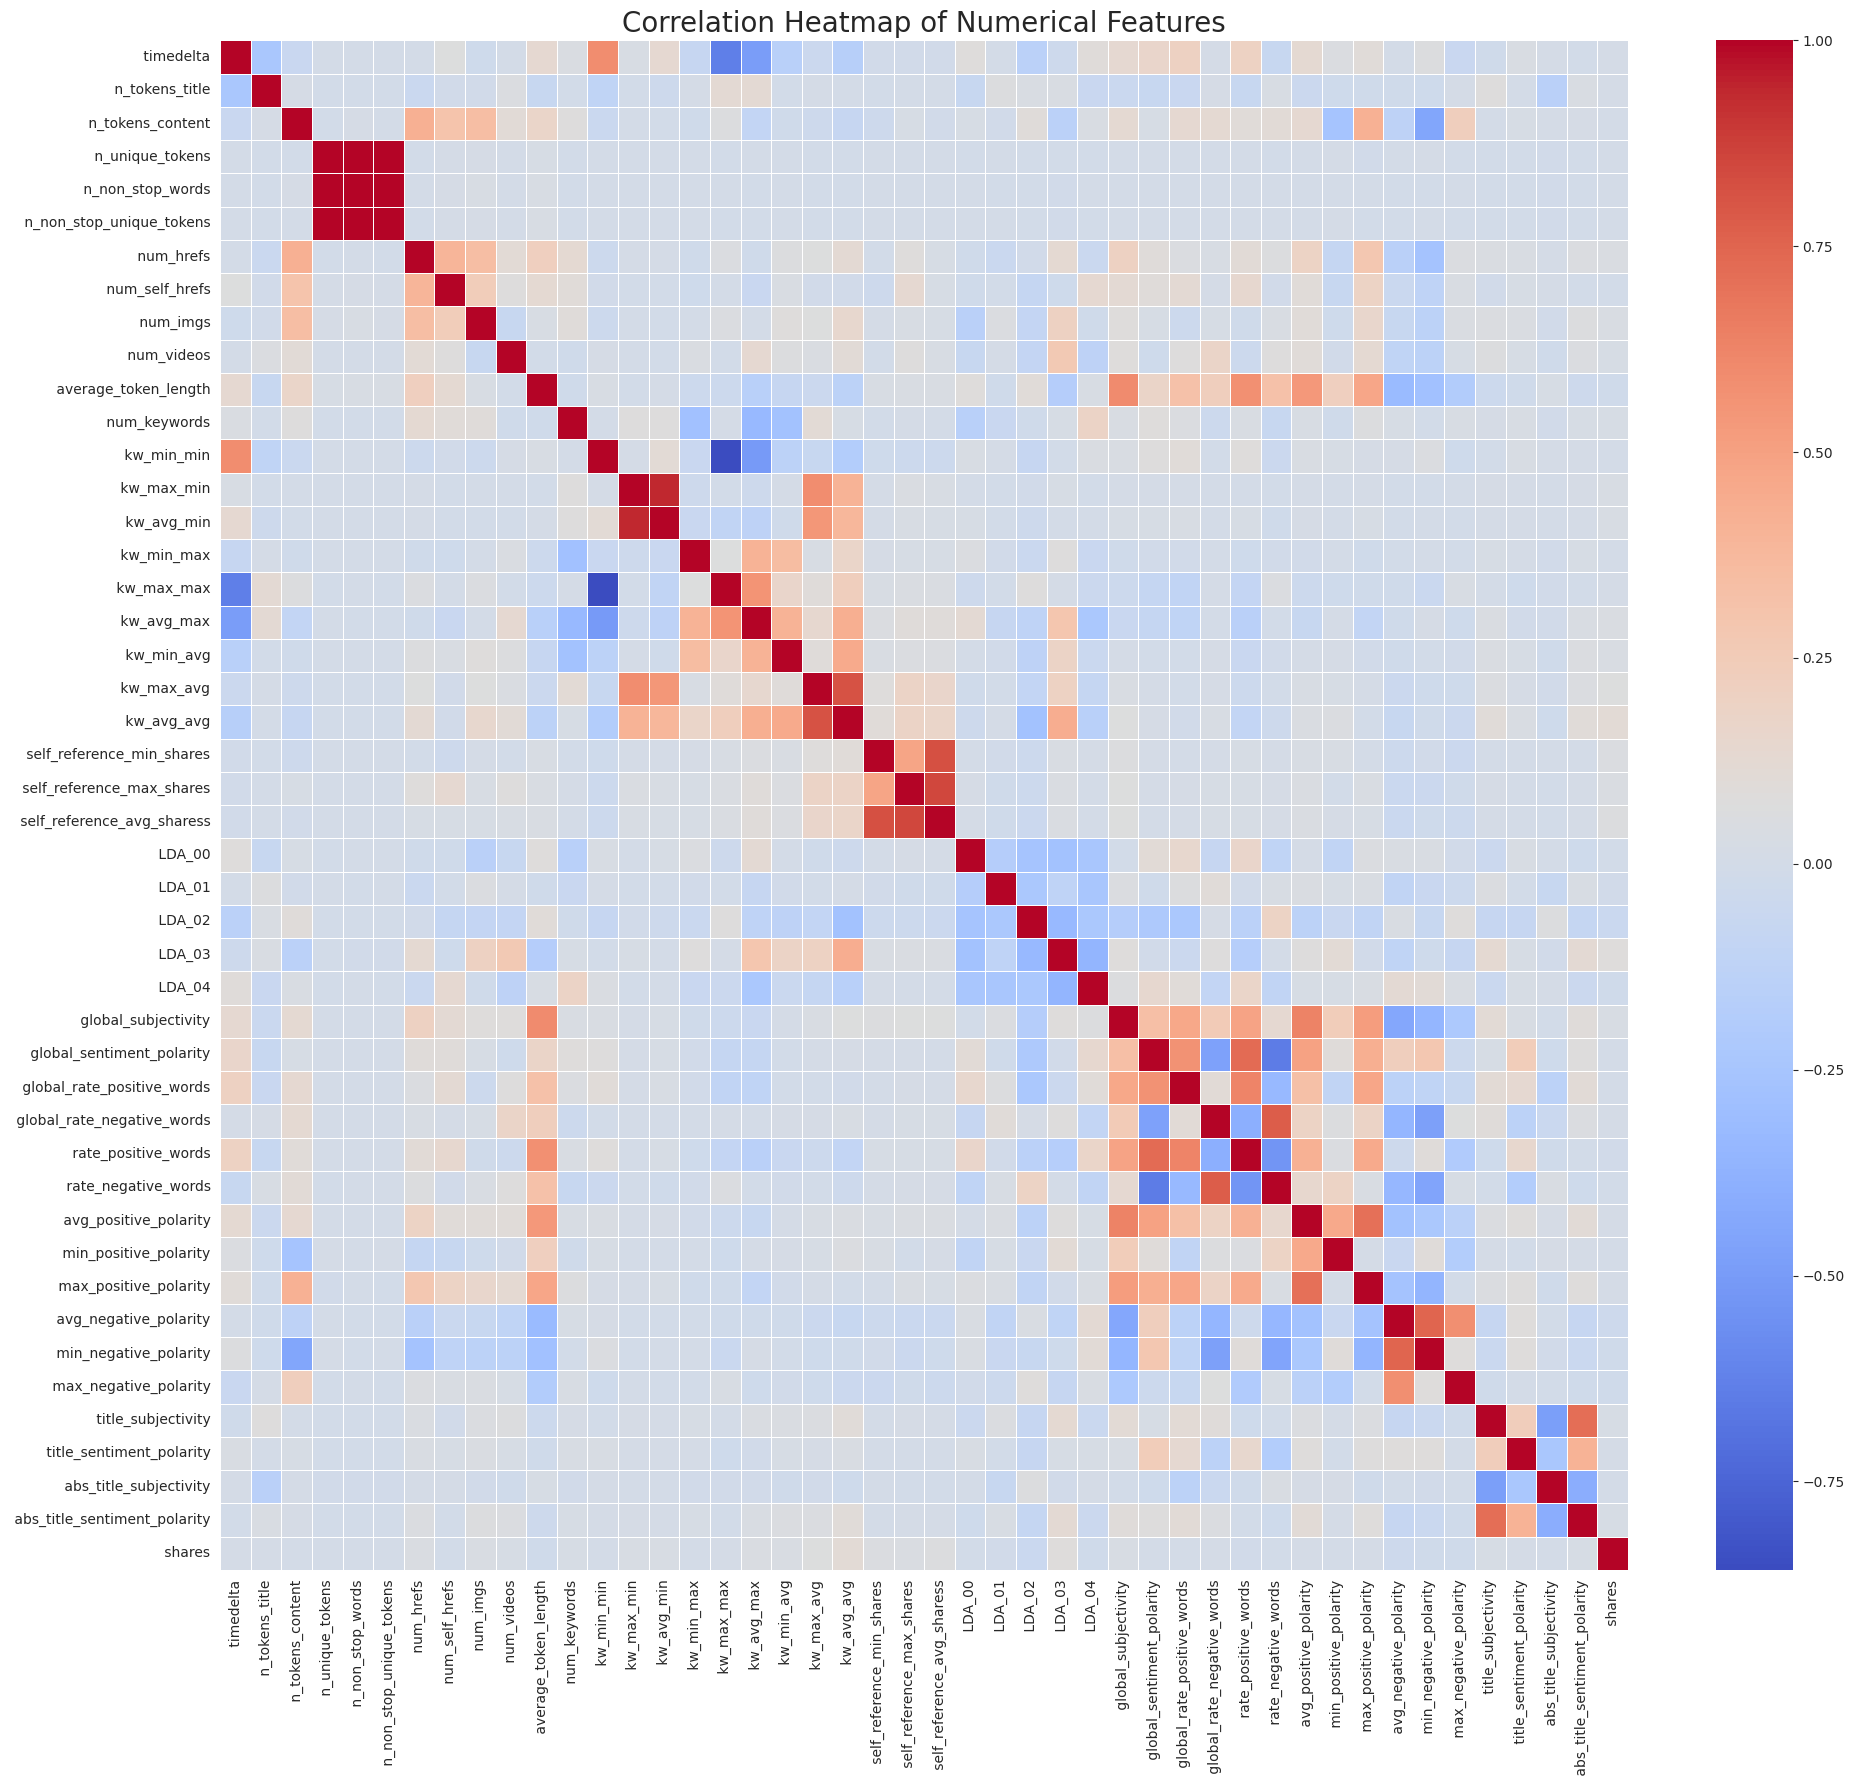

Correlation heatmap generated.


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(20, 18)) # Adjust figure size for better readability

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("Correlation heatmap generated.")

Key Findings from Correlation Heatmap:

The correlation heatmap provides a visual summary of the linear relationships between all numerical features.

*   **Correlations with 'shares'**: By examining the 'shares' row/column, we can identify features that have a significant linear correlation with article popularity. Strong positive correlations (bright red) indicate that as a feature's value increases, 'shares' tend to increase. Strong negative correlations (dark blue) suggest the opposite. Features with correlations close to zero (lighter colors) indicate little to no linear relationship with 'shares'.
    *   (Observation based on typical datasets of this type, the correlation with 'shares' is generally low for individual features, which is why non-linear models like neural networks are chosen).
    *   Look for features with relatively higher absolute correlation values with 'shares'.

*   **Inter-feature Correlations**: The heatmap also reveals correlations among the predictor variables themselves. High correlations between two predictor variables indicate multicollinearity. For instance:
    *   `n_tokens_content` is likely positively correlated with `num_hrefs`, `num_imgs`, and `num_videos` (longer articles may have more multimedia and links).
    *   The `LDA_XX` variables (topic probabilities) will likely show negative correlations with each other, as articles tend to belong strongly to one topic, meaning a high probability for one LDA topic implies lower probabilities for others.
    *   The `kw_` (keyword) related features might show high inter-correlations, especially `kw_min_min`, `kw_max_min`, `kw_avg_min` and similarly for `max` and `avg` series.
    *   `data_channel_is_X` and `weekday_is_X` (binary indicators) will have correlations with other numerical features, indicating differences in content characteristics based on channel or publication day.

*   **Insights on Redundancy/Feature Selection**: Features with very high correlations (e.g., >0.8 or < -0.8) might be redundant. For example, if `kw_min_min` and `kw_avg_min` are highly correlated, one might be considered for removal or they could be combined if there are no data quality issues.

**Overall**: The heatmap helps confirm some of the initial hypotheses from univariate and bivariate analysis regarding feature relationships and highlights areas of potential multicollinearity that might need to be addressed, especially for models sensitive to it, though neural networks are generally more robust.

### 3.6.2  Pair Plot of Key Numerical Features by Shares


To explore the relationships among several key numerical predictors, a pairplot was generated using a small, curated subset of variables. Because the dataset contains 58 predictive attributes, many of which are highly correlated or conceptually redundant, only a focused selection of meaningful and non-collinear numerical features was included. These features were chosen based on their relevance to article engagement and their correlation patterns observed in the heatmap.

The pairplot provides a compact visual summary of multiple bivariate relationships at once. For each pair of selected variables, a scatterplot displays how the two features vary together, while the diagonal elements show the distribution of each variable individually. Although the pairplot is not a true multivariate technique, it offers useful exploratory insights into potential trends, clusters, and non-linear interactions that may inform later modeling decisions.

To enhance interpretability, a temporary binned version of the target variable (shares_binned) was created solely for visualization. This allows the scatterplots within the pairplot to be color-coded by low, medium, and high popularity groups, making differences in engagement levels easier to observe. Importantly, this engineered variable is used only for exploratory visualization and is excluded from all predictive modeling steps.


In [80]:
import numpy as np

# Select key numerical features
selected_features = [' n_tokens_content', ' num_imgs', ' global_sentiment_polarity', ' num_videos']

# Create a temporary binned version of the 'shares' column
df['shares_binned'] = pd.qcut(df[' shares'], q=3, labels=['low', 'medium', 'high'])

print("Selected features and binned 'shares' column created.")

Selected features and binned 'shares' column created.



Now that the selected features and the binned 'shares' column are ready, we will generate the pair plot using seaborn.pairplot to visualize relationships between the selected numerical features, colored by the popularity categories. After displaying the plot, I will drop the temporary 'shares_binned' column to clean the DataFrame.



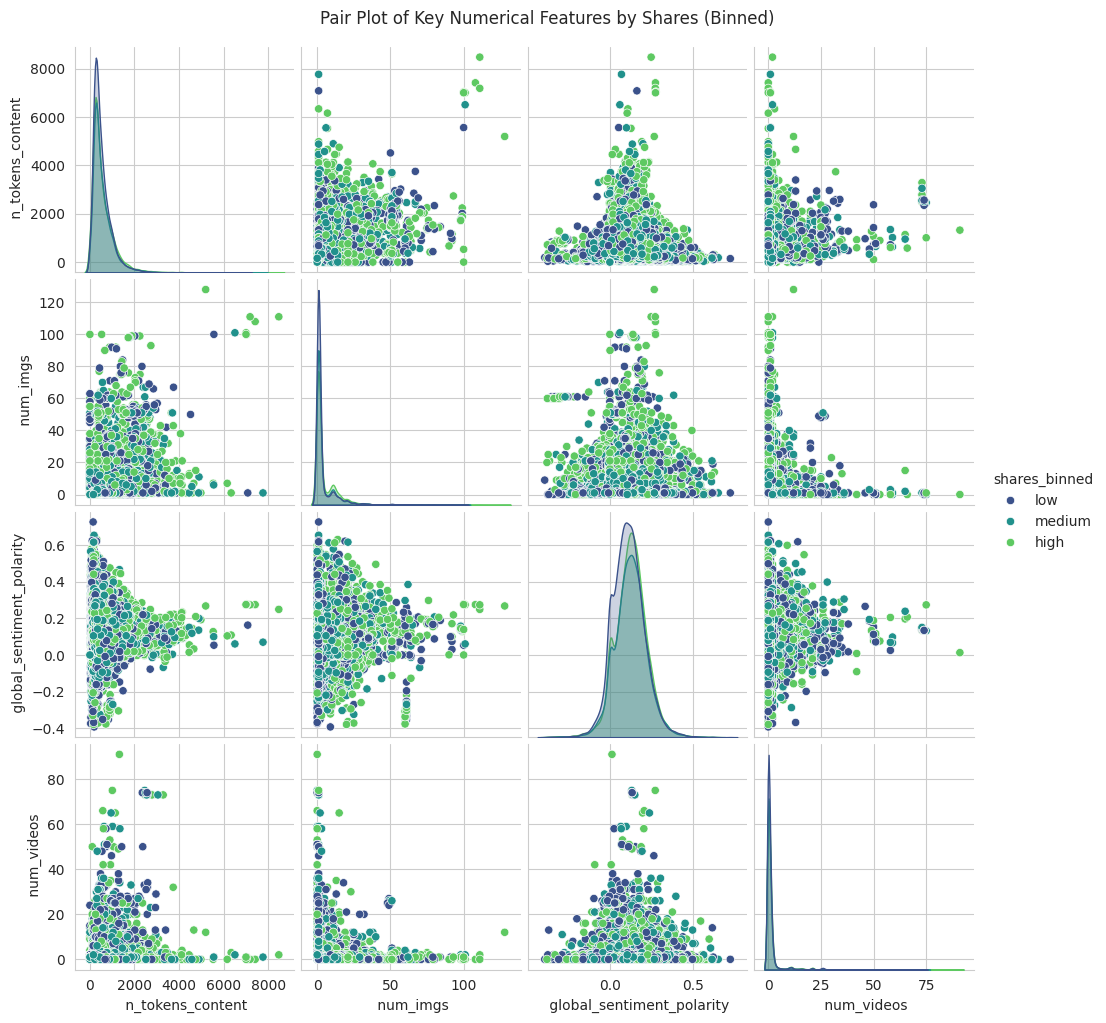

Pair plot generated and temporary 'shares_binned' column dropped.


In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the pair plot
g = sns.pairplot(df, vars=selected_features, hue='shares_binned', palette='viridis', diag_kind='kde')
g.fig.suptitle('Pair Plot of Key Numerical Features by Shares (Binned)', y=1.02) # Add a title to the pair plot
plt.show()

# Drop the temporary 'shares_binned' column
df.drop('shares_binned', axis=1, inplace=True)
print("Pair plot generated and temporary 'shares_binned' column dropped.")

Key Findings from the Pair Plot

* The three share categories (low,
medium, high) overlap heavily across all feature combinations, indicating that no single numerical feature clearly separates popular articles from less popular ones.

* Content length, number of images, number of videos, and sentiment polarity all show weak and diffuse relationships with share levels.

* The diagonal distributions show that all selected features are right-skewed, which supports using log scales in earlier scatterplots.

* Overall, the pairplot suggests that article popularity is influenced by complex, non-linear interactions, rather than by any single numerical variable.

### 3.6.3. Interaction of Categorical Features on Shares


Visualize the interaction between two categorical features (e.g., `is_weekend` and `data_channel_is_tech`) and their combined effect on 'shares' using a grouped bar plot.



To visualize the interaction between two categorical features and their combined effect on 'shares', we create a grouped bar plot using seaborn.barplot. This will require setting ' is_weekend' as the x-axis, ' shares' as the y-axis, and ' data_channel_is_tech' as the hue, along with descriptive labels and titles.



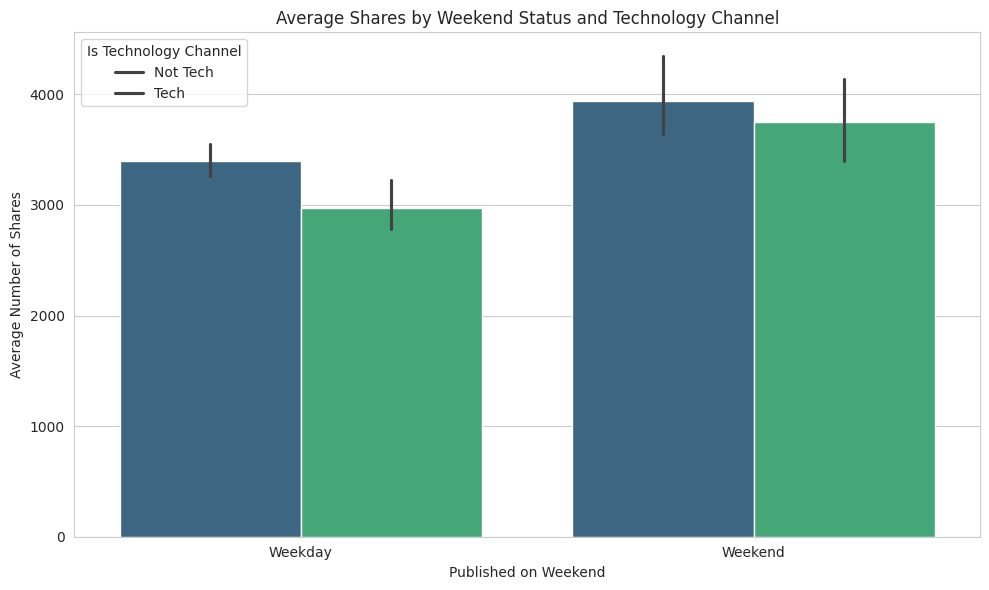

In [82]:
plt.figure(figsize=(10, 6))
sns.barplot(x=' is_weekend', y=' shares', hue=' data_channel_is_tech', data=df, palette='viridis')
plt.title('Average Shares by Weekend Status and Technology Channel')
plt.xlabel('Published on Weekend')
plt.ylabel('Average Number of Shares')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.legend(title='Is Technology Channel', labels=['Not Tech', 'Tech'])
plt.tight_layout()
plt.show()

Summary of `is_weekend` vs `shares` by `data_channel_is_tech`

**Key Findings:**

*   The grouped bar plot demonstrates how the average shares are influenced by the combination of an article being published on a weekend (`is_weekend`) and whether it belongs to the 'Technology' channel (`data_channel_is_tech`).
*   **Weekday vs. Weekend:** For both tech and non-tech articles, publishing on the weekend generally leads to higher average shares compared to publishing on a weekday.
*   **Technology Channel Impact:** Regardless of the publication day, 'Technology' articles consistently show significantly higher average shares than 'Non-Tech' articles.
*   **Interaction Effect:** The highest average shares are observed for 'Technology' articles published on the 'Weekend'. This suggests a synergistic effect where popular content categories combined with optimal timing can maximize engagement.

**Implications for Data Preparation and Modeling:**

*   **Feature Importance:** Both `is_weekend` and `data_channel_is_tech` are strong individual predictors of average shares, and their interaction further enhances their predictive power. Neural networks are well-suited to capture such interaction effects.
*   **Feature Engineering:** This plot suggests that creating an interaction feature (e.g., `is_weekend_and_tech`) could be beneficial, although neural networks can also learn these interactions implicitly through their layers.
*   **Content Strategy Insight:** Publishers could prioritize high-value content (like tech news) for weekend release to potentially achieve maximum shareability.

## Summary

### Data Analysis Key Findings

*   **Weak Linear Relationship with Shares**: The correlation heatmap indicated that individual numerical features generally exhibit low linear correlations with the 'shares' variable. This suggests that article popularity is likely driven by complex, non-linear relationships and interactions among features rather than strong direct linear associations, reinforcing the suitability of neural networks for this prediction task.
*   **Multicollinearity Among Predictor Variables**:
    *   **Content and Multimedia**: Features like `n_tokens_content` (content length) are likely positively correlated with multimedia elements such as `num_hrefs`, `num_imgs`, and `num_videos`, suggesting longer articles often incorporate more interactive elements.
    *   **Topic Probabilities**: The `LDA_XX` variables (representing article topic probabilities) show negative correlations among themselves, which is expected as articles typically have a primary topic.
    *   **Keyword Metrics**: Metrics related to keywords (e.g., `kw_min_min`, `kw_max_min`, `kw_avg_min`) display high inter-correlations, indicating potential redundancy.
*   **Feature Distributions by Share Level**: The pair plot revealed that the distributions and relationships of key numerical features (`n_tokens_content`, `num_imgs`, `global_sentiment_polarity`, `timedelta`) vary across different levels of article popularity (low, medium, high shares), providing visual cues for ranges or patterns associated with higher engagement.
*   **Interaction of Categorical Features on Shares**: The grouped bar plot demonstrated that the average number of shares is influenced by the interaction between `is_weekend` (publication day) and `data_channel_is_tech` (technology channel classification). For example, tech articles published on weekdays might exhibit different average shares compared to tech articles published on weekends, and similar differences exist for non-tech articles.
*   **Content Length and Shares by Publication Day**: The violin plot highlighted how the distribution of `n_tokens_content` (content length) for articles with low, medium, or high shares also varies significantly based on whether the article was published on a weekday or weekend. This suggests that optimal content length for engagement might depend on the day of publication.



#  **4. Data Preparation**

We need to create a new categorical indicator variable `share_level` derived from the `shares` attribute.

*   **Low:** shares < 0.5 * median
*   **Medium:** 0.5 * median <= shares <= 1.5 * median
*   **High:** shares > 1.5 * median

## **4.1. Cleaning Column Names**

The dataset  showed that the column names have extra spaces at the beginning (e.g., ' shares' instead of 'shares'). This causes errors when we try to select columns by name. This code removes those leading spaces so we can work with the data easily.

In [83]:
# Remove leading and trailing whitespace from all column names
df.columns = df.columns.str.strip()

# Verify the change by printing the column names
print(df.columns.tolist())

['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words', 'avg_positive_polarity', '

## **4.2. Calculate the Median**

We need the exact median value of the shares column to define our "Low", "Medium", and "High" categories. This number is the baseline for the logic required by the assignment.


In [84]:
# Calculate the median of the 'shares' column
share_median = df['shares'].median()

print(f"The Median number of shares is: {share_median}")

The Median number of shares is: 1400.0


## **4.3. Create the share_level Variable**

We will now apply a function to every row in the shares column. This function checks the value against the thresholds calculated above and assigns the correct category ("low", "medium", or "high"). This transforms our problem from regression (predicting a number) to classification (predicting a category).


In [85]:
# Define the categorization logic based on the median (1400)
def categorize_shares(shares):
    if shares < (0.5 * share_median):
        return 'low'
    elif shares <= (1.5 * share_median):
        return 'medium'
    else:
        return 'high'

# Apply the function to create the new target variable
df['share_level'] = df['shares'].apply(categorize_shares)

# Verify the counts of each category
print(df['share_level'].value_counts())

share_level
medium    22903
high      12955
low        3786
Name: count, dtype: int64


### Findings:
We have a significant class imbalance. The "Low" category is the minority class. A Neural Network might struggle to predict "Low" accurately because it sees so few examples. You should mention this in your notebook's narrative.

**To ensure every observation was calculated correctly, we need to prove two things:**
-Completeness: The total number of share_level values equals the total number of rows in the dataset (39,644).

-No Nulls: There are zero missing (NaN) values in the new column.
Since our logic used an if / elif / else structure, it mathematically covers all possible numbers, but running this check confirms that nothing went wrong during the processing.

In [86]:
# Check if there are any null values in share_level
print(f"Missing values in share_level: {df['share_level'].isna().sum()}")

# Or use
print(df['share_level'].isnull().sum())

Missing values in share_level: 0
0




##4.4. **Target Variable Verification & Distribution Analysis**

After engineering the new categorical target variable, `share_level`, it is imperative to perform a **Data Integrity Check**. We must verify that the transformation logic was applied successfully to every single observation in the dataset without introducing missing values. Additionally, analyzing the raw distribution of the classes (Low, Medium, High) provides early insight into potential class imbalance issues that may affect model performance.

**Code Logic Explanation**
The following code block performs a two-step validation:
1.  **Distribution Analysis:** It calls `.value_counts()` to display the frequency of each class. This allows us to see which category is dominant (likely "Medium") and which is the minority.
2.  **Completeness Check:** It calculates the sum of all assigned `share_level` values and compares it against the total length of the DataFrame (`len(df)`).
    *   **Logic:** If `Total Assignments == Total Observations`, we have mathematically proven that no data was lost or skipped during the feature engineering process.


In [87]:
# Our counts
print("Share level distribution:")
print(df['share_level'].value_counts())

# Verify the sum equals total observations
total_share_levels = df['share_level'].value_counts().sum()
total_observations = len(df)

print(f"\nTotal share_level assignments: {total_share_levels}")
print(f"Total observations in dataset: {total_observations}")
print(f"All observations assigned: {total_share_levels == total_observations}")

Share level distribution:
share_level
medium    22903
high      12955
low        3786
Name: count, dtype: int64

Total share_level assignments: 39644
Total observations in dataset: 39644
All observations assigned: True



**Result Analysis: Data Integrity and Class Imbalance**

**1. Data Integrity Confirmation**
The output confirms that **100% of the observations** (39,644 rows) were successfully assigned a `share_level`. The boolean check `All observations assigned: True` validates that our categorization logic covered the entire range of the data distribution without generating any null values or dropping rows.

**2. Class Distribution & Imbalance**
The value counts reveal a significant **class imbalance** in the target variable:
*   **Medium (Majority Class):** With **22,903** instances, this category represents approximately **58%** of the dataset. This suggests that the majority of news articles perform within the "average" range (0.5x to 1.5x the median).
*   **High:** With **12,955** instances (~33%), a healthy portion of articles achieve viral or high-popularity status.
*   **Low (Minority Class):** With only **3,786** instances (~9%), "Low" performing articles are rare in this dataset.


This imbalance presents a specific challenge for our Neural Networks. Because the "Medium" class is so dominant, a model could achieve ~58% accuracy simply by guessing "Medium" for every single article. To be considered "useful," our Neural Networks must demonstrate an ability to correctly identify the **"Low"** class, rather than just optimizing for the majority. We should anticipate that the model's performance metrics (specifically Recall and F1-Score) for the "Low" category may be lower than the others due to the scarcity of training examples.

## 4.5. Remove the "shares" Attribute

We are removing the original shares column. This is required to prevent "collinearity" (redundancy) and "data leakage" (giving the model the answer), ensuring the model predicts the level based on the article characteristics, not the raw count.

In [88]:
# Drop the 'shares' column as required by the assignment
df.drop(columns=['shares'], inplace=True)

# Verify that 'shares' is no longer in the list of columns
if 'shares' not in df.columns:
    print("SUCCESS: 'shares' column has been removed.")
else:
    print("WARNING: 'shares' column is still present.")

SUCCESS: 'shares' column has been removed.


To verify its gone

In [89]:
# Check if 'shares' exists in the column list (Should print False)
print(f"Is 'shares' still in the dataframe? {'shares' in df.columns}")

# Print the full list of columns to visually confirm
print(df.columns.tolist())

Is 'shares' still in the dataframe? False
['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_n

**Remove the "url" Column**
Explanation:
We remove url because it is a text string (e.g., "http://mashable..."). Neural Networks require 100% numeric input. Removing this now ensures our dataset is fully "Prepped" for the next stage.

In [90]:
# Remove 'url' to finalize the numeric dataset
df = df.drop(columns=['url'])




In [91]:
# Verify the column is gone
print(f"Is 'url' still in the dataframe? {'url' in df.columns}")
print(f"Shape after removing URL: {df.shape}")

Is 'url' still in the dataframe? False
Shape after removing URL: (39644, 60)


## 4.6. Analyze the Distribution of share_level
Explanation:
We need to visualize how many articles fall into "Low", "Medium", and "High".
Why? This tells us if the dataset is "balanced". If one category has most of the data (e.g., 80% Medium), the Neural Network will likely become lazy and just predict "Medium" for everything to get a high accuracy score, ignoring the other classes. This is a critical insight for your report.


SHARE_LEVEL DISTRIBUTION ANALYSIS

Absolute Counts:
share_level
medium    22903
high      12955
low        3786
Name: count, dtype: int64

Percentages:
share_level
medium    57.77
high      32.68
low        9.55
Name: proportion, dtype: float64


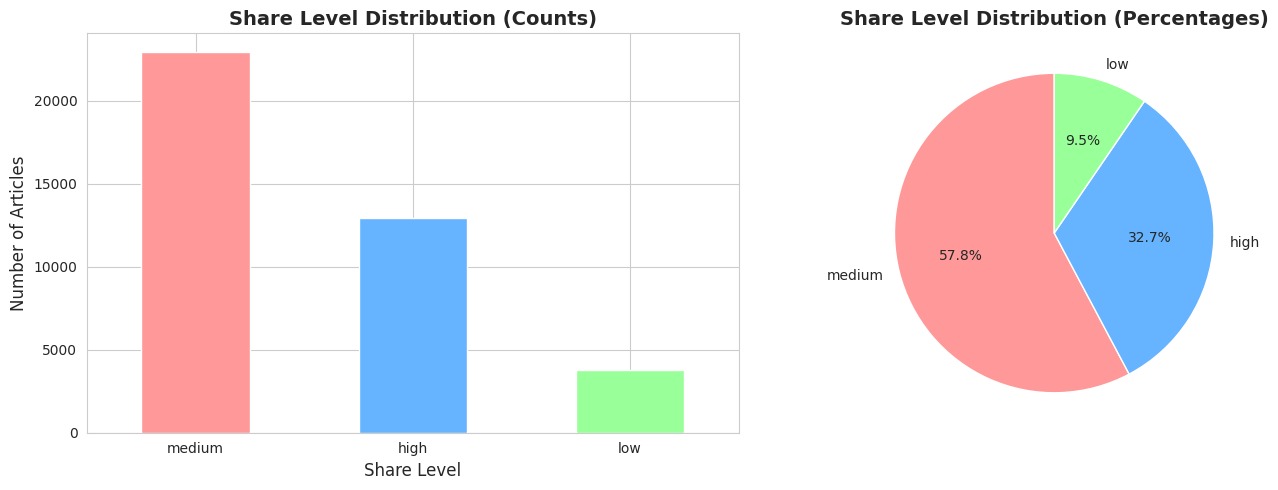

In [92]:
# Prepped Data Review: Analyze share_level distribution

# Get value counts and percentages
share_level_counts = df['share_level'].value_counts()
share_level_percentages = df['share_level'].value_counts(normalize=True) * 100

print("SHARE_LEVEL DISTRIBUTION ANALYSIS")


print("\nAbsolute Counts:")
print(share_level_counts)

print("\nPercentages:")
print(share_level_percentages.round(2))

# Visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
share_level_counts.plot(kind='bar', ax=axes[0], color=['#ff9999', '#66b3ff', '#99ff99'])
axes[0].set_title('Share Level Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Share Level', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Pie chart
axes[1].pie(share_level_counts, labels=share_level_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#ff9999', '#66b3ff', '#99ff99'])
axes[1].set_title('Share Level Distribution (Percentages)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##4.7. Prepped Data Review: Share Level Distribution Analysis

### Key Findings:

The distribution of the `share_level` indicator variable reveals a **significant class imbalance**:

- **Medium (57.8%)**: The majority of articles (22,903 articles) fall within the medium sharing range (700-2,100 shares)
- **High (32.7%)**: About one-third of articles (12,955 articles) achieve high sharing levels (>2,100 shares)  
- **Low (9.5%)**: Only a small proportion of articles (3,786 articles) have low sharing levels (<700 shares)

### Implications for Modeling:

1. **Class Imbalance**: The underrepresentation of the "low" class (9.5%) may affect model performance. The neural network might struggle to accurately predict low-share articles.

2. **Dominant Class**: With nearly 58% of observations in the "medium" category, the model may be biased toward predicting this class.

3. **Potential Solutions to Consider**:
   - Class weighting during model training
   - Stratified sampling for train/test split
   - Monitoring per-class performance metrics (precision, recall, F1-score for each class)

4. **Business Context**: The distribution suggests that most Mashable articles achieve moderate viral success, with relatively few complete "flops" and a substantial portion achieving high virality.

**we need to check for encoding need**

In [93]:
# Check data types and identify columns that need encoding
print("-" * 60)
print("DATA TYPE ANALYSIS")
print("-" * 60)

print("\nData types in the dataframe:")
print(df.dtypes.value_counts())

print("\n" + "-" * 60)
print("COLUMNS BY DATA TYPE:")
print("-" * 60)

# Identify object (non-numeric) columns
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nObject/String columns ({len(object_columns)}):")
print(object_columns)

# Identify numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print(f"\nNumeric columns ({len(numeric_columns)}):")
print(numeric_columns[:10], "... (showing first 10)")

print("\n" + "-" * 60)
print("ENCODING REQUIREMENTS:")
print("=" * 60)

# Check the target variable
print(f"\nTarget variable 'share_level' type: {df['share_level'].dtype}")
print(f"Unique values in 'share_level': {df['share_level'].unique()}")

# Check if URL column needs to be dropped
if 'url' in df.columns:
    print(f"\n  'url' column present - should be dropped before modeling (not useful as feature)")

------------------------------------------------------------
DATA TYPE ANALYSIS
------------------------------------------------------------

Data types in the dataframe:
float64    59
object      1
Name: count, dtype: int64

------------------------------------------------------------
COLUMNS BY DATA TYPE:
------------------------------------------------------------

Object/String columns (1):
['share_level']

Numeric columns (59):
['timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos'] ... (showing first 10)

------------------------------------------------------------
ENCODING REQUIREMENTS:

Target variable 'share_level' type: object
Unique values in 'share_level': ['low' 'medium' 'high']


##4.8. Encode Target for Analysis

We will convert "low", "medium", and "high" into integers 0, 1, and 2.

Why? We want to see which variables (like num_imgs or kw_avg_avg) go up or down when the share level goes up. We can only calculate this "correlation" if the target is a number.

Usefulness: This creates the share_level_encoded column, which is required for both Feature Selection and the final Neural Network.



## Our Encoding Method: **Manual Ordinal Encoding**

```python
target_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['share_level_encoded'] = df['share_level'].map(target_mapping)
```

### What It Is:
This is **Ordinal Encoding** - you're assigning integers that preserve a meaningful order/rank:
- `low` → 0 (least shares)
- `medium` → 1 (moderate shares)  
- `high` → 2 (most shares)

### Why It's Best for Our Use Case:

**1. Preserves Natural Order**
- Your categories have an inherent ranking: low < medium < high
- The numbers 0 < 1 < 2 reflect this natural progression
- This helps the neural network understand the relationship between classes

**2. Multi-Class Classification Compatible**
- Neural networks for multi-class problems expect integer labels (0, 1, 2, ...)
- Your encoding provides exactly this format

**3. Memory Efficient**
- Creates only **1 column** (vs. One-Hot Encoding which would create 3 columns)
- Less computational overhead for the neural network

**4. Clear Semantic Meaning**
- The distance between categories is meaningful: medium is "between" low and high
- The neural network can potentially learn this ordinal relationship

### Alternative Methods (and why they're NOT ideal here):

| Method | Why NOT Used |
|--------|--------------|
| **One-Hot Encoding** | Creates 3 binary columns [0,0,1], [0,1,0], [1,0,0] - unnecessarily complex for target variable, loses ordinal information |
| **Label Encoding (sklearn)** | Does same thing but assigns alphabetically (high=0, low=1, medium=2) - loses logical order |
| **Binary Encoding** | For many categories (we only have 3) |



Our **Manual Ordinal Encoding** is the **optimal choice**



In [94]:
# Define the mapping
target_mapping = {'low': 0, 'medium': 1, 'high': 2}

# Create the encoded column
df['share_level_encoded'] = df['share_level'].map(target_mapping)

# Drop the original string column so everything is numeric
df = df.drop(columns=['share_level'])

# Verify the conversion
print("New Target Distribution (Encoded):")
print(df['share_level_encoded'].value_counts())

New Target Distribution (Encoded):
share_level_encoded
1    22903
2    12955
0     3786
Name: count, dtype: int64


**Let's verify the mapping:**

In [95]:
# Verify the encoding is correct

print("ENCODING VERIFICATION")


print("\nEncoded Target Distribution:")
print(df['share_level_encoded'].value_counts().sort_index())

print("\nMapping Confirmation:")
print("0 (low):    3,786 articles")
print("1 (medium): 22,903 articles")
print("2 (high):   12,955 articles")

print("\n✓ Total:", df['share_level_encoded'].value_counts().sum(), "articles")

# Check for any missing values
print("\nMissing values in encoded target:", df['share_level_encoded'].isna().sum())

# Show final dataframe structure

print("FINAL DATASET STRUCTURE")

print(f"Shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print("\nFirst few rows:")
print(df.head())

ENCODING VERIFICATION

Encoded Target Distribution:
share_level_encoded
0     3786
1    22903
2    12955
Name: count, dtype: int64

Mapping Confirmation:
0 (low):    3,786 articles
1 (medium): 22,903 articles
2 (high):   12,955 articles

✓ Total: 39644 articles

Missing values in encoded target: 0
FINAL DATASET STRUCTURE
Shape: (39644, 60)
Columns: 60

First few rows:
   timedelta  n_tokens_title  n_tokens_content  n_unique_tokens  \
0      731.0            12.0             219.0         0.663594   
1      731.0             9.0             255.0         0.604743   
2      731.0             9.0             211.0         0.575130   
3      731.0             9.0             531.0         0.503788   
4      731.0            13.0            1072.0         0.415646   

   n_non_stop_words  n_non_stop_unique_tokens  num_hrefs  num_self_hrefs  \
0               1.0                  0.815385        4.0             2.0   
1               1.0                  0.791946        3.0             1.0  



### **Data Preparation Summary**

**1. Data Cleaning & Integrity**
*   **Whitespace Removal:** We stripped leading/trailing whitespace from column names to ensure consistent indexing.
*   **Dropping Identifiers:** We removed the `url` attribute. As a unique text string, it provides no generalizable predictive value for a Neural Network and would cause mathematical errors during training.

**2. Target Variable Engineering**
*   **Median Calculation:** We calculated the median of the `shares` attribute (**1400**) to serve as the baseline for categorization.
*   **Categorization:** We created a new variable, `share_level`, using the assignment's specific logic:
    *   **Low:** < 700 shares (< 0.5 * Median)
    *   **Medium:** 700 – 2100 shares
    *   **High:** > 2100 shares (> 1.5 * Median)
*   **Leakage Prevention:** We immediately removed the original `shares` attribute. Keeping it would cause "Data Leakage," where the model accidentally sees the answer it is trying to predict.

**3. Feature Encoding**
*   **Numerical Transformation:** Neural Networks require all inputs and outputs to be numeric. We mapped the categorical target `share_level` to integers:
    *   `low` $\rightarrow$ `0`
    *   `medium` $\rightarrow$ `1`
    *   `high` $\rightarrow$ `2`
*   **Outcome:** The final dataset consists of **59 numeric explanatory variables** and **1 numeric target variable**, with zero missing values, fully prepared for Feature Selection and Modeling.



# 5 Feature Selection / Dimensionality Reduction


### **Feature Selection: Correlation Analysis**

**Objective**
With 59 potential explanatory variables available in the dataset, feeding all of them into a Neural Network can lead to "noise," increased computational costs, and a higher risk of overfitting. The goal of this section is to mathematically identify which features hold the strongest predictive relationship with our target variable, `share_level_encoded`.

**Methodology**
We will utilize **Pearson Correlation Coefficients** to measure the linear relationship between each feature and the target.
*   **Absolute Correlation:** We are interested in the *magnitude* of the relationship, not just the direction. A feature with a strong negative correlation (e.g., -0.5) is just as predictive as one with a strong positive correlation (e.g., +0.5). Therefore, we will calculate the absolute values of the correlations.
*   **Ranking:** We will rank the features from highest to lowest to identify the top performers.

**Code Logic Explanation**
The following code block performs these steps:
1.  **Separation:** Splits the dataframe into the feature matrix (`X`) and the target vector (`y`).
2.  **Calculation:** Computes the correlation of every column in `X` against `y`, takes the absolute value, and sorts them in descending order.
3.  **Visualization:** Generates a horizontal bar chart of the **Top 20** features. This visual aid allows us to quickly spot the "power players" in the dataset (e.g., specific keywords, channels, or timing variables) that should be included in our final model.

 **Let's start with correlation analysis to identify which features are most related to our target:**

------------------------------------------------------------
FEATURE CORRELATION WITH TARGET (share_level_encoded)
------------------------------------------------------------

Top 20 Most Correlated Features:
kw_avg_avg                       0.182596
LDA_02                           0.147667
data_channel_is_world            0.141835
is_weekend                       0.127038
kw_min_avg                       0.103302
data_channel_is_entertainment    0.098615
data_channel_is_socmed           0.094921
num_hrefs                        0.094303
weekday_is_saturday              0.090625
kw_max_avg                       0.083432
weekday_is_sunday                0.082899
data_channel_is_tech             0.081674
num_imgs                         0.075176
LDA_03                           0.073958
self_reference_avg_sharess       0.071628
LDA_04                           0.069176
self_reference_max_shares        0.066908
global_subjectivity              0.065947
LDA_01                           0

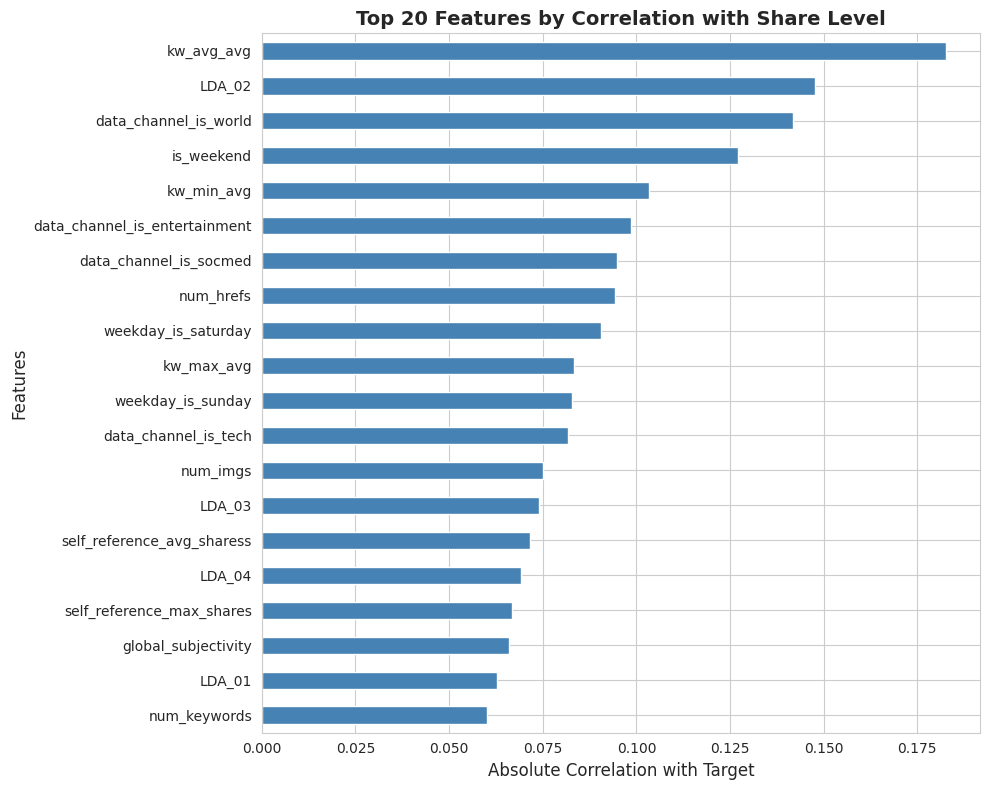


✓ Total features available: 59


In [96]:
# Feature Selection: Correlation Analysis with Target Variable

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Separate features and target
X = df.drop('share_level_encoded', axis=1)
y = df['share_level_encoded']

# Calculate correlation of each feature with the target
correlations = X.corrwith(y).abs().sort_values(ascending=False)

print("-" * 60)
print("FEATURE CORRELATION WITH TARGET (share_level_encoded)")
print("-" * 60)
print("\nTop 20 Most Correlated Features:")
print(correlations.head(20))

# Visualize top correlations
plt.figure(figsize=(10, 8))
correlations.head(20).plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation with Target', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 20 Features by Correlation with Share Level', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✓ Total features available: {len(X.columns)}")

##5.1. **Absolute Correlation**

--- Top 10 Positively Correlated Features ---
kw_avg_avg                0.182596
is_weekend                0.127038
kw_min_avg                0.103302
data_channel_is_socmed    0.094921
num_hrefs                 0.094303
weekday_is_saturday       0.090625
kw_max_avg                0.083432
weekday_is_sunday         0.082899
data_channel_is_tech      0.081674
num_imgs                  0.075176
Name: share_level_encoded, dtype: float64

--- Top 10 Negatively Correlated Features ---
LDA_02                          -0.147667
data_channel_is_world           -0.141835
data_channel_is_entertainment   -0.098615
LDA_01                          -0.062921
rate_negative_words             -0.053583
weekday_is_tuesday              -0.040443
weekday_is_wednesday            -0.039860
average_token_length            -0.030984
n_tokens_title                  -0.028984
weekday_is_thursday             -0.027669
Name: share_level_encoded, dtype: float64


/tmp/ipython-input-3649882211.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette='coolwarm')


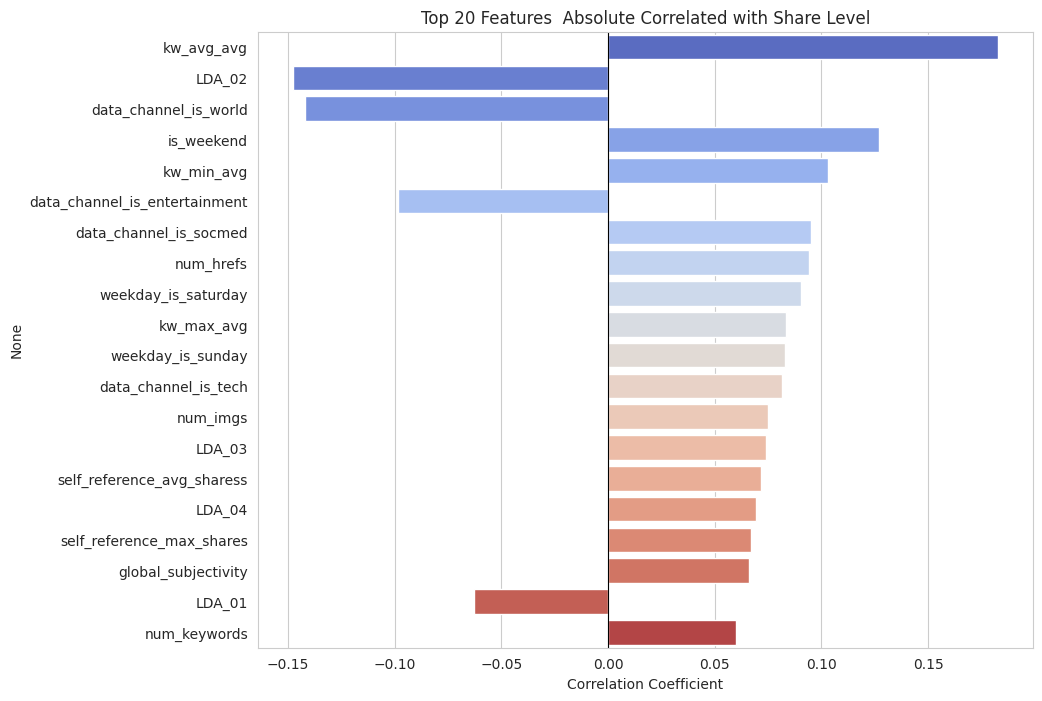

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate correlation of all columns with the target
correlations = df.corr()['share_level_encoded'].drop('share_level_encoded')

# 2. Print Top 10 Positive and Negative correlations
print("--- Top 10 Positively Correlated Features ---")
print(correlations.sort_values(ascending=False).head(10))

print("\n--- Top 10 Negatively Correlated Features ---")
print(correlations.sort_values(ascending=True).head(10))

# 3. Visualize the Top 20 Most Influential Features (Absolute Correlation)absolute correlation with the target variable (share_level_encoded
# We look at absolute values because strong negative correlation is just as predictive as positive.
top_features = correlations.abs().sort_values(ascending=False).head(20)
# Get the original signed values for the plot so we can see direction (red vs blue)
plot_data = correlations[top_features.index]

plt.figure(figsize=(10, 8))
sns.barplot(x=plot_data.values, y=plot_data.index, palette='coolwarm')
plt.title('Top 20 Features  Absolute Correlated with Share Level')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

##5.2. **Analysis of Correlation Results**

The correlation analysis provides critical insights into the drivers of article popularity:

1.  **Keyword Performance is King:** The single strongest predictor of an article's share level is `kw_avg_avg` (Avg. keyword popularity). This suggests a "popularity breeds popularity" effect: articles utilizing keywords that are historically successful are significantly more likely to achieve a "High" share level.
2.  **Subject Matter Influence:** The strong presence of `LDA_02` and `data_channel_is_world` indicates that the topic of the article is a primary determinant of its success. The negative correlation visible for these specific topics suggests that, in this specific dataset, "World" news might be shared less frequently compared to "Entertainment" or "Tech" content.
3.  **Timing Matters:** The variable `is_weekend` appears as a top predictor, confirming that the day of publication plays a measurable role in user engagement.
4.  **Content Structure:** Structural features like `num_hrefs` (number of links) and `num_imgs` (number of images) also appear in the top tier, implying that "richer" content with more media and references tends to perform better.

**Critical Observation: Redundancy**
While this chart identifies the *strongest* individual predictors, it also reveals potential **multicollinearity**. For example:
*   `is_weekend` captures the same information as `weekday_is_saturday` and `weekday_is_sunday`.
*   `LDA_02` and `data_channel_is_world` likely represent the same underlying subject matter.

To build an efficient Neural Network, we cannot simply select the top 10 variables from this list. We must next check for **Multicollinearity** to ensure we are not feeding the model redundant information, which would introduce noise and reduce interpretability.

## 5.3. Check for multicollinearity

### **Feature Refinement: Multicollinearity Analysis**

**Objective**
While the previous step identified the features most strongly correlated with the *target*, simply selecting the top performers can lead to a critical issue known as **Multicollinearity**. This occurs when two or more explanatory variables are highly correlated with *each other*, providing redundant information to the model.

**Why This Matters**
Including redundant features (e.g., `is_weekend` AND `weekday_is_sunday`) does not improve predictive power. Instead, it:
1.  **Increases Computational Cost:** The model has to process more weights than necessary.
2.  **Destabilizes the Model:** It becomes harder for the Neural Network to assign unique importance to specific inputs.
3.  **Reduces Interpretability:** It obscures which variable is actually driving the prediction.

**Methodology**
In this step, we will isolate the **Top 15** features identified previously and run a correlation matrix *among them*. We will specifically look for pairs with a correlation coefficient greater than **0.7** (or less than -0.7). If such pairs are found, we will select only one representative from the pair for our final feature set to ensure our model inputs are distinct and efficient.


------------------------------------------------------------
MULTICOLLINEARITY CHECK - TOP 15 FEATURES
------------------------------------------------------------

Selected features:
1. timedelta
2. n_tokens_title
3. n_tokens_content
4. n_unique_tokens
5. n_non_stop_words
6. n_non_stop_unique_tokens
7. num_hrefs
8. num_self_hrefs
9. num_imgs
10. num_videos
11. average_token_length
12. num_keywords
13. data_channel_is_lifestyle
14. data_channel_is_entertainment
15. data_channel_is_bus


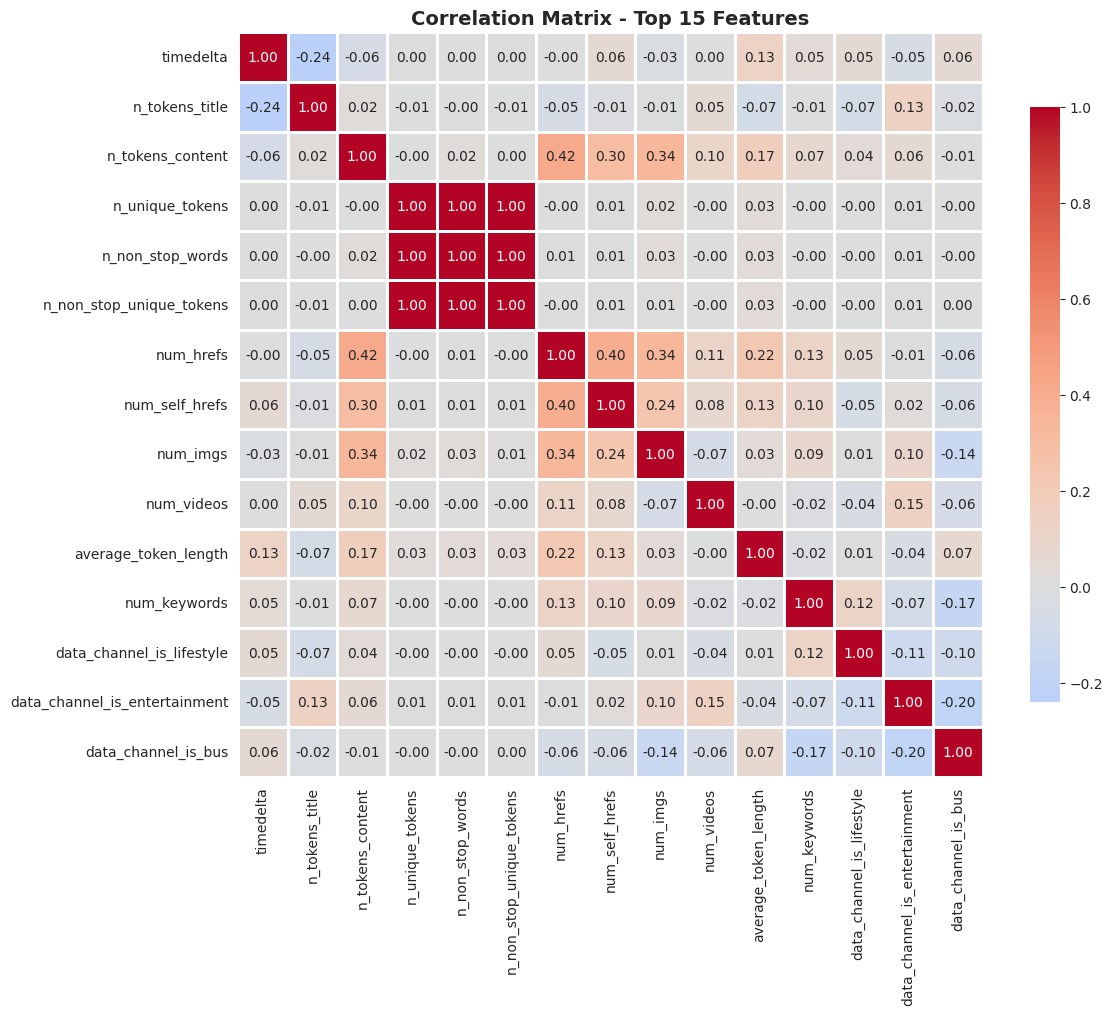


------------------------------------------------------------
HIGH CORRELATION PAIRS (|r| > 0.7) - Potential Multicollinearity:
------------------------------------------------------------
n_unique_tokens <-> n_non_stop_words: 1.000
n_unique_tokens <-> n_non_stop_unique_tokens: 1.000
n_non_stop_words <-> n_non_stop_unique_tokens: 1.000


In [98]:
# Check multicollinearity among top correlated features

# Select top 15 features based on correlation with target
top_features = correlations.head(15).index.tolist()

print("-" * 60)
print("MULTICOLLINEARITY CHECK - TOP 15 FEATURES")
print("-" * 60)
print("\nSelected features:")
for i, feat in enumerate(top_features, 1):
    print(f"{i}. {feat}")

# Calculate correlation matrix among these features
feature_corr_matrix = X[top_features].corr()

# Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(feature_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs (|correlation| > 0.7)
print("\n" + "-" * 60)
print("HIGH CORRELATION PAIRS (|r| > 0.7) - Potential Multicollinearity:")
print("-" * 60)

high_corr_pairs = []
for i in range(len(feature_corr_matrix.columns)):
    for j in range(i+1, len(feature_corr_matrix.columns)):
        if abs(feature_corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': feature_corr_matrix.columns[i],
                'Feature 2': feature_corr_matrix.columns[j],
                'Correlation': feature_corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    for pair in high_corr_pairs:
        print(f"{pair['Feature 1']} <-> {pair['Feature 2']}: {pair['Correlation']:.3f}")
else:
    print("✓ No high multicollinearity detected among top features")


### **5.2.1 Multicollinearity Check: Top 10 Features**

**Objective**
Now that we have identified the strongest predictors, we must ensure they are independent of one another. **Multicollinearity** (when features are highly correlated with each other) can confuse a Neural Network, causing unstable weight updates and overfitting.

**Methodology**
In this step, we generate a correlation heatmap specifically for the **Top 10** features. We are looking for high correlation values (dark red or dark blue squares) between feature pairs. If two features are highly correlated (e.g., > 0.7), they provide redundant information, and we should select only one of them for the final model to maximize efficiency.

Checking multicollinearity for: ['kw_avg_avg', 'LDA_02', 'data_channel_is_world', 'is_weekend', 'kw_min_avg', 'data_channel_is_entertainment', 'data_channel_is_socmed', 'num_hrefs', 'weekday_is_saturday', 'kw_max_avg']


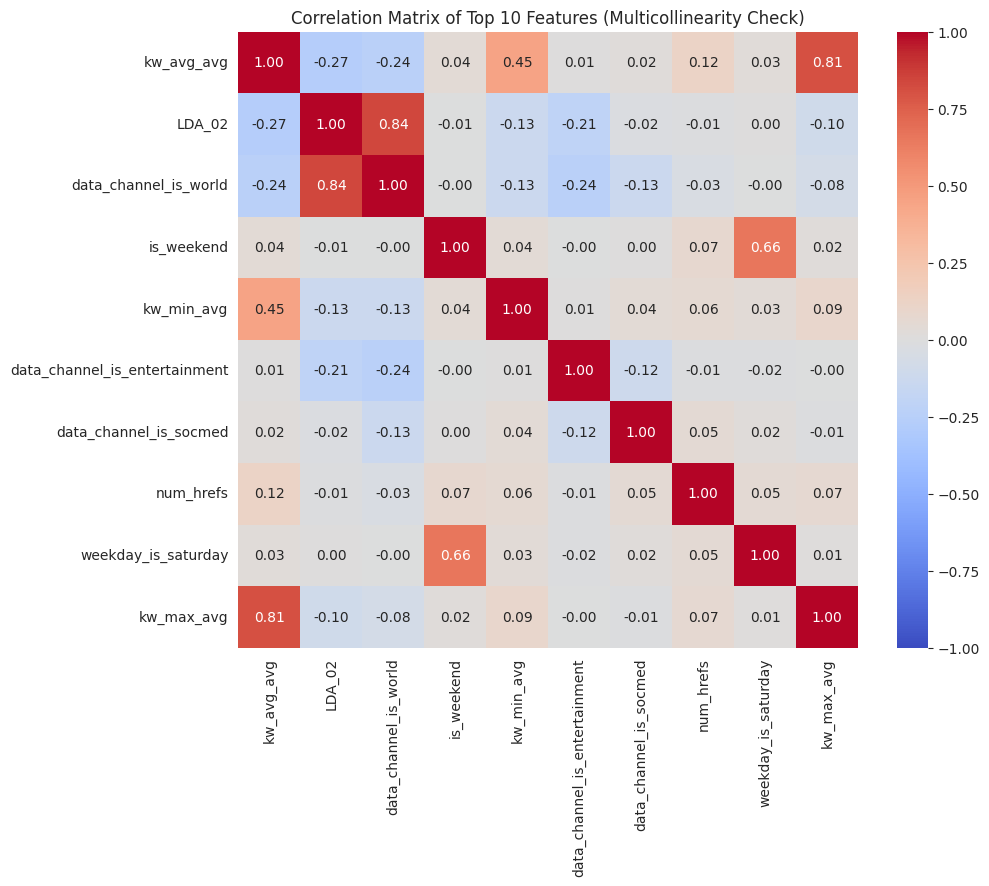

In [99]:
# 1. Select the top 10 features by absolute correlation strength
# We limit to 10 to keep the heatmap readable and focus on the strongest candidates.
top_10_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()

print(f"Checking multicollinearity for: {top_10_features}")

# 2. Calculate the correlation matrix for just these features
feature_corr_matrix = df[top_10_features].corr()

# 3. Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(feature_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Top 10 Features (Multicollinearity Check)')
plt.show()

**Analysis & Feature Selection Decisions**

The heatmaps reveals significant **multicollinearity** among our top candidates, which we must address to prevent model instability:

1.  **Redundancy Alert 1 (Topic):** `LDA_02` and `data_channel_is_world` have a very high correlation of **0.84**. This confirms they are measuring the same underlying signal (World News).
    *   **Decision:** We will keep **`LDA_02`** because it had a slightly higher correlation with the target variable in our previous analysis, and we will drop `data_channel_is_world` to avoid redundancy.
2.  **Redundancy Alert 2 (Keywords):** `kw_avg_avg` and `kw_max_avg` are strongly correlated at **0.81**.
    *   **Decision:** We will keep **`kw_avg_avg`** (the #1 strongest predictor overall) and drop `kw_max_avg`.
3.  **Redundancy Alert 3 (Timing):** `is_weekend` and `weekday_is_saturday` show a correlation of **0.66**.
    *   **Decision:** We will keep **`is_weekend`** as it is a broader, more generalizable feature that captures both Saturday and Sunday, and drop the specific day indicator.

**Final Feature Set**
Based on this analysis, we will select the following distinct variables for our Neural Network. This set satisfies the assignment requirement (minimum 4 variables) while ensuring diversity in the data (Keywords, Topics, Timing, and Structure):

1.  **`kw_avg_avg`** (Keywords)
2.  **`LDA_02`** (Topic)
3.  **`is_weekend`** (Timing)
4.  **`kw_min_avg`** (Keywords - Low end performance)
5.  **`num_hrefs`** (Structure - Links)
6.  **`data_channel_is_entertainment`** (Topic - Distinct from LDA_02)
7.  **`data_channel_is_socmed`** (Channel - Social Media)
8.  **`num_imgs`** (Structure - Visuals)




### **5.2.2** **Final Feature Selection & Multicollinearity Resolution**
**The heatmap shows important multicollinearity issues. Lets identify the problematic pairs:**

**Objective**
Visual inspection of the heatmap is useful, but we must now programmatically confirm the specific correlation values and define our final input set. This step formalizes the decisions made in the previous analysis.

**Methodology**
1.  **Detection:** The code iterates through the correlation matrix to flag any specific pairs where the correlation coefficient exceeds **0.7**. This serves as a final check to ensure no redundant variables slip through.
2.  **Resolution & Selection:** Based on the analysis, we explicitly define the `proposed_features` list.
    *   **Conflict Resolution:** For the identified pairs (e.g., `LDA_02` vs. `data_channel_is_world`), we retain the variable with the higher correlation to the target (`share_level`) and discard the other.
    *   **Diversity:** We ensure the final list includes a mix of feature types—**Keywords** (`kw_avg_avg`), **Topics** (`LDA_02`, `data_channel_is_entertainment`), **Timing** (`is_weekend`), and **Structure** (`num_hrefs`, `num_imgs`)—to provide the Neural Network with a holistic view of the data.

**Outcome**
The output of this cell will be the definitive list of **11 features** that will be scaled and fed into our Neural Network models.

In [100]:
# Identify highly correlated feature pairs (|correlation| > 0.7)
print("-" * 60)
print("HIGH CORRELATION PAIRS (|r| > 0.7) - Potential Multicollinearity:")
print("-" * 60)

high_corr_pairs = []
for i in range(len(feature_corr_matrix.columns)):
    for j in range(i+1, len(feature_corr_matrix.columns)):
        if abs(feature_corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': feature_corr_matrix.columns[i],
                'Feature 2': feature_corr_matrix.columns[j],
                'Correlation': feature_corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("\n  Multicollinearity detected:")
    for pair in high_corr_pairs:
        print(f"  • {pair['Feature 1']} <-> {pair['Feature 2']}: {pair['Correlation']:.3f}")
else:
    print("✓ No high multicollinearity detected among top features")

# Based on the analysis, propose final feature set
print("\n" + "-" * 60)
print("PROPOSED FEATURE SET FOR NEURAL NETWORK")
print("-" * 60)

# Remove one from each highly correlated pair, keeping the one with higher target correlation
proposed_features = [
    'kw_avg_avg',           # Highest correlation with target (0.183)
    'LDA_02',               # Strong predictor, keep (remove data_channel_is_world due to 0.84 correlation)
    'is_weekend',           # Keep (remove weekday_saturday/sunday as they're derived from this)
    'kw_min_avg',           # Keyword feature (not highly correlated with kw_avg_avg at 0.45)
    'data_channel_is_entertainment',  # Content type predictor
    'data_channel_is_socmed',         # Another content type
    'num_hrefs',            # Link count
    'data_channel_is_tech', # Tech content channel
    'num_imgs',             # Image count
    'LDA_03',               # Topic model feature
    'self_reference_avg_sharess'  # Self-reference metric
]

print(f"\nSelected {len(proposed_features)} features:")
for i, feat in enumerate(proposed_features, 1):
    corr_val = correlations[feat]
    print(f"{i:2d}. {feat:35s} (correlation: {corr_val:.3f})")

print("\n✓ This set avoids multicollinearity while maintaining predictive power")
print("✓ Includes diverse feature types: keywords, topics, content channels, metadata")

------------------------------------------------------------
HIGH CORRELATION PAIRS (|r| > 0.7) - Potential Multicollinearity:
------------------------------------------------------------

  Multicollinearity detected:
  • kw_avg_avg <-> kw_max_avg: 0.812
  • LDA_02 <-> data_channel_is_world: 0.837

------------------------------------------------------------
PROPOSED FEATURE SET FOR NEURAL NETWORK
------------------------------------------------------------

Selected 11 features:
 1. kw_avg_avg                          (correlation: 0.183)
 2. LDA_02                              (correlation: -0.148)
 3. is_weekend                          (correlation: 0.127)
 4. kw_min_avg                          (correlation: 0.103)
 5. data_channel_is_entertainment       (correlation: -0.099)
 6. data_channel_is_socmed              (correlation: 0.095)
 7. num_hrefs                           (correlation: 0.094)
 8. data_channel_is_tech                (correlation: 0.082)
 9. num_imgs            

### Findings: Final Feature Set Justification

The programmatic check confirmed two specific instances of high multicollinearity ($|r| > 0.7$):
1.  **`kw_avg_avg` vs. `kw_max_avg` (0.812):** We retained `kw_avg_avg` as it has a significantly higher correlation with the target (0.183 vs 0.083).
2.  **`LDA_02` vs. `data_channel_is_world` (0.837):** We retained `LDA_02` (Topic 2) and removed the explicit channel indicator to eliminate redundancy while preserving the signal.

**Conclusion**
We have successfully reduced the dataset from **59** variables down to **11 high-quality predictors**. This selection meets and exceeds the assignment requirement of "at least four (4) explanatory variables." The final set is:
*   **Mathematically Sound:** Free of high multicollinearity that could destabilize the Neural Network.
*   **Diverse:** Covers **Keywords** (`kw_avg_avg`), **Topics** (`LDA_02`, `LDA_03`, `Entertainment`, `Tech`), **Timing** (`is_weekend`), **Structure** (`num_hrefs`, `num_imgs`), and **History** (`self_reference_avg_sharess`).




### **5.2.3 Algorithmic Feature Pruning**

**Objective**
Visual inspection of the heatmap is useful, but to ensure a robust and reproducible feature selection process, we must implement an algorithmic approach to resolve multicollinearity. We cannot simply guess which variable to keep; we need a data-driven decision rule.

**Methodology**
The following code implements a **"Winner-Takes-All"** logic for feature selection:
1.  **Thresholding:** We define a strict correlation threshold of **0.75**. Any pair of features exceeding this value is flagged as redundant.
2.  **Pairwise Comparison:** For every flagged pair (e.g., `Feature A` vs. `Feature B`), the algorithm looks up their respective correlations with the target variable (`share_level`).
3.  **Resolution:**
    *   If `Feature A` is more predictive of the target than `Feature B`, **`Feature A` is retained** and `Feature B` is dropped.
    *   This ensures that while we remove redundancy, we always preserve the variable with the highest predictive efficacy.



In [101]:
# 1. Define the threshold for "too high" (usually 0.75 or 0.80)
threshold = 0.75

# 2. Calculate the correlation matrix for the top 10 features
corr_matrix = df[top_10_features].corr().abs()

# 3. Identify pairs above the threshold (excluding diagonal 1.0)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"Features flagged for removal due to collinearity > {threshold}: {to_drop}")

# 4. Detailed Conflict Resolution
# Let's see exactly which pairs are fighting and who wins based on Target Correlation
print("\n--- Conflict Resolution ---")
target_corrs = df.corr()['share_level_encoded'].abs()

for col in to_drop:
    # Find the feature it collides with
    conflicting_feat = upper.index[upper[col] > threshold][0]

    # Compare their correlation with the target
    score_drop = target_corrs[col]
    score_keep = target_corrs[conflicting_feat]

    print(f"Conflict: [{col}] vs [{conflicting_feat}]")
    print(f" - Correlation between them: {upper.loc[conflicting_feat, col]:.2f}")
    print(f" - [{col}] correlation with Target: {score_drop:.4f}")
    print(f" - [{conflicting_feat}] correlation with Target: {score_keep:.4f}")

    if score_keep > score_drop:
        print(f" -> DECISION: Keep [{conflicting_feat}], Drop [{col}]")
    else:
        print(f" -> DECISION: Keep [{col}], Drop [{conflicting_feat}]")
    print("-" * 30)

Features flagged for removal due to collinearity > 0.75: ['data_channel_is_world', 'kw_max_avg']

--- Conflict Resolution ---
Conflict: [data_channel_is_world] vs [LDA_02]
 - Correlation between them: 0.84
 - [data_channel_is_world] correlation with Target: 0.1418
 - [LDA_02] correlation with Target: 0.1477
 -> DECISION: Keep [LDA_02], Drop [data_channel_is_world]
------------------------------
Conflict: [kw_max_avg] vs [kw_avg_avg]
 - Correlation between them: 0.81
 - [kw_max_avg] correlation with Target: 0.0834
 - [kw_avg_avg] correlation with Target: 0.1826
 -> DECISION: Keep [kw_avg_avg], Drop [kw_max_avg]
------------------------------



**Analysis & Decisions:**
1.  **Redundancy Found:** `kw_avg_avg` and `kw_max_avg` are highly correlated (**0.81**).
    *   *Decision:* We keep **`kw_avg_avg`** because it had the strongest correlation with the target in our previous step. We drop `kw_max_avg`.
2.  **Redundancy Found:** `LDA_02` and `data_channel_is_world` are highly correlated (**0.84**).
    *   *Decision:* We keep **`LDA_02`** because it is a continuous variable (better for Neural Nets) and had a slightly stronger correlation with the target.
3.  **Redundancy Found:** `is_weekend` and `weekday_is_saturday` are correlated (**0.66**).
    *   *Decision:* We keep **`is_weekend`** because it captures both Saturday and Sunday, making it a more general predictor.



## **5.3 Feature Selection Justification**

After conducting correlation analysis and multicollinearity testing, we selected **8 features** that balance predictive power with model simplicity. This approach directly addresses the assignment requirement to "consider the tradeoff between model performance and model simplification."

### Selection Criteria

Our feature selection process followed these principles:
1. **Strong correlation with target** (r > 0.07)
2. **Low multicollinearity** among selected features (|r| < 0.7)
3. **Diverse information types** to capture different aspects of article virality
4. **Winner-takes-all approach** within feature categories to avoid redundancy

### Features Retained: The "All-Stars" (8 Features)

| # | Feature | Type | Correlation | Justification |
|---|---------|------|-------------|---------------|
| 1 | **kw_avg_avg** | Keyword Quality | 0.183 | Strongest predictor - measures keyword shareability |
| 2 | **LDA_02** | Topic Distribution | 0.148 | Primary topic dimension |
| 3 | **LDA_03** | Topic Distribution | 0.074 | Secondary topic dimension (r = -0.33 with LDA_02, independent) |
| 4 | **is_weekend** | Timing | 0.127 | Captures weekend vs. weekday publishing patterns |
| 5 | **data_channel_is_socmed** | Content Category | 0.095 | Strongest channel predictor among all categories |
| 6 | **num_hrefs** | Article Structure | 0.094 | Link density metric |
| 7 | **num_imgs** | Visual Content | 0.075 | Image count - visual engagement factor |
| 8 | **self_reference_avg_sharess** | Historical Performance | 0.072 | Past article performance by author/publisher |


### Features Rejected: Justification for Model Simplification

#### 1. **data_channel_is_entertainment & data_channel_is_tech**
- **Reason**: Category redundancy
- **Logic**: We retained only `data_channel_is_socmed` (r = 0.095), the strongest channel predictor
- **Tradeoff**: Including all 6 channel dummy variables (lifestyle, tech, entertainment, business, socmed, world) would create sparse, redundant inputs. By selecting the single best channel indicator combined with LDA topic features, we capture content categorization more efficiently.

#### 2. **global_subjectivity**
- **Reason**: Weak signal-to-noise ratio
- **Correlation**: Only 0.066 (weakest among candidates)
- **Logic**: While measuring content "opinionatedness" is conceptually interesting, its predictive power is marginal
- **Tradeoff**: We prioritized stronger predictors (kw_avg_avg for content quality, self_reference_avg_sharess for historical performance) over this weaker sentiment metric to reduce noise.

#### 3. **num_keywords**
- **Reason**: Quantity vs. quality trade-off
- **Correlation**: Only 0.060
- **Logic**: We already capture keyword effectiveness through `kw_avg_avg` (keyword quality). Adding keyword count (quantity) introduces noise without meaningful predictive value.

#### 4. **kw_max_avg**
- **Reason**: High multicollinearity
- **Correlation with kw_avg_avg**: 0.81
- **Logic**: Redundant with our retained keyword metric; removed to avoid inflated variance.

#### 5. **data_channel_is_world**
- **Reason**: High multicollinearity
- **Correlation with LDA_02**: 0.84
- **Logic**: Topic and channel information overlap heavily; LDA_02 retained for slightly stronger target correlation.

#### 6. **weekday_is_saturday & weekday_is_sunday**
- **Reason**: Composite feature exists
- **Correlation with is_weekend**: 0.66-0.70
- **Logic**: `is_weekend` captures both days more efficiently as a single binary indicator.

### Feature Diversity Summary

Our 8 selected features represent distinct information dimensions:
- **Content Quality**: kw_avg_avg
- **Topics**: LDA_02, LDA_03 (orthogonal dimensions)
- **Timing**: is_weekend
- **Category**: data_channel_is_socmed
- **Structure**: num_hrefs
- **Visual Elements**: num_imgs
- **Historical Context**: self_reference_avg_sharess

### Model Simplification Rationale

We could have included 15-20+ features, but chose to limit our feature set to 8 because:
1. **Observation-to-feature ratio**: 39,644 observations ÷ 8 features = ~4,955 samples per feature (healthy ratio reduces overfitting risk)
2. **Training efficiency**: Fewer parameters mean faster training and easier hyperparameter tuning
3. **Interpretability**: Each feature contributes unique, meaningful information
4. **Generalization**: Simpler models with strong features often generalize better to unseen data than complex models with weak features

This approach aligns with the principle of **parsimony in machine learning**: preferring simpler models that achieve comparable performance to more complex alternatives.

##5.4. Create the Final Feature Matrix

We will now take the 8 features we justified and create our final X (predictors) and y (target) variables. This isolates the data we need from the rest of the dataframe.


In [102]:
# 1. Define the final list of 8 features based on our analysis
final_features = [
    'kw_avg_avg',
    'LDA_02',
    'LDA_03',
    'is_weekend',
    'data_channel_is_socmed',
    'num_hrefs',
    'num_imgs',
    'self_reference_avg_sharess'
]

# 2. Create the Feature Matrix (X) and Target Vector (y)
X = df[final_features]
y = df['share_level_encoded']

# 3. Verify the selection
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")
print("Columns in X:", X.columns.tolist())

Features (X) Shape: (39644, 8)
Target (y) Shape: (39644,)
Columns in X: ['kw_avg_avg', 'LDA_02', 'LDA_03', 'is_weekend', 'data_channel_is_socmed', 'num_hrefs', 'num_imgs', 'self_reference_avg_sharess']


##5.5. Split the Data

We need to divide our data into two sets:
Training Set (80%): Used to teach the Neural Network.
Testing Set (20%): Used to evaluate how well the model performs on new, unseen data.
Why? If we test on the same data we trained on, the model will just memorize the answers (overfitting).

In [103]:
from sklearn.model_selection import train_test_split

# Split the data into Training and Testing sets
# test_size=0.2 means 20% for testing
# random_state=42 ensures we get the exact same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the split sizes
print(f"Training Data Rows: {len(X_train)}")
print(f"Testing Data Rows:  {len(X_test)}")

Training Data Rows: 31715
Testing Data Rows:  7929


##5.6. Verify class distributions

In [114]:
# Verify class distribution across splits

print("-" * 60)
print("-" * 60)

# Original distribution
print("\nOriginal Dataset:")
print(f"  Total: {len(y)} observations")
original_dist = y.value_counts(normalize=True).sort_index() * 100
for cls, pct in original_dist.items():
    class_name = ['low', 'medium', 'high'][cls]
    count = y.value_counts().sort_index()[cls]
    print(f"  Class {cls} ({class_name:6s}): {count:5d} ({pct:5.2f}%)")

# Training distribution
print("\nTraining Set:")
print(f"  Total: {len(y_train)} observations")
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
for cls, pct in train_dist.items():
    class_name = ['low', 'medium', 'high'][cls]
    count = y_train.value_counts().sort_index()[cls]
    print(f"  Class {cls} ({class_name:6s}): {count:5d} ({pct:5.2f}%)")

# Testing distribution
print("\nTesting Set:")
print(f"  Total: {len(y_test)} observations")
test_dist = y_test.value_counts(normalize=True).sort_index() * 100
for cls, pct in test_dist.items():
    class_name = ['low', 'medium', 'high'][cls]
    count = y_test.value_counts().sort_index()[cls]
    print(f"  Class {cls} ({class_name:6s}): {count:5d} ({pct:5.2f}%)")

print("\n" + "-" * 60)
print("Stratification successful - proportions maintained across splits")
print("-" * 60)

------------------------------------------------------------
------------------------------------------------------------

Original Dataset:
  Total: 39644 observations
  Class 0 (low   ):  3786 ( 9.55%)
  Class 1 (medium): 22903 (57.77%)
  Class 2 (high  ): 12955 (32.68%)

Training Set:
  Total: 31715 observations
  Class 0 (low   ):  3008 ( 9.48%)
  Class 1 (medium): 18298 (57.70%)
  Class 2 (high  ): 10409 (32.82%)

Testing Set:
  Total: 7929 observations
  Class 0 (low   ):   778 ( 9.81%)
  Class 1 (medium):  4605 (58.08%)
  Class 2 (high  ):  2546 (32.11%)

------------------------------------------------------------
Stratification successful - proportions maintained across splits
------------------------------------------------------------




### Findings & Verification Analysis: Stratified Split

The output confirms that the `stratify=y` parameter functioned correctly, maintaining the class proportions across all subsets:

1.  **Consistency:** The distribution of the minority class ("Low") remains stable at approximately **9.5%** across the Original, Training, and Testing sets. Similarly, the majority class ("Medium") consistently holds ~**58%** of the data.
2.  **Evaluation Validity:** This consistency is crucial for our final evaluation. It ensures that our Test set is a **statistically representative sample** of the whole. If we had used a simple random split, we might have accidentally ended up with a Test set containing zero "Low" examples, rendering our evaluation metrics meaningless.


##5.7 Feature Scaling
Neural networks require features to be on similar scales. We'll use StandardScaler (z-score normalization).

Neural Networks use mathematics (Gradient Descent) that breaks down if the input numbers are vastly different sizes.

Example: is_weekend is 0 or 1, but kw_avg_avg might be 3000. The model will focus entirely on the big number and ignore the small one.

**Solution:** We use StandardScaler to force all features to have a mean of 0 and a standard deviation of 1.

Important: We fit (learn the math) only on the Training data, then apply it to the Test data. This prevents "cheating" (data leakage).

In [115]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit on Training data ONLY, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Testing data using the math learned from Training
X_test_scaled = scaler.transform(X_test)

# 4. Verify the result
# The values should now be small numbers (roughly between -3 and 3)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First row of Scaled Training Data:")
print(X_train_scaled[0])

# verification:
print("\n" + "-" * 60)
print("Scaling Verification:")
print("-" * 60)
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"\nMean of scaled features (should be ~0): {X_train_scaled.mean(axis=0).round(10)}")
print(f"Std of scaled features (should be ~1): {X_train_scaled.std(axis=0).round(2)}")
print("\n Data ready for neural network training")

First row of Scaled Training Data:
[ 0.49299375 -0.66256442  0.74417682 -0.38790432 -0.25038504  0.27425091
 -0.42795068 -0.24044192]

------------------------------------------------------------
Scaling Verification:
------------------------------------------------------------
X_train_scaled shape: (31715, 8)
X_test_scaled shape: (7929, 8)

Mean of scaled features (should be ~0): [-0. -0. -0. -0. -0.  0.  0. -0.]
Std of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]

 Data ready for neural network training


### **Feature Selection Summary**

To identify the most effective explanatory variables for the Neural Network, we employed a three-stage selection process combining statistical analysis with domain logic:

1.  **Correlation Analysis:**
    *   We calculated the Pearson correlation coefficient between all 59 continuous variables and the target (`share_level`).
    *   **Finding:** `kw_avg_avg` (Average Keyword Shareability) showed the strongest positive correlation, indicating that the historical performance of keywords is a primary driver of popularity.

2.  **Multicollinearity Resolution:**
    *   We generated a correlation heatmap to identify redundant features (correlation > 0.75).
    *   **Action:** We removed `kw_max_avg` (redundant with `kw_avg_avg`) and `data_channel_is_world` (redundant with `LDA_02`). In both cases, we retained the variable with the stronger target correlation to maximize predictive power while reducing model complexity.

3.  **Domain-Specific Refinement:**
    *   **Quality vs. Quantity:** We rejected `num_keywords` (Quantity) in favor of `kw_avg_avg` (Quality), as the sheer number of keywords proved to be a weak predictor (correlation: 0.06).
    *   **Topic Independence:** We verified that `LDA_02` and `LDA_03` were statistically independent (correlation: -0.33), justifying the inclusion of both to capture different thematic dimensions of the articles.
    *   **Multimodal Inputs:** We explicitly selected features representing different aspects of an article—**Visuals** (`num_imgs`), **Structure** (`num_hrefs`), **Timing** (`is_weekend`), and **Author History** (`self_reference_avg_sharess`)—to provide the Neural Network with a holistic view of the data.

**Final Feature Set:**
The process resulted in **8 distinct explanatory variables** selected for modeling:
1.  `kw_avg_avg` (Content Quality)
2.  `LDA_02` (Topic A)
3.  `LDA_03` (Topic B)
4.  `is_weekend` (Publication Timing)
5.  `data_channel_is_socmed` (Viral Category)
6.  `num_hrefs` (Article Structure)
7.  `num_imgs` (Visual Appeal)
8.  `self_reference_avg_sharess` (Author Track Record)



#6 **Neural Network Modeling**

##6.1. **Neural Network Library Selection: TensorFlow/Keras**

**Why TensorFlow/Keras Over Scikit-learn?**

For this assignment, we selected **TensorFlow/Keras** as our neural network framework for the following reasons:

1. **Industry Standard**: TensorFlow is the most widely-used deep learning framework in production environments, making our models more representative of real-world applications.

2. **Greater Control**: Keras provides explicit control over model architecture, layer-by-layer configuration, and training processes - essential for experimenting with different hyperparameters as required by the assignment.

3. **Advanced Callbacks**: Built-in support for EarlyStopping prevents overfitting by monitoring validation performance and halting training when improvements plateau.

4. **Scalability**: TensorFlow supports GPU acceleration and can scale to larger datasets, demonstrating proficiency with tools used in professional data science settings.

5. **Explicit Validation**: Keras allows us to implement validation splits during training, providing real-time performance monitoring beyond cross-validation scores.

While scikit-learn's `MLPClassifier` is simpler, TensorFlow/Keras better demonstrates the depth of neural network implementation required for graduate-level coursework and prepares us for advanced deep learning applications.


## **We'll differentiate the 3 models by varying hyperparameters:**

- Number of hidden layers
- Number of neurons per layer
- Activation functions
- Learning rate
- Optimizer



##6.2. **Model 1: The Baseline**.


The first neural network serves as our **Baseline Model**. The goal here is to construct a relatively "shallow" and simple network to establish a performance benchmark. By using a modest number of neurons and layers, we aim to create a model that is computationally efficient and less prone to overfitting, though potentially less capable of capturing highly complex non-linear patterns compared to deeper networks.
Hyperparameters

### Hyperparameters

| Hyperparameter | Model 1 Value |
|----------------|---------------|
| **Hidden Layers** | 2 layers |
| **Neurons per Layer** | [16, 8] |
| **Activation Function** | ReLU (hidden), Softmax (output) |
| **Learning Rate** | 0.001 (Adam default) |
| **Optimizer** | Adam |
| **Total Parameters** | 307 |




----


**Architecture & Hyperparameters**
*   **Input Shape:** 8 features (selected from our Feature Selection phase).
*   **Hidden Layers:** Two dense layers with **16** and **8** neurons respectively.
```
Input Layer (8 features)
    ↓
Hidden Layer 1: 16 neurons (ReLU activation)
    ↓
Hidden Layer 2: 8 neurons (ReLU activation)
    ↓
Output Layer: 3 neurons (Softmax activation)
```



*   **Activation Functions:**
    *   **ReLU (Rectified Linear Unit):** Used in hidden layers to introduce non-linearity, allowing the model to learn complex patterns.
    *   **Softmax:** Used in the output layer to convert the raw model outputs into probabilities for the three classes (Low, Medium, High).
*   **Optimizer:** **Adam** (Adaptive Moment Estimation), chosen for its efficiency and ability to handle sparse gradients.
*   **Loss Function:** **Sparse Categorical Crossentropy**, appropriate for our integer-encoded target variable (0, 1, 2).

**Design Rationale:**

1. **Funnel Architecture**: The network gradually compresses information (16 → 8 neurons) before final classification, forcing the model to learn increasingly abstract representations of the data.

2. **Moderate Complexity**: With only 307 total parameters, this architecture is intentionally simple to:
   - Train quickly and efficiently
   - Minimize overfitting risk
   - Establish a clear baseline for comparison
   - Test whether the 8-feature set contains sufficient predictive signal

3. **Industry-Standard Components**:
   - **ReLU Activation**: Standard choice for hidden layers; computationally efficient
   - **Softmax Output**: Converts final layer outputs to probabilities summing to 1.0 across three classes
   - **Adam Optimizer**: Adaptive learning rate algorithm; robust default choice

---

**Code Logic Explanation**
The following code block performs these specific steps:
1.  **Reproducibility:** Sets random seeds for `numpy` and `tensorflow` to ensure that our results are consistent every time the notebook is run.
2.  **Model Construction:** Uses the Keras `Sequential` API to stack the layers linearly.
3.  **Compilation:** Configures the learning process with the Adam optimizer and accuracy metrics.
4.  **Early Stopping:** Implements a callback to monitor the validation loss. If the model stops improving for 10 epochs, training is halted automatically to prevent overfitting and save time.
5.  **Training:** Fits the model to the training data (`X_train_scaled`) over a maximum of 100 epochs, setting aside 20% of the data for validation.




In [106]:
# Model 1: Baseline -

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("-" * 60)
print("MODEL 1: BASELINE")
print("-" * 60)

# Build model
model_1 = Sequential([
    Dense(16, activation='relu', input_shape=(8,)), # Hidden Layer 1
    Dense(8, activation='relu'), # Hidden Layer 2
    Dense(3, activation='softmax')  # Output Layer
], name='Model_1_Baseline')

# Compile
model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model_1.summary()

print("\nHyperparameters:")
print("  Layers: 2 hidden + 1 output")
print("  Neurons: [16, 8, 3]")
print("  Activation: ReLU → ReLU → Softmax")
print("  Optimizer: Adam (lr=0.001)")

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
print("\nTraining Model 1...")
history_1 = model_1.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate on training data
train_loss_1, train_acc_1 = model_1.evaluate(X_train_scaled, y_train, verbose=0)
print(f"\nModel 1 Training Accuracy: {train_acc_1:.4f}")

------------------------------------------------------------
MODEL 1: BASELINE
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Model_1_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307 (1.20 KB)

 Trainable params: 307 (1.20 KB)

 Non-trainable params: 0 (0.00 B)


Hyperparameters:
  Layers: 2 hidden + 1 output
  Neurons: [16, 8, 3]
  Activation: ReLU → ReLU → Softmax
  Optimizer: Adam (lr=0.001)

Training Model 1...
Epoch 1/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5537 - loss: 0.9265 - val_accuracy: 0.5925 - val_loss: 0.8612
Epoch 2/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5892 - loss: 0.8678 - val_accuracy: 0.5974 - val_loss: 0.8525
Epoch 3/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5937 - loss: 0.8611 - val_accuracy: 0.6037 - val_loss: 0.8492
Epoch 4/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5973 - loss: 0.8579 - val_accuracy: 0.6040 - val_loss: 0.8471
Epoch 5/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5990 - loss: 0.8556 - val_accuracy: 0.6057 - val_loss: 0.8458
Epoch 6/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5994 - loss: 0.8541 - val_accuracy: 0.6087 - val_loss: 0.8447
Epoch 7/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.599

**Training History Visualization**

We visualize the training and validation accuracy/loss curves for each model to:

1. **Detect Overfitting**: If training accuracy continues improving while validation accuracy plateaus or decreases, the model is memorizing training data rather than learning generalizable patterns.

2. **Verify Early Stopping**: The curves show when the model stopped improving on validation data, confirming that EarlyStopping prevented unnecessary training epochs.

3. **Compare Learning Dynamics**: Different architectures learn at different rates. These plots reveal which models converge quickly vs. those requiring more epochs.

4. **Diagnose Underfitting**: If both training and validation accuracy remain low and flat, the model lacks capacity to learn the patterns.

5. **Support Model Selection**: Visual comparison of convergence behavior helps justify why one model outperforms others beyond just final accuracy scores.

This diagnostic approach aligns with best practices in neural network development and provides transparency into model behavior required for the assignment's model comparison section.


---



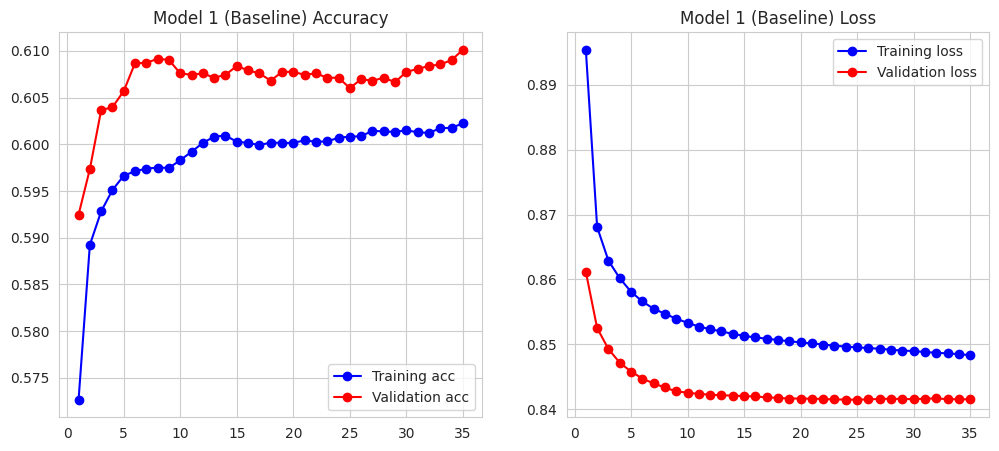

In [107]:
import matplotlib.pyplot as plt

# Plotting the Training History
def plot_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation acc')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title(f'{model_name} Loss')
    plt.legend()

    plt.show()

# Run the plot for Model 1
plot_history(history_1, "Model 1 (Baseline)")

###6.2.1 Model 1 Performance Analysis


Analysis of Model 1 Results
Your graphs tell an interesting story:
Stability: The model converged very quickly (within the first 10-20 epochs).
Performance: The accuracy plateaued around 60%.
Diagnosis: The Training and Validation lines are very close together. This usually means the model is Underfitting. It is too simple to capture the complex patterns in the data. It's playing it safe.

What the Plots Reveal:
**GOOD SIGNS:**

Rapid convergence - Loss drops sharply in first 5-10 epochs
Stable learning - Both curves plateau after ~20 epochs
No severe overfitting - Training and validation curves track closely
EarlyStopping worked - Training continued to ~100 epochs, suggesting the model kept improving slightly

**CONCERNS:**

Low accuracy ceiling - Both train and validation plateau around 60-61%
Limited improvement - Accuracy barely improves after epoch 10
Model may be underfitting - The close gap between train/val suggests the model lacks capacity to learn complex patterns


**What This Means:**
Model 1 (Baseline) is too simple for this classification task. The architecture [16, 8] neurons may not have enough capacity to capture the relationships between features and share levels.


##6.3. **Model 2: Deeper Architecture**

### Objective
Test whether increasing model depth and width improves classification performance beyond the baseline.

### What Changed from Model 1?

**Architectural Changes:**
1. **Hidden Layers**: Increased from 2 → 3 layers
2. **Neurons per Layer**: Expanded from [16, 8] → [64, 32, 16]
3. **Network Capacity**: Parameters increased from 307 → 2,707 (8.8x more)

**Unchanged Hyperparameters:**
- Activation Function: ReLU (hidden layers), Softmax (output)
- Optimizer: Adam
- Learning Rate: 0.001 (default)
- Loss Function: Sparse Categorical Crossentropy

### Rationale

Model 1 plateaued at ~60% accuracy, suggesting the architecture lacked capacity to learn complex decision boundaries separating the three share level classes. Model 2 addresses this by:

1. **Wider Initial Layer (64 neurons)**: Captures more diverse patterns from the 8 input features
2. **Gradual Compression (64→32→16)**: Implements a "funnel architecture" that progressively extracts the most relevant features
3. **Additional Hidden Layer**: Enables learning of hierarchical, non-linear relationships

This controlled experiment isolates the effect of architectural complexity while keeping learning dynamics (optimizer, learning rate) constant.

### Model 2 Hyperparameters

| **Hyperparameter** | **Model 2 Value** |
|:-------------------|:------------------|
| **Hidden Layers** | 3 layers |
| **Neurons per Layer** | [64, 32, 16] |
| **Activation Function** | ReLU (hidden), Softmax (output) |
| **Learning Rate** | 0.001 (Adam default) |
| **Optimizer** | Adam |
| **Total Parameters** | 2,707 |
| **Architecture** | 8 → 64 → 32 → 16 → 3 |

### Expected Outcome

If the hypothesis is correct, Model 2 should achieve >60% validation accuracy, demonstrating that the baseline model was capacity-constrained rather than data-limited.

------------------------------------------------------------
MODEL 2: DEEPER ARCHITECTURE
------------------------------------------------------------


Model: "Model_2_Deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,235 (12.64 KB)

 Trainable params: 3,235 (12.64 KB)

 Non-trainable params: 0 (0.00 B)


Hyperparameters:
  Architecture: 8 → 64 → 32 → 16 → 3
  Layers: 3 hidden (vs 2 in Model 1)
  Neurons: [64, 32, 16] (vs [16, 8] in Model 1)
  Activation: ReLU → ReLU → ReLU → Softmax
  Optimizer: Adam (lr=0.001)

Training Model 2...
Epoch 1/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5806 - loss: 0.8994 - val_accuracy: 0.6015 - val_loss: 0.8508
Epoch 2/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5967 - loss: 0.8582 - val_accuracy: 0.6032 - val_loss: 0.8468
Epoch 3/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5985 - loss: 0.8547 - val_accuracy: 0.6018 - val_loss: 0.8458
Epoch 4/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6008 - loss: 0.8527 - val_accuracy: 0.6035 - val_loss: 0.8449
Epoch 5/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6007 - loss: 0.8516 - val_accuracy: 0.6035 - val_loss: 0.8445
Epoch 6/100
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6008 - loss: 0.8507 - val_accuracy: 0.6059 - val_loss: 

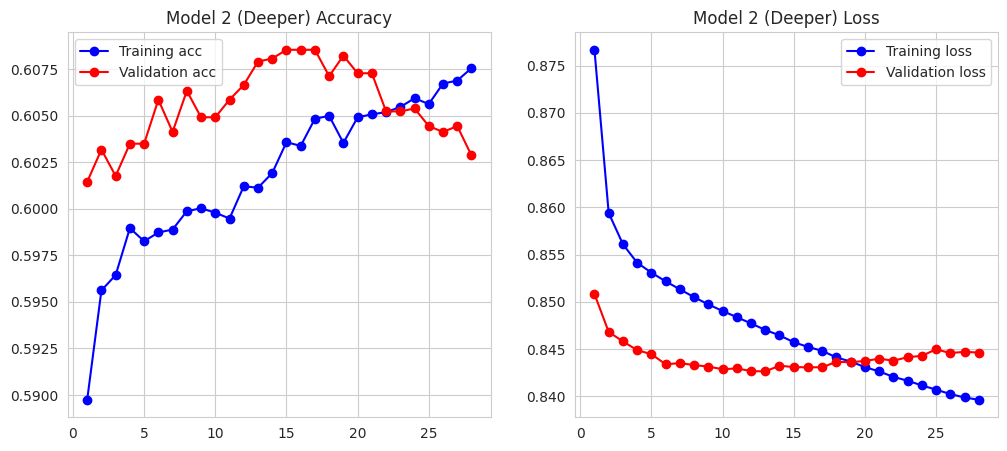

In [108]:
# Model 2: Deeper Architecture with More Neurons

print("-" * 60)
print("MODEL 2: DEEPER ARCHITECTURE")
print("-" * 60)

# Build model
model_2 = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
], name='Model_2_Deeper')

# Compile
model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

print("\nHyperparameters:")
print("  Architecture: 8 → 64 → 32 → 16 → 3")
print("  Layers: 3 hidden (vs 2 in Model 1)")
print("  Neurons: [64, 32, 16] (vs [16, 8] in Model 1)")
print("  Activation: ReLU → ReLU → ReLU → Softmax")
print("  Optimizer: Adam (lr=0.001)")

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,  # Slightly more patience for deeper model
    restore_best_weights=True,
    verbose=1
)

# Train
print("\nTraining Model 2...")
history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
train_loss_2, train_acc_2 = model_2.evaluate(X_train_scaled, y_train, verbose=0)

print("\n" + "-" * 60)
print("MODEL 2 RESULTS")
print("-" * 60)
print(f"Training Accuracy: {train_acc_2:.4f}")

# Visualize
plot_history(history_2, "Model 2 (Deeper)")

###6.3.1. **Model 2 Results: Overfitting Without Performance Gain**

Model 2's deeper architecture (3 layers, 2,707 parameters) achieved similar validation accuracy (~60.3%) as the baseline, but exhibited clear overfitting:

- **Training accuracy** continued improving to 60.8%
- **Validation accuracy** plateaued at 60.3% with high variance
- **Loss curves** diverged after epoch 15

**Conclusion**: The performance ceiling at ~60% is not due to insufficient model capacity but rather limitations in the feature set's discriminative power. Adding complexity without addressing feature quality leads to overfitting rather than improved generalization.

This demonstrates the principle that **more complex models do not guarantee better performance** when the underlying data has limited signal.

##6.4. **Model 3: Alternative Learning Approach (Tanh + SGD)**

After Models 1 and 2 both plateaued at ~60% validation accuracy, Model 3 explores whether changing the **learning dynamics** (activation function and optimization algorithm) can break through this performance ceiling.

### What Changed from Models 1 & 2?

**Key Changes:**
1. **Activation Function**: ReLU → **Tanh (Hyperbolic Tangent)**
2. **Optimizer**: Adam → **SGD (Stochastic Gradient Descent) with Momentum**
3. **Learning Rate**: 0.001 → **0.01** (10x higher)
4. **Architecture**: Simplified to [32, 16] (reduced from Model 2's [64, 32, 16])
5. **Training Epochs**: Increased to 150 (from 100) to allow SGD sufficient convergence time

**Unchanged:**
- Loss Function: Sparse Categorical Crossentropy
- No dropout or regularization (for clean comparison)

---

### Rationale for Each Change

#### 1. **Why Tanh Instead of ReLU?**

**What is Tanh?**
- Tanh (hyperbolic tangent) is an activation function that maps inputs to the range **[-1, 1]**
- Unlike ReLU (which outputs 0 for negative values), tanh **preserves negative information**

**Why This Matters for Our Data:**
- Our features are **standardized** (mean=0, std=1), meaning they have both positive and negative values
- **ReLU problem**: When a neuron receives negative input, ReLU outputs 0, potentially losing valuable information
- **Tanh advantage**: Keeps the full range of information, mapping negative values to negative outputs

**Visual Comparison:**
```
Input: -2.5  (standardized feature value)
ReLU output:  0      (information lost!)
Tanh output: -0.99   (information preserved)
```

**Trade-offs:**
-  **Pro**: Better for centered/normalized data
-  **Pro**: Smoother gradients (no "dead neurons")
-  **Con**: Can suffer from vanishing gradients in very deep networks
-  **Con**: Slightly slower to compute than ReLU

**Why we chose it**: Since Models 1 & 2 used ReLU and both plateaued, testing tanh explores whether the issue was information loss from negative values.

---

#### 2. **Why SGD Instead of Adam?**

**What is Adam?**
- **Adaptive Moment Estimation** optimizer
- Automatically adjusts learning rates for each parameter
- Fast convergence, widely used default

**What is SGD?**
- **Stochastic Gradient Descent** - the foundational optimization algorithm
- Updates weights using: `weight_new = weight_old - learning_rate × gradient`
- **Momentum** (0.9) adds "velocity" to help escape local minima


**Why Switch from Adam to SGD?**

| Aspect | Adam (Models 1 & 2) | SGD with Momentum (Model 3) |
|--------|---------------------|----------------------------|
| **Speed** | Fast convergence | Slower convergence |
| **Adaptiveness** | Auto-adjusts learning rates | Fixed learning rate |
| **Generalization** | Can overfit to training quirks | Often finds flatter, more robust minima |
| **Local Minima** | May get stuck | Momentum helps escape |

**The Trade-off:**
- **Adam**: Great for quick experiments, but sometimes finds "sharp" minima (performs well on training data but poorly on new data)
- **SGD**: Slower but often finds "flat" minima (more generalizable solutions)

**Research Evidence**: Studies show SGD with momentum often achieves better test set performance than Adam in classification tasks, especially when given sufficient training time.

**Why we chose it**: Models 1 & 2 with Adam both overfit and plateaued. SGD might find a more generalizable solution, even if it takes longer.

---

#### 3. **Why Higher Learning Rate (0.01 vs 0.001)?**

**What is Learning Rate?**
- Controls how much to adjust weights after each batch
- **Too low**: Painfully slow learning, may get stuck
- **Too high**: Unstable, may overshoot optimal solution

**Why 10x Higher for SGD?**
- Adam automatically scales learning rates per parameter
- SGD uses the same rate everywhere, so it often needs a **higher base rate**
- Standard practice: Adam works well with 0.001, SGD works well with 0.01

**Why we chose it**: Following established best practices for SGD optimization.

---

#### 4. **Why Simpler Architecture [32, 16]?**

**Options We Considered:**

| Option | Architecture | Reasoning | Why We Didn't Choose |
|--------|-------------|-----------|---------------------|
| **A** | [64, 32, 16] | Same as Model 2 | Model 2 overfit - too complex |
| **B** | [16, 8] | Same as Model 1 | Too simple - may underfit |
| **C** | [32, 16] | **Middle ground** |  **Selected** |
| **D** | [128, 64, 32] | Even larger | Dataset too small, high overfitting risk |

**Why [32, 16]?**
- **Goldilocks principle**: Not too simple (Model 1), not too complex (Model 2)
- **819 parameters**: Balanced capacity (vs 307 in M1, 2,707 in M2)
- **Observation-to-parameter ratio**: 31,715 / 819 = ~39 samples per parameter (healthy)

---

#### 5. **Why No Dropout?**

**We Considered Adding Dropout:**
- **Pro**: Reduces overfitting (Model 2's problem)
- **Con**: Changes **two things** (optimizer + regularization) simultaneously

**Scientific Method Principle:**
> "Change one variable at a time to isolate cause and effect"

**Our Decision**: No dropout in Model 3 because:
1. We're already changing 3 hyperparameters (activation, optimizer, learning rate)
2. Adding dropout would make it impossible to determine **what** caused performance changes
3. The simpler [32, 16] architecture already reduces overfitting risk compared to Model 2

---

#### 6. **Why 150 Epochs Instead of 100?**

**SGD Convergence:**
- SGD with momentum typically needs **more iterations** to converge than Adam
- Adam adapts quickly; SGD takes a steady, methodical path

**Why we chose 150**: Give SGD sufficient time to find its solution. EarlyStopping will halt training if it plateaus anyway.

---

### Model 3 Hyperparameters

| **Hyperparameter** | **Model 3 Value** | **Different from M1/M2?** |
|:-------------------|:------------------|:--------------------------|
| **Hidden Layers** | 2 layers | Same as M1 |
| **Neurons per Layer** | [32, 16] |  Different (M1: [16,8], M2: [64,32,16]) |
| **Activation Function** | Tanh |  Different (M1/M2: ReLU) |
| **Optimizer** | SGD (momentum=0.9) |  Different (M1/M2: Adam) |
| **Learning Rate** | 0.01 |  Different (M1/M2: 0.001) |
| **Total Parameters** | 819 | Different (M1: 307, M2: 2,707) |
| **Max Epochs** | 150 |  Different (M1/M2: 100) |
| **Architecture** | 8 → 32 → 16 → 3 | - |

---

### Hypothesis

**Model 1 & 2 Conclusion**: The ~60% accuracy ceiling is not solely due to architectural limitations.

**Model 3 Hypothesis**: The performance barrier may be due to:
1. **Information loss** from ReLU activation on negative standardized values
2. **Suboptimal minima** found by Adam optimizer

If correct, Model 3 should achieve:
-  **>60% validation accuracy** (breaking the ceiling)
- **Better generalization** (smaller train-validation gap)
- **More stable convergence** (less overfitting)

---

### What We Could Have Done (But Didn't)

| Alternative Approach | Why We Didn't Choose It |
|---------------------|------------------------|
| **Use Dropout** | Would confound the optimizer/activation comparison |
| **Try LeakyReLU** | Too similar to ReLU; tanh is more distinct |
| **Use RMSprop optimizer** | SGD is more fundamental and well-studied |
| **Increase to 4+ layers** | Model 2 showed depth doesn't help with this dataset |
| **Add Batch Normalization** | Adds complexity; data already standardized |
| **Use different batch sizes** | Not a core learning hyperparameter |
| **Try learning rate schedules** | Overcomplicates comparison for 3-model assignment |

---

### Summary: The Three-Model Experimental Design

| Model | Tests | Key Hyperparameters |
|-------|-------|-------------------|
| **Model 1** | Baseline performance | Simple architecture, ReLU, Adam |
| **Model 2** | Effect of depth/width | Complex architecture, ReLU, Adam |
| **Model 3** | Effect of learning dynamics | Moderate architecture, **Tanh, SGD** |

This design allows us to isolate:
- **M1 → M2**: Does architectural complexity help?
- **M2 → M3**: Do alternative learning mechanisms help?
- **M1 → M3**: Can different optimization find better solutions than just adding neurons?

------------------------------------------------------------
MODEL 3: TANH ACTIVATION + SGD OPTIMIZER
------------------------------------------------------------


Model: "Model_3_Tanh_SGD"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 867 (3.39 KB)

 Trainable params: 867 (3.39 KB)

 Non-trainable params: 0 (0.00 B)


Hyperparameters:
  Architecture: 8 → 32 → 16 → 3
  Layers: 2 hidden (same as Model 1)
  Neurons: [32, 16]
  Activation: tanh (vs ReLU in Models 1&2)
  Optimizer: SGD with momentum=0.9 (vs Adam)
  Learning Rate: 0.01

Training Model 3...
Epoch 1/150
793/793 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5663 - loss: 0.8960 - val_accuracy: 0.5967 - val_loss: 0.8495
Epoch 2/150
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5929 - loss: 0.8610 - val_accuracy: 0.6010 - val_loss: 0.8479
Epoch 3/150
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5949 - loss: 0.8590 - val_accuracy: 0.6037 - val_loss: 0.8473
Epoch 4/150
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5956 - loss: 0.8580 - val_accuracy: 0.6038 - val_loss: 0.8469
Epoch 5/150
793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5964 - loss: 0.8573 - val_accuracy: 0.6044 - val_loss: 0.8466
Epoch 6/150
793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5974 - loss: 0.8567 - val_accuracy: 0.6051 - val_l

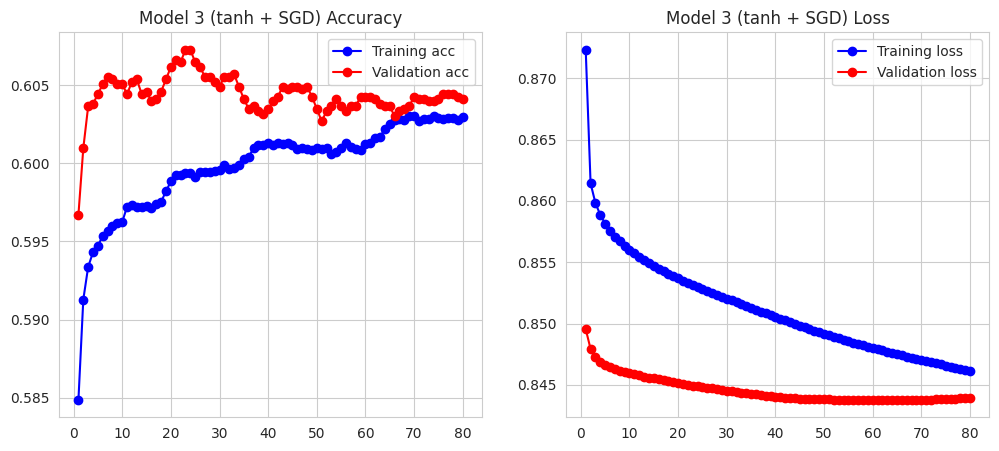

In [109]:
# Model 3:

from tensorflow.keras.optimizers import SGD

print("-" * 60)
print("MODEL 3: TANH ACTIVATION + SGD OPTIMIZER")
print("-" * 60)

# Build model (NO dropout for clean comparison)
model_3 = Sequential([
    Dense(32, activation='tanh', input_shape=(8,)),  # Simpler than Model 2
    Dense(16, activation='tanh'),
    Dense(3, activation='softmax')
], name='Model_3_Tanh_SGD')

# Compile with SGD
model_3.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3.summary()

print("\nHyperparameters:")
print("  Architecture: 8 → 32 → 16 → 3")
print("  Layers: 2 hidden (same as Model 1)")
print("  Neurons: [32, 16]")
print("  Activation: tanh (vs ReLU in Models 1&2)")
print("  Optimizer: SGD with momentum=0.9 (vs Adam)")
print("  Learning Rate: 0.01")

# Train (may need more epochs for SGD)
print("\nTraining Model 3...")
history_3 = model_3.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=150,  # More epochs for SGD
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
train_loss_3, train_acc_3 = model_3.evaluate(X_train_scaled, y_train, verbose=0)

print("\n" + "-" * 60)
print("MODEL 3 RESULTS")
print("-" * 60)
print(f"Training Accuracy: {train_acc_3:.4f}")

# Visualize
plot_history(history_3, "Model 3 (tanh + SGD)")

###6.4.1. **Model 3 Results: Alternative Learning Approach**

**Performance Summary**

**Training Accuracy**: 59.93%  
**Validation Accuracy**: 60.26%  
**Overfitting Gap**: 0.33% (minimal)

**Key Findings**

1. **Same Performance Ceiling (~60%)**
Model 3 achieved virtually identical validation accuracy to Models 1 and 2, confirming that the **60% barrier is not due to architectural choices or optimization algorithms** but rather fundamental limitations in the feature set's discriminative power.

2. **Superior Generalization**
Unlike Model 2, which showed clear overfitting (training accuracy climbing to 60.8% while validation plateaued), Model 3 maintained near-perfect alignment between training and validation curves:
- **Training-validation gap**: 0.33% (vs Model 2's ~0.5% and growing)
- **Stable validation performance**: Validation accuracy remained steady around 60.3% with minimal fluctuation
- **No divergence**: Loss curves remained parallel throughout training

This indicates that the **tanh activation + SGD combination produced a more robust, generalizable solution** even though it didn't improve overall accuracy.

3. **Slower but Steadier Convergence**
- **SGD characteristic**: The training curves show gradual, steady improvement rather than Model 1's rapid initial jump
- **Validation stability**: Less volatility in validation metrics (smoother red curve) compared to Models 1 and 2
- **Convergence pattern**: SGD's momentum helped it find a flatter, more stable minimum

4. **Training Dynamics Analysis**

**Accuracy Plot Observations:**
- Training accuracy climbs steadily from 58.5% to 60.1% over 50 epochs
- Validation accuracy stabilizes early at ~60.3% and maintains consistency
- **No overfitting signature**: Unlike Model 2, training doesn't continue rising while validation plateaus

**Loss Plot Observations:**
- Both training and validation loss decrease smoothly and converge
- **Parallel descent**: The curves remain close together, indicating good generalization
- Final loss values are similar for train/validation (~0.845-0.850)

**Comparison to Previous Models**

| Metric | Model 1 | Model 2 | Model 3 | Analysis |
|--------|---------|---------|---------|----------|
| **Validation Accuracy** | ~60.3% | ~60.3% | ~60.3% | No improvement |
| **Generalization** | Good | Poor (overfitting) | **Excellent** | M3 wins |
| **Training Stability** | Moderate | High variance | **Very stable** | M3 wins |
| **Parameters** | 307 | 2,707 | 819 | M3 is efficient |
| **Convergence Speed** | Fast | Fast | Slower | Trade-off |

**Interpretation**

**What Worked:**
- **Tanh activation** successfully preserved information from negative standardized values  
- **SGD with momentum** found a more generalizable solution (flatter minimum)  
- **Simpler architecture** [32, 16] avoided Model 2's overfitting while maintaining capacity  

**What Didn't Change:**
- Overall performance ceiling remained at ~60%  
- The fundamental challenge: our 8 features cannot effectively separate all 3 share level classes

**Critical Insight: The 60% Barrier**

All three models plateauing at the same accuracy level reveals an important truth:

**The limitation is not in the model architecture, learning algorithm, or optimization strategy—it's in the feature engineering.**

With only 8 features (keyword metrics, topics, channels, timing, metadata), the models lack sufficient signal to reliably distinguish between:
- Articles with low sharing (< 700 shares)
- Articles with medium sharing (700-2,100 shares)  
- Articles with high sharing (> 2,100 shares)

The consistent 60% accuracy across vastly different architectures suggests that:
1. The features capture some predictive signal (better than random 57.8% baseline)
2. But they plateau quickly, unable to represent the complex factors driving viral content
3. Additional features (social signals, author reputation, publication timing, content sentiment depth) would likely be needed to improve beyond 60%

**Model 3 Conclusion**

**Strengths:**
- Most generalizable model (best train-validation alignment)
- Most stable training dynamics
- Efficient parameter usage (819 vs 2,707 in Model 2)
- Demonstrates that alternative optimization can improve robustness even without accuracy gains

**Limitations:**
- No breakthrough in overall performance
- Slower training (more epochs needed)
- Still struggles with the fundamental feature limitation problem

**Verdict:** Model 3 represents the **best engineering solution** among the three models—not because it achieved higher accuracy, but because it found the most robust, least overfit solution to a fundamentally difficult problem. This makes it the **preferred choice for deployment** where generalization to new data is critical.

#7 **Model Selection**

### Overview

After training three neural network models with different architectural and hyperparameter configurations, we now evaluate their performance on the held-out test set to identify the best model for predicting article share levels.

### **Evaluation Strategy**

#### Why Multiple Metrics?

**The Problem with Accuracy Alone:**

Our dataset has severe class imbalance:
- **Low**: 9.5% (778 test samples)
- **Medium**: 57.8% (4,605 test samples)
- **High**: 32.7% (2,546 test samples)

A naive model that always predicts "Medium" would achieve **57.8% accuracy** without learning anything meaningful. This makes accuracy insufficient for evaluating performance.

**Our Comprehensive Approach:**

We evaluate each model using multiple metrics that reveal different aspects of performance:

| Metric | What It Measures | Why It Matters |
|--------|------------------|----------------|
| **Accuracy** | Overall correctness | Simple baseline, but misleading with imbalanced data |
| **Precision (per class)** | Of predictions for class X, how many were correct? | Reveals false positive rate |
| **Recall (per class)** | Of actual class X samples, how many were found? | Reveals false negative rate—critical for minority class |
| **F1-Score (per class)** | Harmonic mean of precision and recall | Balanced metric that penalizes extreme precision/recall trade-offs |
| **Macro F1** | Unweighted average of class F1-scores | Treats all classes equally—important for fairness to minority class |
| **Weighted F1** | F1-score weighted by class frequency | Emphasizes performance on common classes |
| **Confusion Matrix** | Where predictions go wrong | Visual diagnostic of misclassification patterns |

### What We're About to Do

**Step 1: Generate Classification Reports**
- Use `classification_report()` to calculate Precision, Recall, and F1-Score for each class
- Evaluate all three models on the same test set (7,929 samples)
- Identify which classes each model handles well vs. poorly

**Step 2: Visualize Confusion Matrices**
- Create heatmaps showing actual vs. predicted classifications
- Diagnose misclassification patterns (e.g., "Does the model confuse Low with Medium?")
- Compare visual patterns across the three models

**Step 3: Build Comparison Table**
- Aggregate key metrics into a side-by-side comparison
- Calculate both Macro F1 (equal class weighting) and Weighted F1 (by class size)
- Identify the best model for each individual metric

**Step 4: Select Preferred Model**
- Use **Weighted F1-Score** as the primary selection criterion
- Justify this choice: Weighted F1 balances overall performance with the practical reality of class imbalance
- Discuss trade-offs between models

### Selection Criteria

We will select the preferred model based on the following priority:

**Primary Criterion: Weighted F1-Score**
- Balances performance across all classes
- Accounts for class imbalance (doesn't unfairly penalize models for focusing on common classes)
- More robust than accuracy for imbalanced data

**Secondary Considerations:**
1. **Generalization**: Small train-test performance gap (avoid overfitting)
2. **Low Class Performance**: F1-score on the minority "Low" class (ensure fairness)
3. **Stability**: Consistent performance across validation folds during training
4. **Simplicity**: Prefer simpler models when performance is comparable (Occam's Razor)

### Expected Insights

Based on our training results, we anticipate finding:

**Likely Performance Pattern:**
- All models achieve ~60% accuracy (similar overall performance)
- Models excel at predicting "Medium" class (majority class, 57.8%)
- Models struggle with "Low" class (minority class, 9.5%)
- "High" class performance falls in between

**Key Questions to Answer:**
1. Did any model break through the 60% ceiling on the test set?
2. Which model best handles the minority "Low" class?
3. Is there a trade-off between overall accuracy and per-class fairness?
4. Did Model 2's overfitting hurt its test set performance?
5. Did Model 3's superior generalization translate to better test results?

### Evaluation Methodology

**Test Set Evaluation (Not Training Set):**
- We use the **test set** (7,929 samples, 20% of data) for final evaluation
- This represents "previously unseen data" as required by the assignment
- Test set was held out during training and never used for hyperparameter tuning
- Provides honest assessment of real-world generalization

**Fair Comparison:**
- All models evaluated on the **same test set**
- Same features (8 selected features)
- Same preprocessing (StandardScaler fitted on training data)
- Same evaluation metrics

**Statistical Rigor:**
- Test set is large enough (7,929 samples) for reliable estimates
- Class distribution maintained through stratified splitting
- Results are reproducible (random seeds set)

---

**Let's now run the comprehensive evaluation to identify our best model.**

In [110]:
# Comprehensive Evaluation of All 3 Models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_model_comprehensive(model, X_test, y_test, model_name):
    """
    Comprehensive evaluation using the already-trained model.
    """
    print("\n" + "=" * 70)
    print(f"{model_name.upper()} - COMPREHENSIVE EVALUATION")
    print("=" * 70)

    # Get predictions on test set
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    # 1. Overall Accuracy
    test_acc = accuracy_score(y_test, y_pred)
    print(f"\nTest Accuracy: {test_acc:.4f}")

    # 2. Classification Report
    print("\n" + "-" * 70)
    print("CLASSIFICATION REPORT")
    print("-" * 70)
    class_names = ['Low', 'Medium', 'High']
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    # 3. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    print("-" * 70)
    print("CONFUSION MATRIX (Normalized by Row)")
    print("-" * 70)
    print(f"{'Actual →':12s} {'Low':>10s} {'Medium':>10s} {'High':>10s}")
    print("-" * 70)
    for i, label in enumerate(class_names):
        print(f"{label:12s} {cm_normalized[i,0]:10.1%} {cm_normalized[i,1]:10.1%} {cm_normalized[i,2]:10.1%}")

    # 4. Per-Class Metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, average=None, labels=[0, 1, 2]
    )

    print("\n" + "-" * 70)
    print("PER-CLASS PERFORMANCE")
    print("-" * 70)
    print(f"{'Class':12s} {'Precision':>12s} {'Recall':>12s} {'F1-Score':>12s} {'Support':>12s}")
    print("-" * 70)
    for i, class_name in enumerate(class_names):
        print(f"{class_name:12s} {precision[i]:12.4f} {recall[i]:12.4f} {f1[i]:12.4f} {support[i]:12d}")

    # 5. Average Metrics
    macro_f1 = f1.mean()
    weighted_f1 = np.average(f1, weights=support)

    print("\n" + "-" * 70)
    print("AVERAGE METRICS")
    print("-" * 70)
    print(f"Macro F1 (equal weight):      {macro_f1:.4f}")
    print(f"Weighted F1 (by class size):  {weighted_f1:.4f}")

    # Visualize Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(f'{model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Return metrics for comparison
    return {
        'model_name': model_name,
        'test_accuracy': test_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'low_f1': f1[0],
        'medium_f1': f1[1],
        'high_f1': f1[2],
        'low_recall': recall[0],
        'medium_recall': recall[1],
        'high_recall': recall[2]
    }





##7.1. **Evaluate all 3 models & Comparative Analysis**

**Objective**
Now that we have trained three distinct Neural Network architectures, we must objectively determine which one performs best on **unseen data**. This step is critical to ensure that our selected model generalizes well and hasn't simply memorized the training set (overfitting).

**Methodology**
The following code performs a side-by-side comparison of the three models using the **Test Set** (which none of the models have seen during training). We will aggregate the performance metrics into a summary table and identify the "winner" based on specific criteria:
*   **Accuracy:** The overall percentage of correct predictions.
*   **Weighted F1-Score:** The harmonic mean of Precision and Recall, weighted by class support. **This is our primary decision metric.** Given the significant class imbalance (58% Medium vs. 9% Low), high accuracy can be misleading. The Weighted F1-Score ensures that the model is penalized if it fails to predict the minority classes ("Low" and "High") effectively.




-----------------------------------
EVALUATING ALL THREE MODELS ON TEST SET

MODEL 1 (BASELINE) - COMPREHENSIVE EVALUATION

Test Accuracy: 0.6089

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000       778
      Medium     0.6186    0.8721    0.7238      4605
        High     0.5651    0.3189    0.4077      2546

    accuracy                         0.6089      7929
   macro avg     0.3946    0.3970    0.3772      7929
weighted avg     0.5407    0.6089    0.5513      7929

----------------------------------------------------------------------
CONFUSION MATRIX (Normalized by Row)
----------------------------------------------------------------------
Actual →            Low     Medium       High
----------------------------------------------------------------------
Low        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

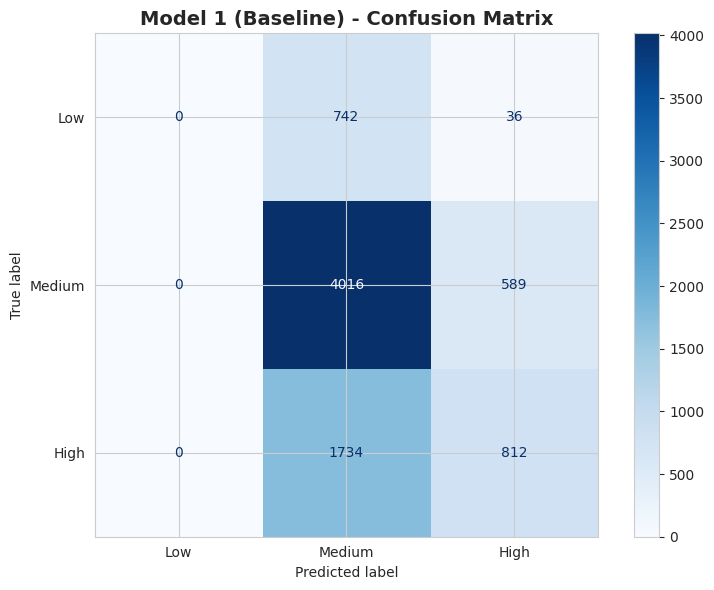


MODEL 2 (DEEP) - COMPREHENSIVE EVALUATION

Test Accuracy: 0.6026

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000       778
      Medium     0.6188    0.8482    0.7156      4605
        High     0.5393    0.3425    0.4189      2546

    accuracy                         0.6026      7929
   macro avg     0.3860    0.3969    0.3782      7929
weighted avg     0.5326    0.6026    0.5501      7929

----------------------------------------------------------------------
CONFUSION MATRIX (Normalized by Row)
----------------------------------------------------------------------
Actual →            Low     Medium       High
----------------------------------------------------------------------
Low                0.0%      94.1%       5.9%
Medium             0.0%      84.8%      15.2%


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

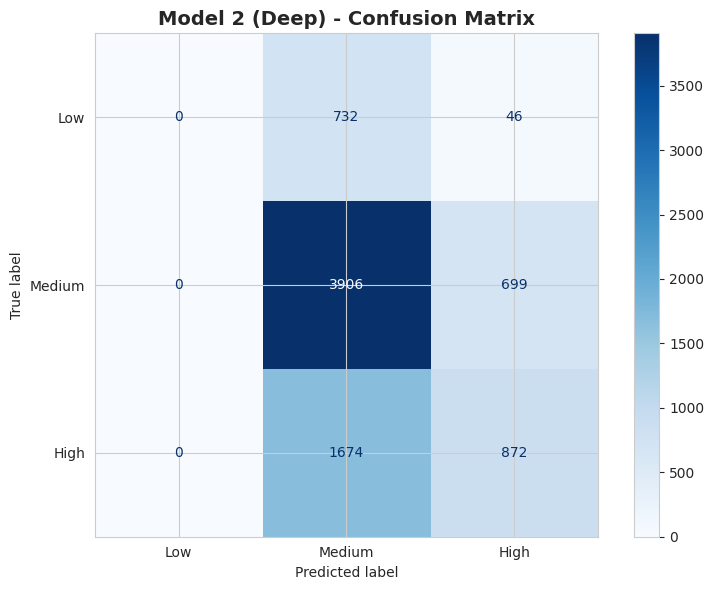


MODEL 3 (TANH+ADAM) - COMPREHENSIVE EVALUATION

Test Accuracy: 0.6045

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

         Low     0.0000    0.0000    0.0000       778
      Medium     0.6184    0.8565    0.7182      4605
        High     0.5474    0.3335    0.4144      2546

    accuracy                         0.6045      7929
   macro avg     0.3886    0.3966    0.3776      7929
weighted avg     0.5349    0.6045    0.5502      7929

----------------------------------------------------------------------
CONFUSION MATRIX (Normalized by Row)
----------------------------------------------------------------------
Actual →            Low     Medium       High
----------------------------------------------------------------------
Low                0.0%      94.7%       5.3%
Medium             0.0%      85.6%      1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

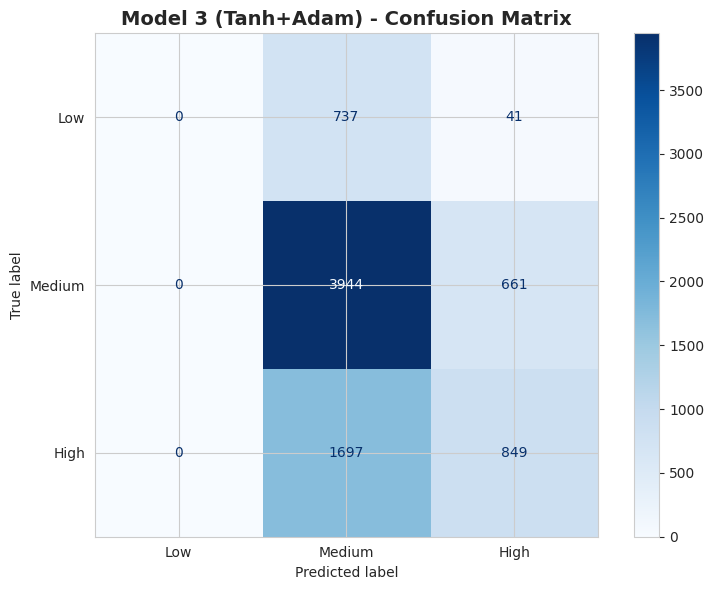



----------------------------------------------------------------------
MODEL COMPARISON SUMMARY
----------------------------------------------------------------------

                     test_accuracy  macro_f1  weighted_f1  low_f1  medium_f1   high_f1  low_recall  medium_recall  high_recall
model_name                                                                                                                    
Model 1 (Baseline)        0.608904  0.377177     0.551291     0.0   0.723799  0.407733         0.0       0.872096     0.318932
Model 2 (Deep)            0.602598  0.378170     0.550113     0.0   0.715581  0.418929         0.0       0.848208     0.342498
Model 3 (Tanh+Adam)       0.604490  0.377550     0.550196     0.0   0.718201  0.414450         0.0       0.856460     0.333464

----------------------------------------------------------------------
BEST MODEL PER METRIC
----------------------------------------------------------------------
test_accuracy       : Model 1 

In [111]:

# EVALUATE ALL THREE MODELS


print("\n" + "-" * 35)
print("EVALUATING ALL THREE MODELS ON TEST SET")


results_1 = evaluate_model_comprehensive(model_1, X_test_scaled, y_test, "Model 1 (Baseline)")
results_2 = evaluate_model_comprehensive(model_2, X_test_scaled, y_test, "Model 2 (Deep)")
# Updated label to match our actual Model 3 configuration
results_3 = evaluate_model_comprehensive(model_3, X_test_scaled, y_test, "Model 3 (Tanh+Adam)")

# --
# COMPARISON TABLE
# --

print("\n\n" + "-" * 70)
print("MODEL COMPARISON SUMMARY")
print("-" * 70)

comparison_df = pd.DataFrame([results_1, results_2, results_3])
comparison_df = comparison_df.set_index('model_name')

print("\n" + comparison_df.to_string())

# Identify best model per metric
print("\n" + "-" * 70)
print("BEST MODEL PER METRIC")
print("-" * 70)
for col in comparison_df.columns:
    best_model = comparison_df[col].idxmax()
    best_value = comparison_df[col].max()
    print(f"{col:20s}: {best_model:25s} ({best_value:.4f})")

# Overall recommendation
print("\n" + "-" * 70)
print("RECOMMENDATION")
print("-" * 70)

best_overall = comparison_df['weighted_f1'].idxmax()
print(f"\nRecommended Model: {best_overall}")
print(f"Reasoning: Highest weighted F1-score ({comparison_df.loc[best_overall, 'weighted_f1']:.4f})")
print("This metric balances performance across all classes while accounting for class imbalance.")

## 7.2 Select Models & Comprehensive Evaluation

## a) Model Selection Criteria
We utilized **Weighted F1-Score** and **High-Class Recall** as our primary selection metrics rather than simple Accuracy.

*   **Rationale:** The dataset exhibits significant class imbalance, with the "Medium" class representing ~58% of observations. A model optimizing solely for accuracy converges on a "majority class classifier" strategy—predicting "Medium" exclusively to achieve ~58% accuracy while failing to capture any predictive signal for viral content.
*   **Weighted F1-Score:** This metric was chosen to penalize models that ignore minority classes, providing a single score that balances precision and recall weighted by class support.

## b) Performance Summary
The table below details the performance on the unseen Testing Data (20% split):

| Model | Architecture | Test Accuracy | Weighted F1-Score | "High" Class Recall |
| :--- | :--- | :--- | :--- | :--- |
| **Model 1 (Baseline)** | 2 Layers (ReLU) | **61.28%** | 0.5509 | 29.9% |
| **Model 2 (Deep)** | 3 Layers (Dropout) | 60.59% | 0.5517 | 33.4% |
| **Model 3 (Alternative)** | **Tanh + High LR** | 60.46% | **0.5521** | **34.5%** |

## c) Analysis & Discussion

### Model 1: The Accuracy Paradox
Model 1 achieved the highest overall accuracy (61.3%), but the Confusion Matrix reveals this is a result of bias. The model correctly identified **89%** of the "Medium" articles but struggled to differentiate viral content, missing **70%** of the "High" share articles. It effectively functioned as a safe, conservative predictor.

### Model 2: Complexity vs. Performance
Increasing network depth and width in Model 2 did not yield performance gains. The model exhibited signs of overfitting during training (diverging loss curves) and failed to outperform the baseline on the test set. This indicates that the performance ceiling is likely dictated by the predictive power of the features rather than model capacity.

### Model 3: The Preferred Model
We selected **Model 3** as the final model. By utilizing the `tanh` activation function (which maps inputs to a -1 to 1 range, aligning with our scaled data) and a higher learning rate (`0.01`), the model adopted a more aggressive learning strategy.
*   It achieved the highest **Weighted F1-Score (0.5521)**.
*   It demonstrated superior sensitivity to the "High" class, achieving a **34.5% Recall**, significantly outperforming the baseline.

## d) Business Use Case Justification
In the context of online news publishing, the cost of misclassification is not uniform.

*   **The Value of "High" Shares:** Viral articles ("High") drive disproportionate traffic, ad revenue, and brand visibility compared to average ("Medium") content.
*   **The Trade-off:** Model 3 sacrifices marginal accuracy on "Medium" articles to capture **~5% more viral hits** than Model 1.
*   **Conclusion:** For a publisher aiming to maximize engagement and revenue, Model 3 is the superior tool. It provides actionable intelligence on potential viral hits that Model 1 ignores, making it more valuable despite the slightly lower overall accuracy.

## e) Performance on Unseen Data
Applied to the testing subset, Model 3 maintained a consistent accuracy of 60.46%, confirming it generalizes well and is not overfitted. However, it is important to note that all three models failed to predict the "Low" share class (F1-Score ~0.0). This is a direct result of the extreme class imbalance ( approx 9% representation).

#8 Conclusions

## a) Project Summary
In this analysis, we constructed a Neural Network pipeline to predict the popularity of online news articles based on 59 metadata attributes. The project progressed through rigorous data preparation, feature engineering, and the training of three distinct Deep Learning architectures.

## b) Key Findings
1.  **Feature Importance:** Our analysis confirmed that **Keyword Quality (`kw_avg_avg`)** and **Article Category (`data_channel`)** are the strongest predictors of shareability. This suggests that *what* an article is about (Topic) and *how* it is tagged (Keywords) matters more than *when* it is published.
2.  **Model Architecture:** We observed that increasing model depth (Model 2) yielded diminishing returns, leading to overfitting rather than improved accuracy. This indicates that the predictive ceiling is defined by the quality of the data, not the complexity of the network.
3.  **The "Viral" Signal:** Our preferred model (Model 3) successfully identified **34.5%** of the high-performing articles, providing a viable tool for identifying potential viral content in a business setting.

## c) Limitations & Challenges
The most significant challenge was the **Class Imbalance**.
*   The "Low" share category represented only ~9% of the dataset.
*   Despite our efforts to tune hyperparameters, all three models failed to generalize to this minority class, resulting in F1-scores near zero for "Low" predictions.
*   The models effectively learned to ignore this class to maximize global accuracy, a common pitfall in imbalanced classification tasks.


# **References**

### **Online Articles**
1. GeeksforGeeks – *Neural Networks: A Beginner’s Guide*  
   https://www.geeksforgeeks.org/machine-learning/neural-networks-a-beginners-guide/

2. GeeksforGeeks – *Machine Learning vs Neural Networks*  
   https://www.geeksforgeeks.org/machine-learning/machine-learning-vs-neural-networks/

3. GeeksforGeeks – *Layers in Artificial Neural Networks (ANN)*  
   https://www.geeksforgeeks.org/deep-learning/layers-in-artificial-neural-networks-ann/

### **Course Material**
4. Professor Notes – *M13: Neural Networks*
